1. **Entropy**
2. **Joint Entropy**
3. **Conditonal Entropy**
4. **Mutual Information**
5. **Transfer Entropy**

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import os
import h5py
import helper_functions as hp
import data_loading as dl

In [27]:
#it_utils

import math
import numpy as np

gt_data, gt_spikes, sub_data, sub_spikes, cfg, tmap, truth_table, h5_file_path_gt, h5_file_path_sub = dl.get_data()
def H(binary_list) -> float:
    """
    Shannon entropy of a binary sequence in bits.
    Uses plug-in estimator — no bias correction (single neuron, marginal).
    """
    n = len(binary_list)
    if n == 0:
        return 0.0

    p1 = sum(binary_list) / n
    p0 = 1.0 - p1

    entropy = 0.0
    if p0 > 0:
        entropy -= p0 * math.log2(p0)
    if p1 > 0:
        entropy -= p1 * math.log2(p1)

    return entropy


def _miller_madow(counts: np.ndarray, N: int) -> float:
    """
    Miller-Madow bias correction: (K - 1) / (2 * N * log(2)) bits.
    K = number of non-empty bins, N = total samples.

    Reference: Miller, G. (1955). Note on the bias of information estimates.
    Information Theory in Psychology, 2, 95-100.
    """
    K = int(np.sum(counts > 0))
    if N == 0:
        return 0.0
    return (K - 1) / (2.0 * N * math.log(2))


def joint_entropy_from_states(state_ids: np.ndarray,
                               n_states: int,
                               n_samples: int) -> float:
    """
    Plug-in joint entropy with Miller-Madow bias correction.

    Parameters
    ----------
    state_ids : np.ndarray
        Integer state index per timestep (0 to n_states-1).
    n_states : int
        Total number of possible states (2^n_neurons).
    n_samples : int
        Number of samples (len of state_ids).

    Returns
    -------
    float : bias-corrected joint entropy in bits.
    """
    if n_samples == 0:
        return 0.0

    counts = np.bincount(state_ids.astype(int), minlength=n_states)
    probs  = counts[counts > 0] / n_samples
    H_raw  = float(-np.sum(probs * np.log2(probs)))
    mm     = _miller_madow(counts, n_samples)

    return H_raw + mm


def entropy_from_counts(counts: np.ndarray, N: int) -> float:
    """
    Generic plug-in entropy + Miller-Madow from raw counts.
    Used by CE, TE, MI internally.
    """
    if N == 0:
        return 0.0
    probs = counts[counts > 0] / N
    H_raw = float(-np.sum(probs * np.log2(probs)))
    return H_raw + _miller_madow(counts, N)

def marginal_entropy(arr: np.ndarray) -> float:
    """H(Y_i) — marginal entropy of a binary spike train."""
    N  = len(arr)
    mc = np.bincount(arr.astype(int), minlength=2).astype(float)
    return entropy_from_counts(mc, N)

def mutual_information(arr_i: np.ndarray, arr_j: np.ndarray) -> float:
    """
    MI(Y_i ; Y_j) computed via direct KL form:
    I(X;Y) = sum p(x,y) log p(x,y) / p(x)p(y)

    More numerically stable than H(X) + H(Y) - H(X,Y).
    Miller-Madow bias corrected.
    """
    N = len(arr_i)
    if N == 0:
        return 0.0

    jc      = np.bincount(2 * arr_i.astype(int) + arr_j.astype(int),
                          minlength=4).astype(float)
    p_joint = jc / N

    p_i = np.array([p_joint[0] + p_joint[1],
                    p_joint[2] + p_joint[3]])
    p_j = np.array([p_joint[0] + p_joint[2],
                    p_joint[1] + p_joint[3]])

    p_indep = np.array([
        p_i[0] * p_j[0],
        p_i[0] * p_j[1],
        p_i[1] * p_j[0],
        p_i[1] * p_j[1],
    ])

    mask = (p_joint > 0) & (p_indep > 0)
    MI   = float(np.sum(p_joint[mask] * np.log2(p_joint[mask] / p_indep[mask])))

    # Miller-Madow correction on joint distribution
    K  = int(np.sum(jc > 0))
    mm = (K - 1) / (2.0 * N * np.log(2))

    return max(0.0, MI + mm)

patterns = tmap["case"].unique().tolist()
n_patterns = len(patterns)
labels     = [c.replace("_spike", "") for c in hp.get_spiking_neurons(cfg,gt_data)]

def plot_single_heatmap(M, title, labels, cmap, vmin, vmax):

    plt.figure(figsize=(8, 8), dpi=250)

    im = plt.imshow(
        np.ma.masked_invalid(M),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        aspect="equal"
    )

    plt.title(title, fontsize=14)

    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(range(len(labels)), labels)

    # Grid
    plt.gca().set_xticks(np.arange(-0.5, len(labels), 1), minor=True)
    plt.gca().set_yticks(np.arange(-0.5, len(labels), 1), minor=True)
    plt.grid(which="minor", color="white", linewidth=0.6)
    plt.tick_params(which="minor", bottom=False, left=False)

    # Numbers
    for i in range(len(labels)):
        for j in range(len(labels)):
            if np.isnan(M[i, j]):
                continue
            plt.text(
                j, i,
                f"{M[i,j]:.2f}",
                ha="center",
                va="center",
                fontsize=8
            )

    plt.colorbar(im, shrink=0.8)
    plt.tight_layout()
    plt.show()



GT Voltage Data Loading done!
GT Spikes Data Loading done!
SUB Voltage Data Loading done!
SUB Spikes Data Loading done!
Network configuration Loading done!
Trial Map Loading done!


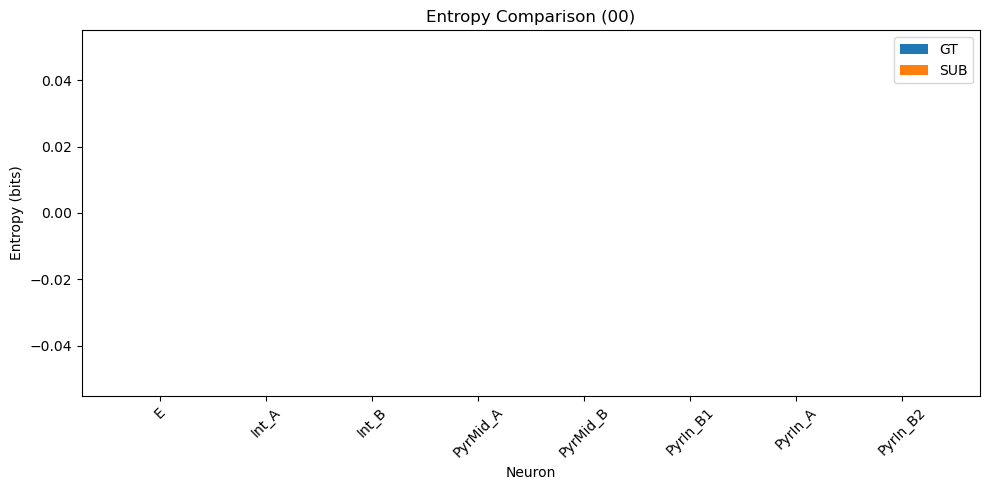

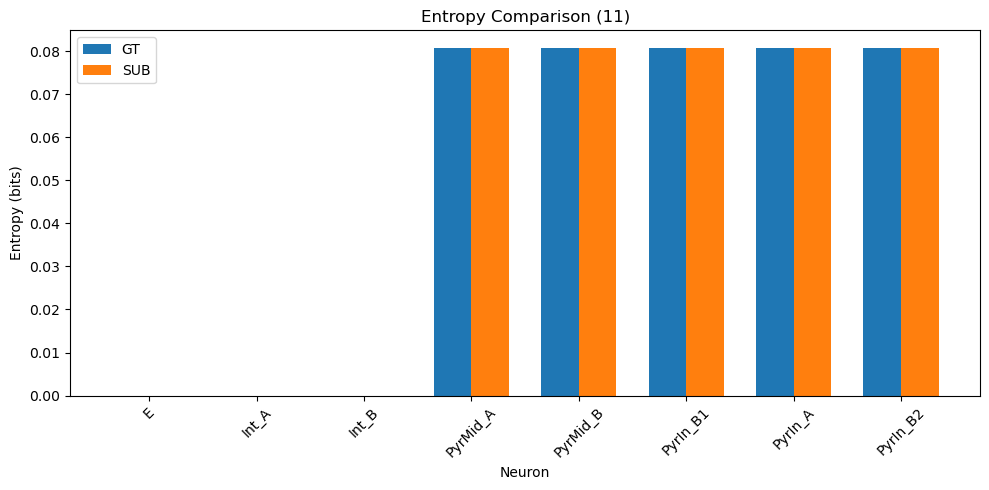

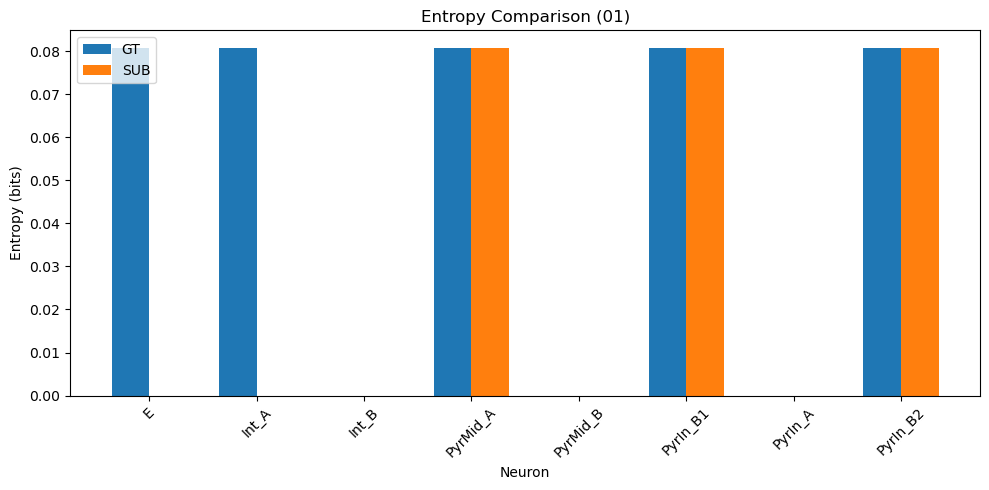

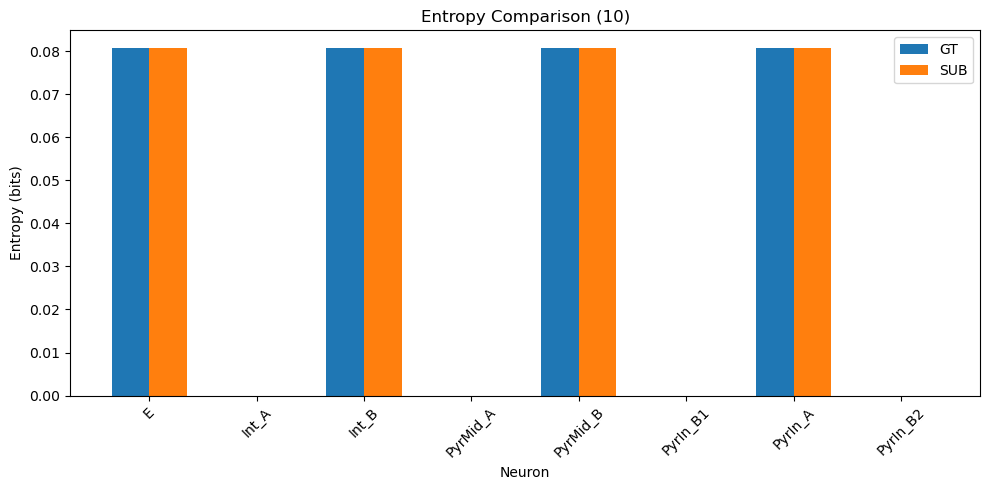

In [21]:
#Entropy

def entropy_compute():
    patterns = gt_data["case"].unique().tolist()
    neurons  = hp.get_spiking_neurons(cfg,gt_data)               
    gt_rows  = []
    sub_rows = []

    for neuron in neurons:
        gt_row  = {"neuron": neuron}
        sub_row = {"neuron": neuron}

        for p in patterns:
            gt_spikes        = gt_data[gt_data["case"] == p][f"{neuron}_spike"].tolist()
            sub_spikes       = sub_data[sub_data["case"] == p][f"{neuron}_spike"].tolist()
            gt_row[f"H_{p}"] = H(gt_spikes)
            sub_row[f"H_{p}"]= H(sub_spikes)

        gt_rows.append(gt_row)
        sub_rows.append(sub_row)

    gt_table  = pd.DataFrame(gt_rows)
    sub_table = pd.DataFrame(sub_rows)

    diff_cols = [c for c in gt_table.columns if c.startswith("H_")]
    diff      = gt_table[diff_cols].values - sub_table[diff_cols].values
    score     = float(1.0 - np.clip(np.abs(diff).mean(), 0.0, 1.0))
    return gt_table, sub_table

gt_table, sub_table = entropy_compute()

patterns = [c for c in gt_table.columns if c.startswith("H_")]

for pattern in patterns:

    plt.figure(figsize=(10, 5))

    x = np.arange(len(gt_table))
    width = 0.35

    plt.bar(
        x - width/2,
        gt_table[pattern],
        width,
        label="GT"
    )

    plt.bar(
        x + width/2,
        sub_table[pattern],
        width,
        label="SUB"
    )

    plt.xticks(x, gt_table["neuron"], rotation=45)
    plt.ylabel("Entropy (bits)")
    plt.xlabel("Neuron")
    plt.title(f"Entropy Comparison ({pattern[2:]})")
    plt.legend()

    plt.tight_layout()
    plt.show()

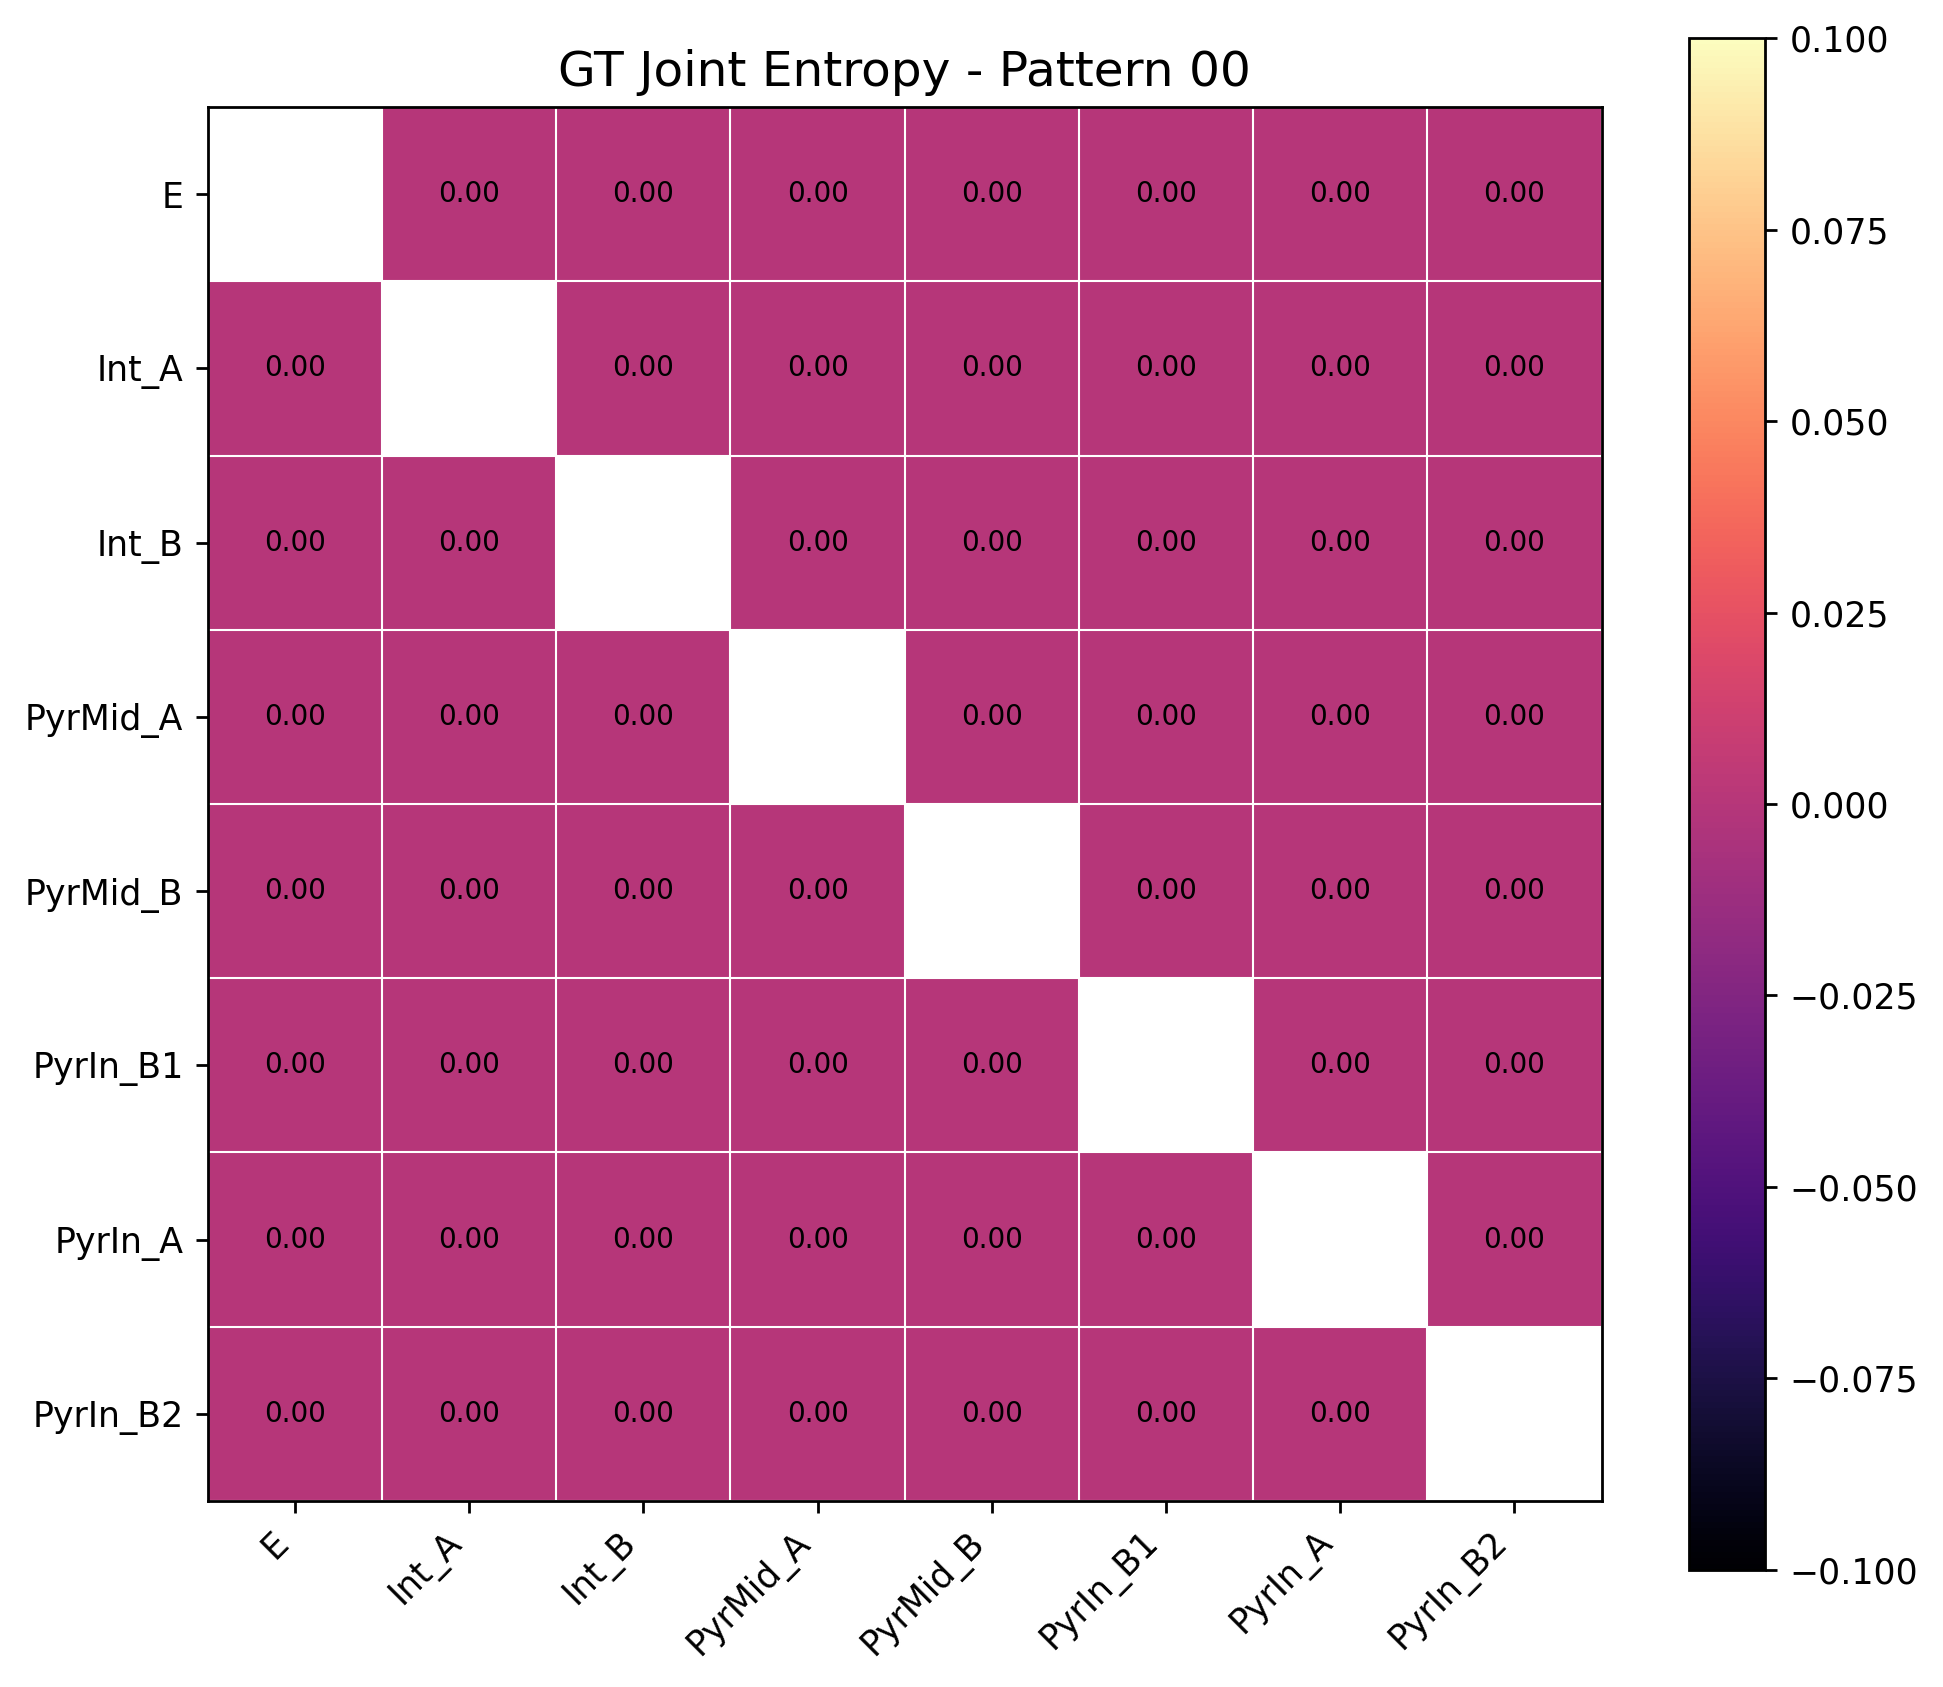

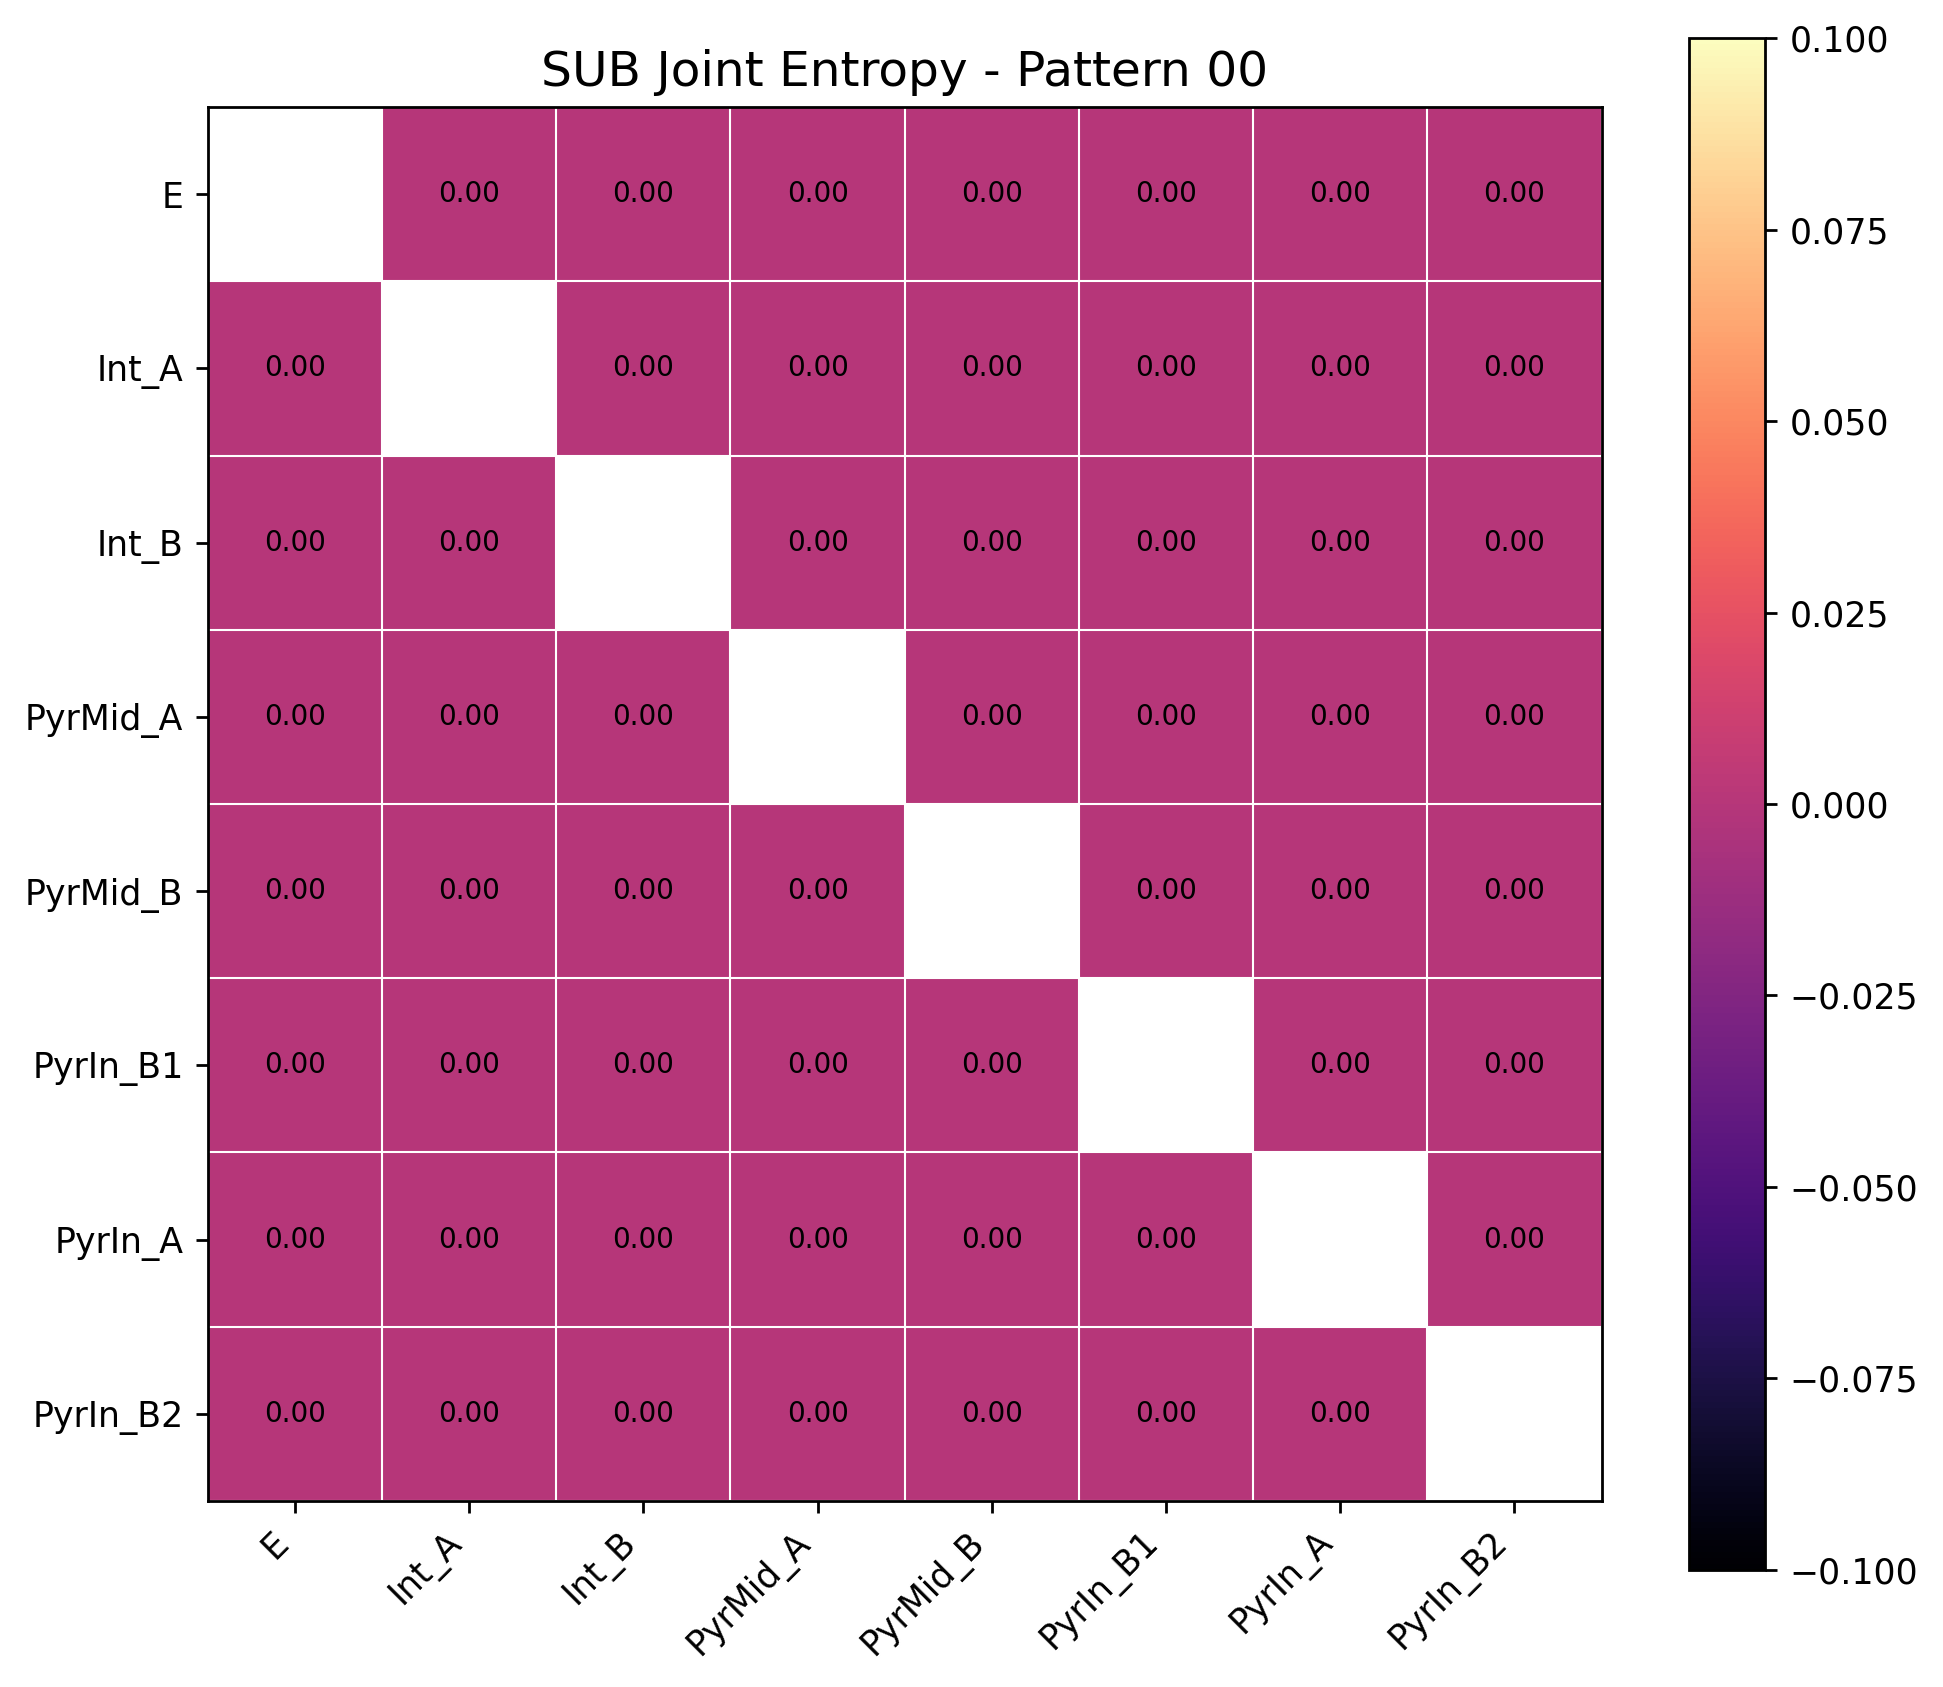

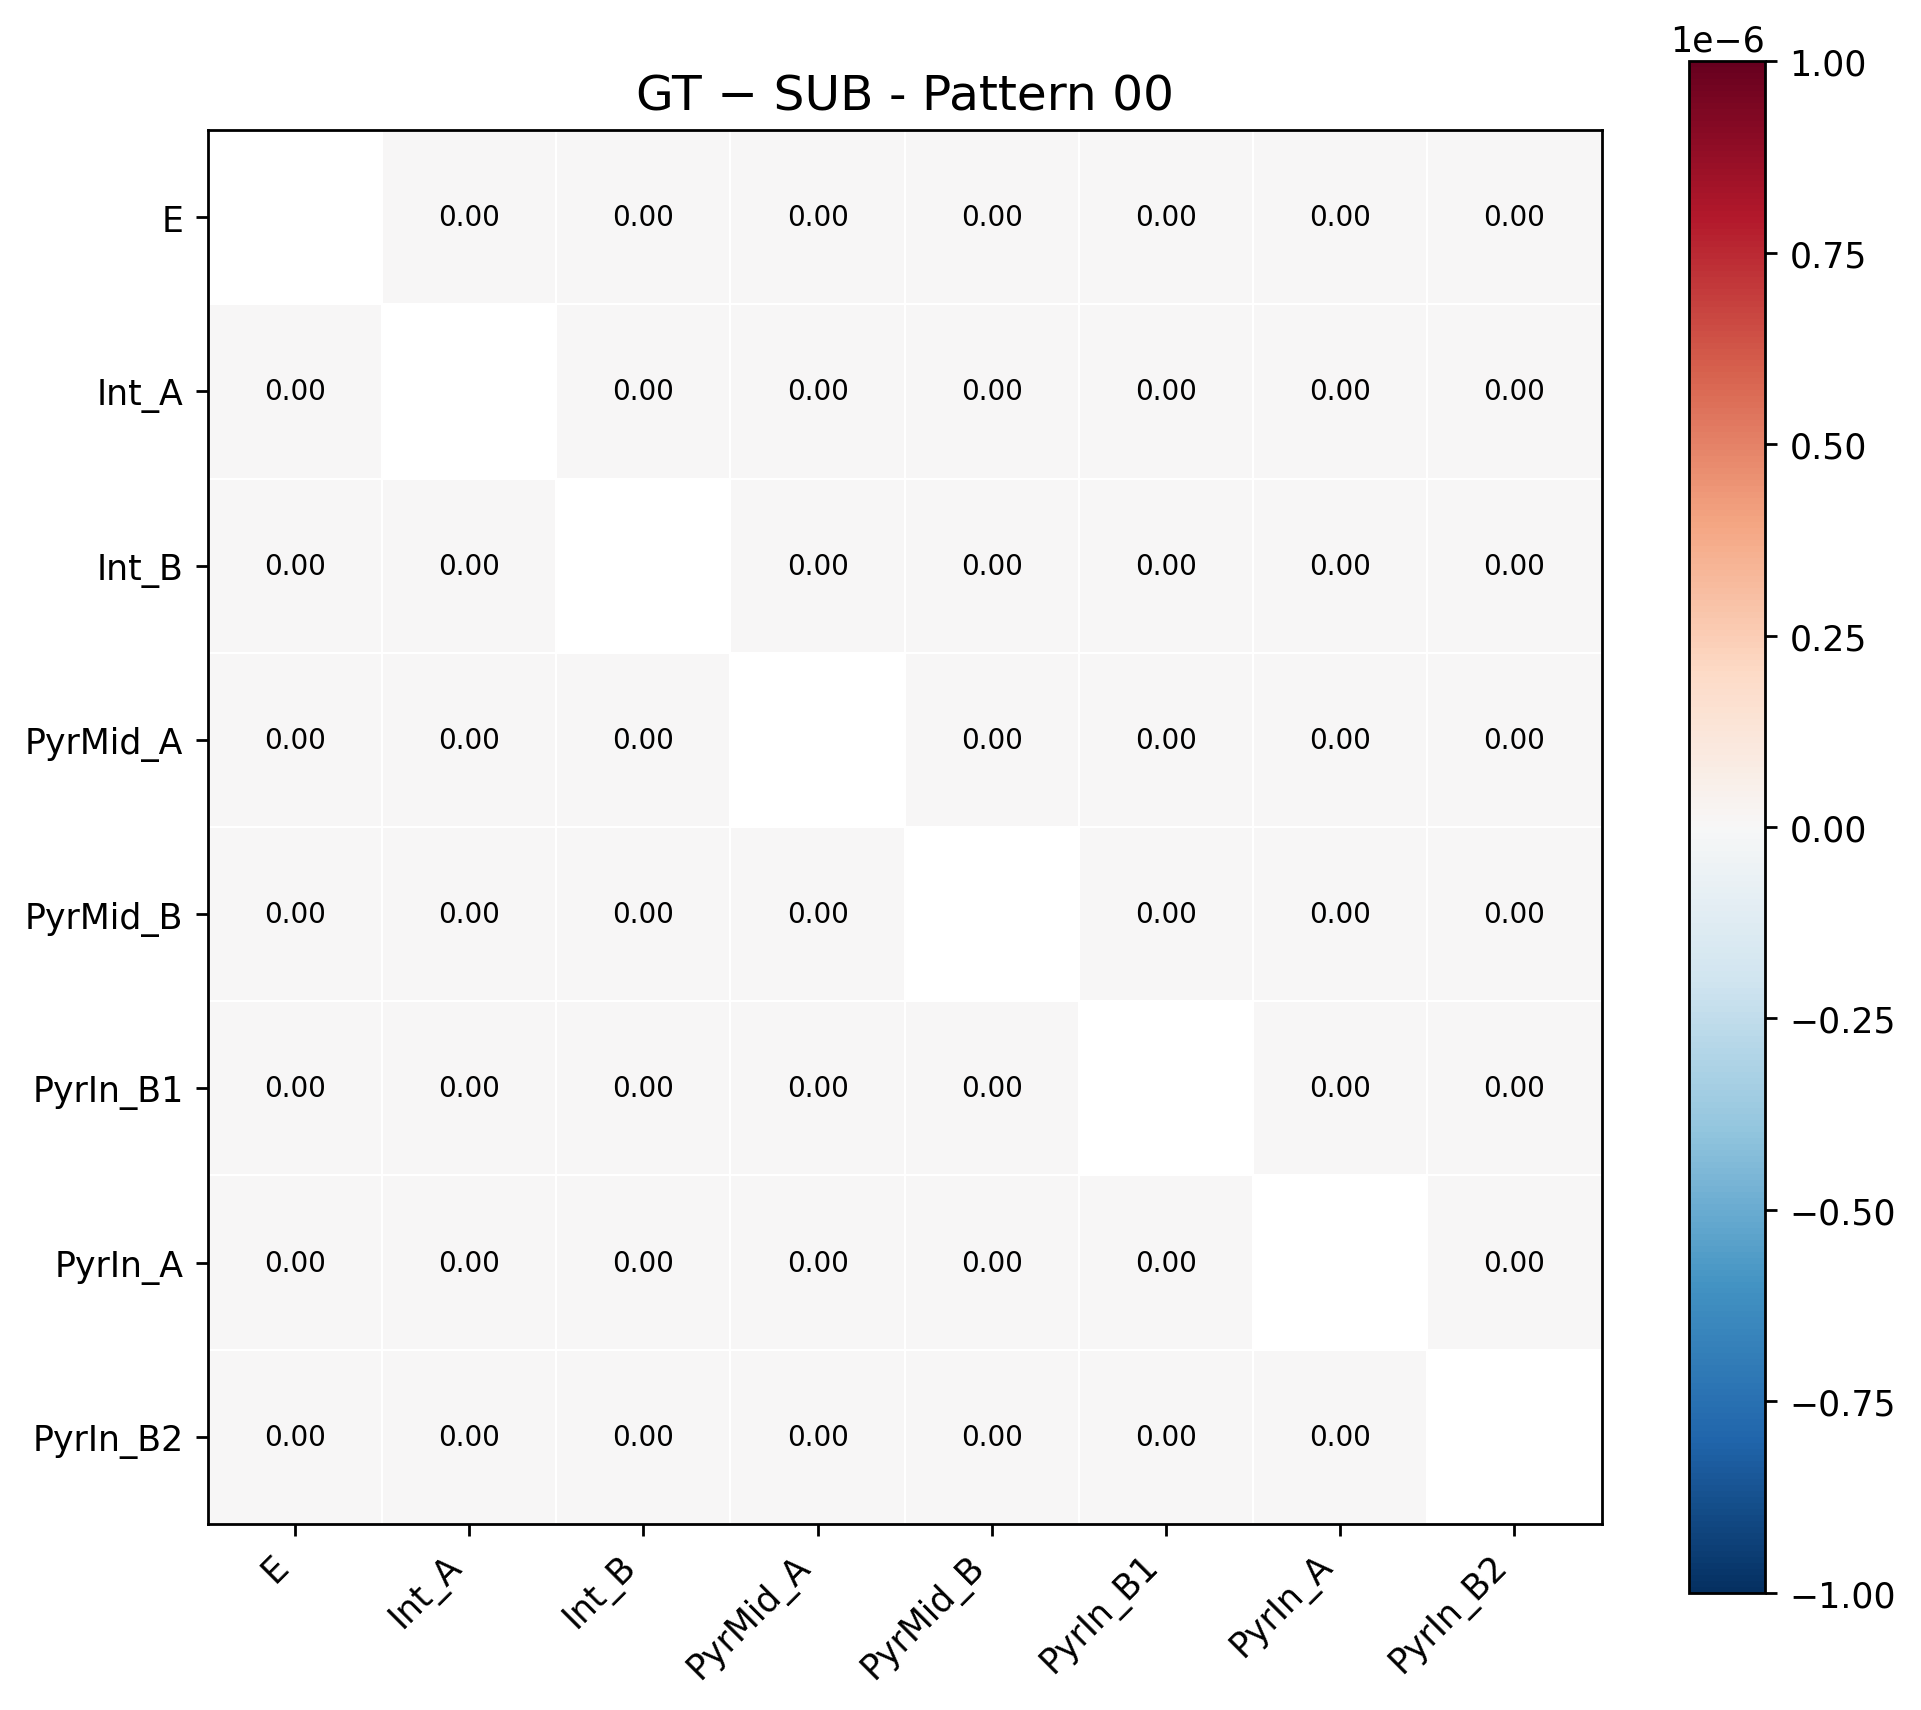

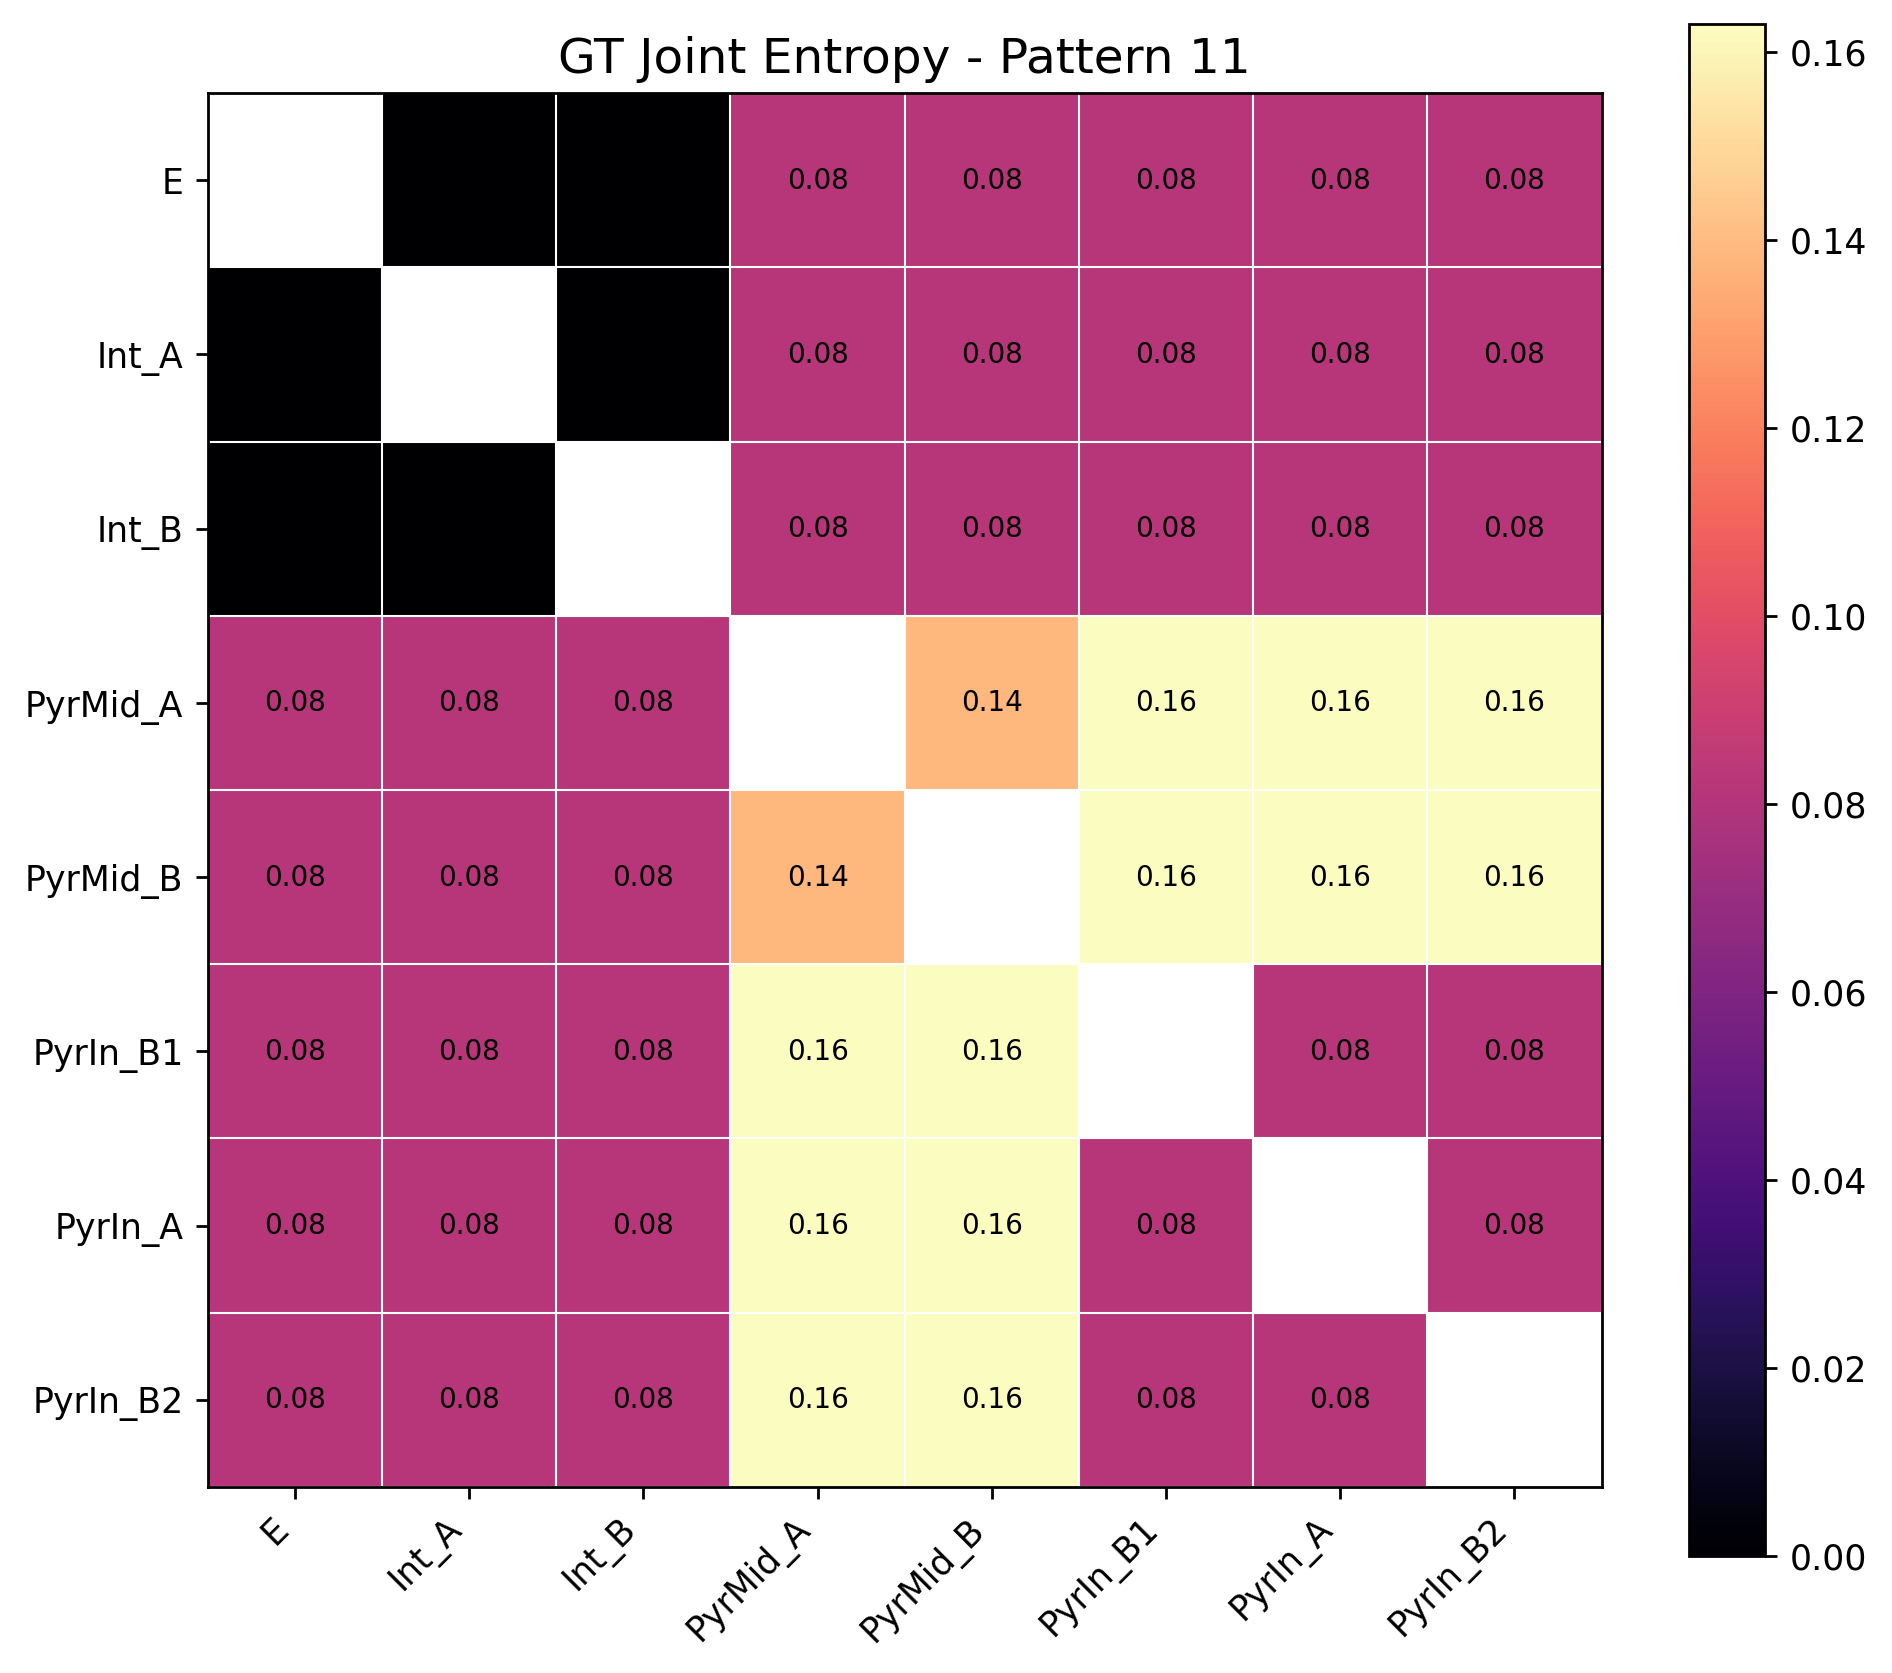

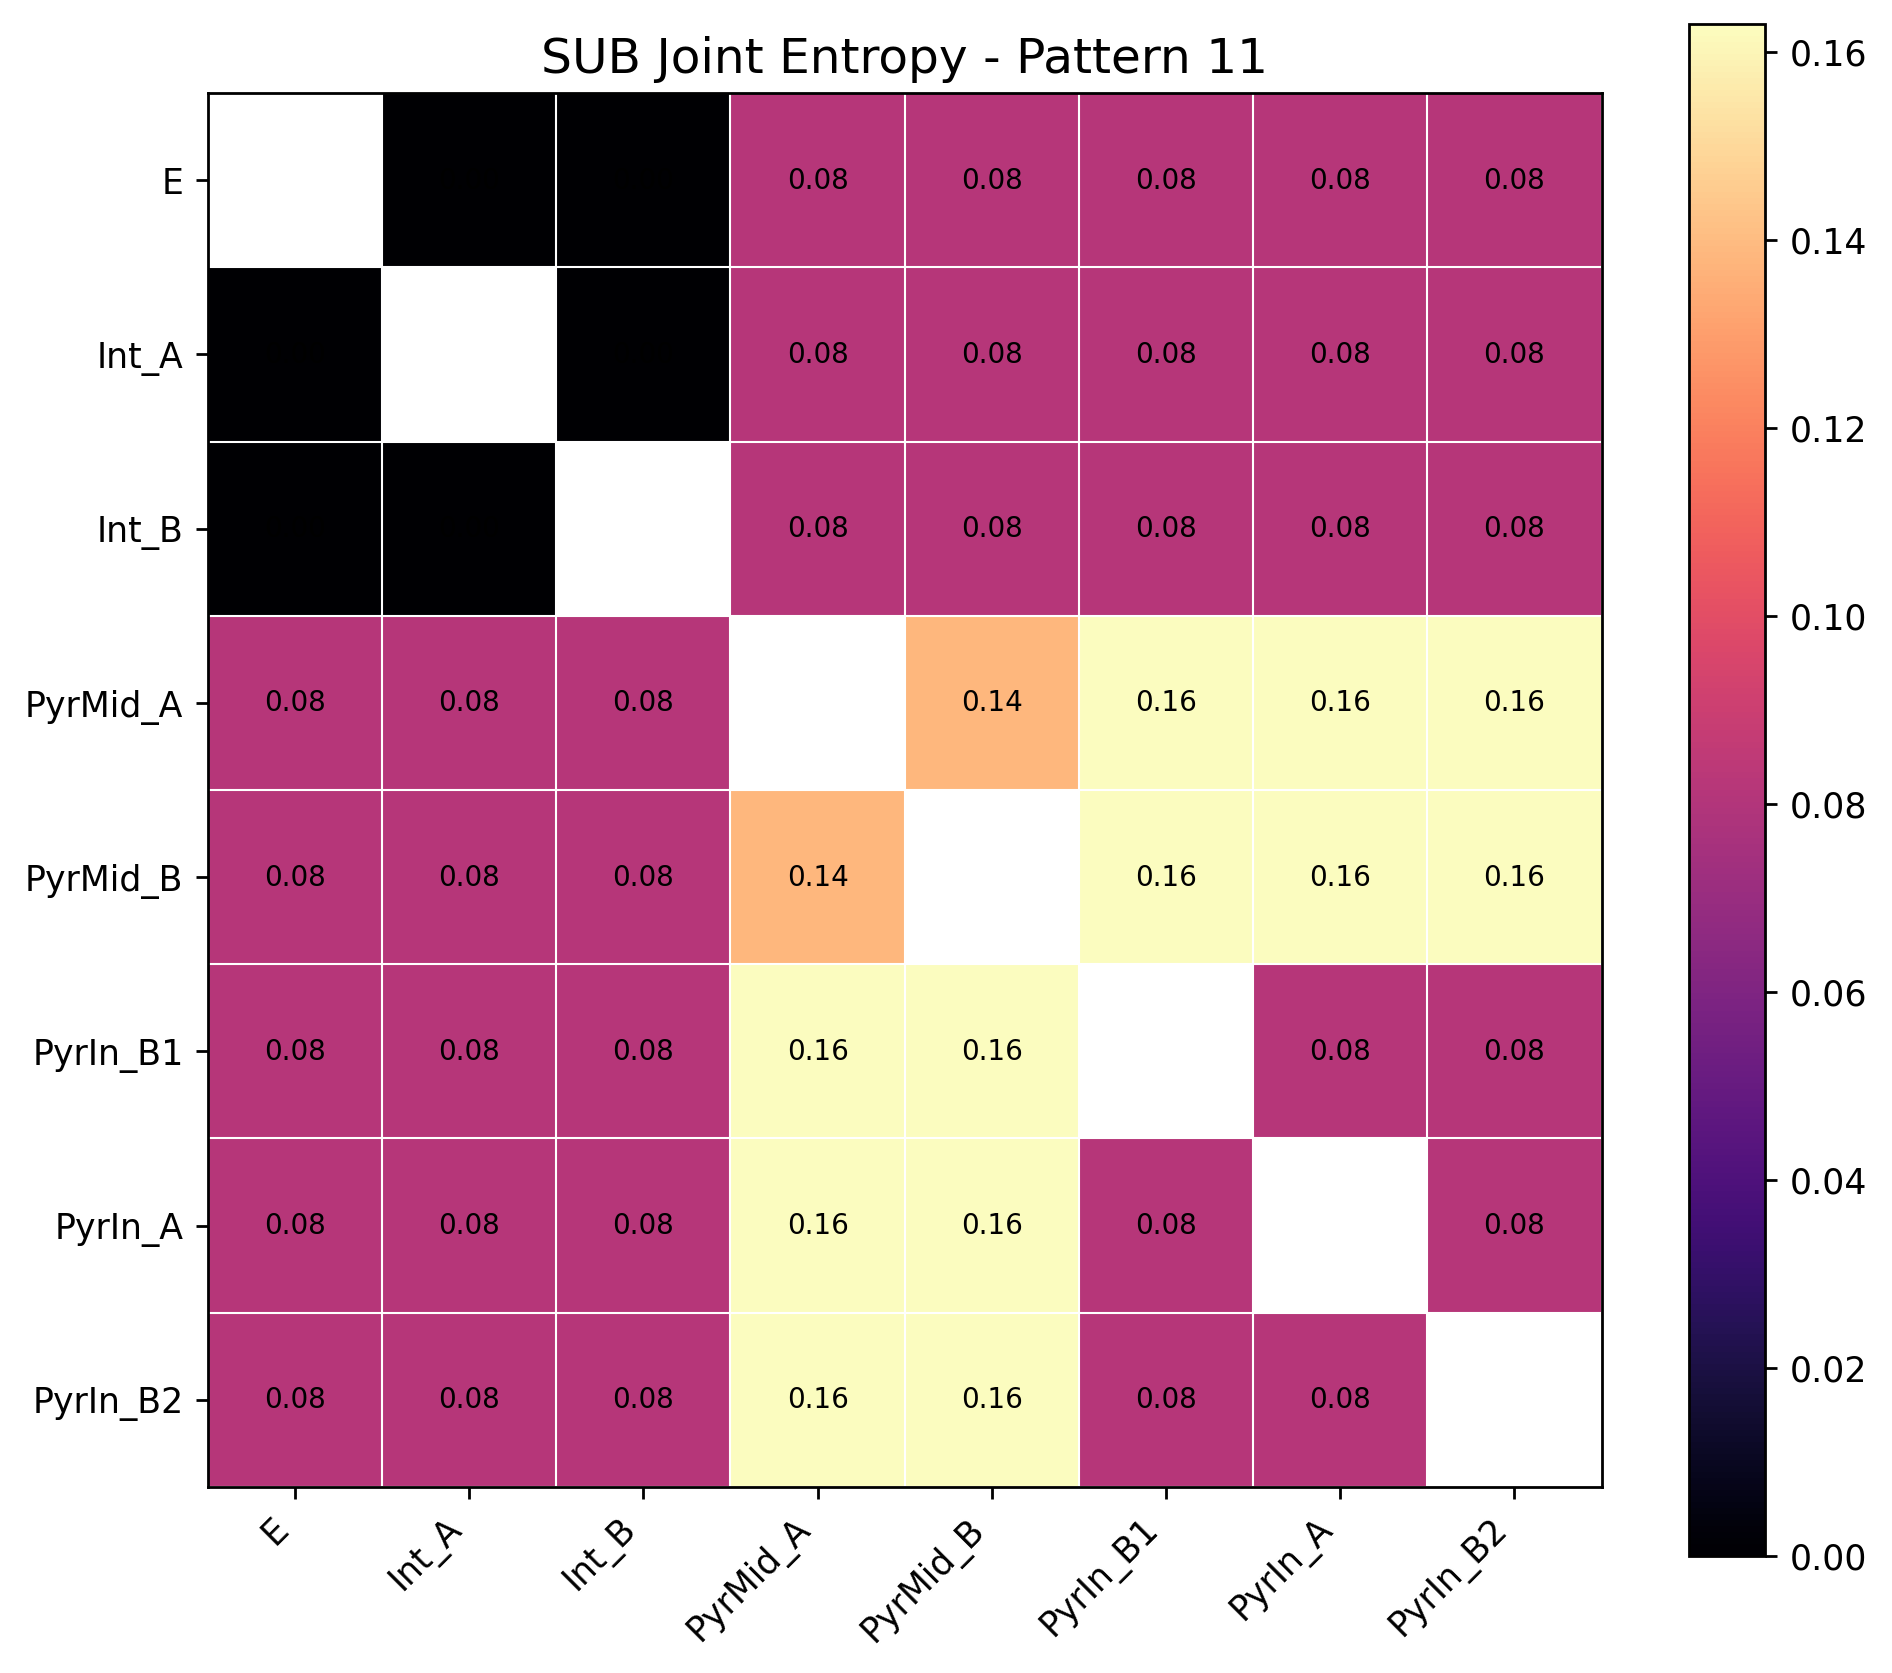

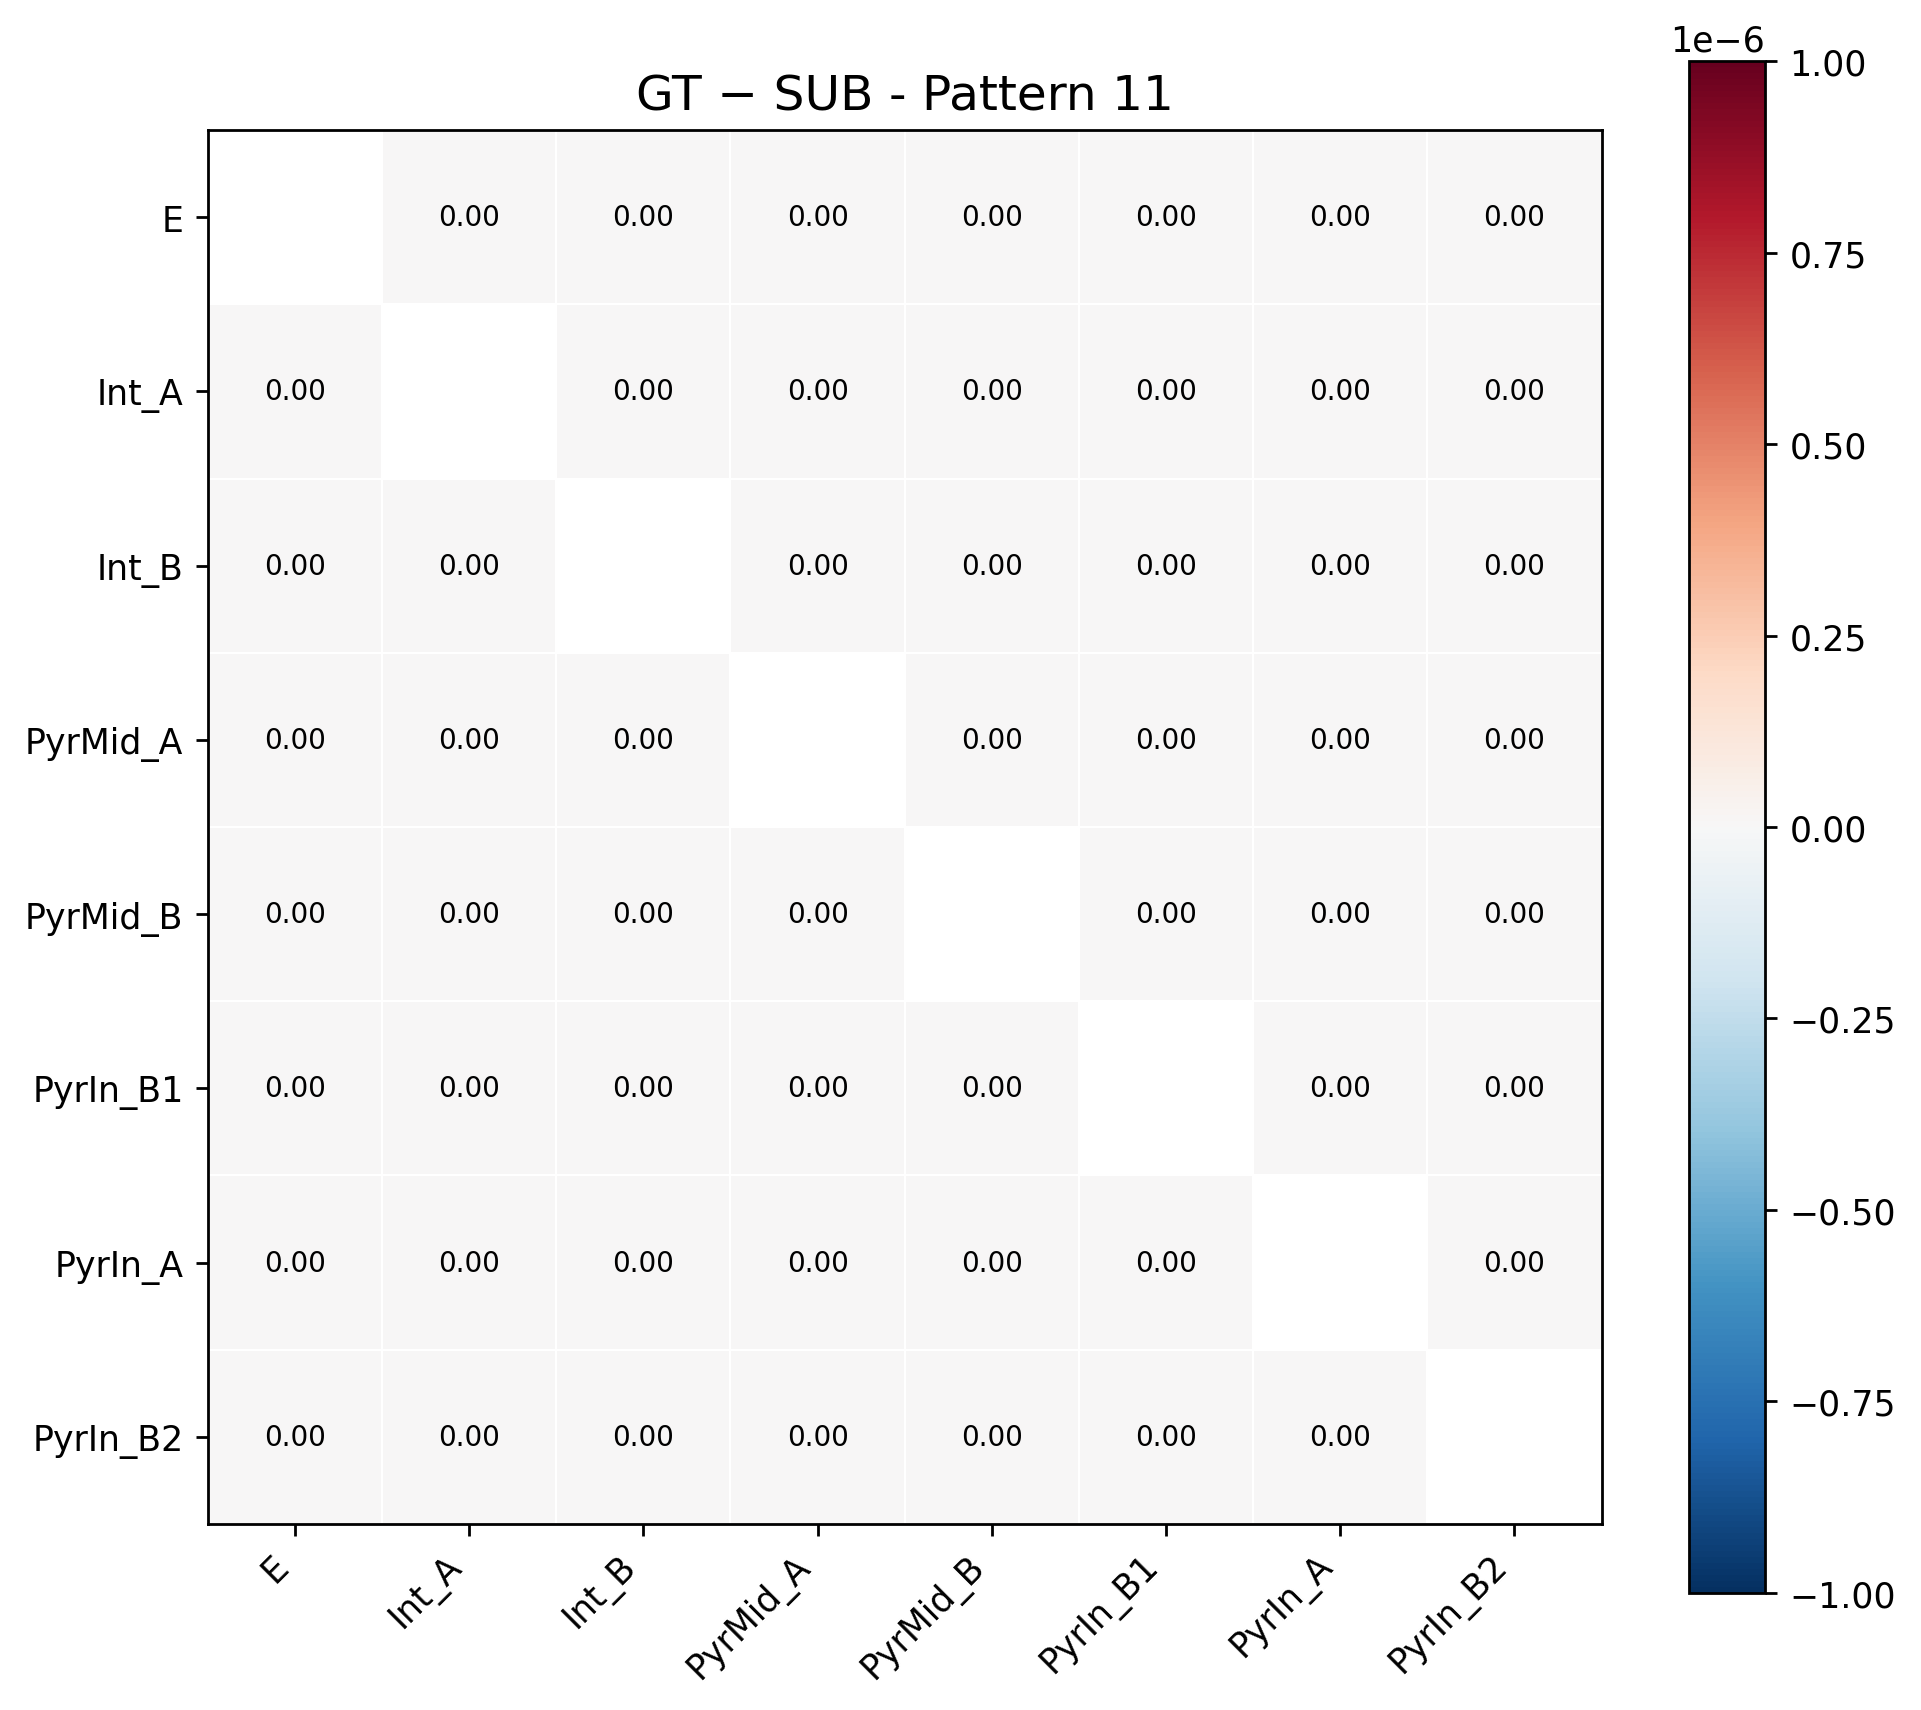

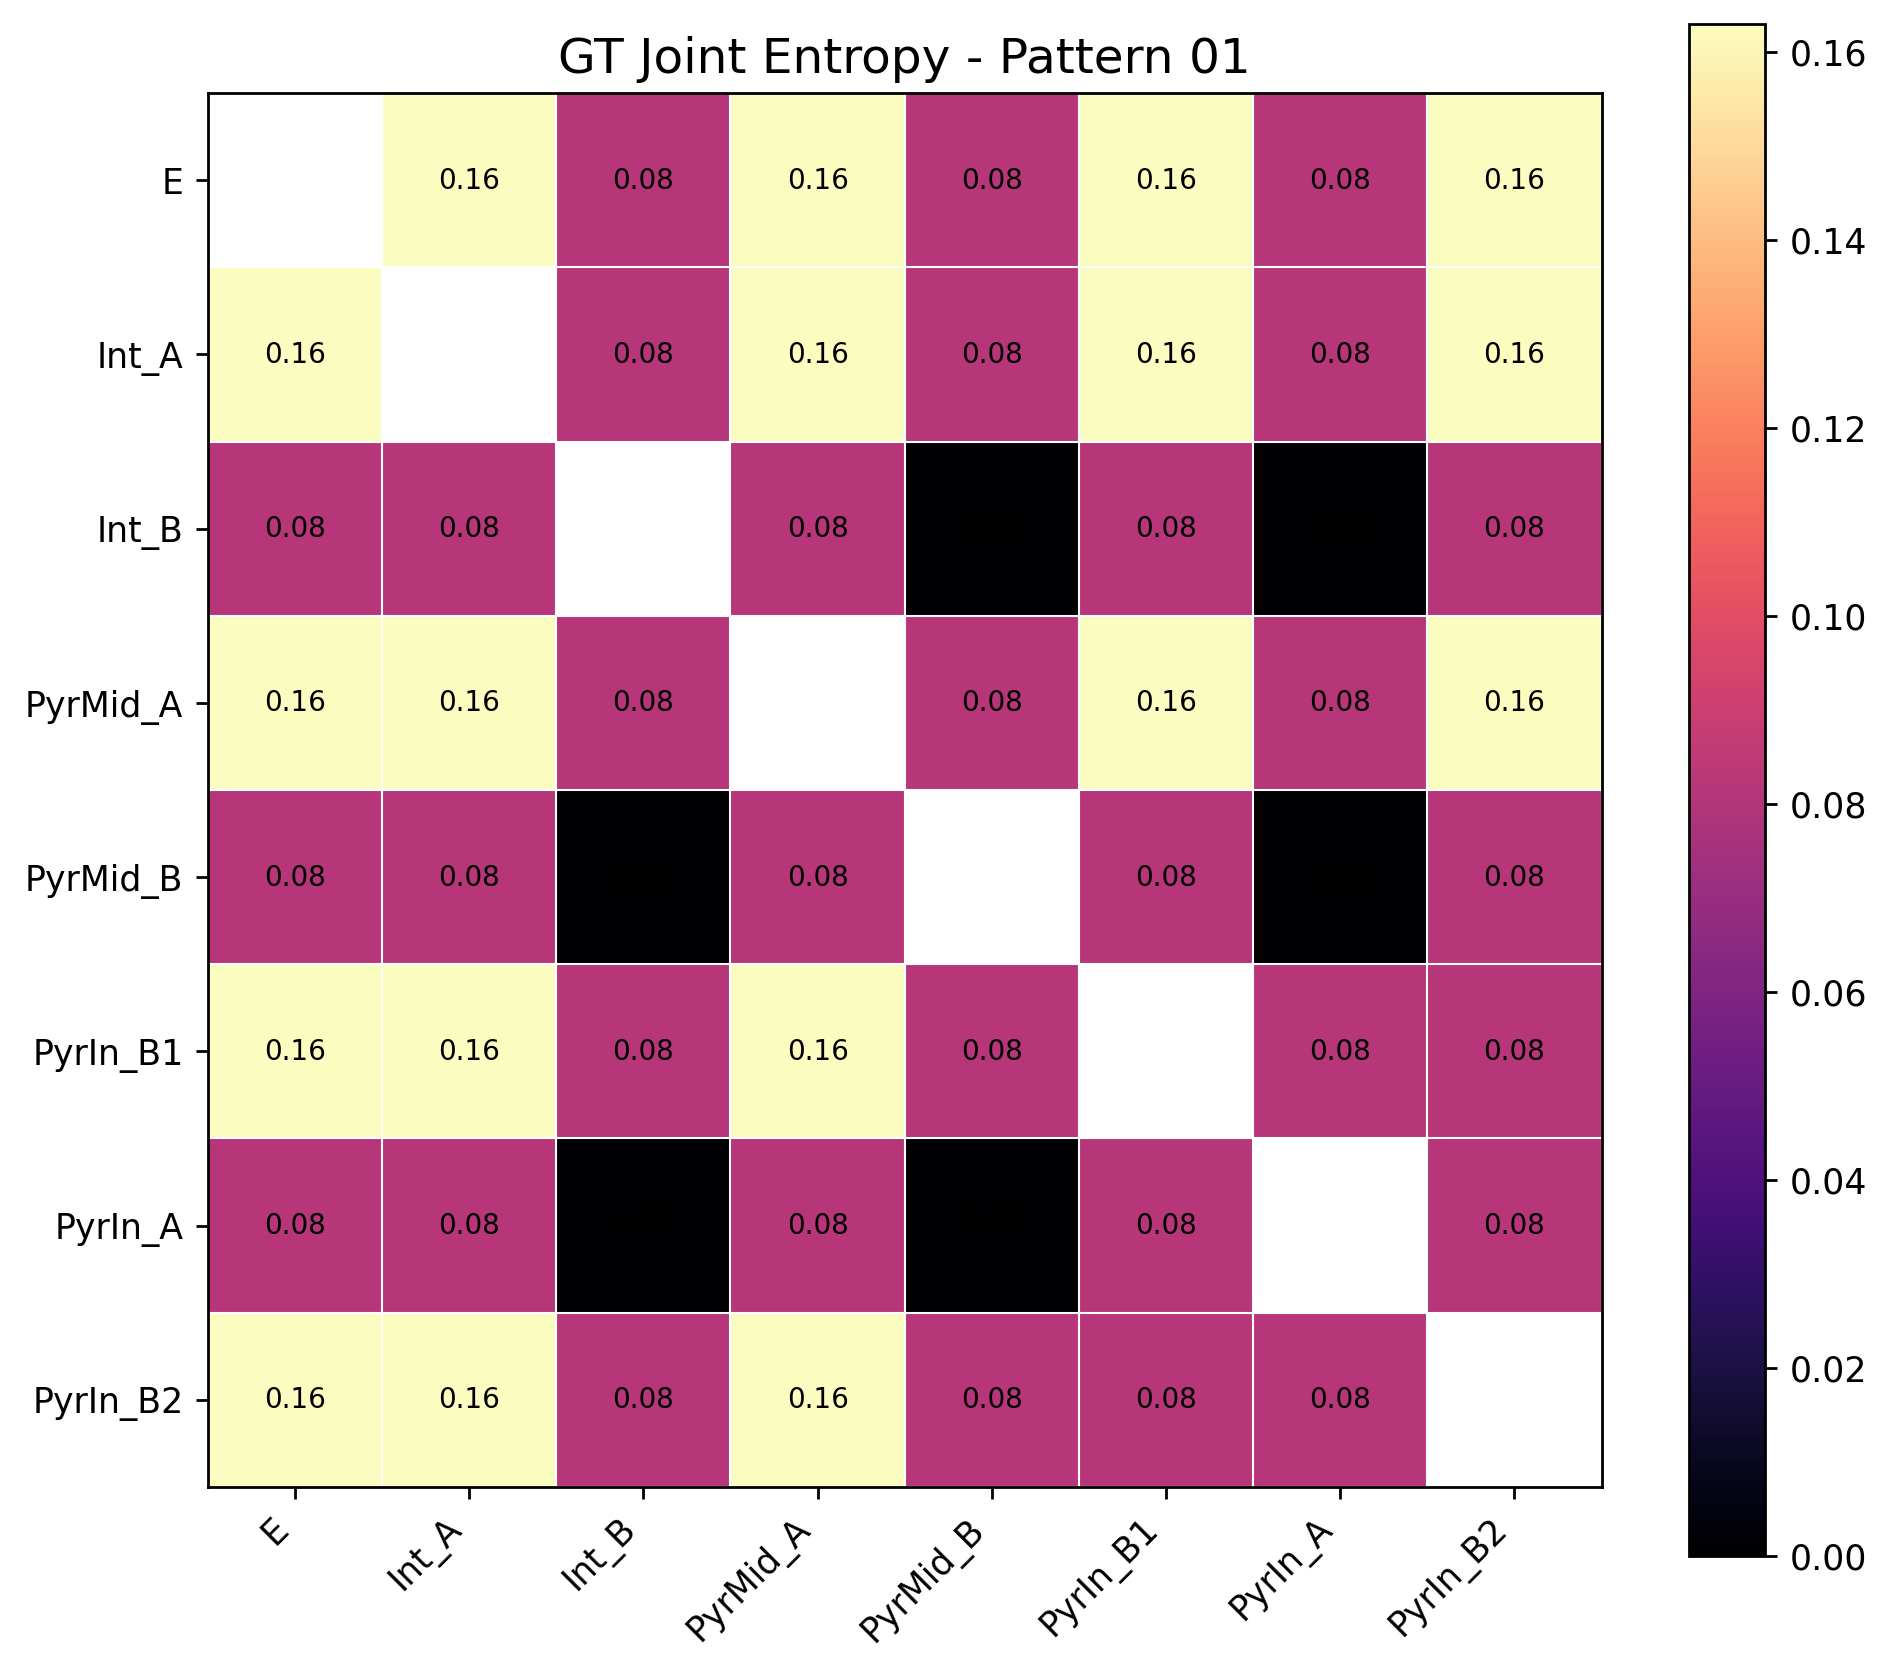

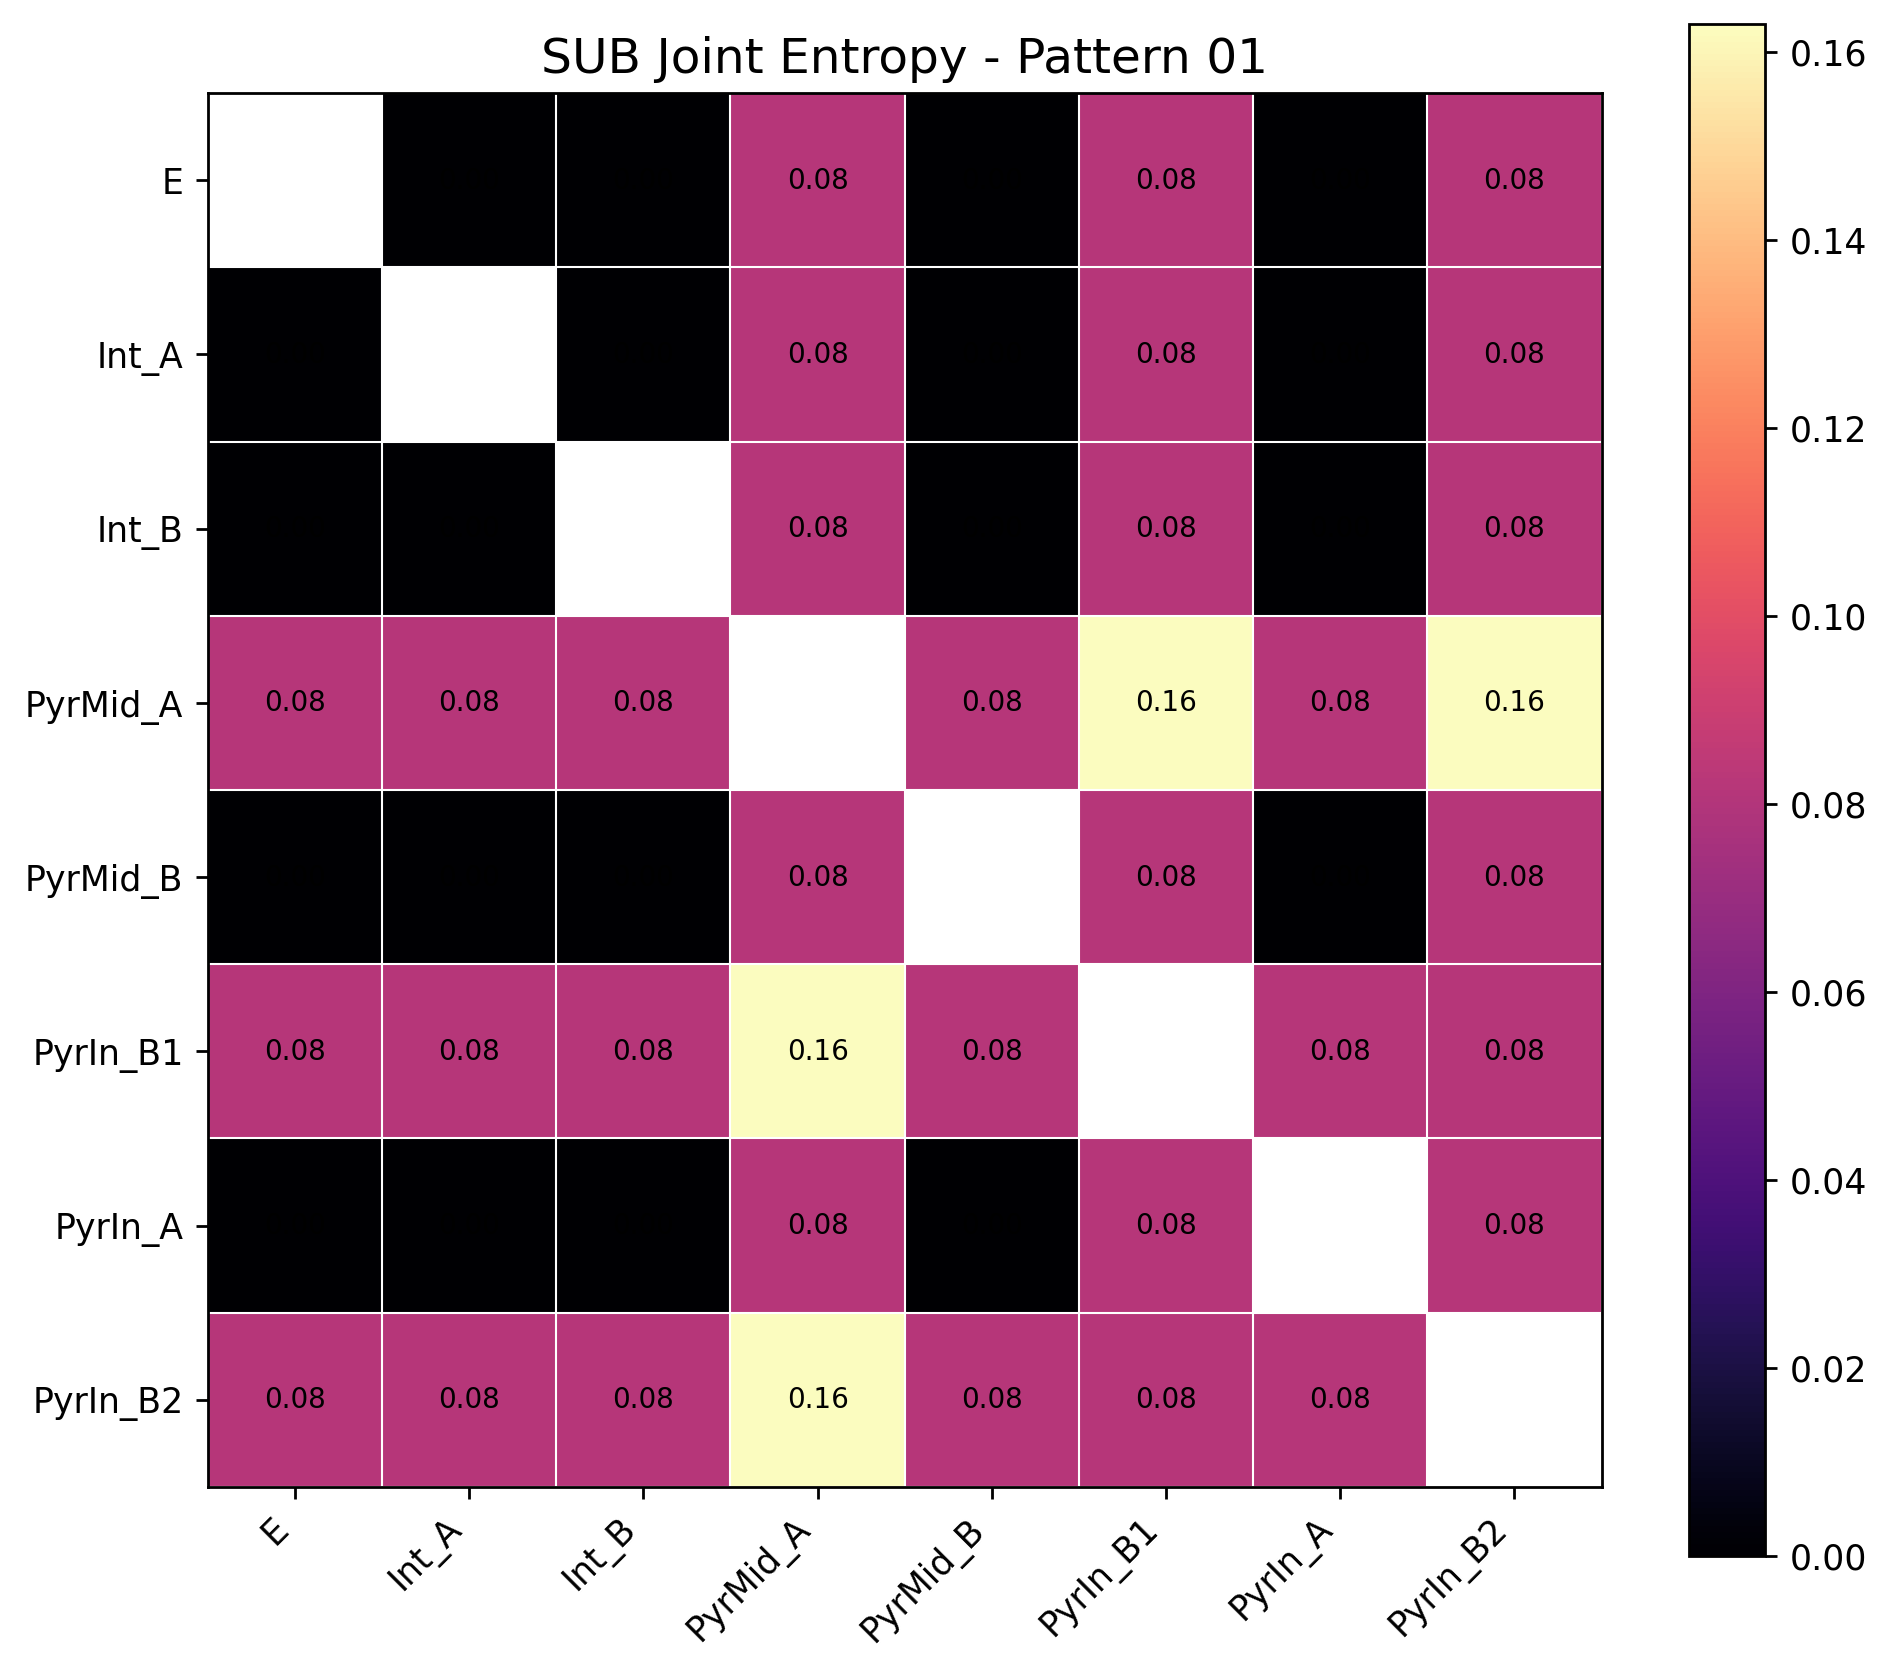

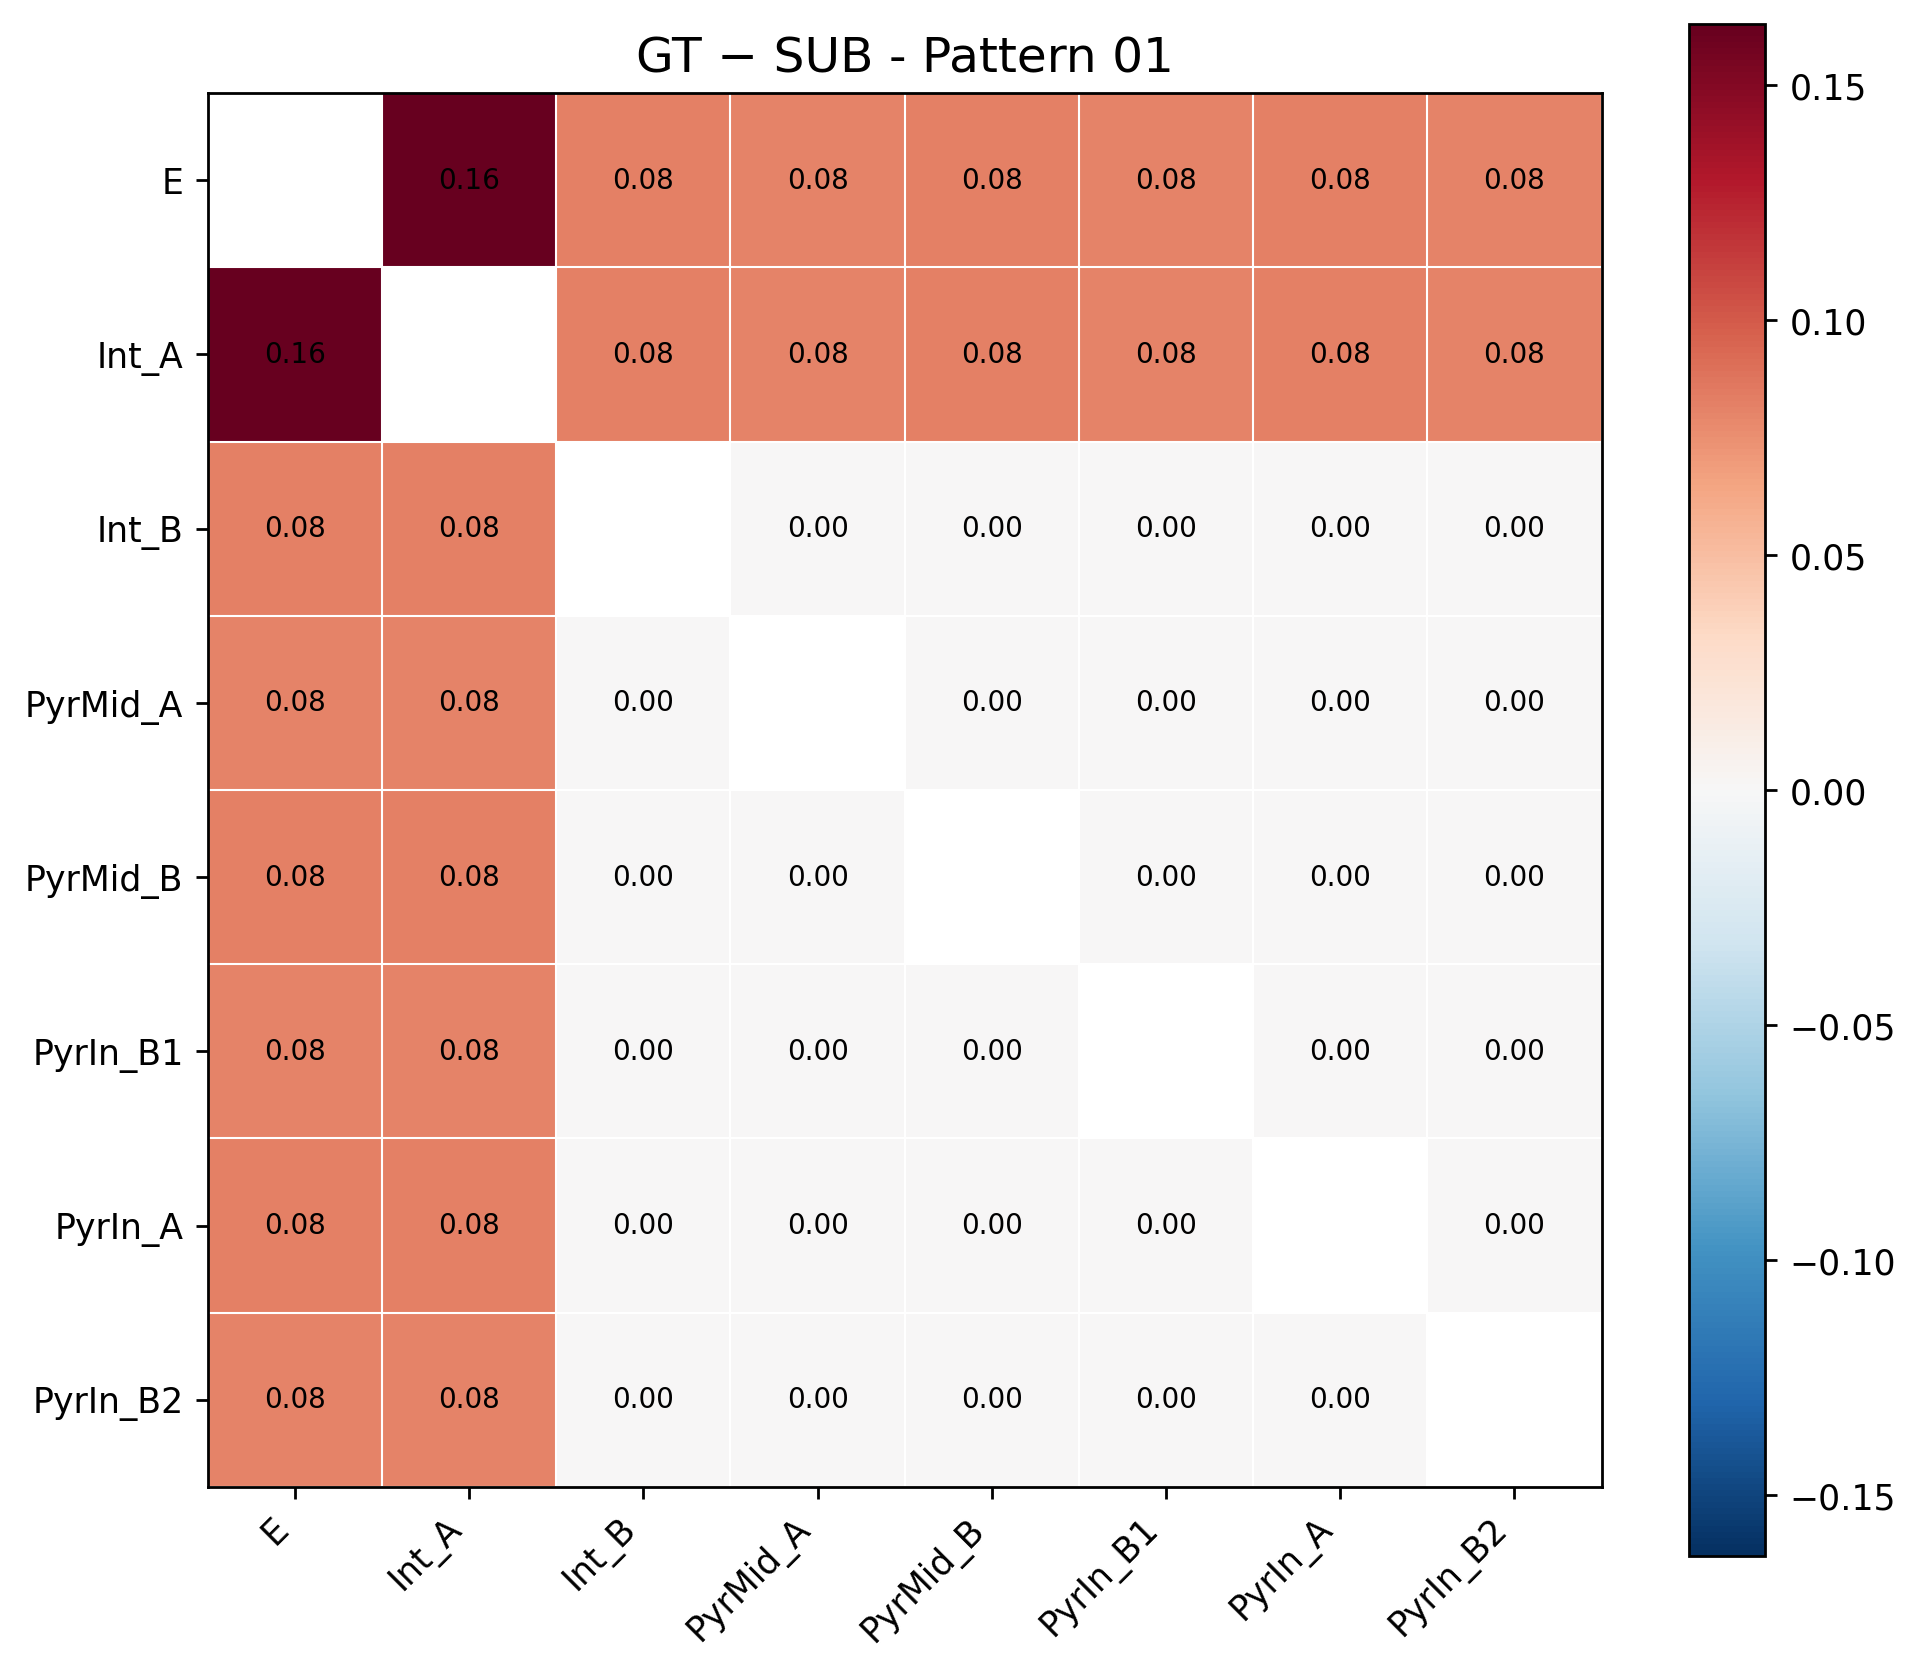

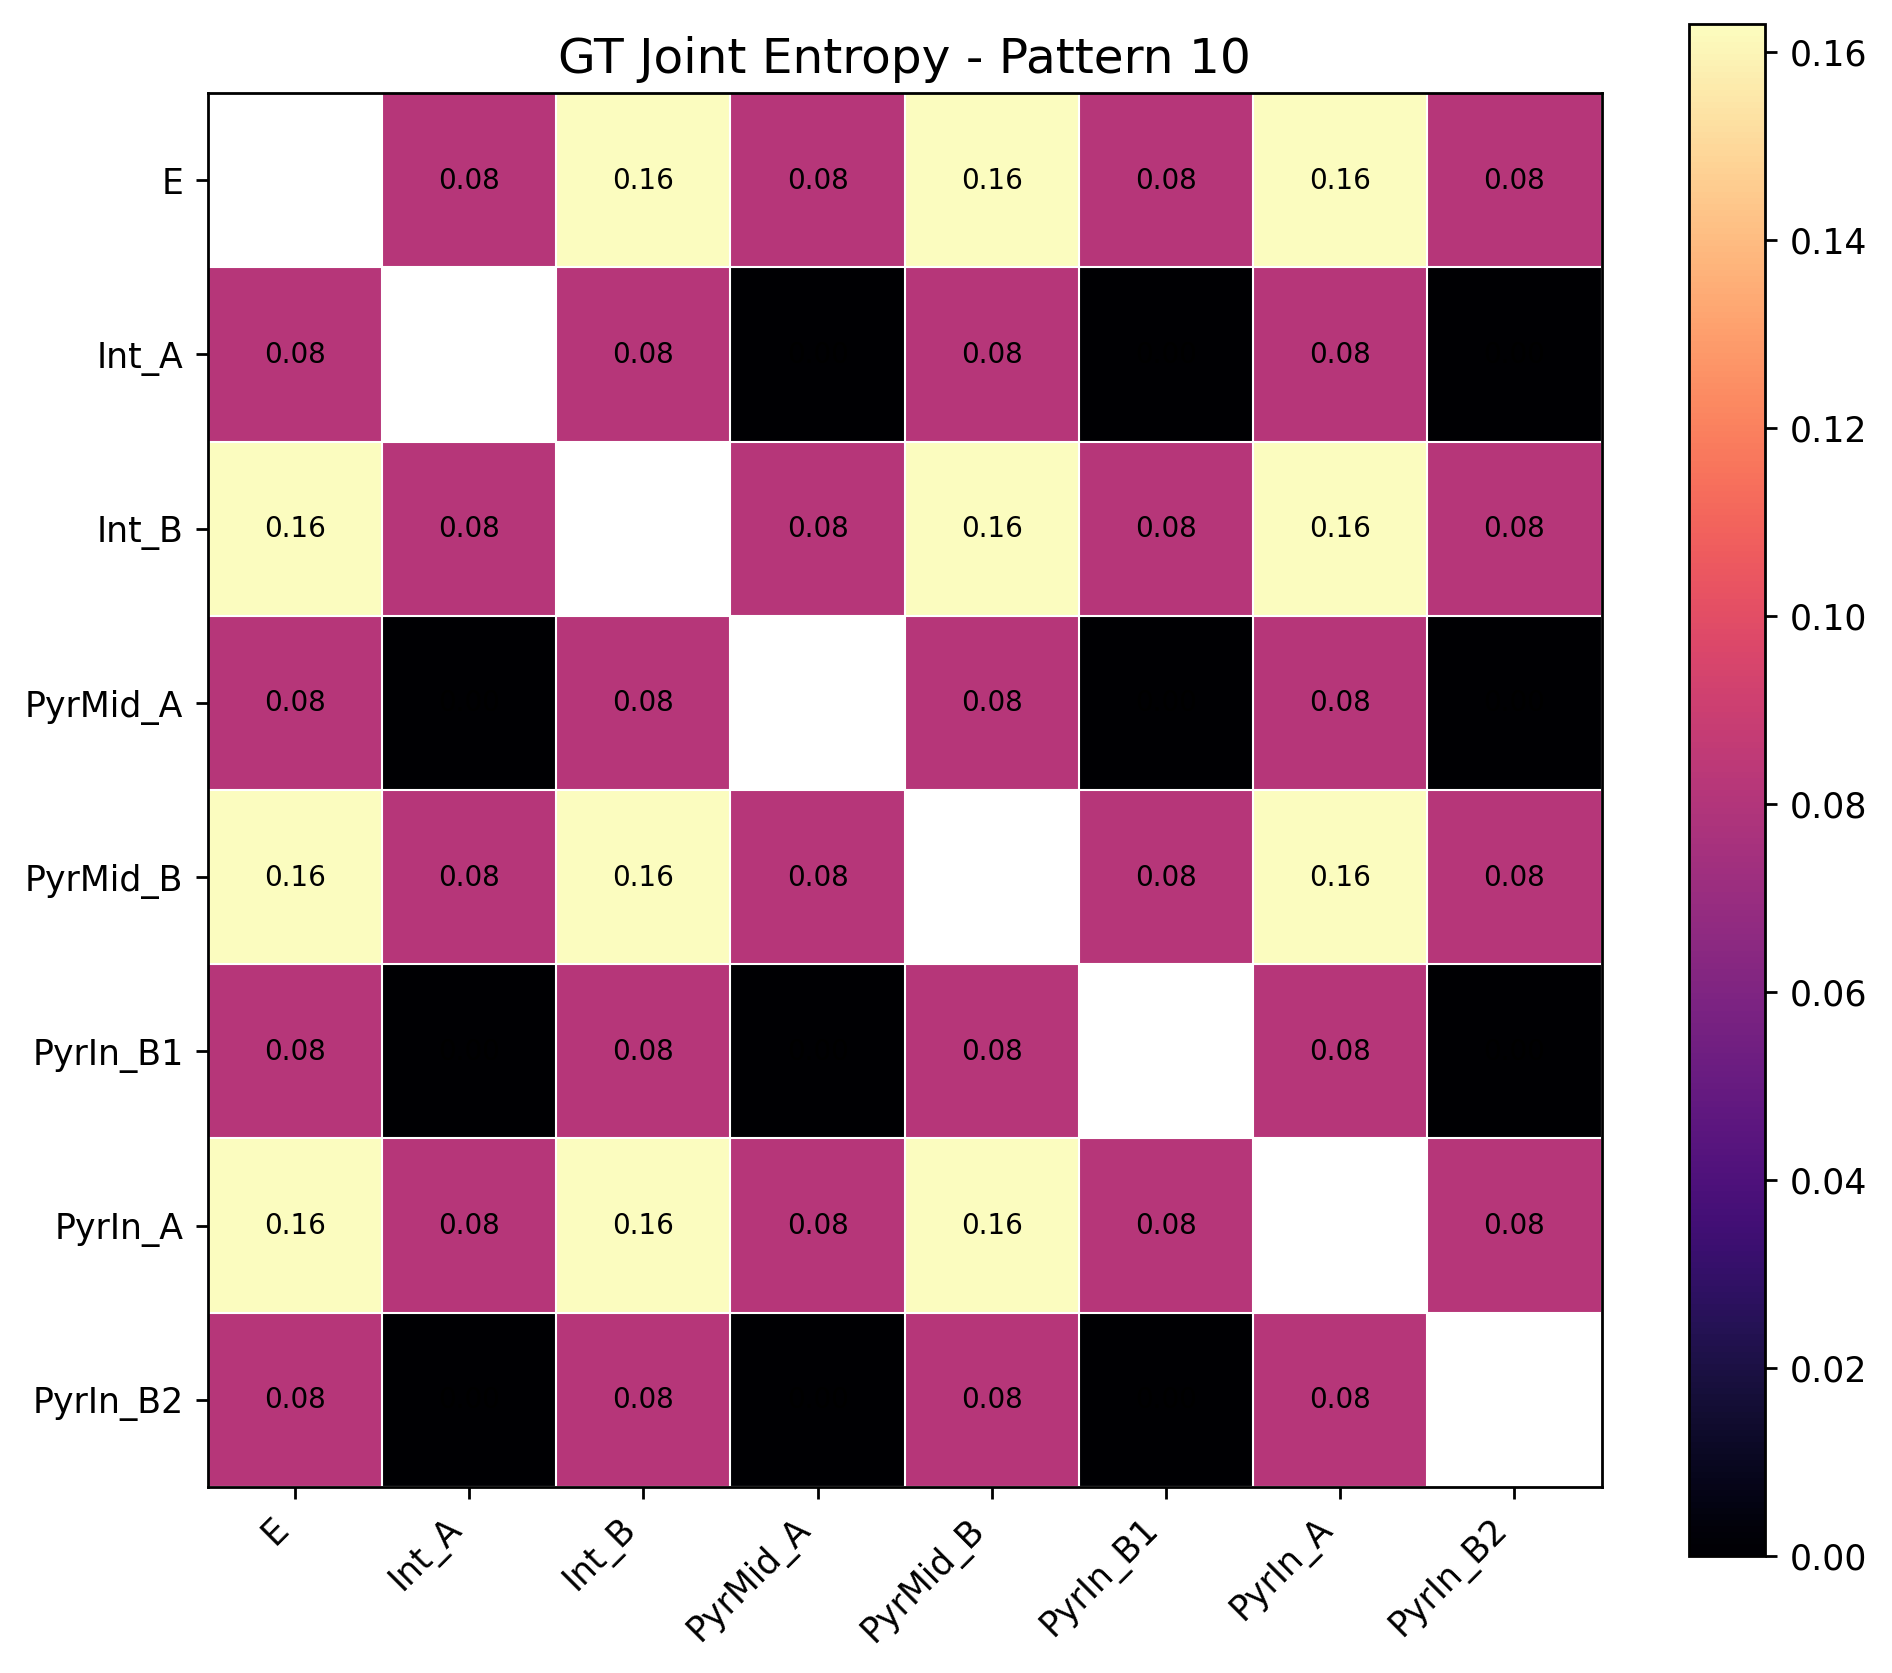

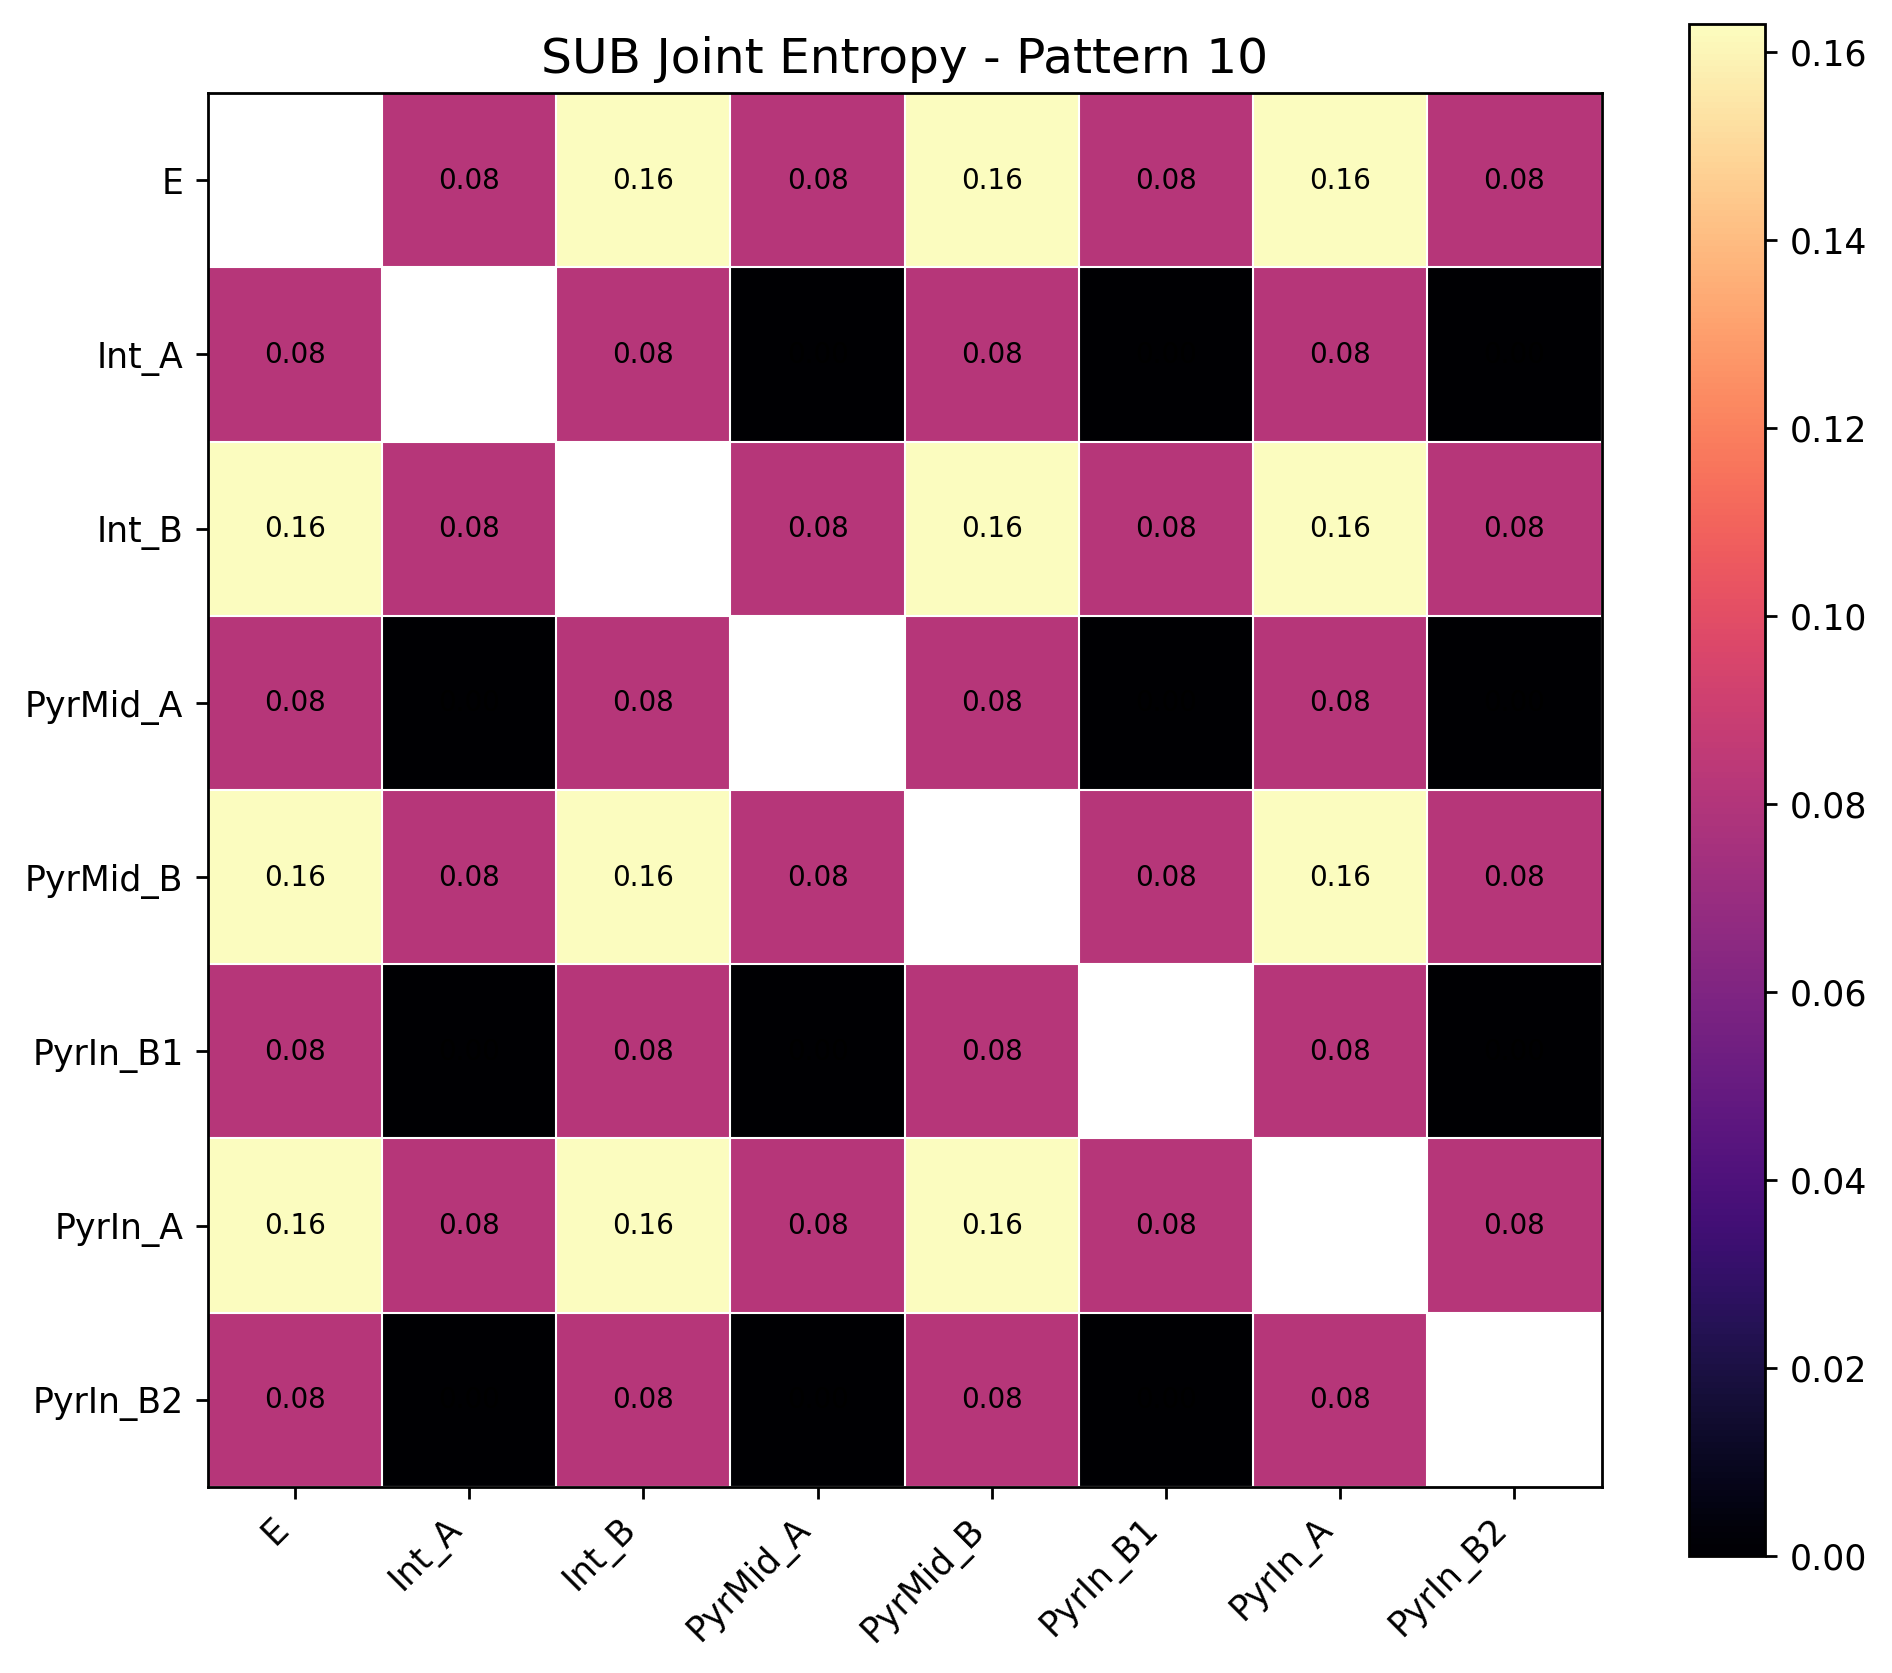

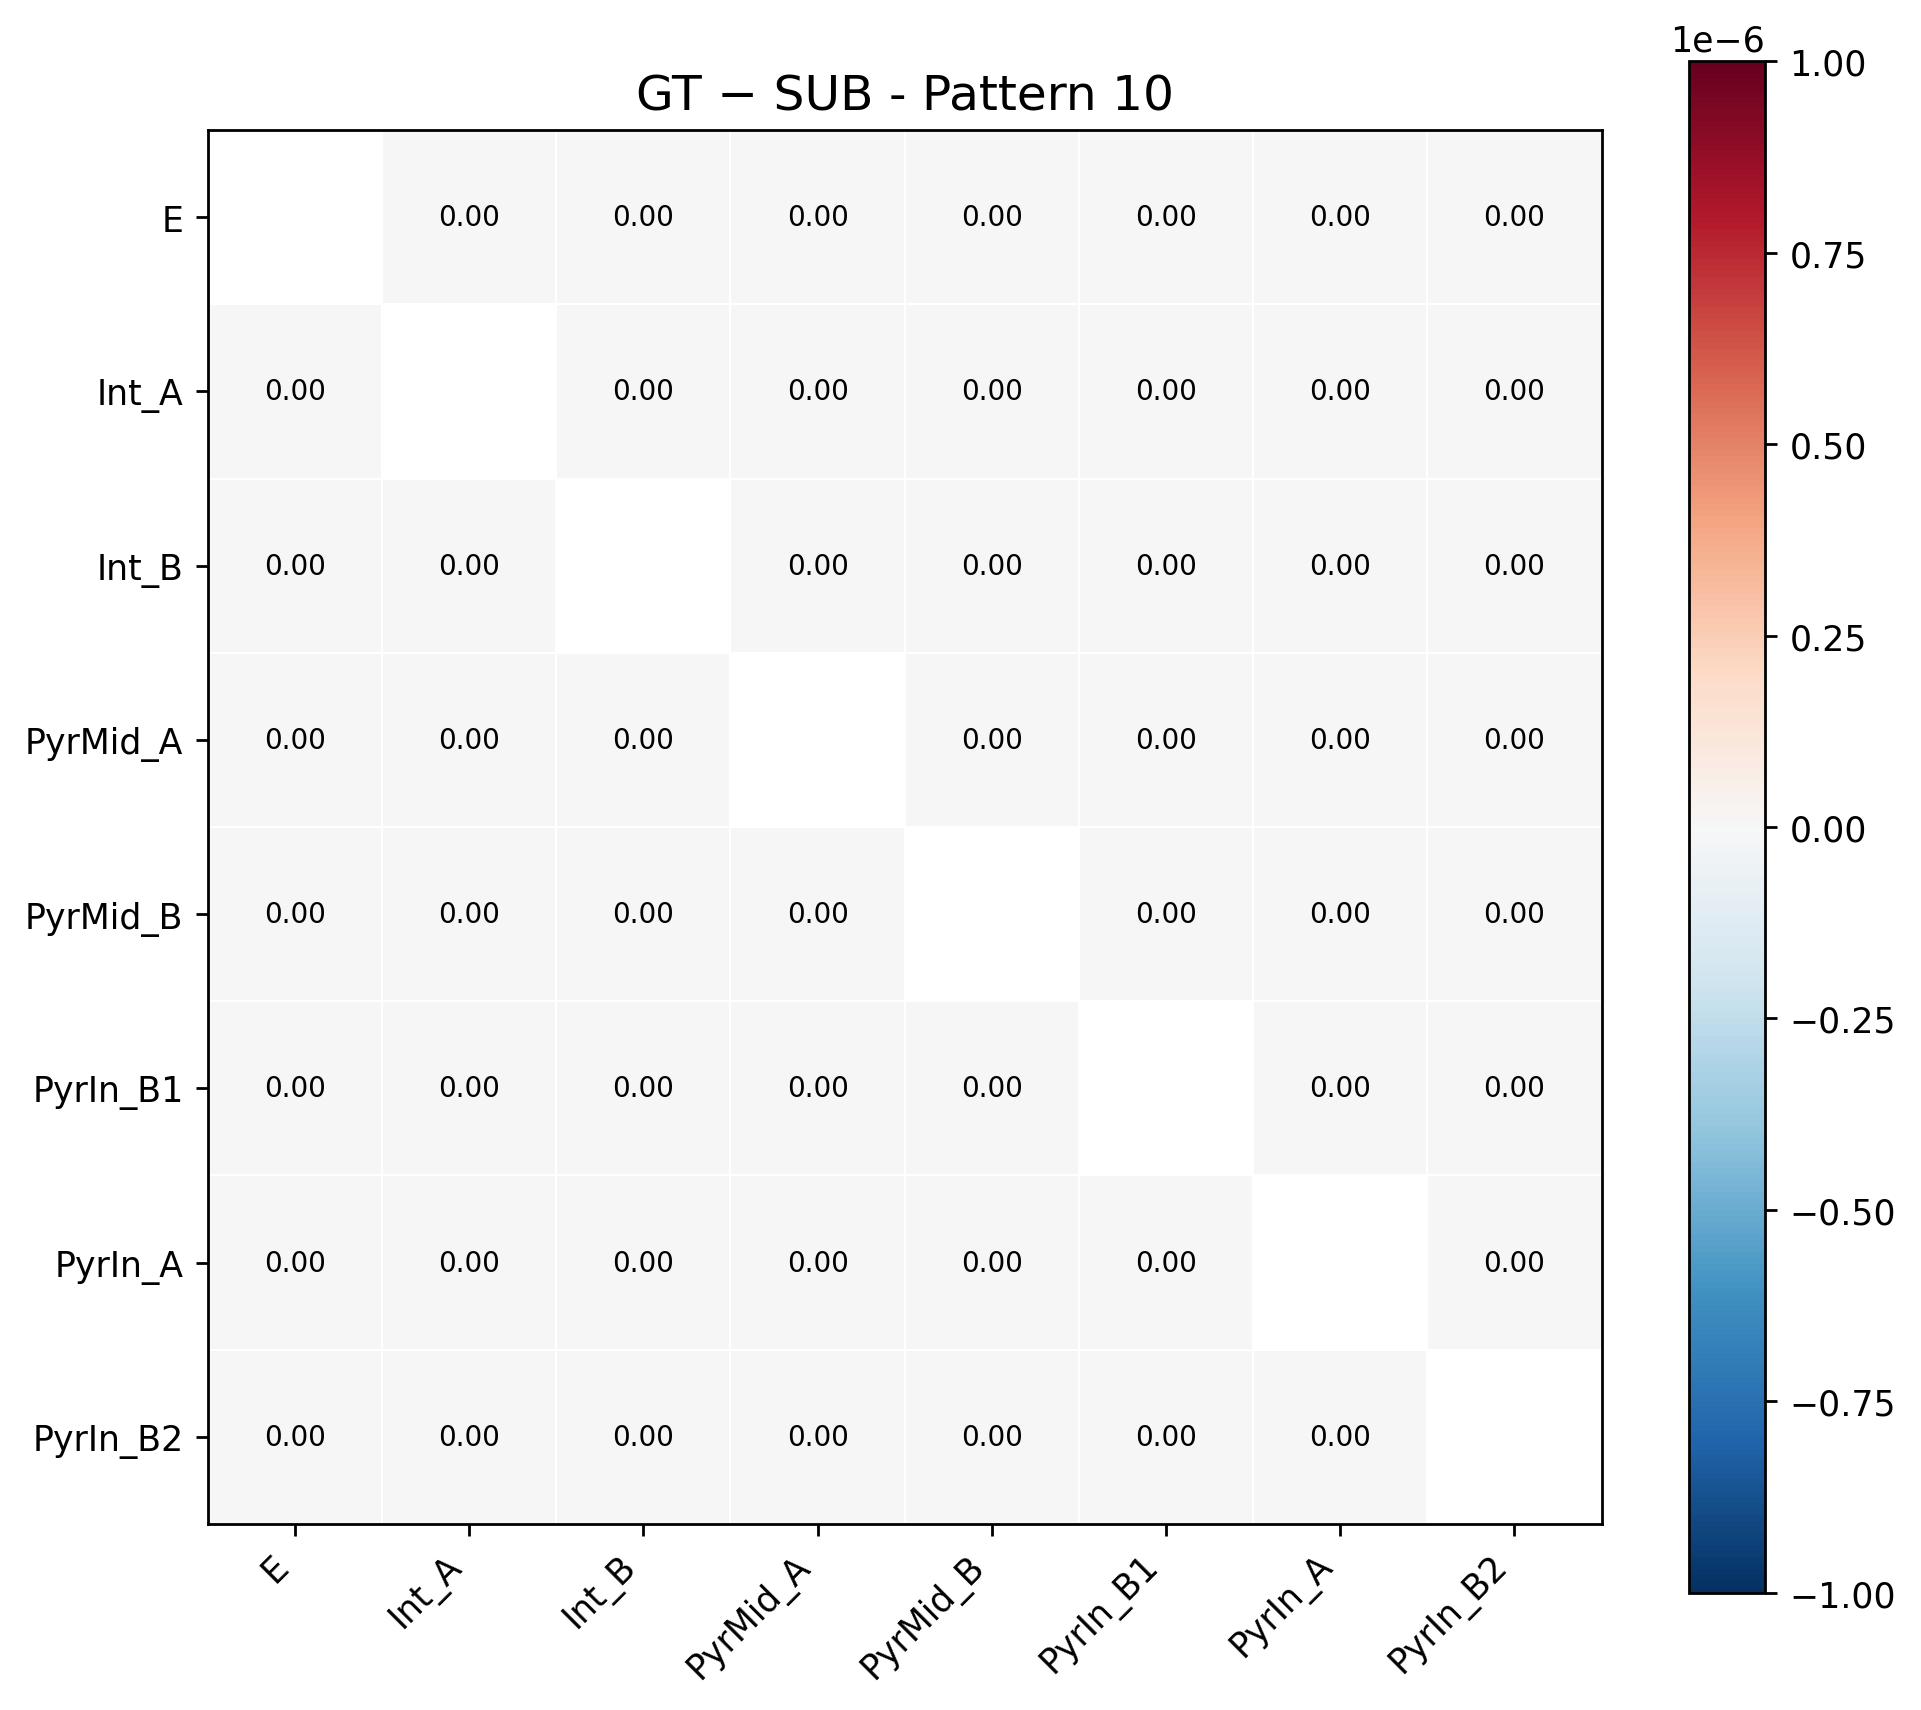

In [ ]:
#Joint Entropy

# Pairwise joint entropy H(Y_i, Y_j) for all neuron pairs, per XOR pattern.
#
# Entry [j, i] = H(Y_i, Y_j) in bits.
# Diagonal = H(Y_i) - marginal entropy of neuron i (set to NaN for clarity).
#
# High H(Y_i, Y_j) => neurons i and j are independently active
# Low  H(Y_i, Y_j) => neurons i and j tend to co-activate (coordinated)
# GT[j,i] - SUB[j,i] => how much coordination changed due to perturbation
#
# Note: symmetric - H(Y_i, Y_j) = H(Y_j, Y_i)
# Use CE for asymmetric (directed) conditioning.
#
# Bias correction: Miller-Madow via entropy_from_counts()
# Bins: 1ms native resolution
# Scope: spiking neurons only, per XOR pattern

import numpy as np
import pandas as pd


def _counts_1(x: np.ndarray) -> np.ndarray:
    return np.bincount(x.astype(int), minlength=2).astype(float)

def _counts_2(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    return np.bincount(2 * x.astype(int) + y.astype(int), minlength=4).astype(float)


def _joint_entropy_pair(arr_i: np.ndarray, arr_j: np.ndarray) -> float:
    """
    H(Y_i, Y_j) — pairwise joint entropy in bits.
    Miller-Madow corrected.
    """
    N  = len(arr_i)
    jc = _counts_2(arr_i, arr_j)
    return entropy_from_counts(jc, N)


def _marginal_entropy(arr: np.ndarray) -> float:
    """H(Y_i) — marginal entropy in bits. Miller-Madow corrected."""
    N  = len(arr)
    mc = _counts_1(arr)
    return entropy_from_counts(mc, N)

def compute_marginal_entropies(trials: list, spike_cols: list[str]) -> np.ndarray:
    """Returns H(Y_i) for each neuron — shape (N,)"""
    N = len(spike_cols)
    arrays = {}
    for col in spike_cols:
        pieces = [df[col].to_numpy(dtype=int) for df in trials if col in df.columns]
        arrays[col] = np.concatenate(pieces) if pieces else np.zeros(0, dtype=int)
    
    return np.array([_marginal_entropy(arrays[col]) for col in spike_cols])
    
def compute_JE_matrix(trials: list, spike_cols: list[str]) -> np.ndarray:
    """
    Compute N x N pairwise joint entropy matrix H(Y_i, Y_j).

    Entry [j, i] = H(Y_i, Y_j) in bits.
    Diagonal    = NaN (marginal H(Y_i) excluded for clarity — not a pair).
    Symmetric   : JE[j, i] == JE[i, j].

    Parameters
    ----------
    trials : list of pd.DataFrame
        All trials for one pattern concatenated.
    spike_cols : list of str
        Spike column names for active neurons.

    Returns
    -------
    np.ndarray : shape (N, N).
    """
    N = len(spike_cols)

    # concatenate all trials into one array per neuron
    arrays = {}
    for col in spike_cols:
        pieces = [df[col].to_numpy(dtype=int) for df in trials if col in df.columns]
        arrays[col] = np.concatenate(pieces) if pieces else np.zeros(0, dtype=int)

    JE = np.full((N, N), np.nan)

    for j in range(N):
        for i in range(N):
            if i == j:
                JE[j, i] = np.nan   # diagonal excluded
                continue
            if not np.isnan(JE[i, j]):
                JE[j, i] = JE[i, j]  # exploit symmetry
                continue
            JE[j, i] = _joint_entropy_pair(
                arrays[spike_cols[i]],
                arrays[spike_cols[j]]
            )

    return JE

def je_compute():
    """
    Pairwise joint entropy H(Y_i, Y_j) per XOR pattern.

    Returns MetricResult where:
        gt_values  : (n_patterns, N, N) joint entropy matrices for GT
        sub_values : (n_patterns, N, N) joint entropy matrices for SUB
        score      : 1 - mean absolute difference across all pairs/patterns
        meta       : per-pattern GT/SUB/diff matrices + labels + patterns
    """

    patterns   = gt_data["case"].unique().tolist()
    neurons    = hp.get_spiking_neurons(cfg,gt_data)
    spike_cols = [f"{n}_spike" for n in neurons]

    je_meta  = {"patterns": patterns, "spike_cols": spike_cols}
    gt_mats  = []
    sub_mats = []

    for p in patterns:
        gt_trials  = [gt_data[gt_data["case"] == p]]
        sub_trials = [sub_data[sub_data["case"] == p]]

        gt_JE  = compute_JE_matrix(gt_trials,  spike_cols)
        sub_JE = compute_JE_matrix(sub_trials, spike_cols)

        je_meta[p] = {
            "gt":   gt_JE,
            "sub":  sub_JE,
            "diff": gt_JE - sub_JE,
        }
        gt_mats.append(gt_JE)
        sub_mats.append(sub_JE)

    gt_arr  = np.stack(gt_mats)    # (n_patterns, N, N)
    sub_arr = np.stack(sub_mats)

    diff    = np.nanmean(np.abs(gt_arr - sub_arr))
    score   = float(1.0 - np.clip(diff, 0.0, 1.0))

    return gt_arr, sub_arr, score, je_meta



je_result = je_compute()
_, _, _, meta = je_result

patterns = meta["patterns"]
labels = [c.replace("_spike", "") for c in meta["spike_cols"]]

for pattern in patterns:

    gt = meta[pattern]["gt"]
    sub = meta[pattern]["sub"]
    diff = meta[pattern]["diff"]

    vmax = max(np.nanmax(gt), np.nanmax(sub))
    vmin = min(np.nanmin(gt), np.nanmin(sub))

    diff_lim = np.nanmax(np.abs(diff))
    if diff_lim == 0:
        diff_lim = 1e-6

    plot_single_heatmap(
        gt,
        f"GT Joint Entropy - Pattern {pattern}",
        labels,
        "magma",
        vmin,
        vmax,
    )

    plot_single_heatmap(
        sub,
        f"SUB Joint Entropy - Pattern {pattern}",
        labels,
        "magma",
        vmin,
        vmax,
    )

    plot_single_heatmap(
        diff,
        f"GT − SUB - Pattern {pattern}",
        labels,
        "RdBu_r",
        -diff_lim,
        diff_lim,
    )


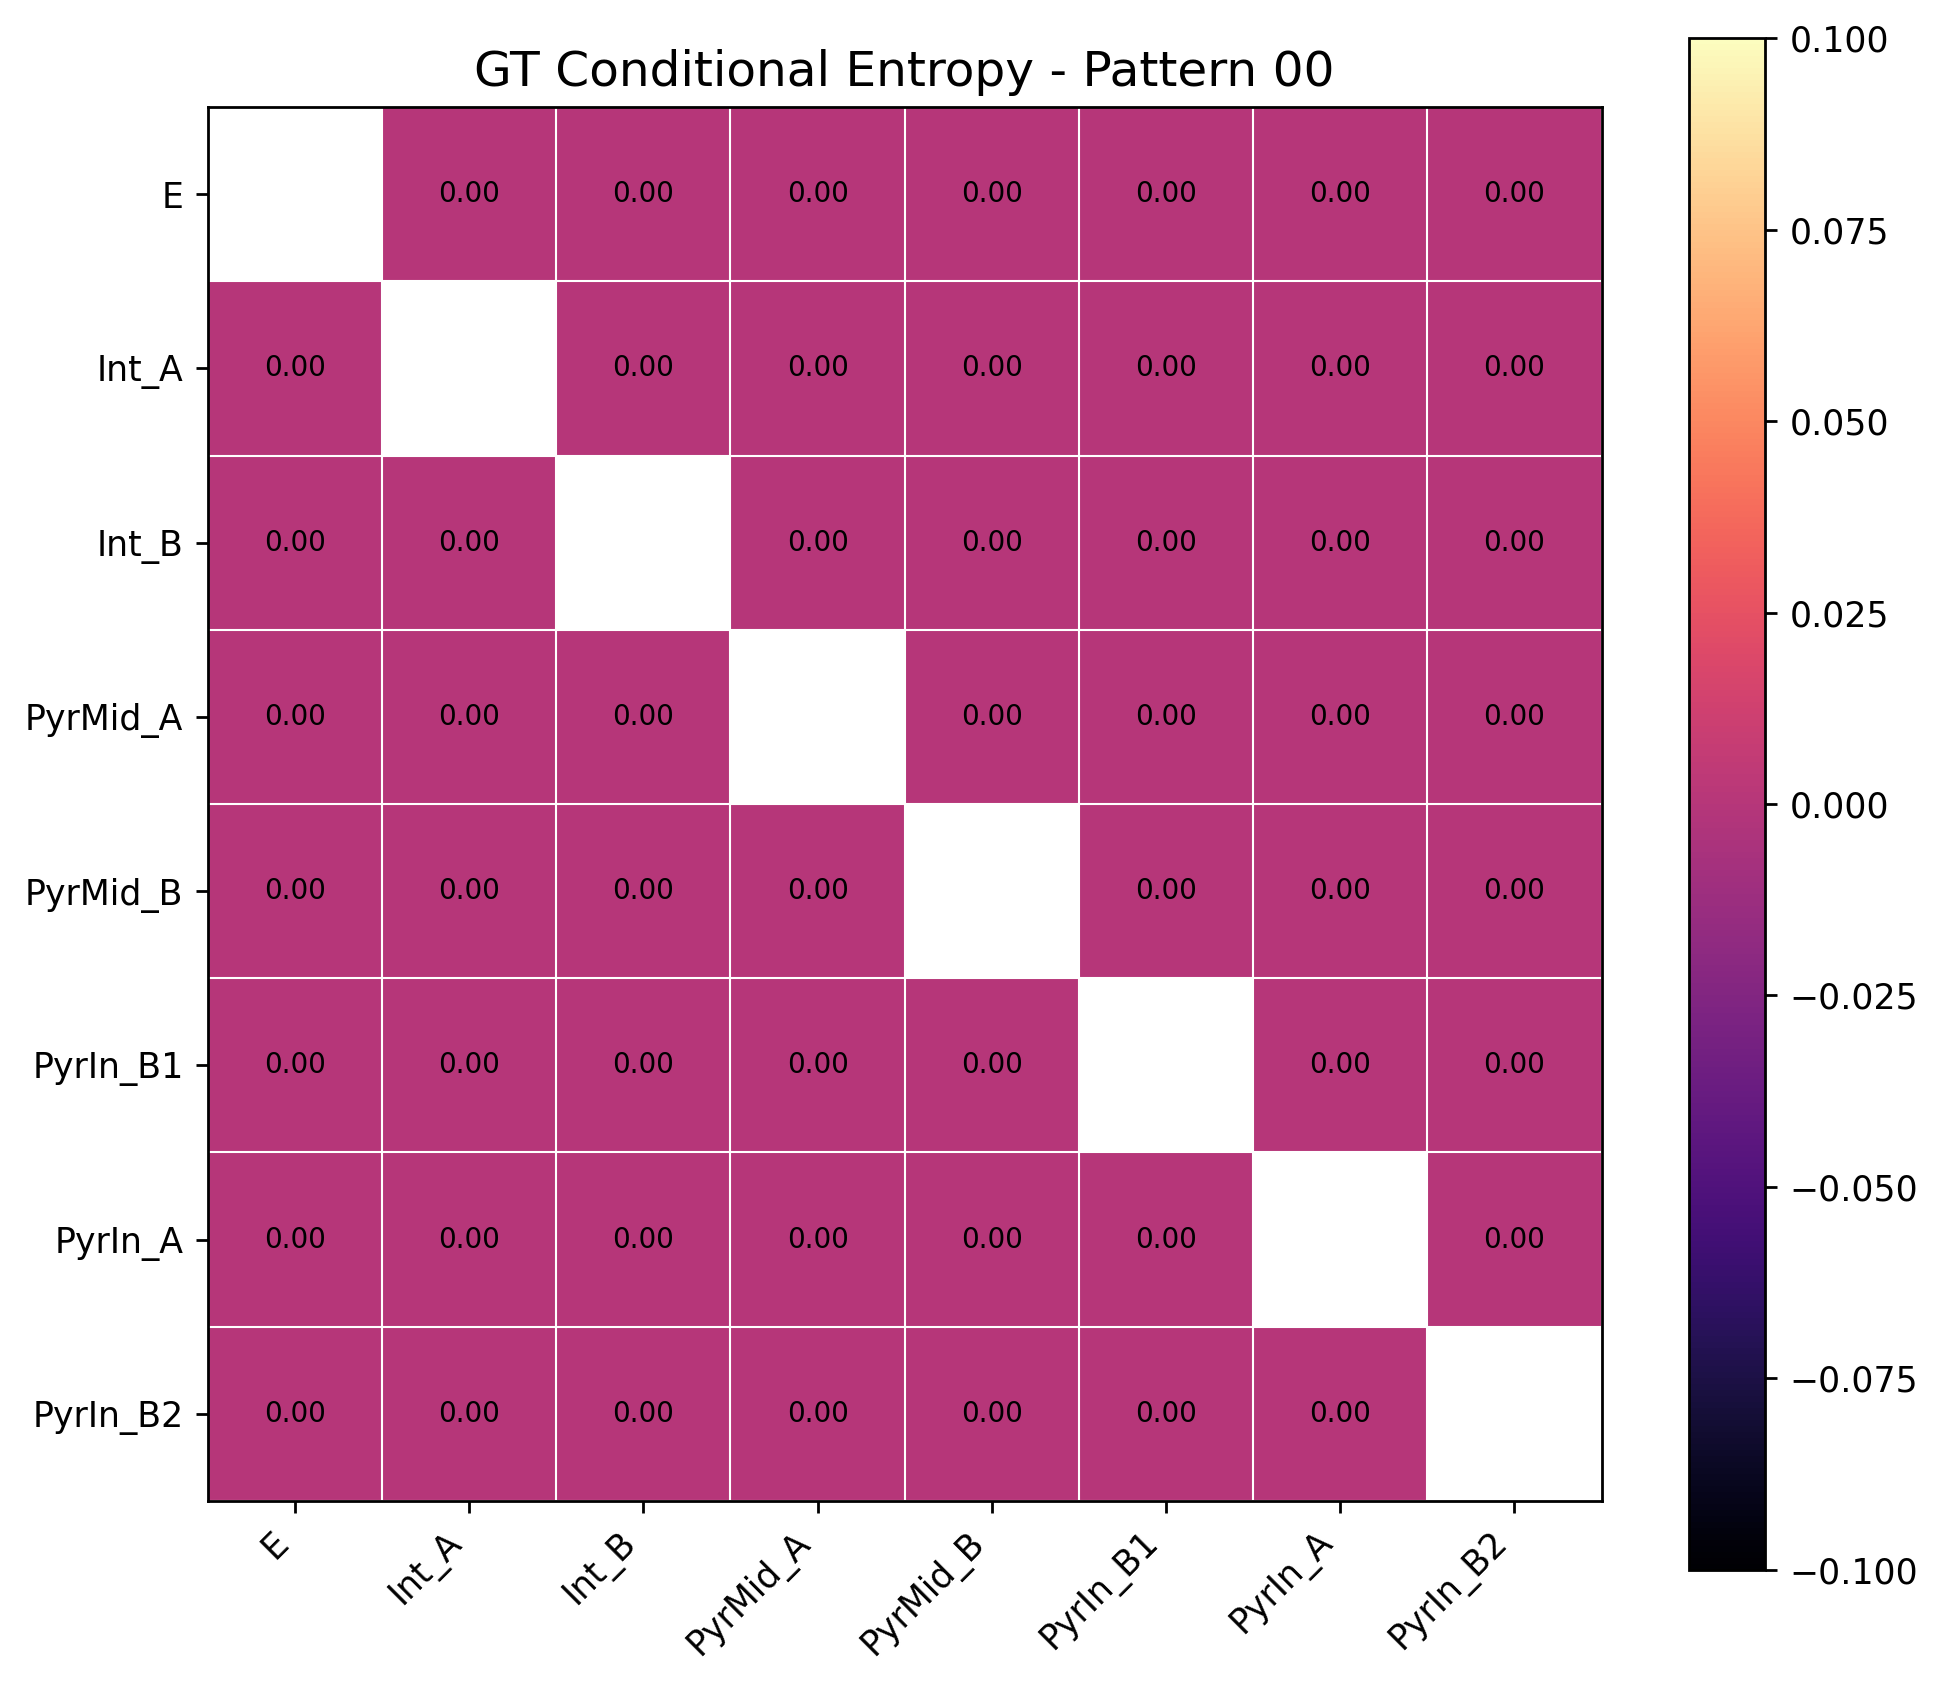

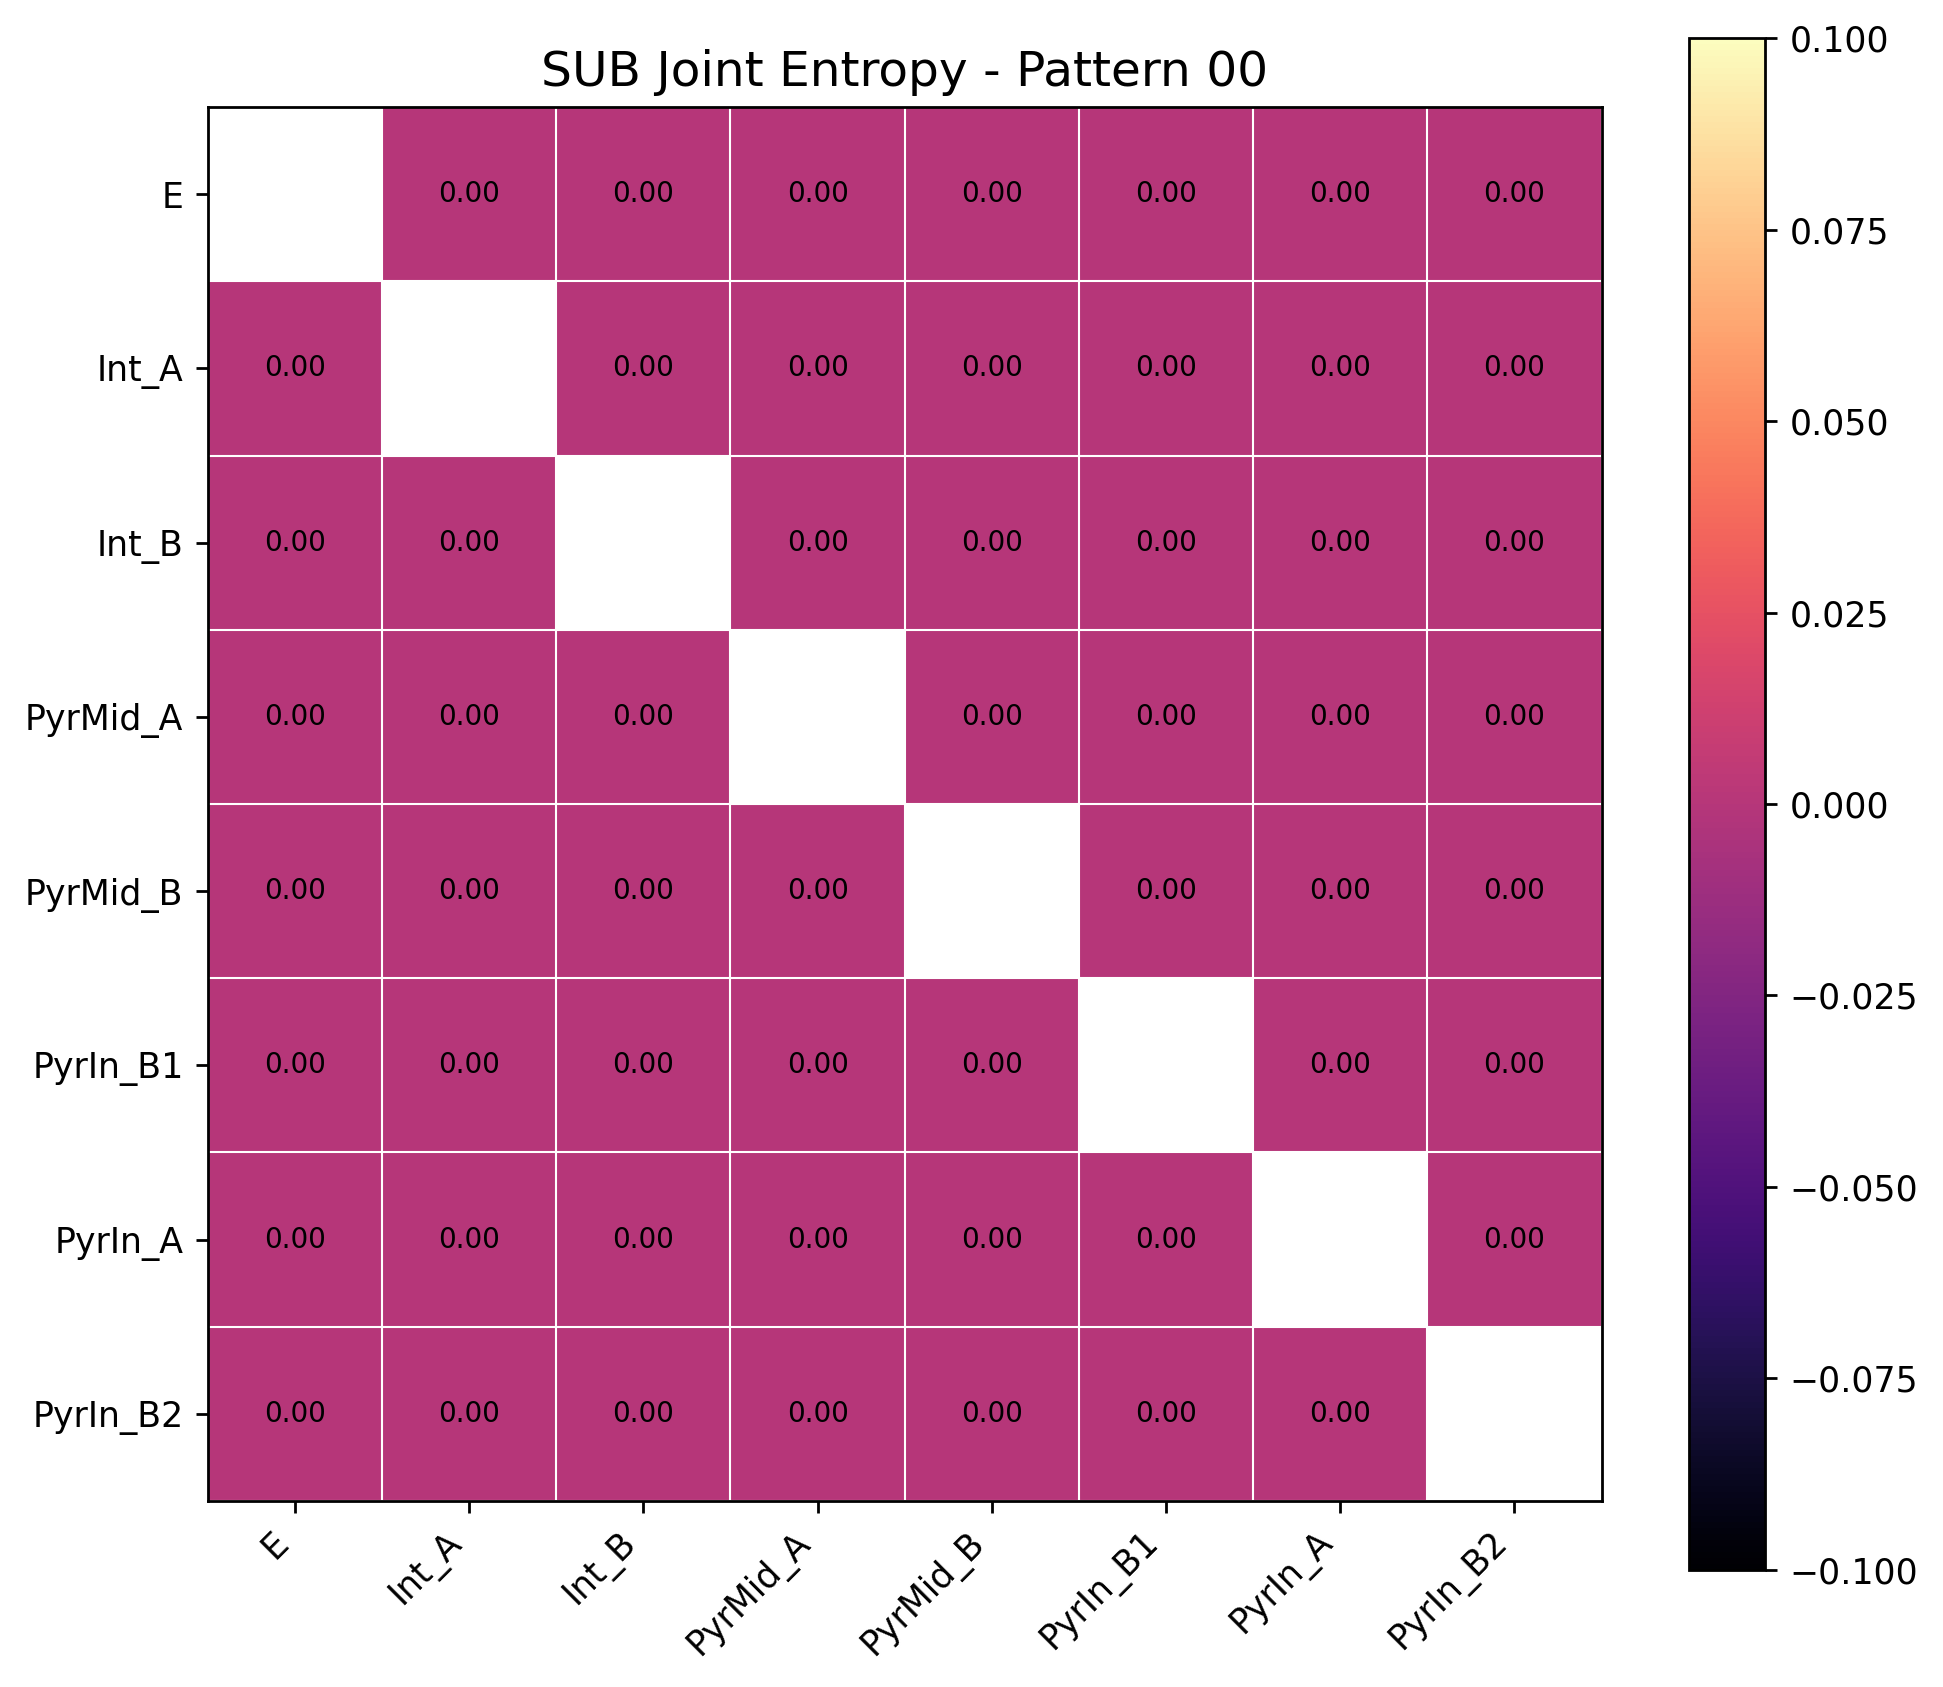

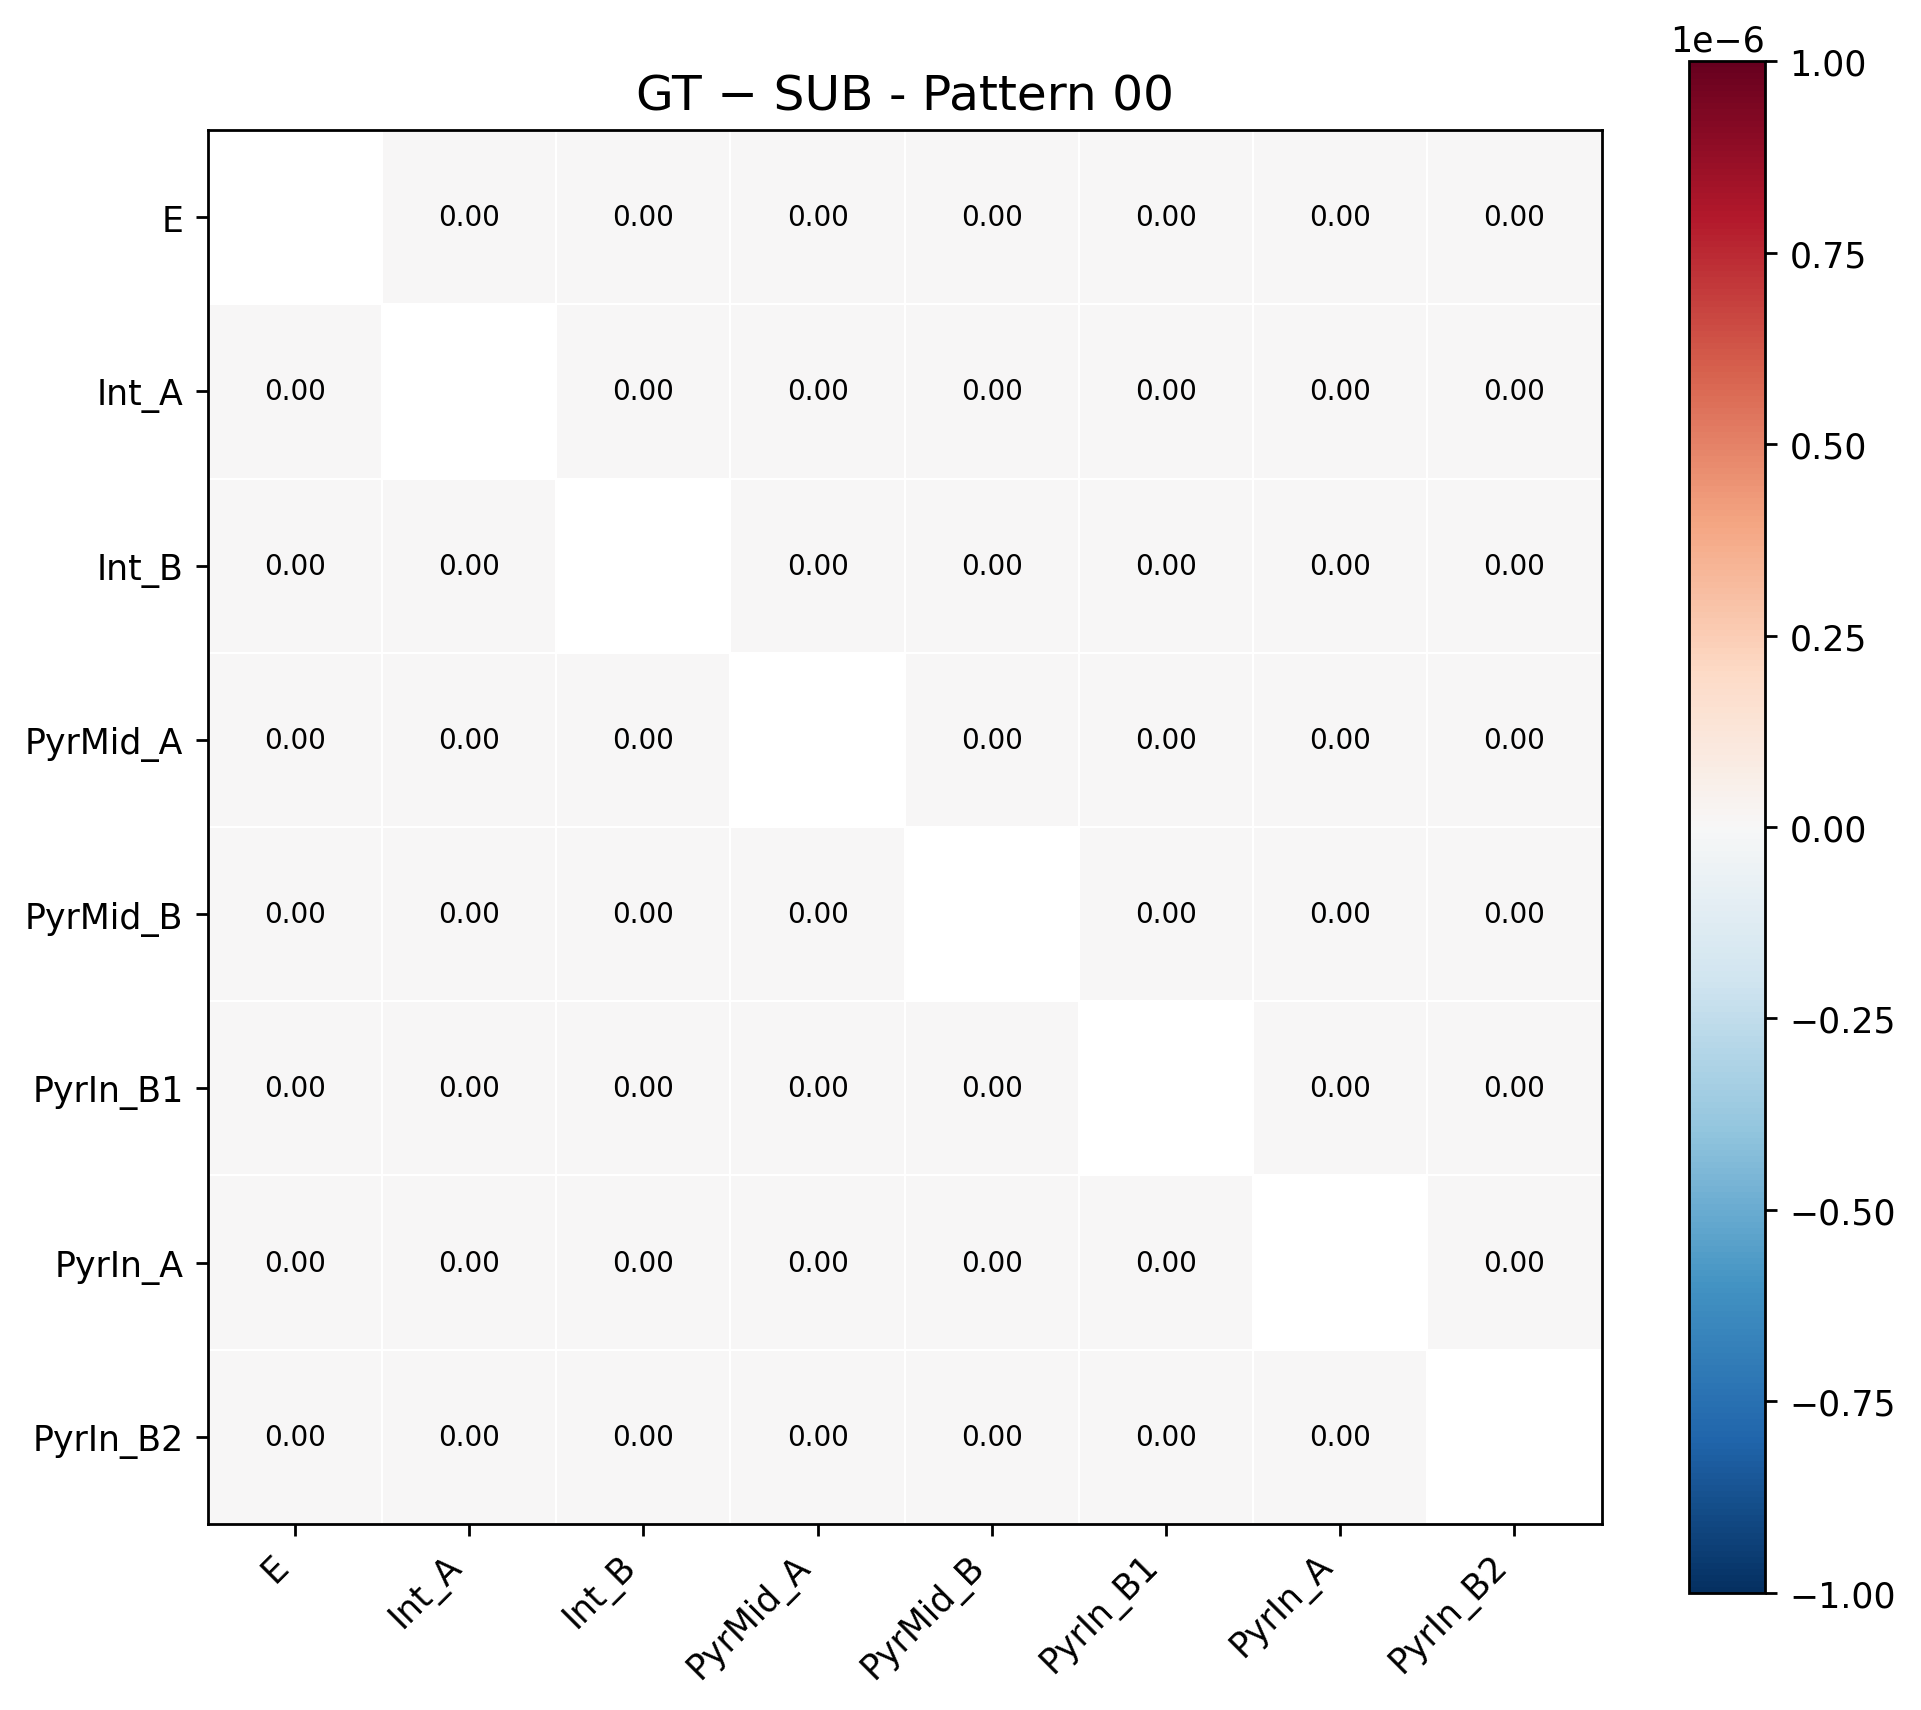

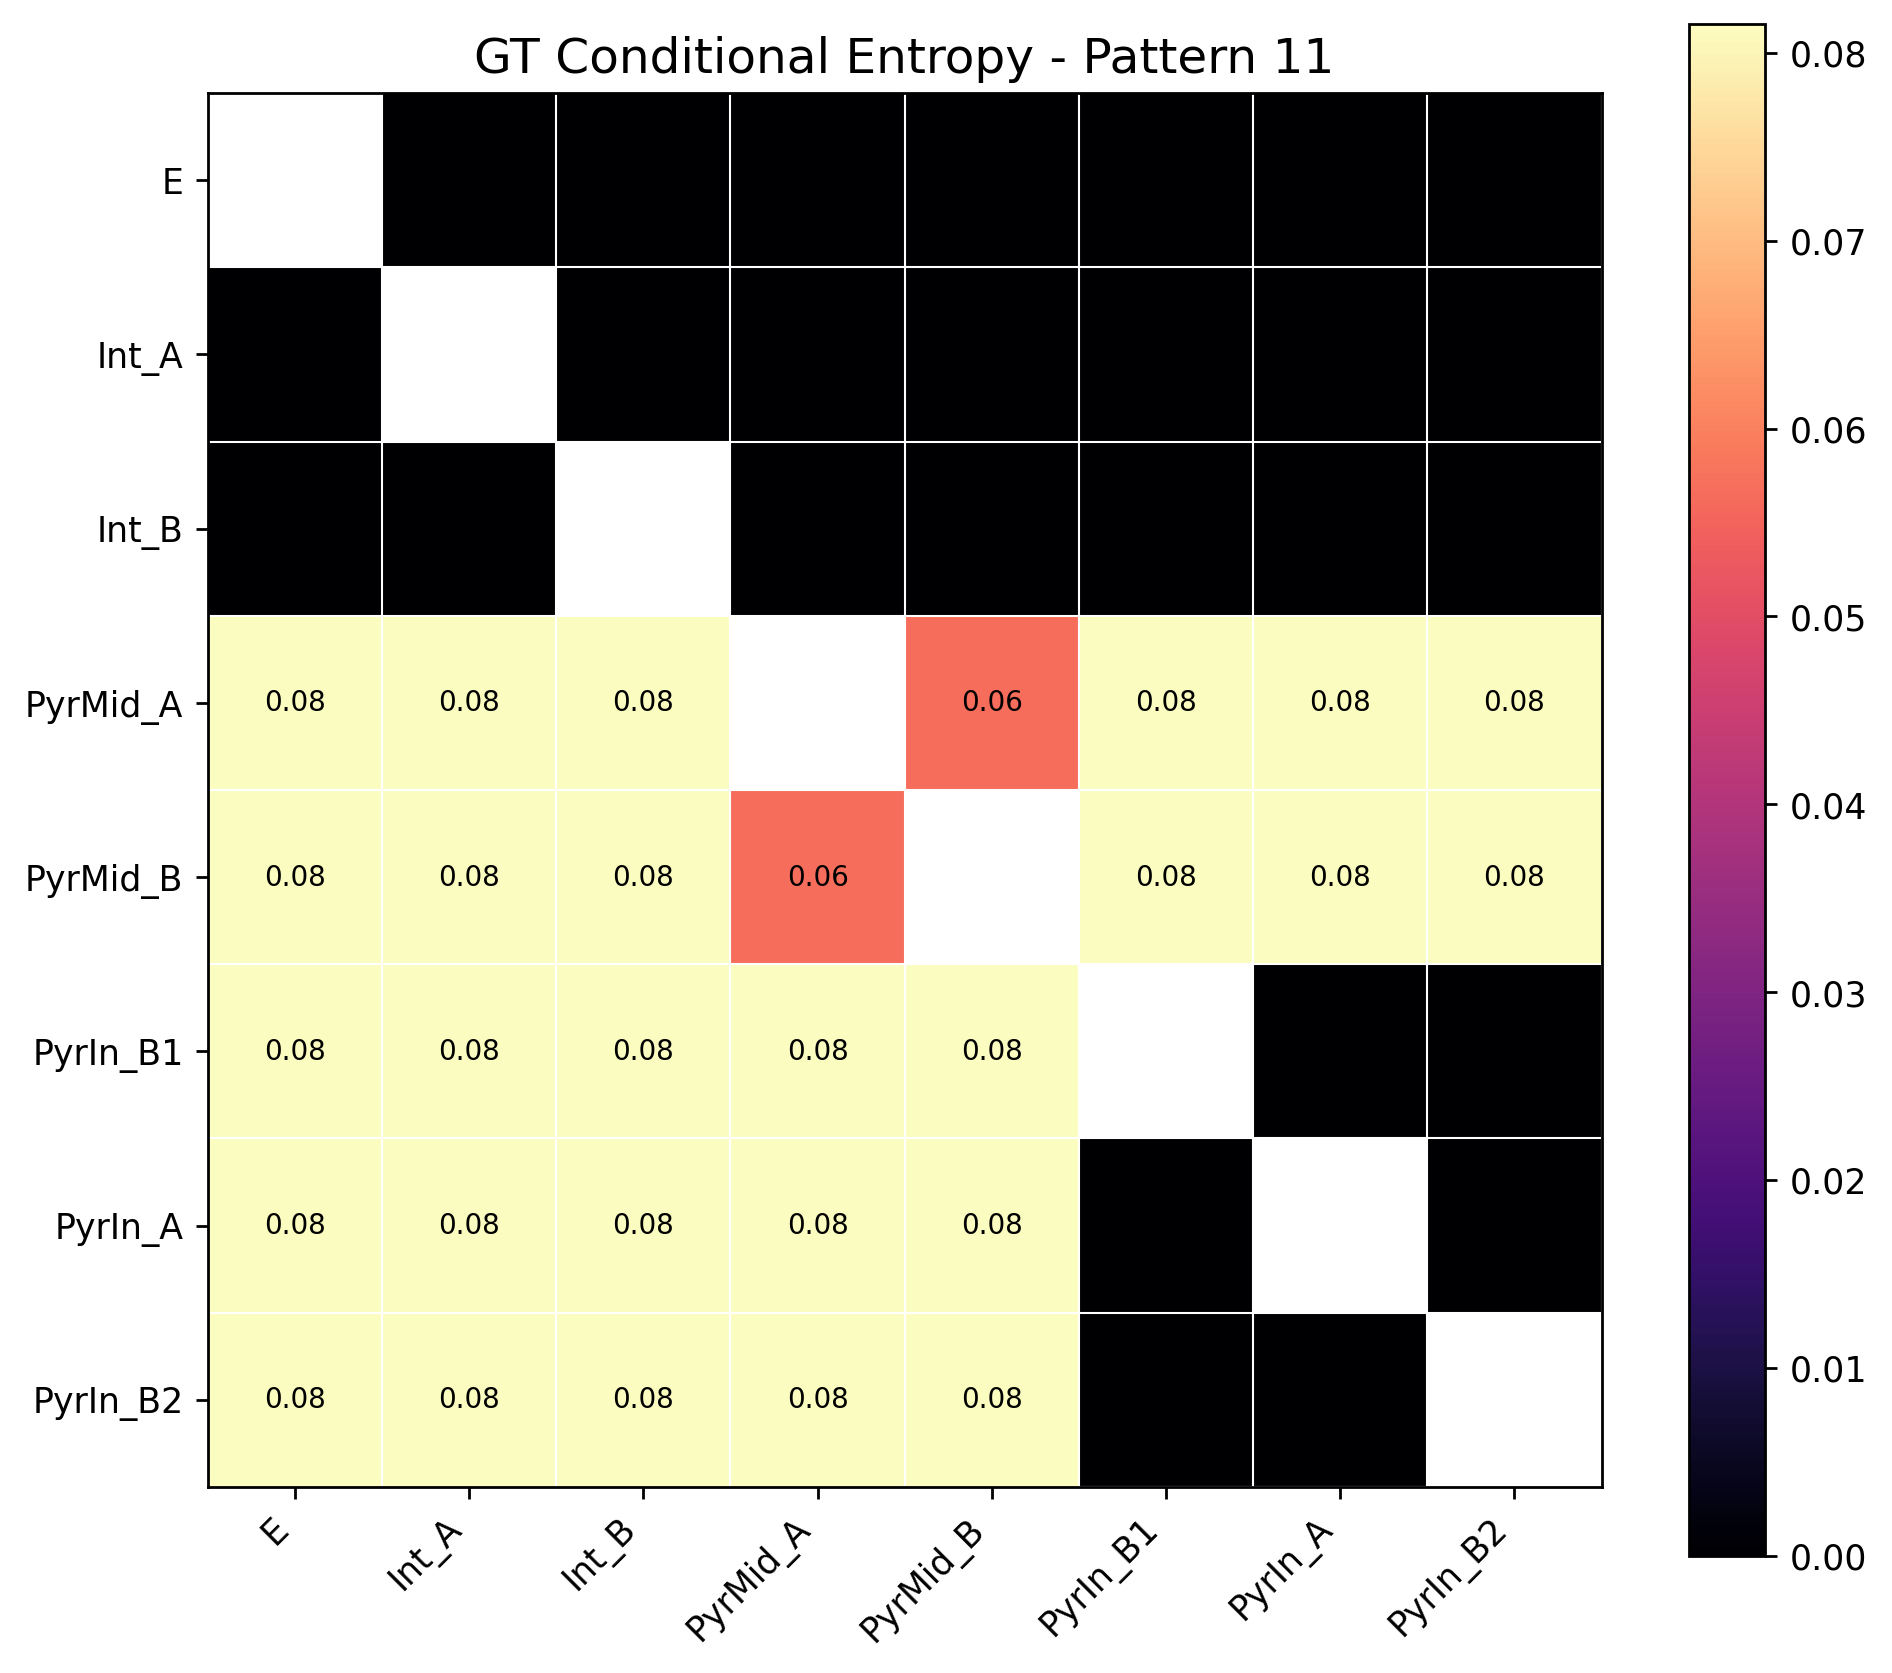

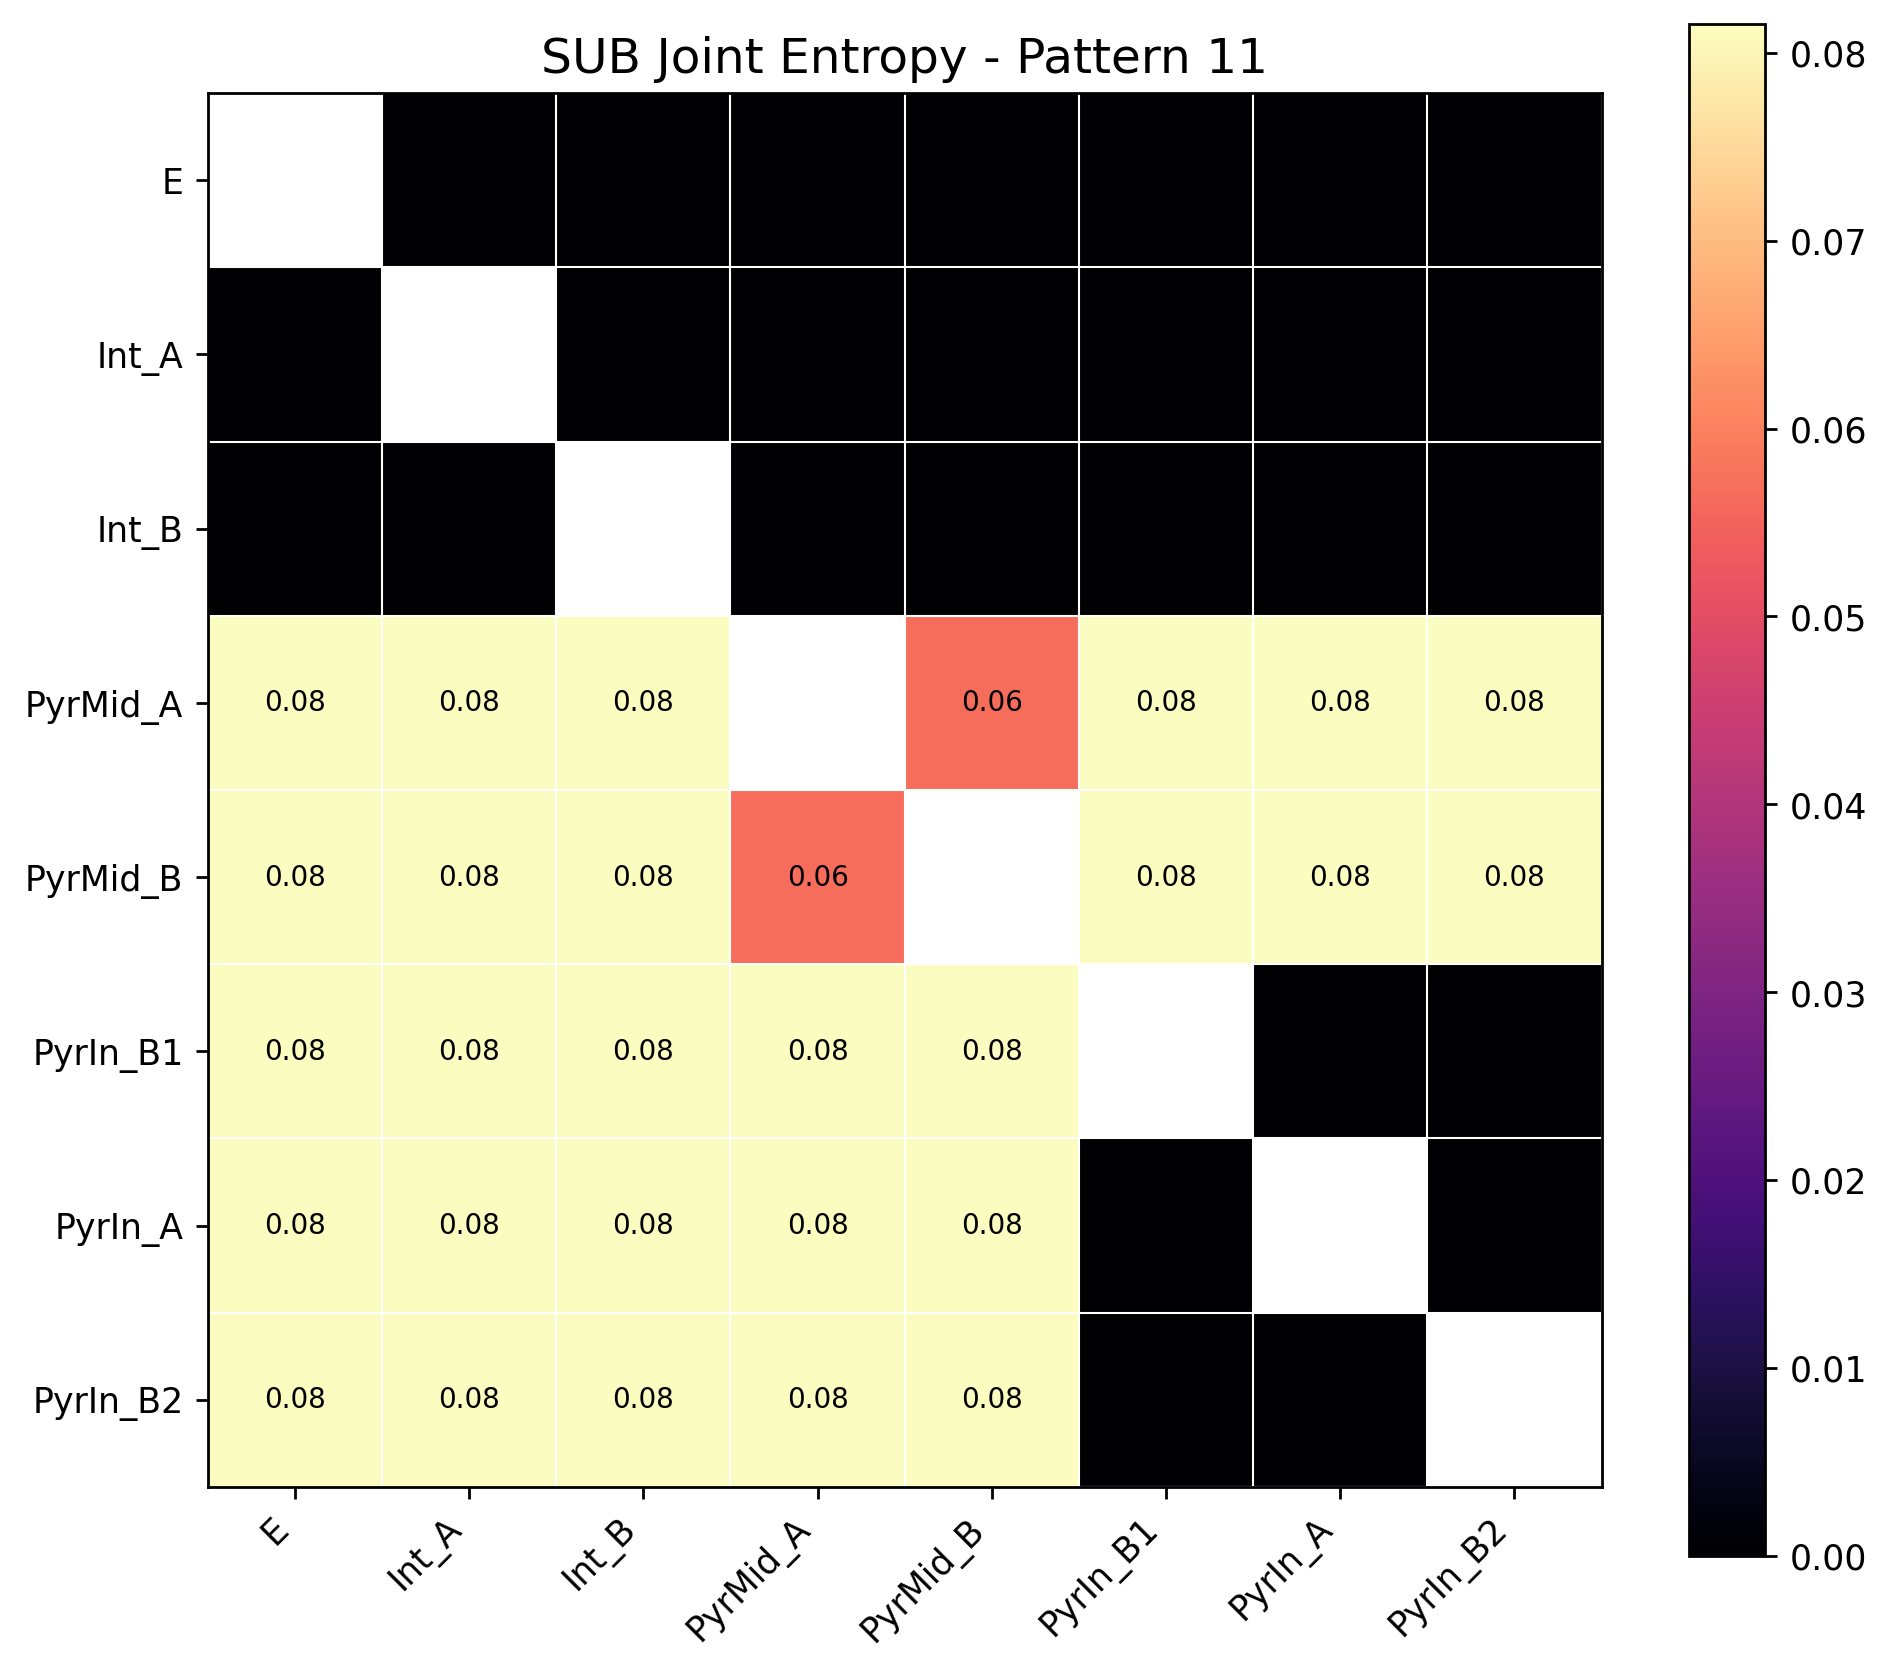

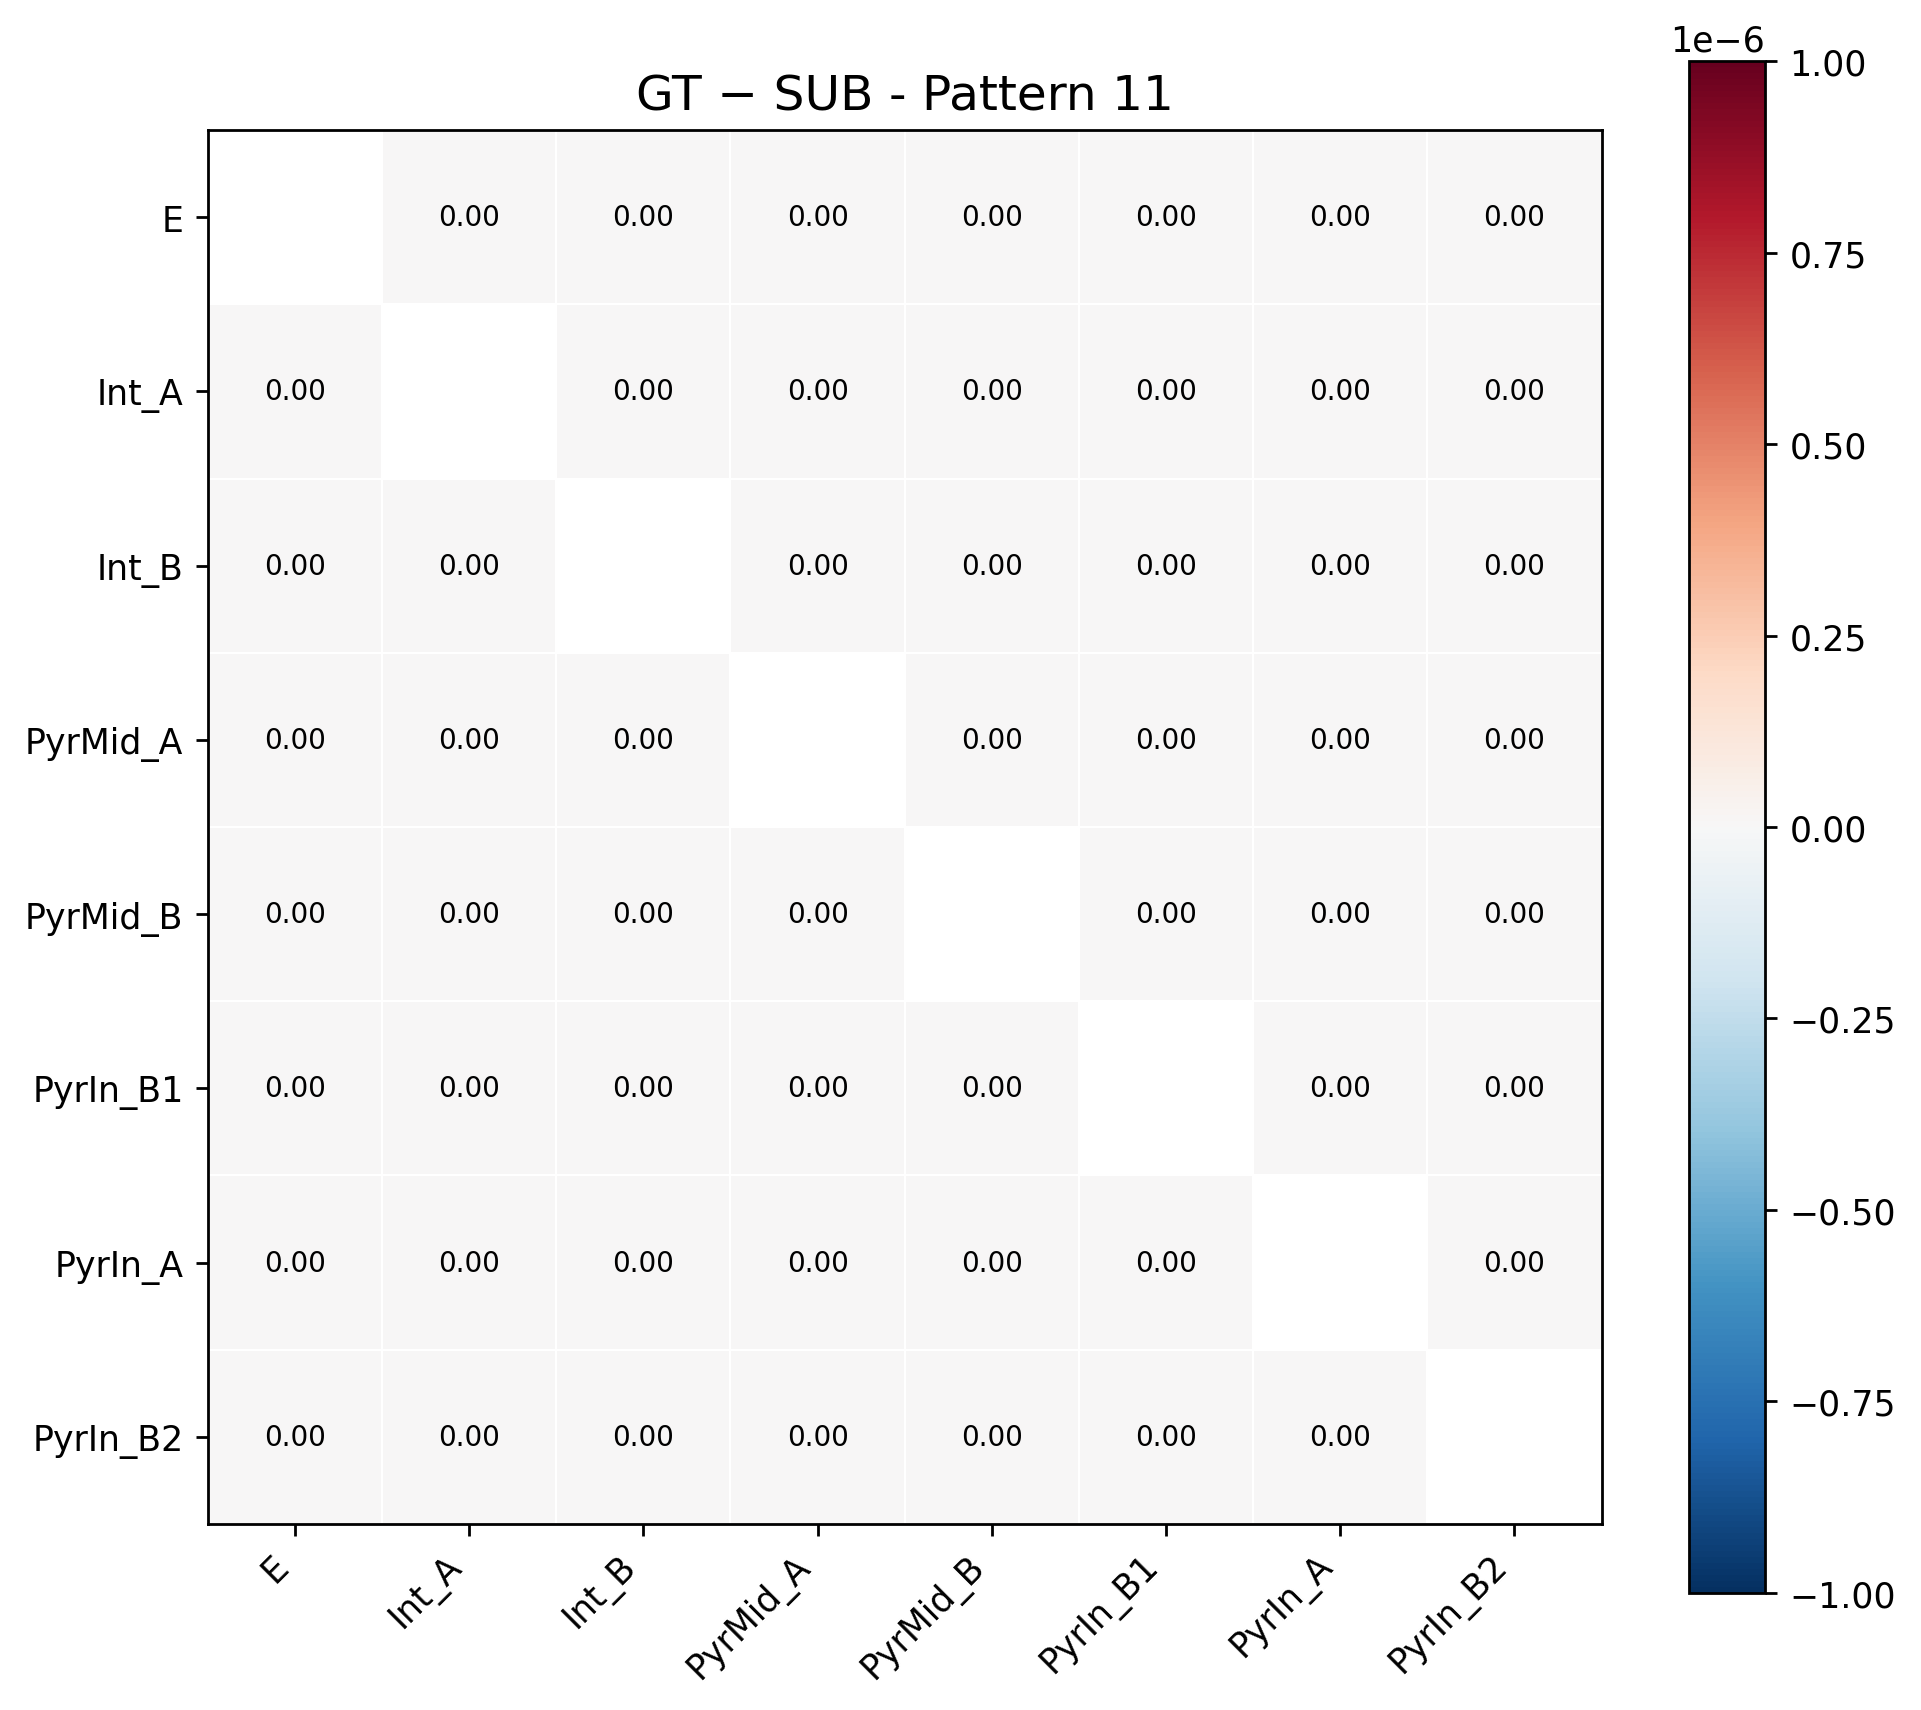

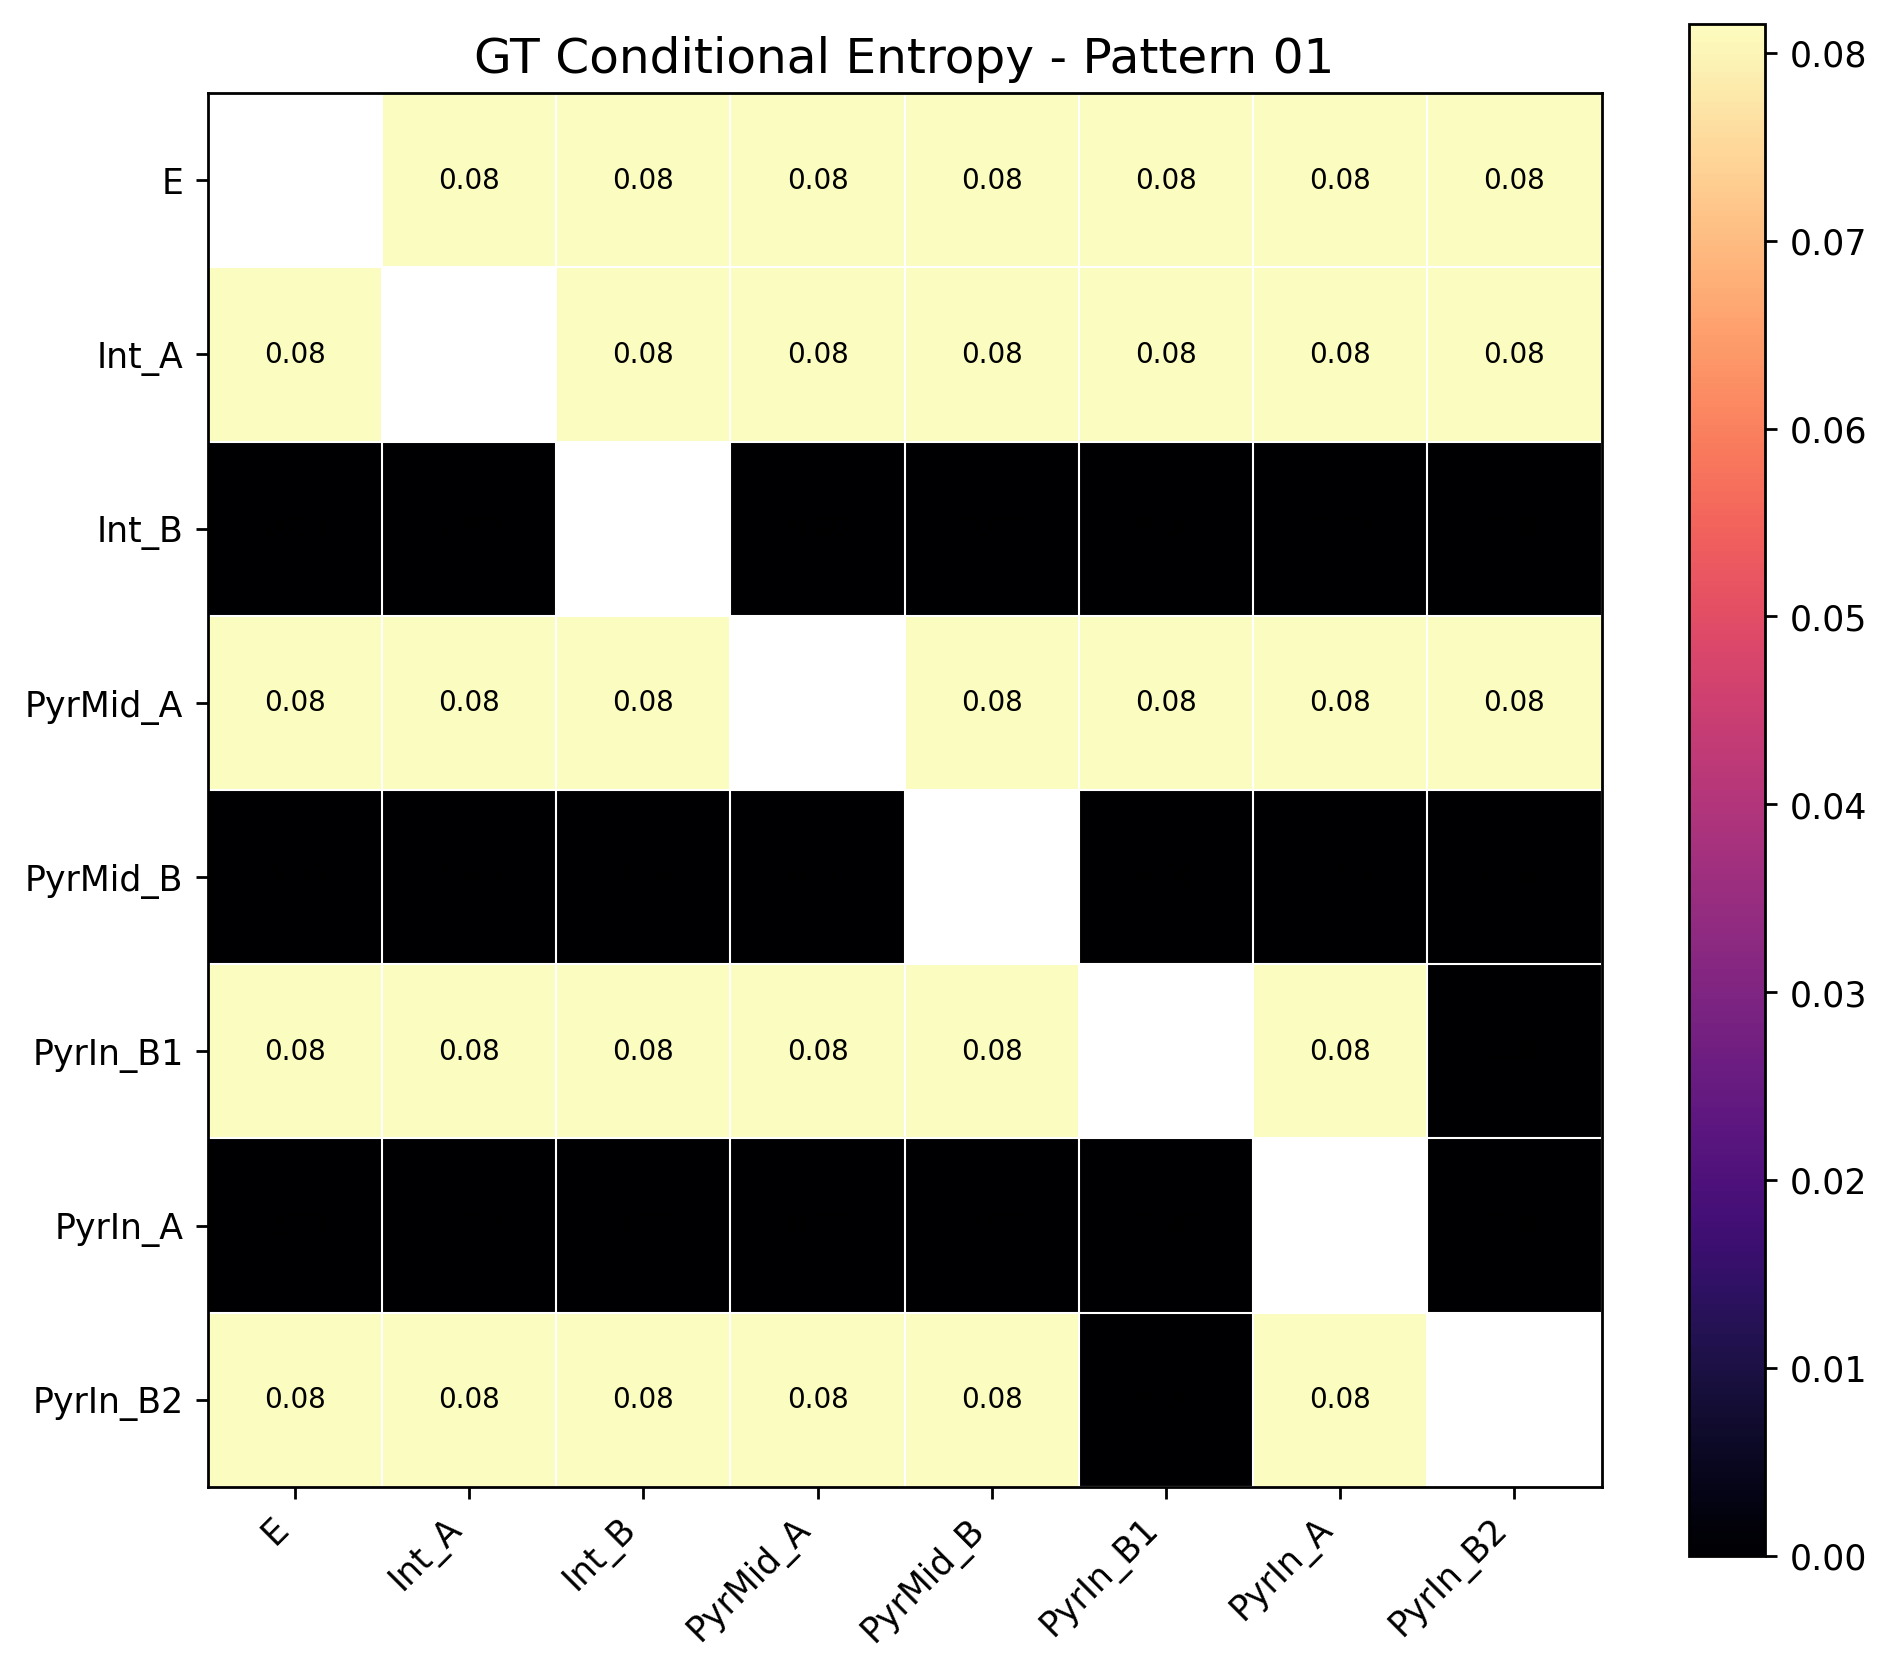

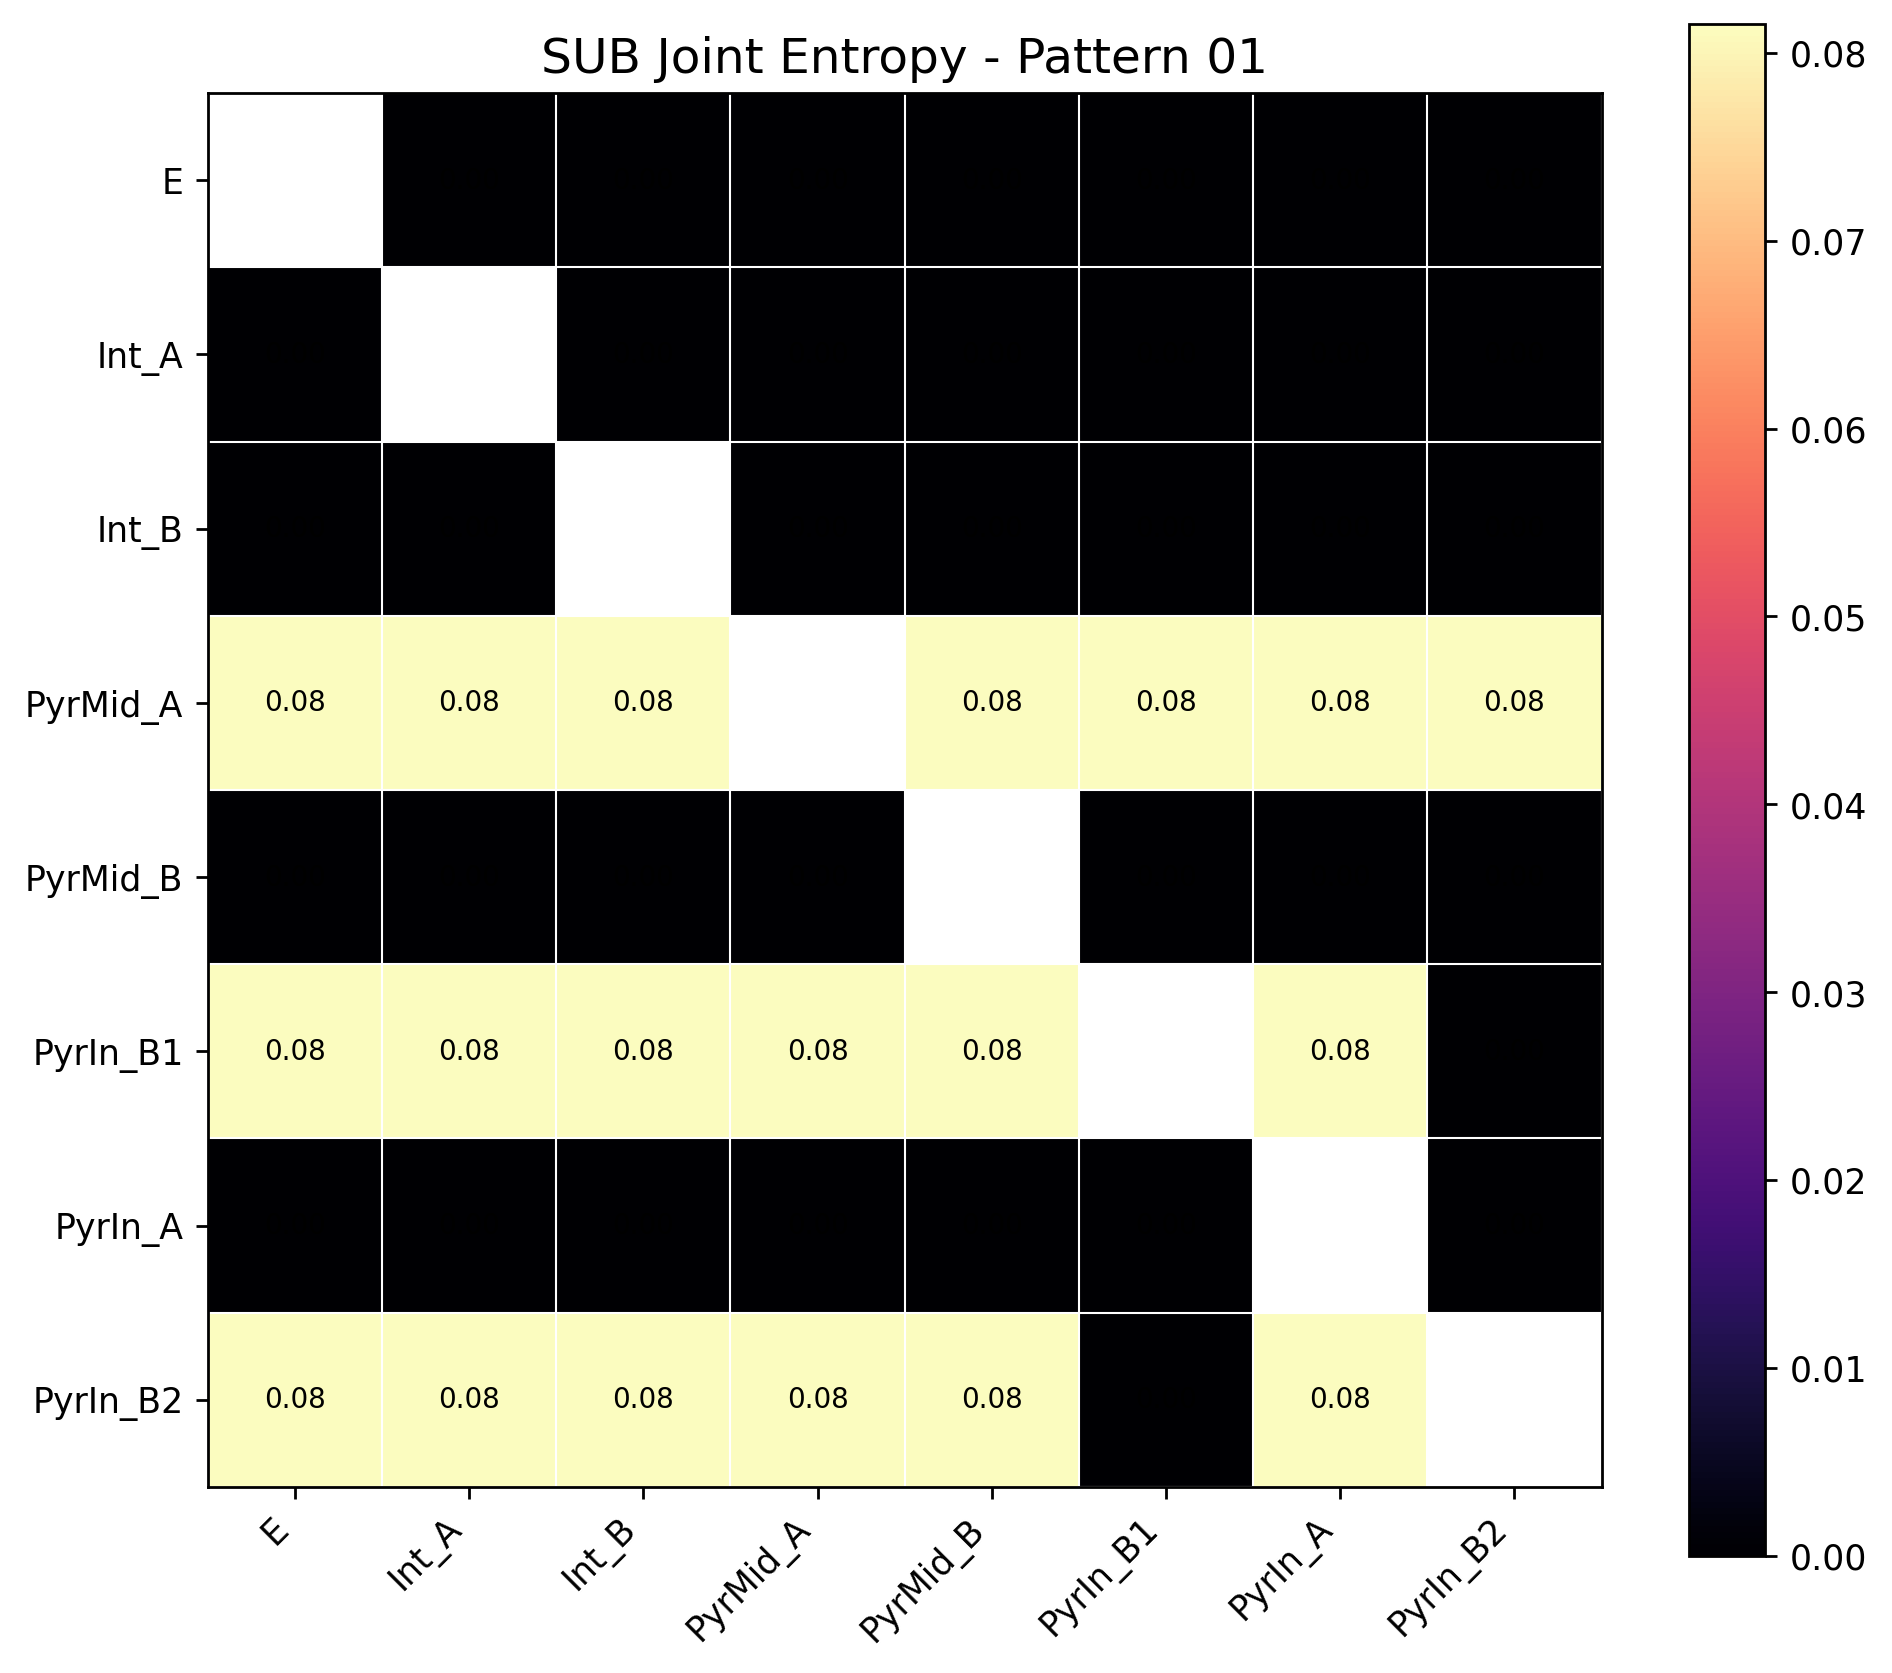

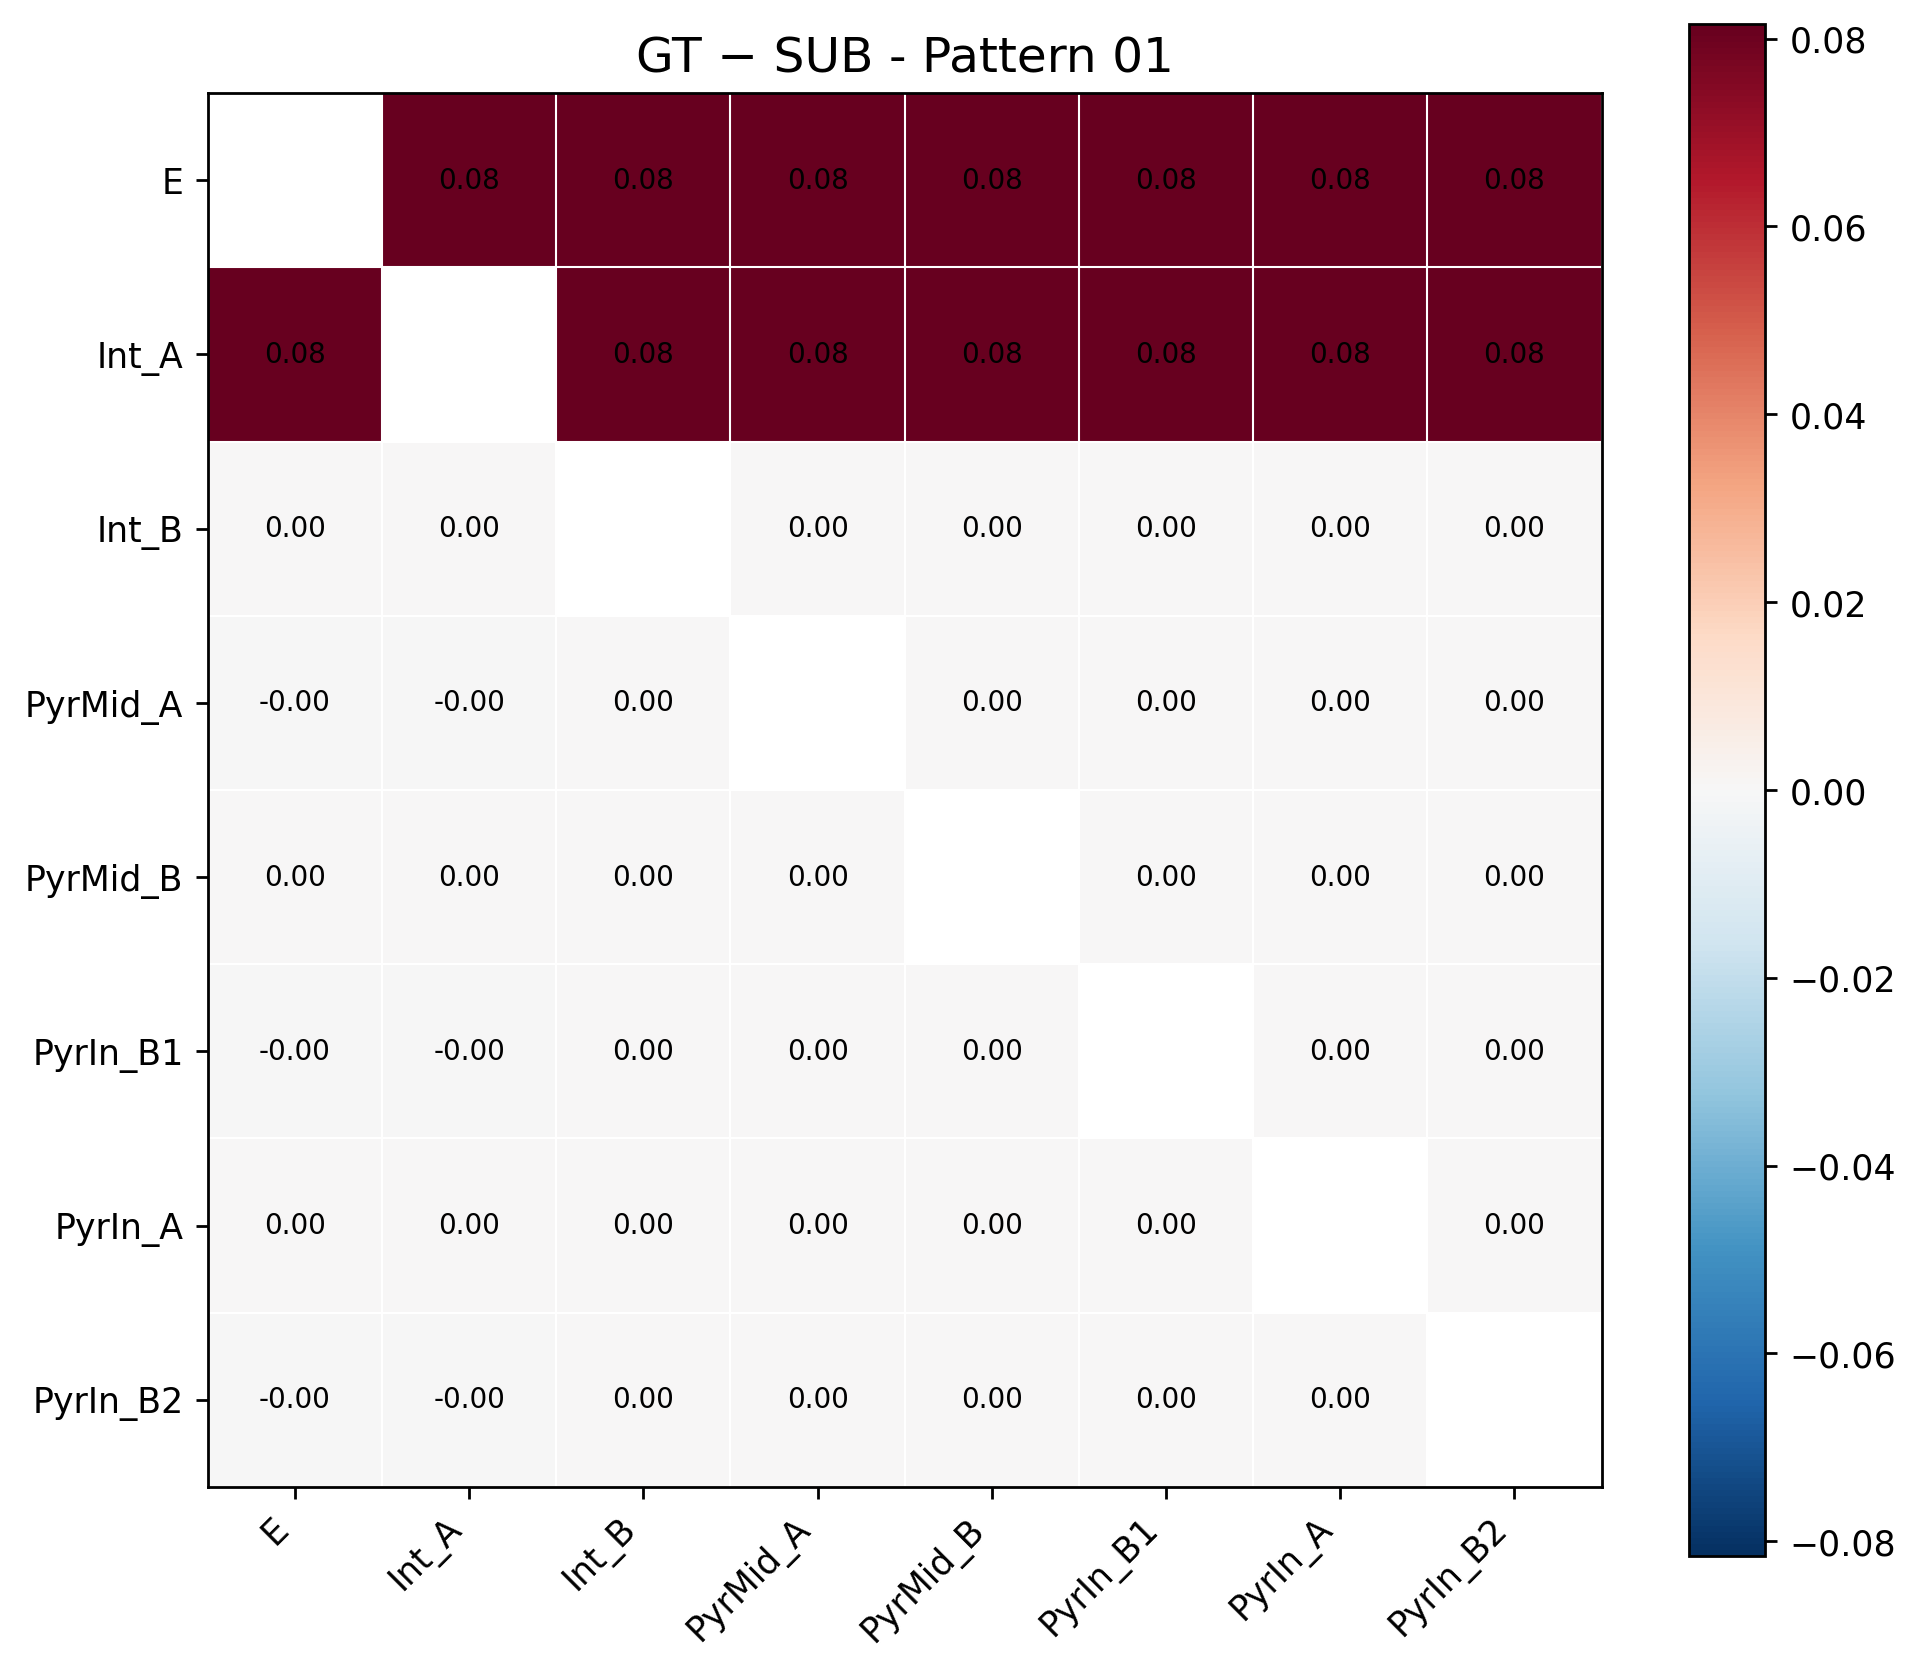

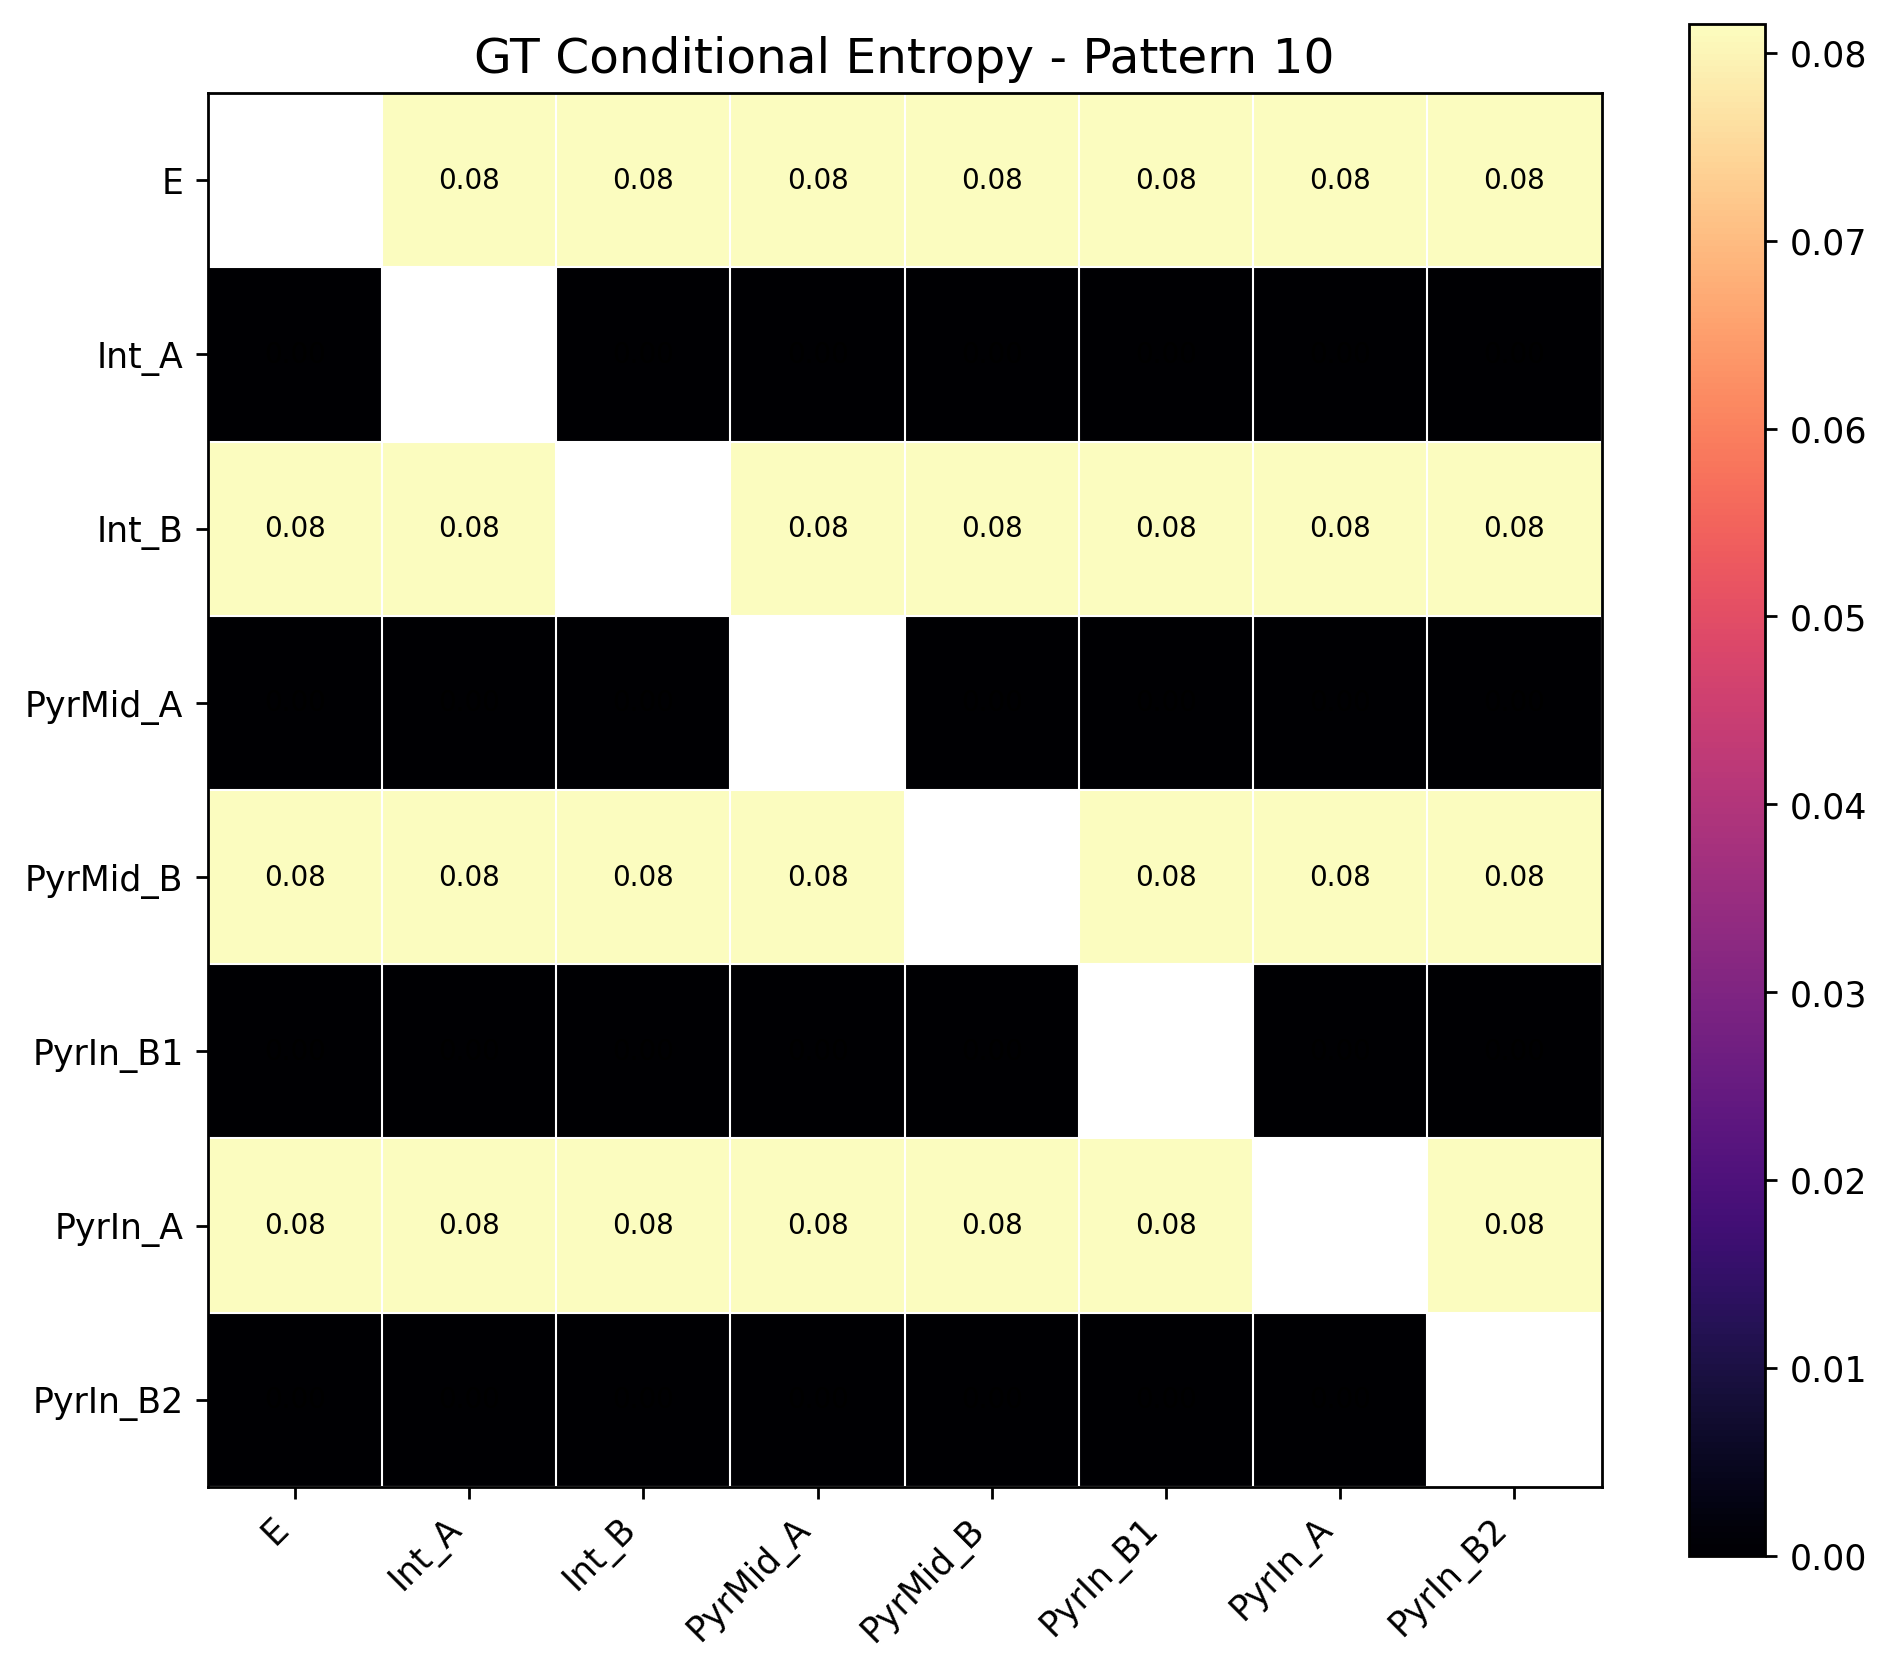

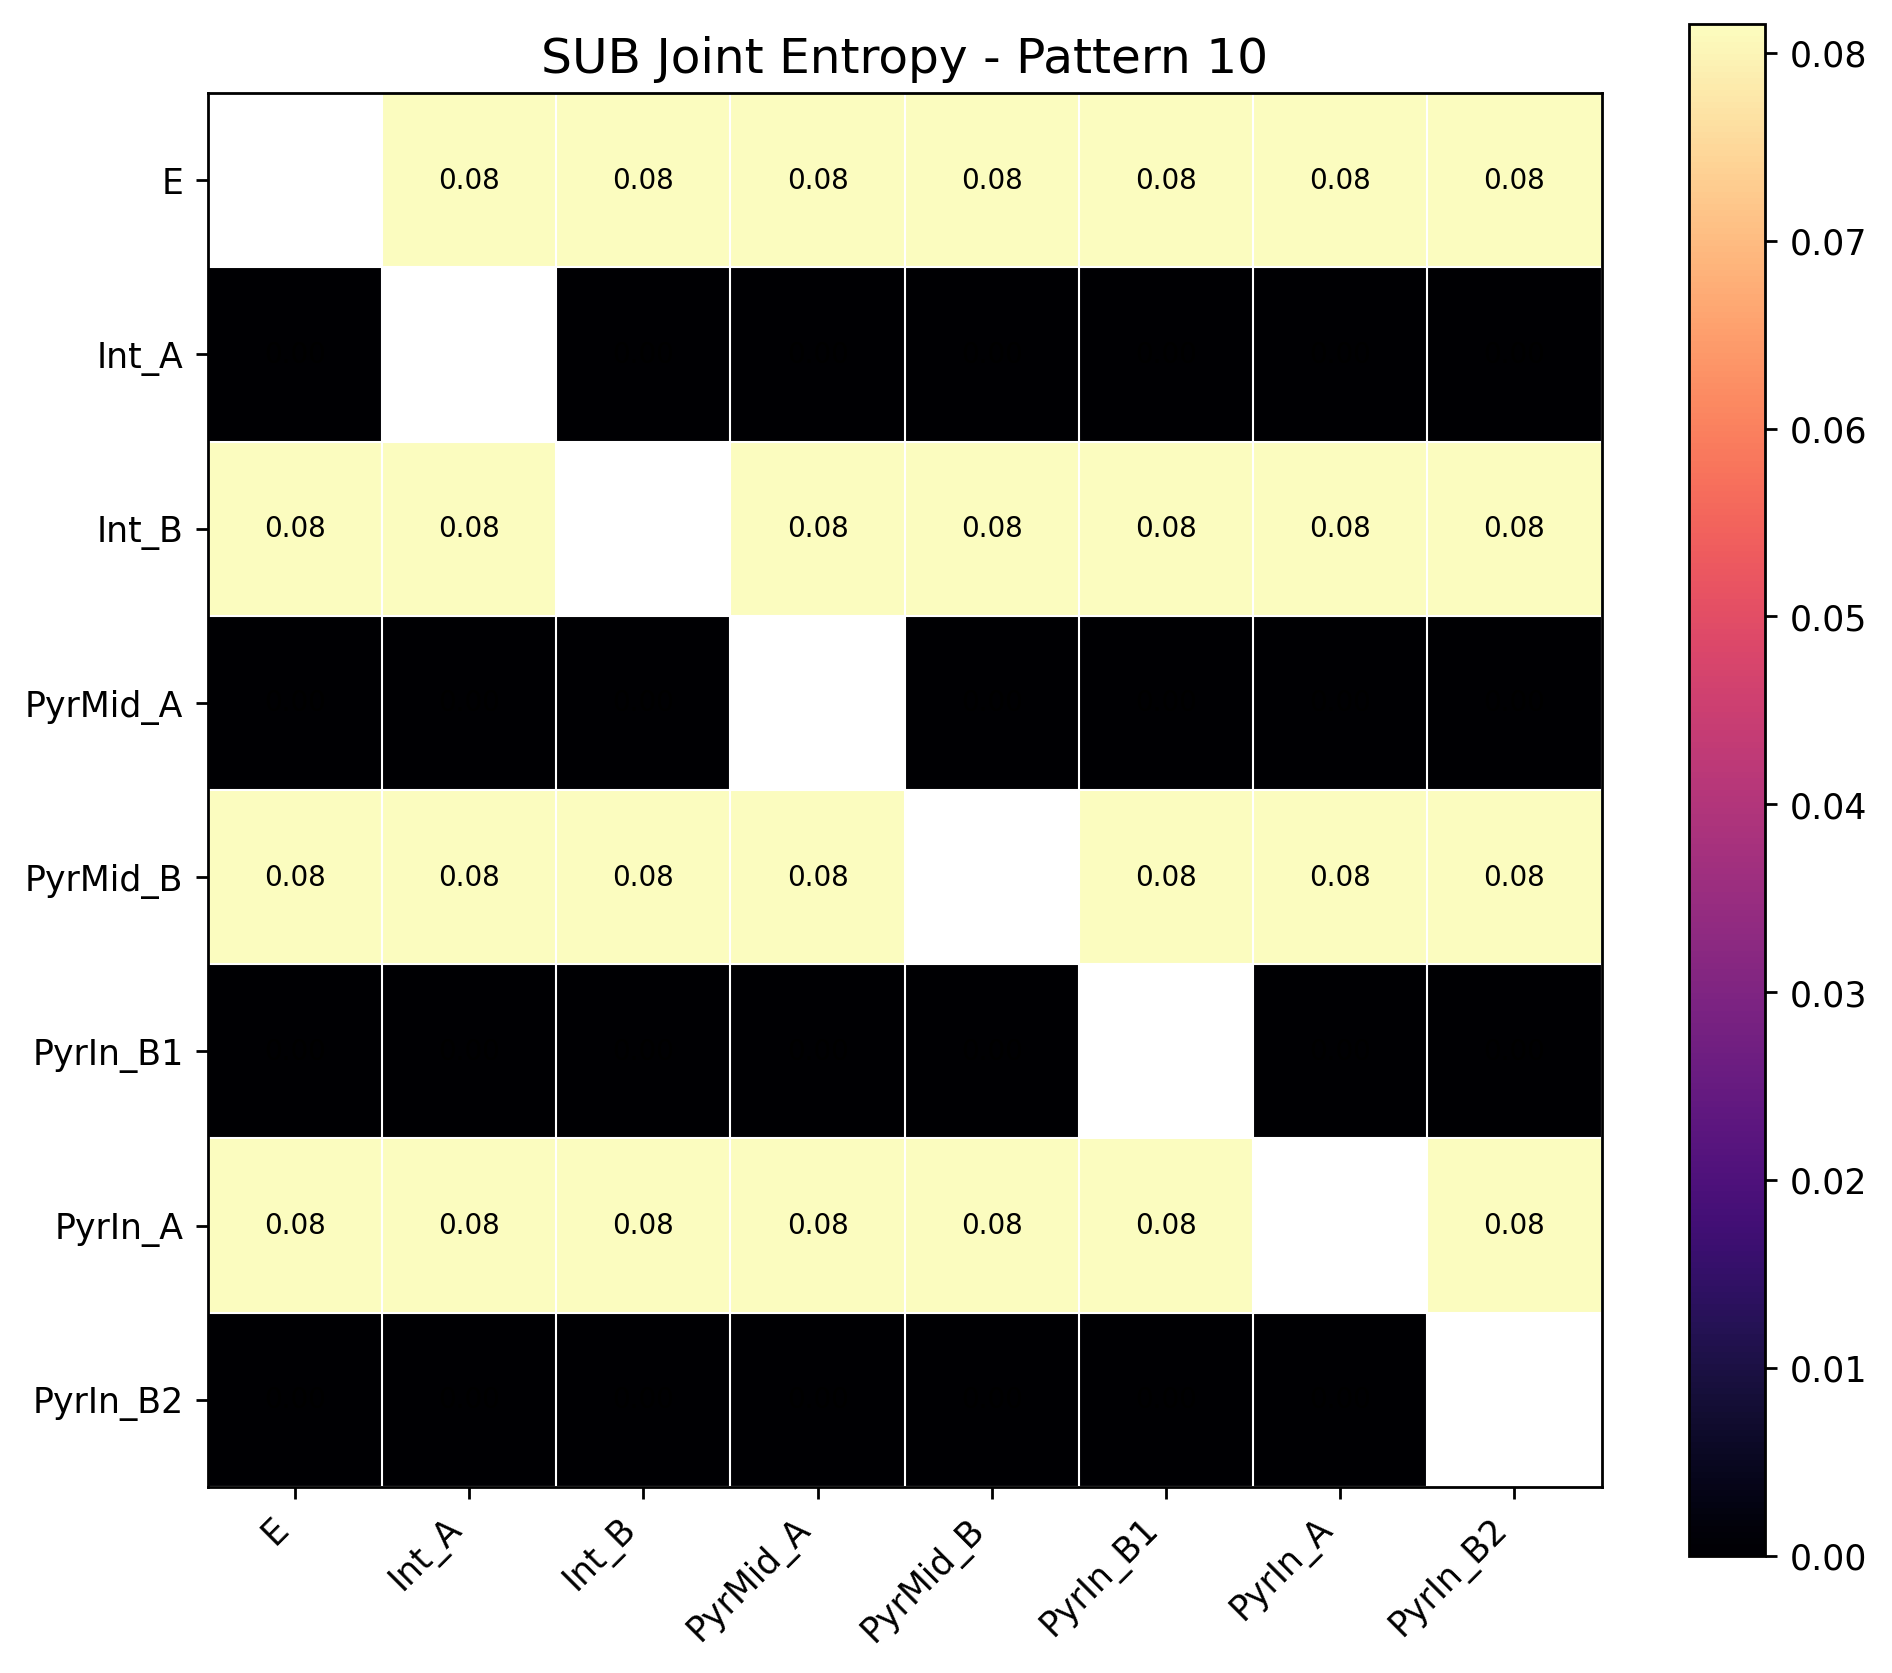

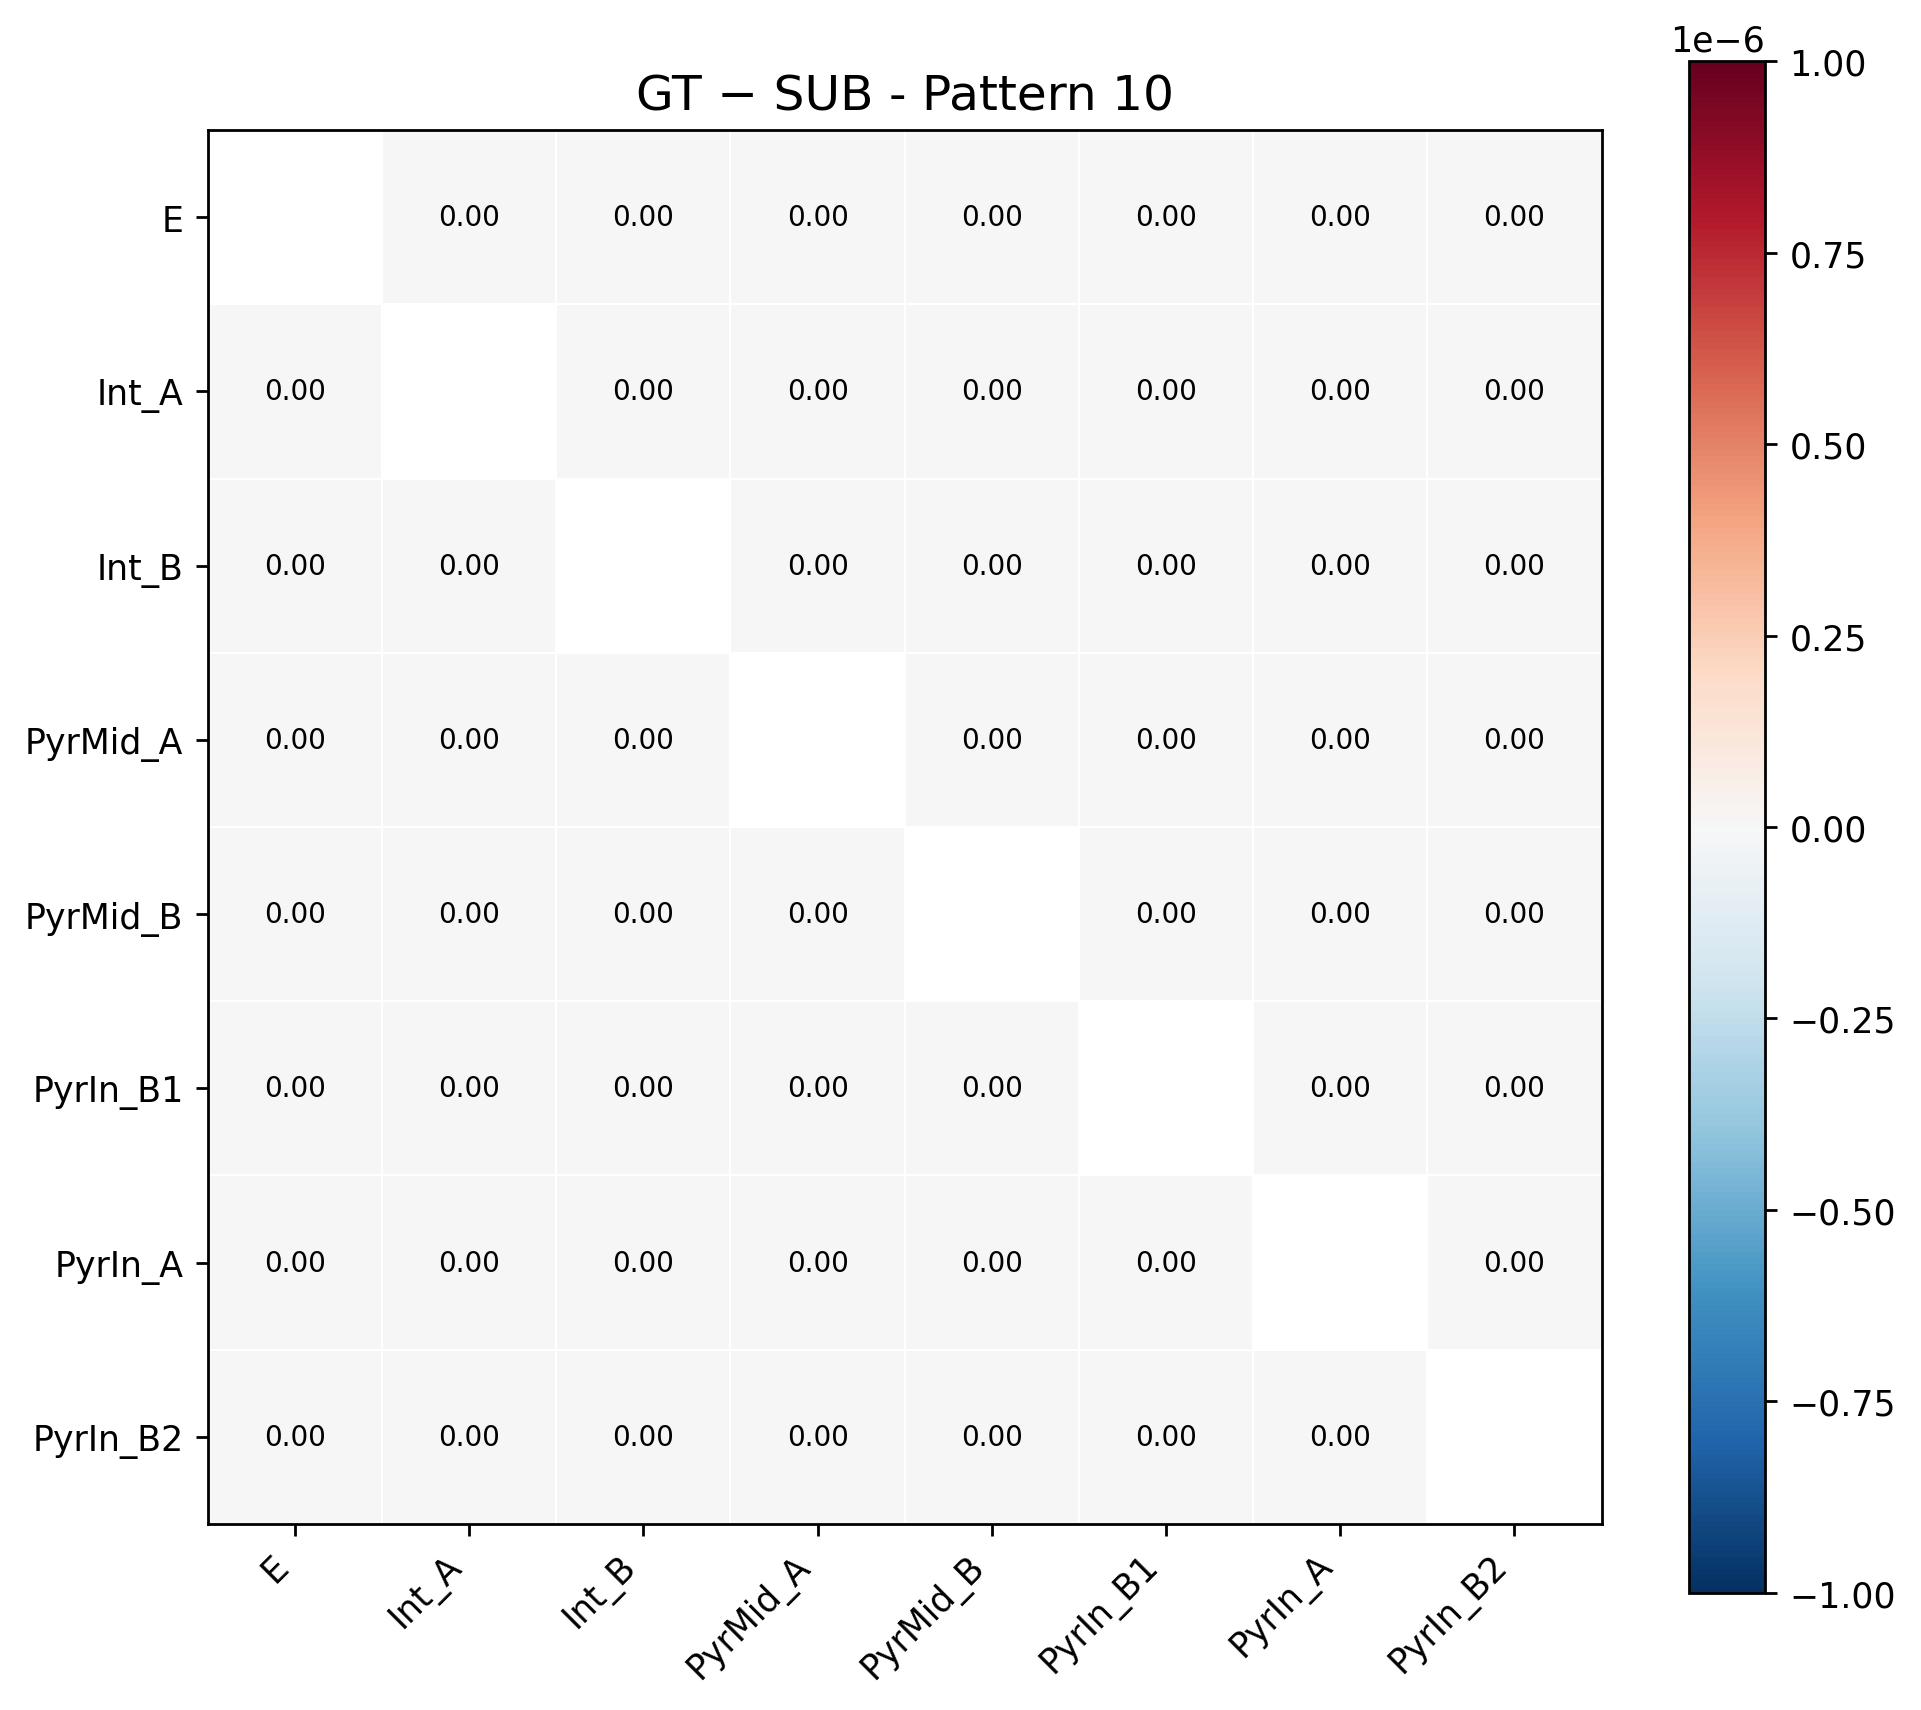

In [ ]:
#Conditonal Entropy

def ce_compute():

    patterns   = gt_data["case"].unique().tolist()
    neurons    = hp.get_spiking_neurons(cfg,gt_data)
    spike_cols = [f"{n}_spike" for n in neurons]

    ce_meta  = {"patterns": patterns, "spike_cols": spike_cols}
    gt_mats  = []
    sub_mats = []

    for p in patterns:
        gt_trials  = [gt_data[gt_data["case"] == p]]
        sub_trials = [sub_data[sub_data["case"] == p]]

        gt_JE  = compute_JE_matrix(gt_trials,  spike_cols)
        sub_JE = compute_JE_matrix(sub_trials, spike_cols)

        H_gt  = compute_marginal_entropies(gt_trials,  spike_cols)
        H_sub = compute_marginal_entropies(sub_trials, spike_cols)

        CE_gt  = gt_JE  - H_gt[np.newaxis, :]
        CE_sub = sub_JE - H_sub[np.newaxis, :]

        np.fill_diagonal(CE_gt,  np.nan)
        np.fill_diagonal(CE_sub, np.nan)
        CE_gt  = np.clip(CE_gt,  0.0, None)
        CE_sub = np.clip(CE_sub, 0.0, None)

        ce_meta[p] = {
            "gt":   CE_gt,
            "sub":  CE_sub,
            "diff": CE_gt - CE_sub,
        }
        gt_mats.append(CE_gt)
        sub_mats.append(CE_sub)

    gt_arr  = np.stack(gt_mats)
    sub_arr = np.stack(sub_mats)
    diff    = np.nanmean(np.abs(gt_arr - sub_arr))
    score   = float(1.0 - np.clip(diff, 0.0, 1.0))

    return gt_arr, sub_arr, score, ce_meta

ce_result = ce_compute()
_, _, _, meta = ce_result

patterns = meta["patterns"]
labels = [c.replace("_spike", "") for c in meta["spike_cols"]]

for pattern in patterns:

    gt = meta[pattern]["gt"]
    sub = meta[pattern]["sub"]
    diff = meta[pattern]["diff"]

    vmax = max(np.nanmax(gt), np.nanmax(sub))
    vmin = min(np.nanmin(gt), np.nanmin(sub))

    diff_lim = np.nanmax(np.abs(diff))
    if diff_lim == 0:
        diff_lim = 1e-6

    plot_single_heatmap(
        gt,
        f"GT Conditional Entropy - Pattern {pattern}",
        labels,
        "magma",
        vmin,
        vmax,
    )

    plot_single_heatmap(
            sub,
            f"SUB Conditional Entropy - Pattern {pattern}",
            labels,
            "magma",
            vmin,
            vmax,
        )
    
    plot_single_heatmap(
            diff,
            f"GT − SUB - Pattern {pattern}",
            labels,
            "RdBu_r",
            -diff_lim,
            diff_lim,
        )

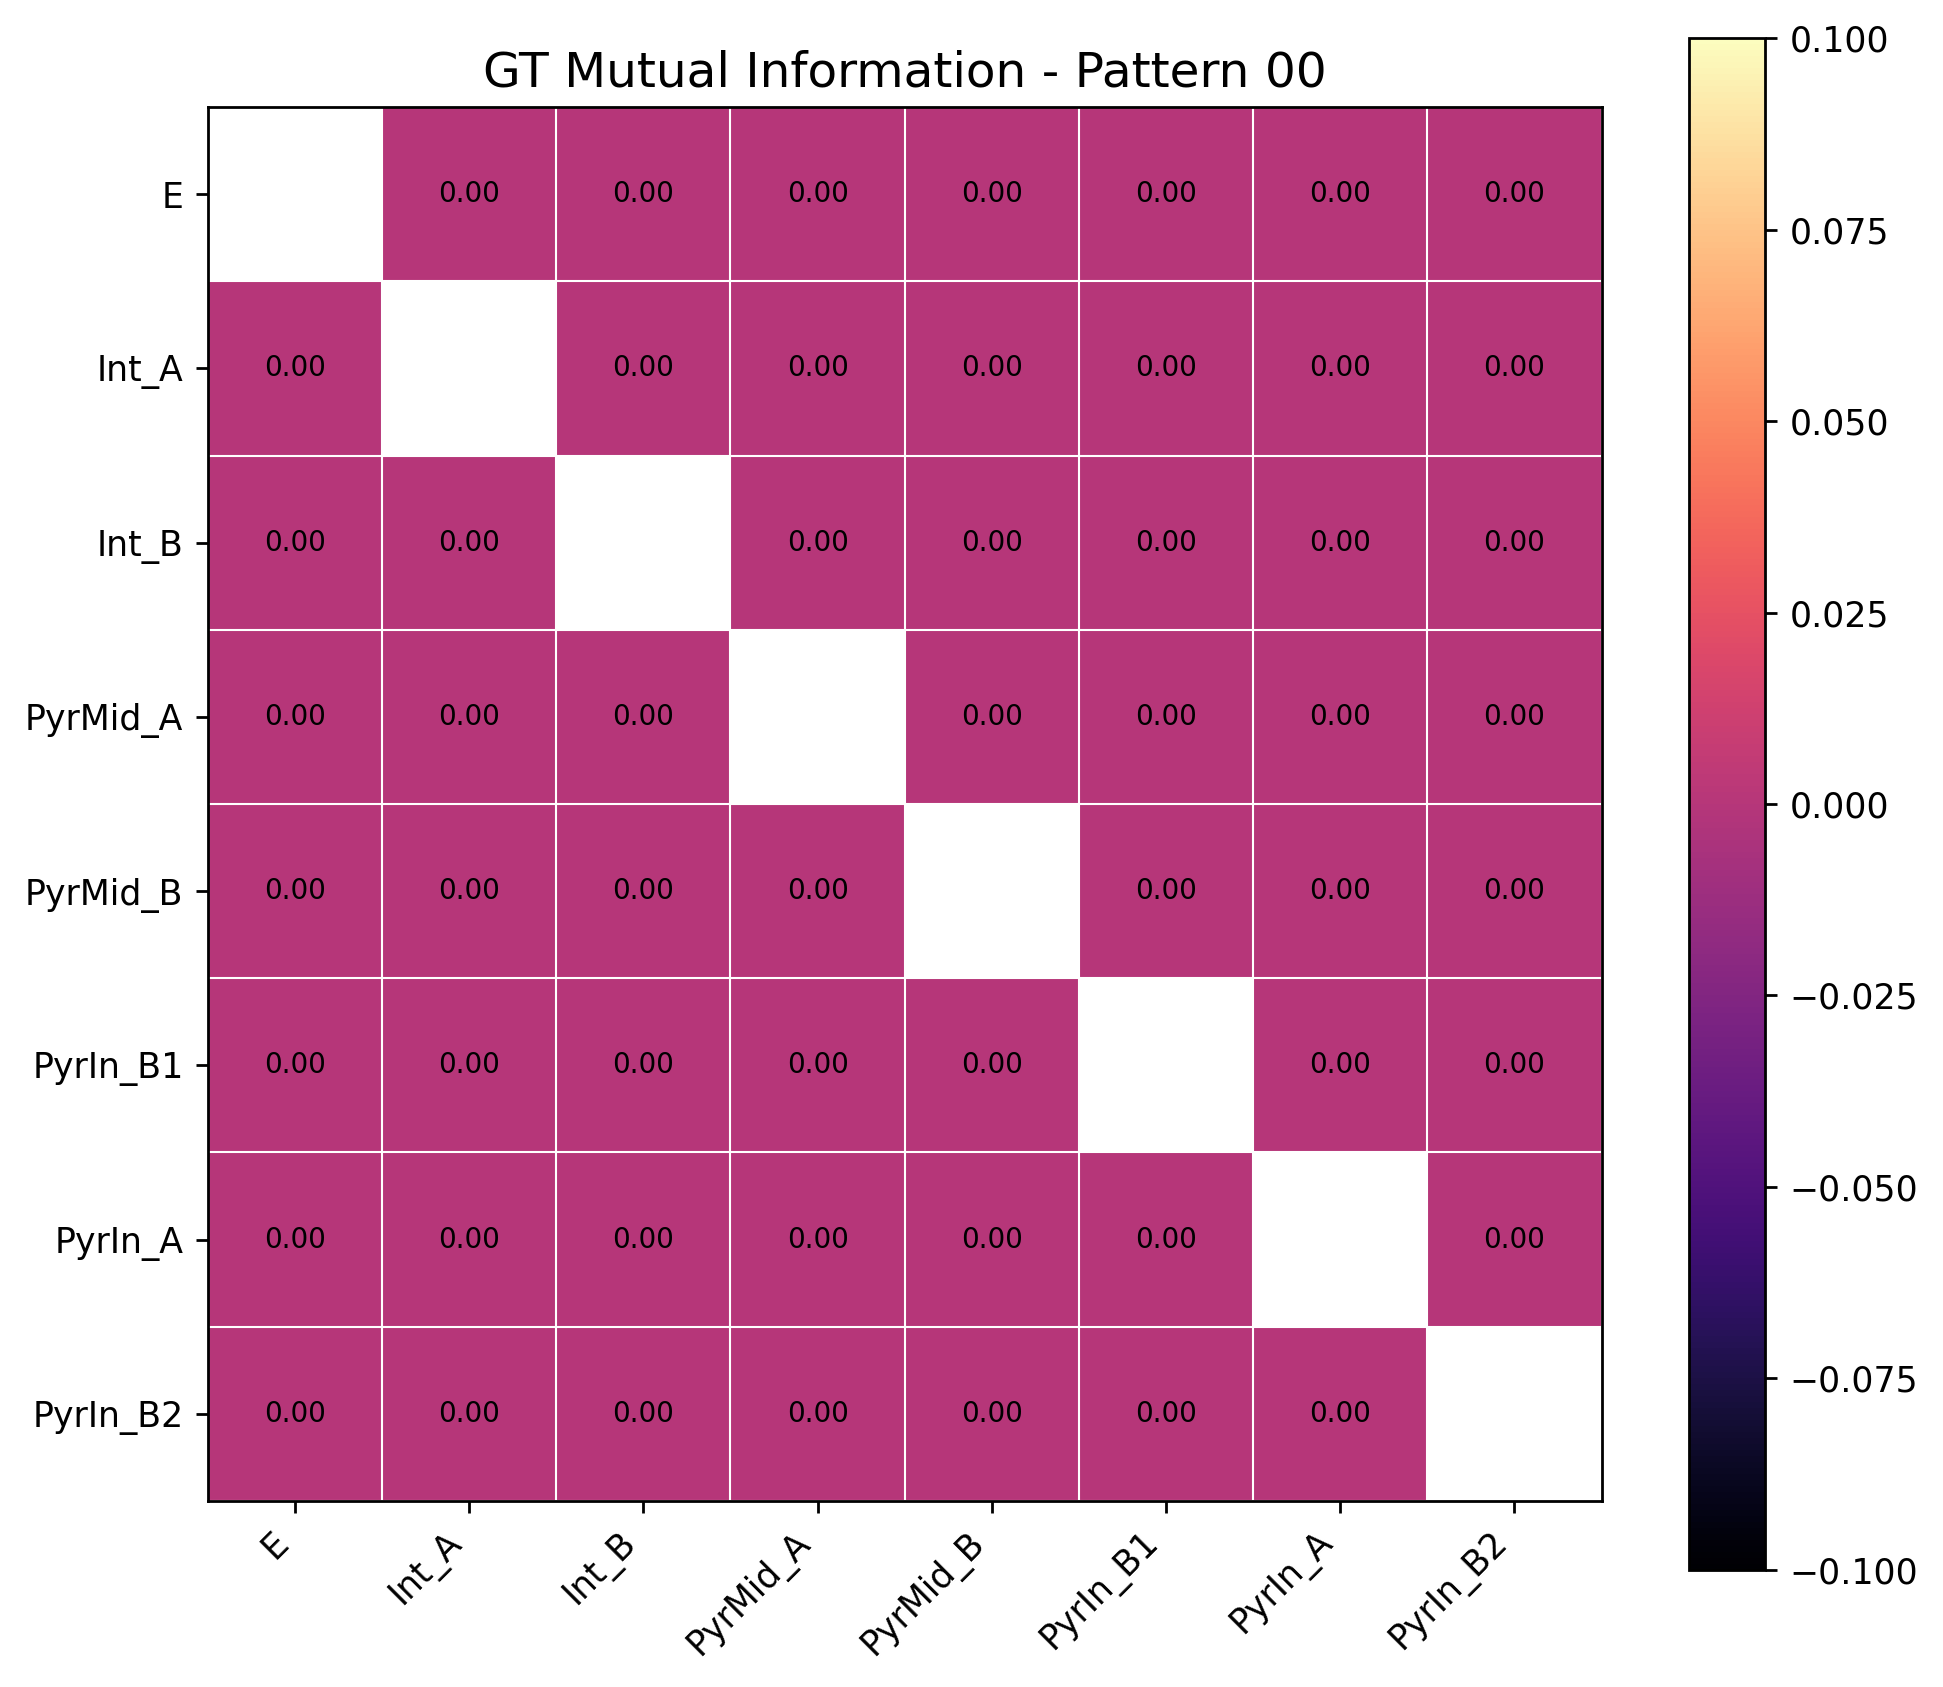

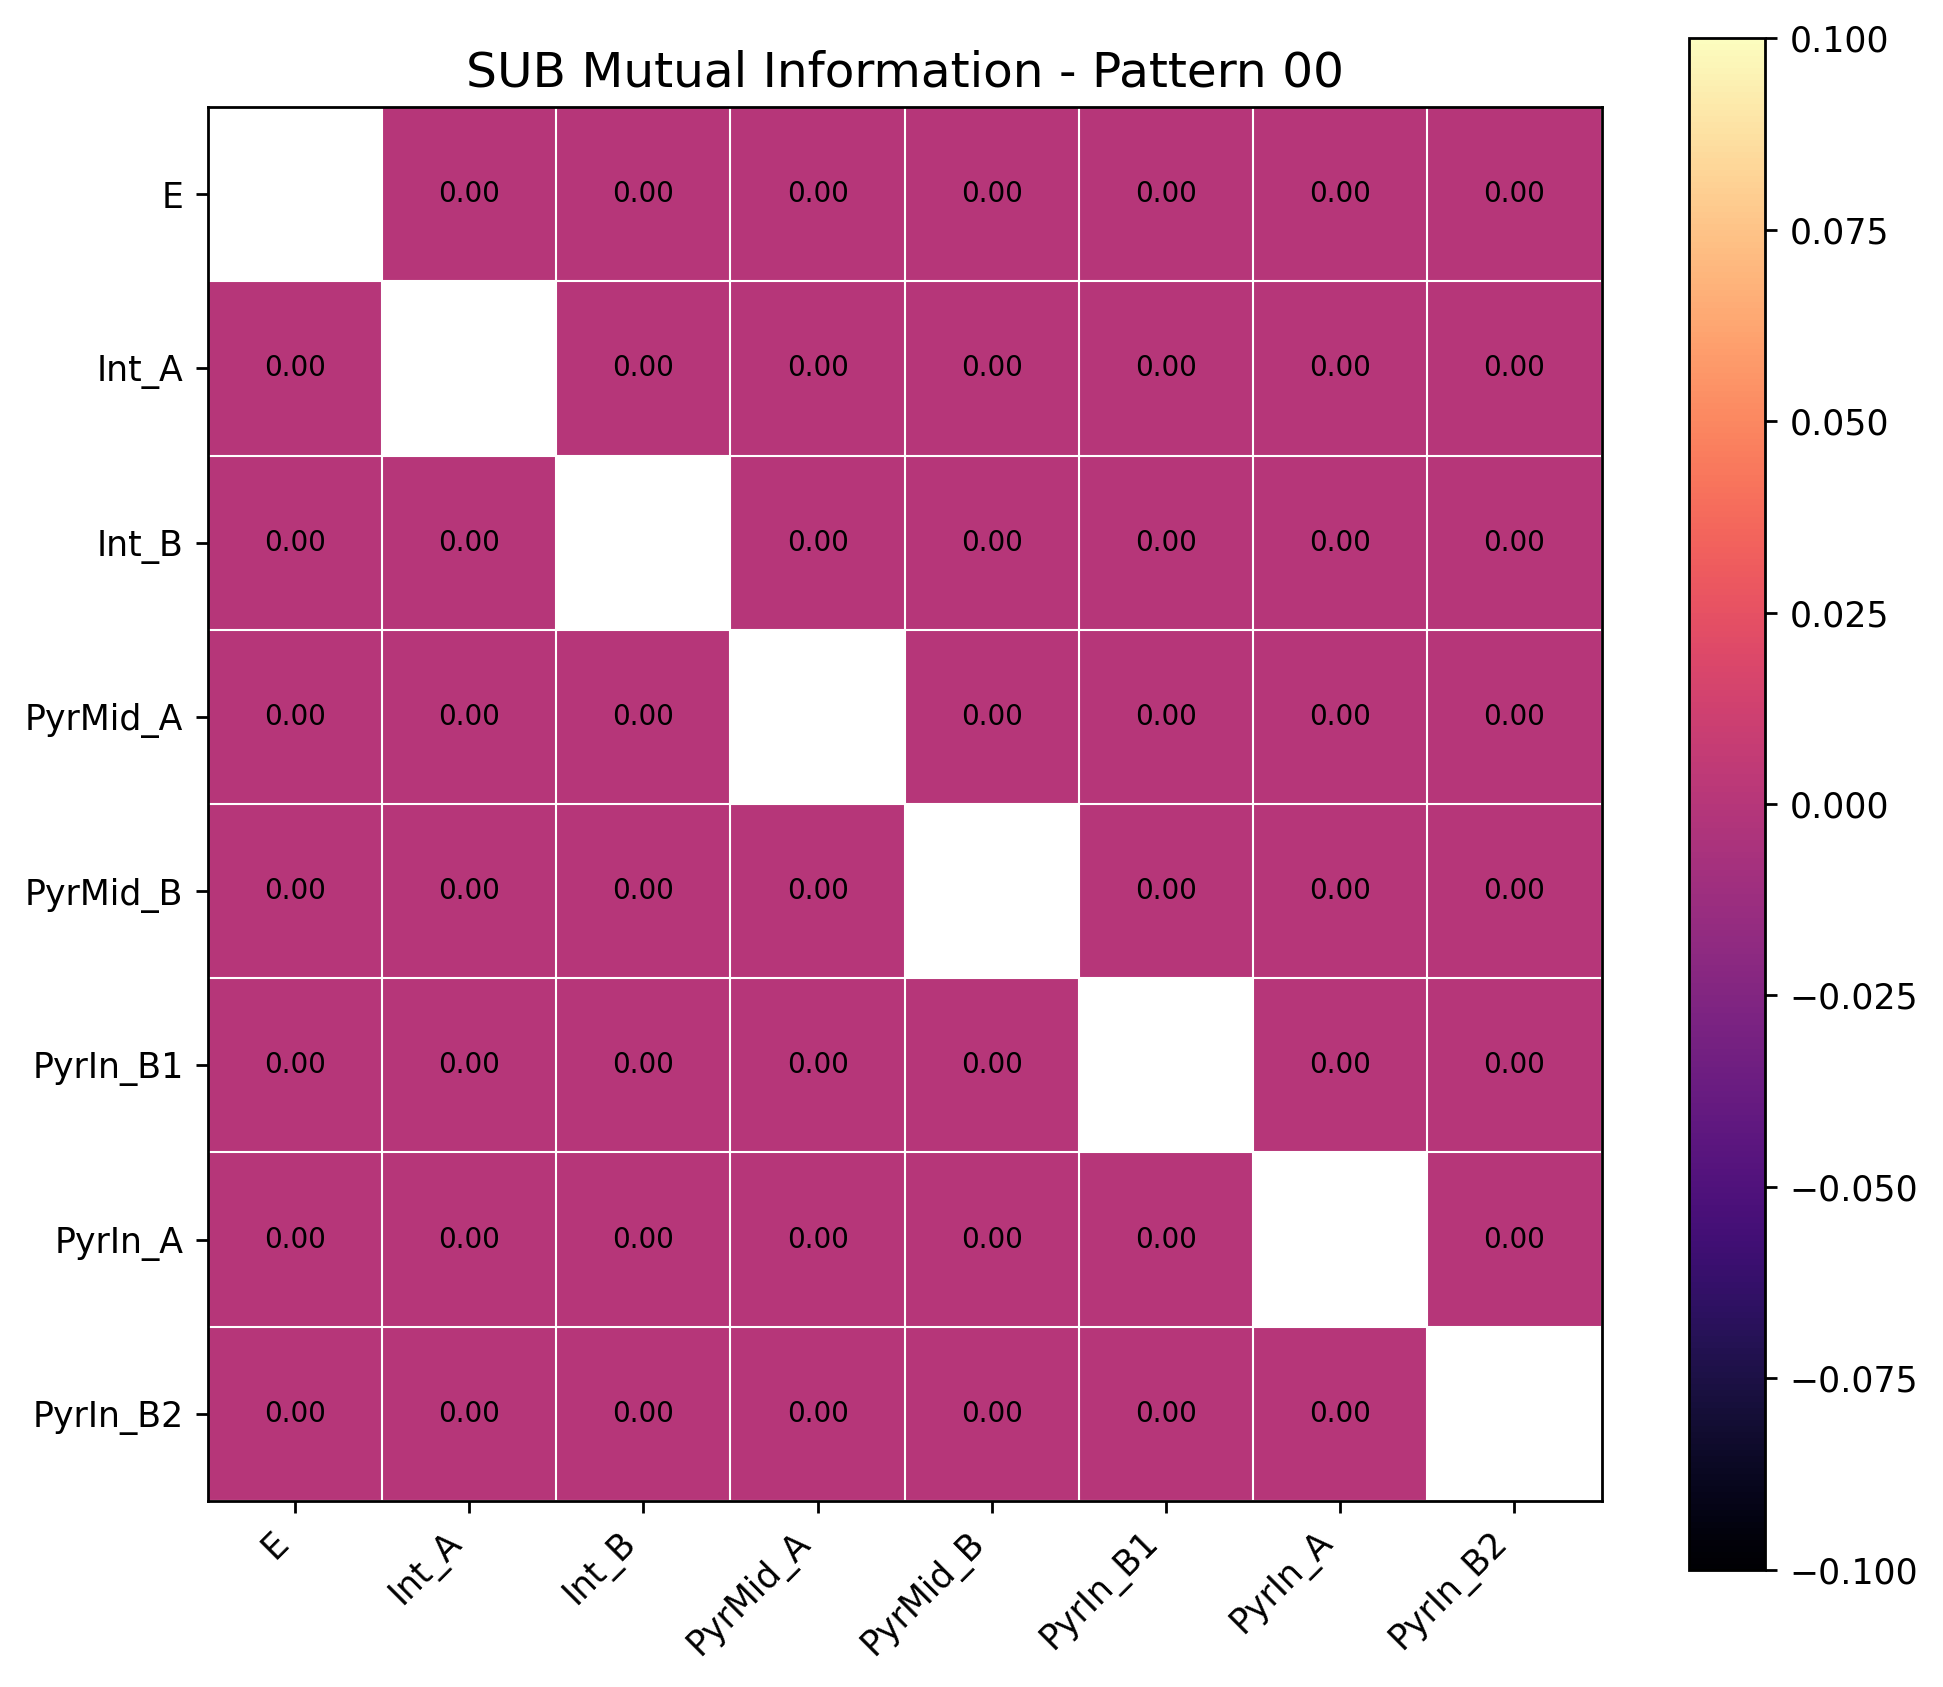

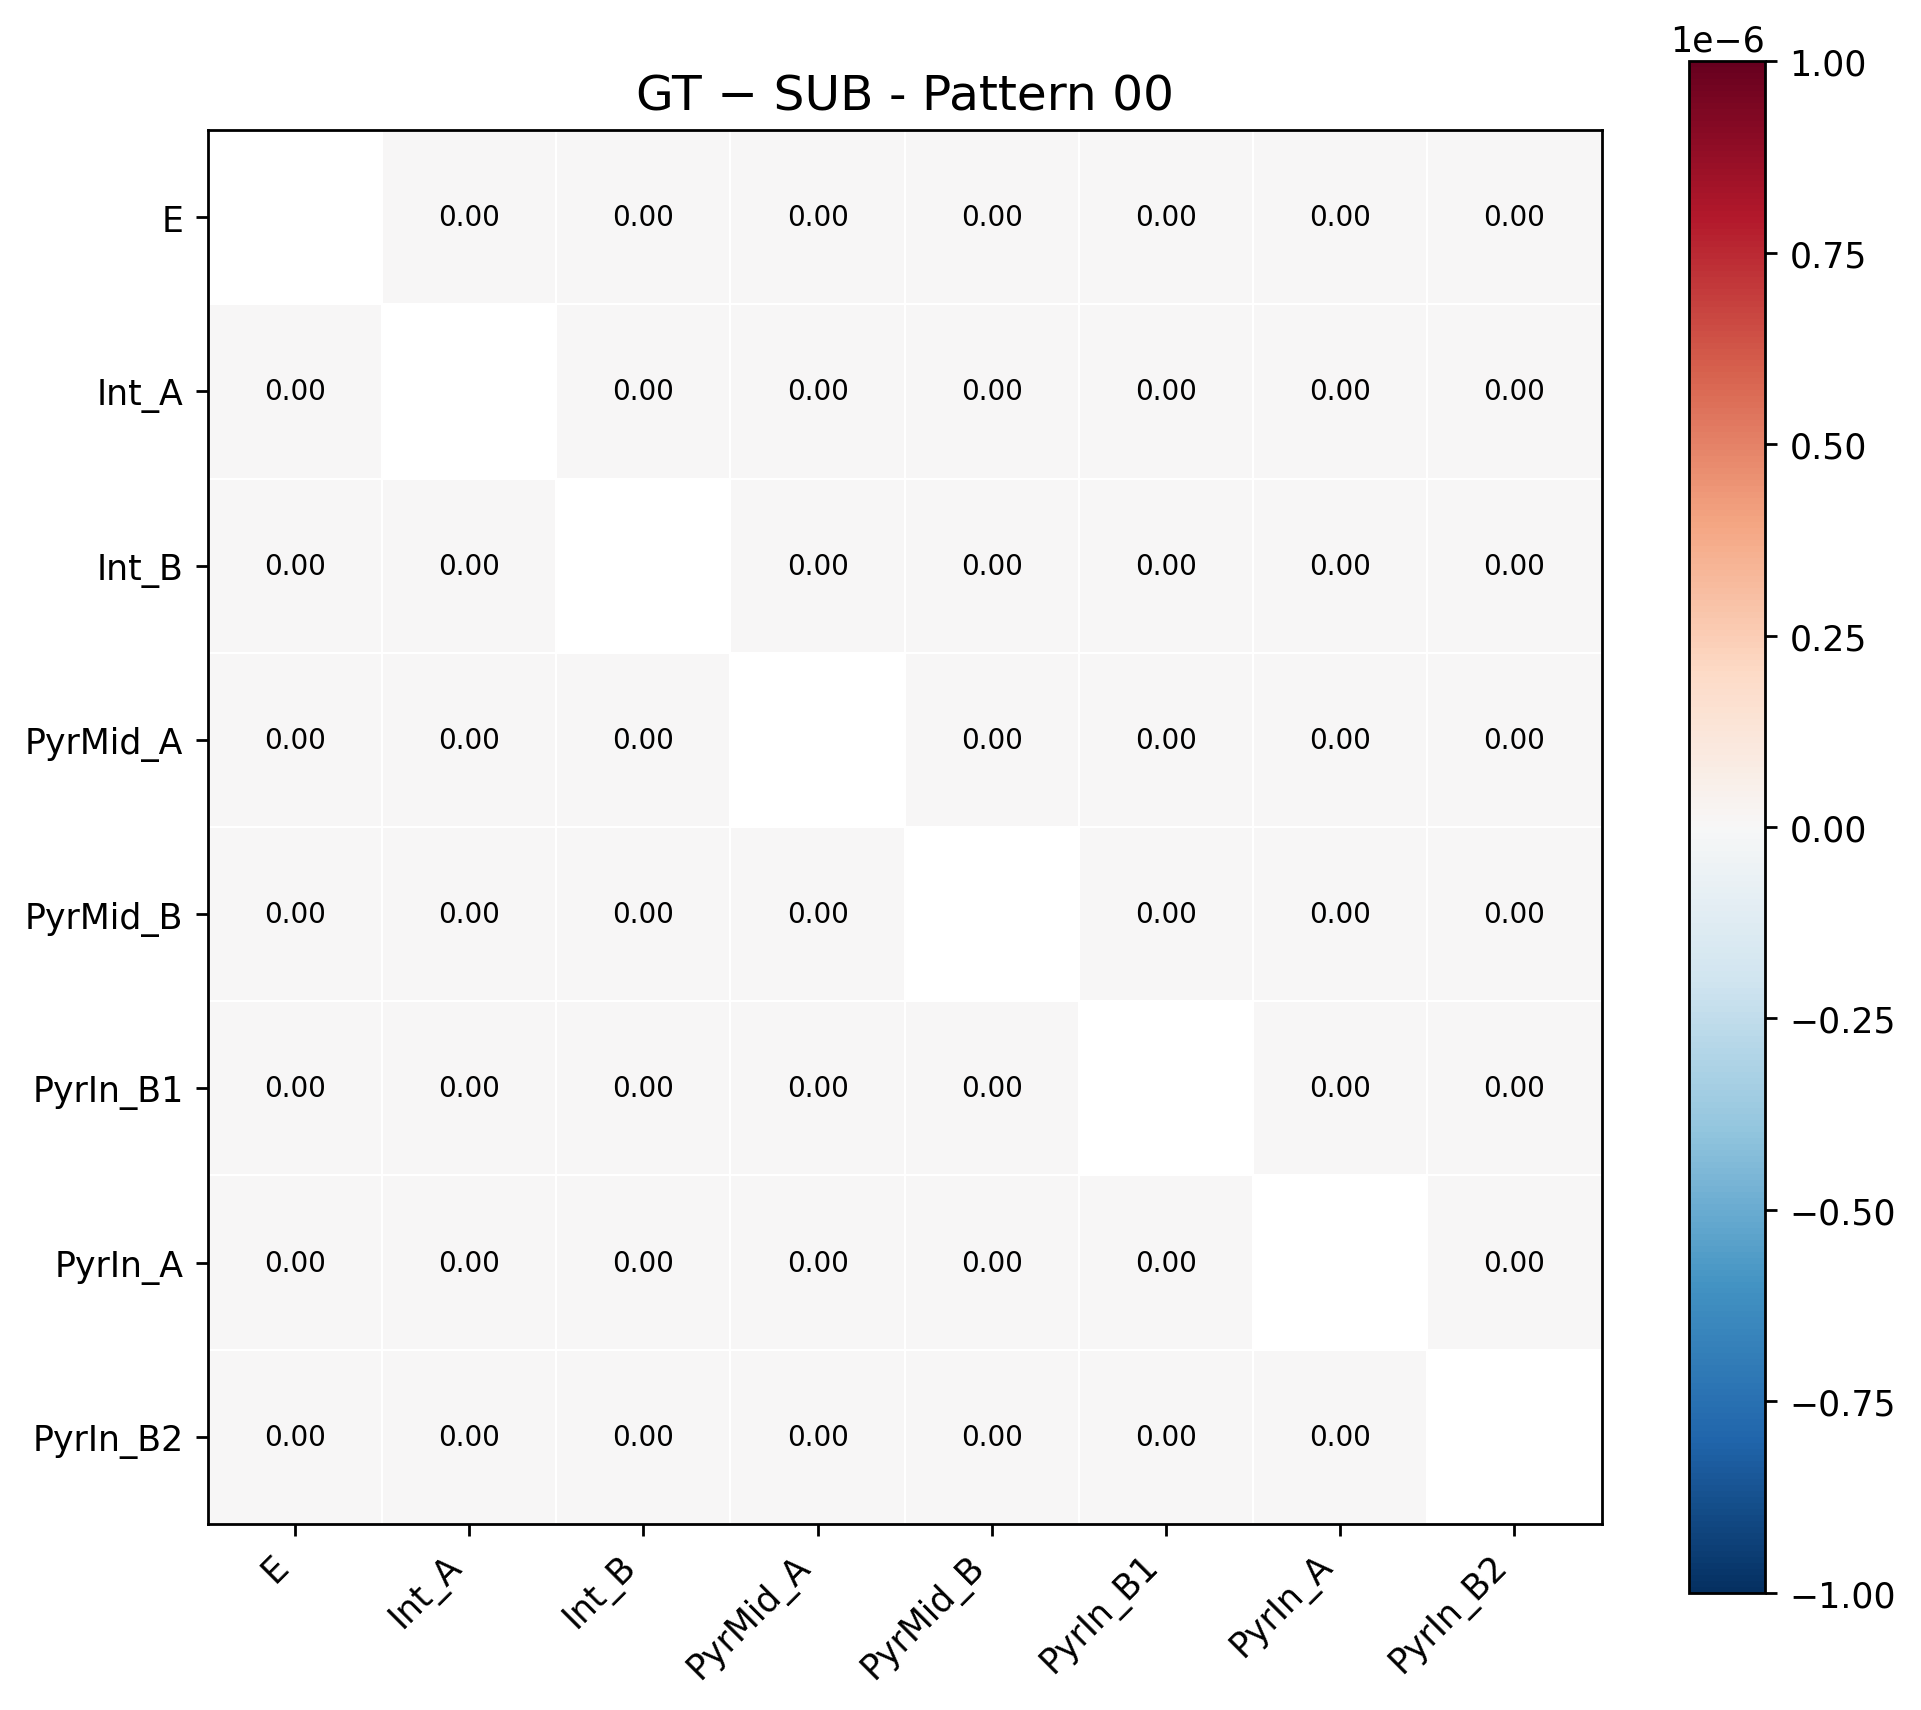

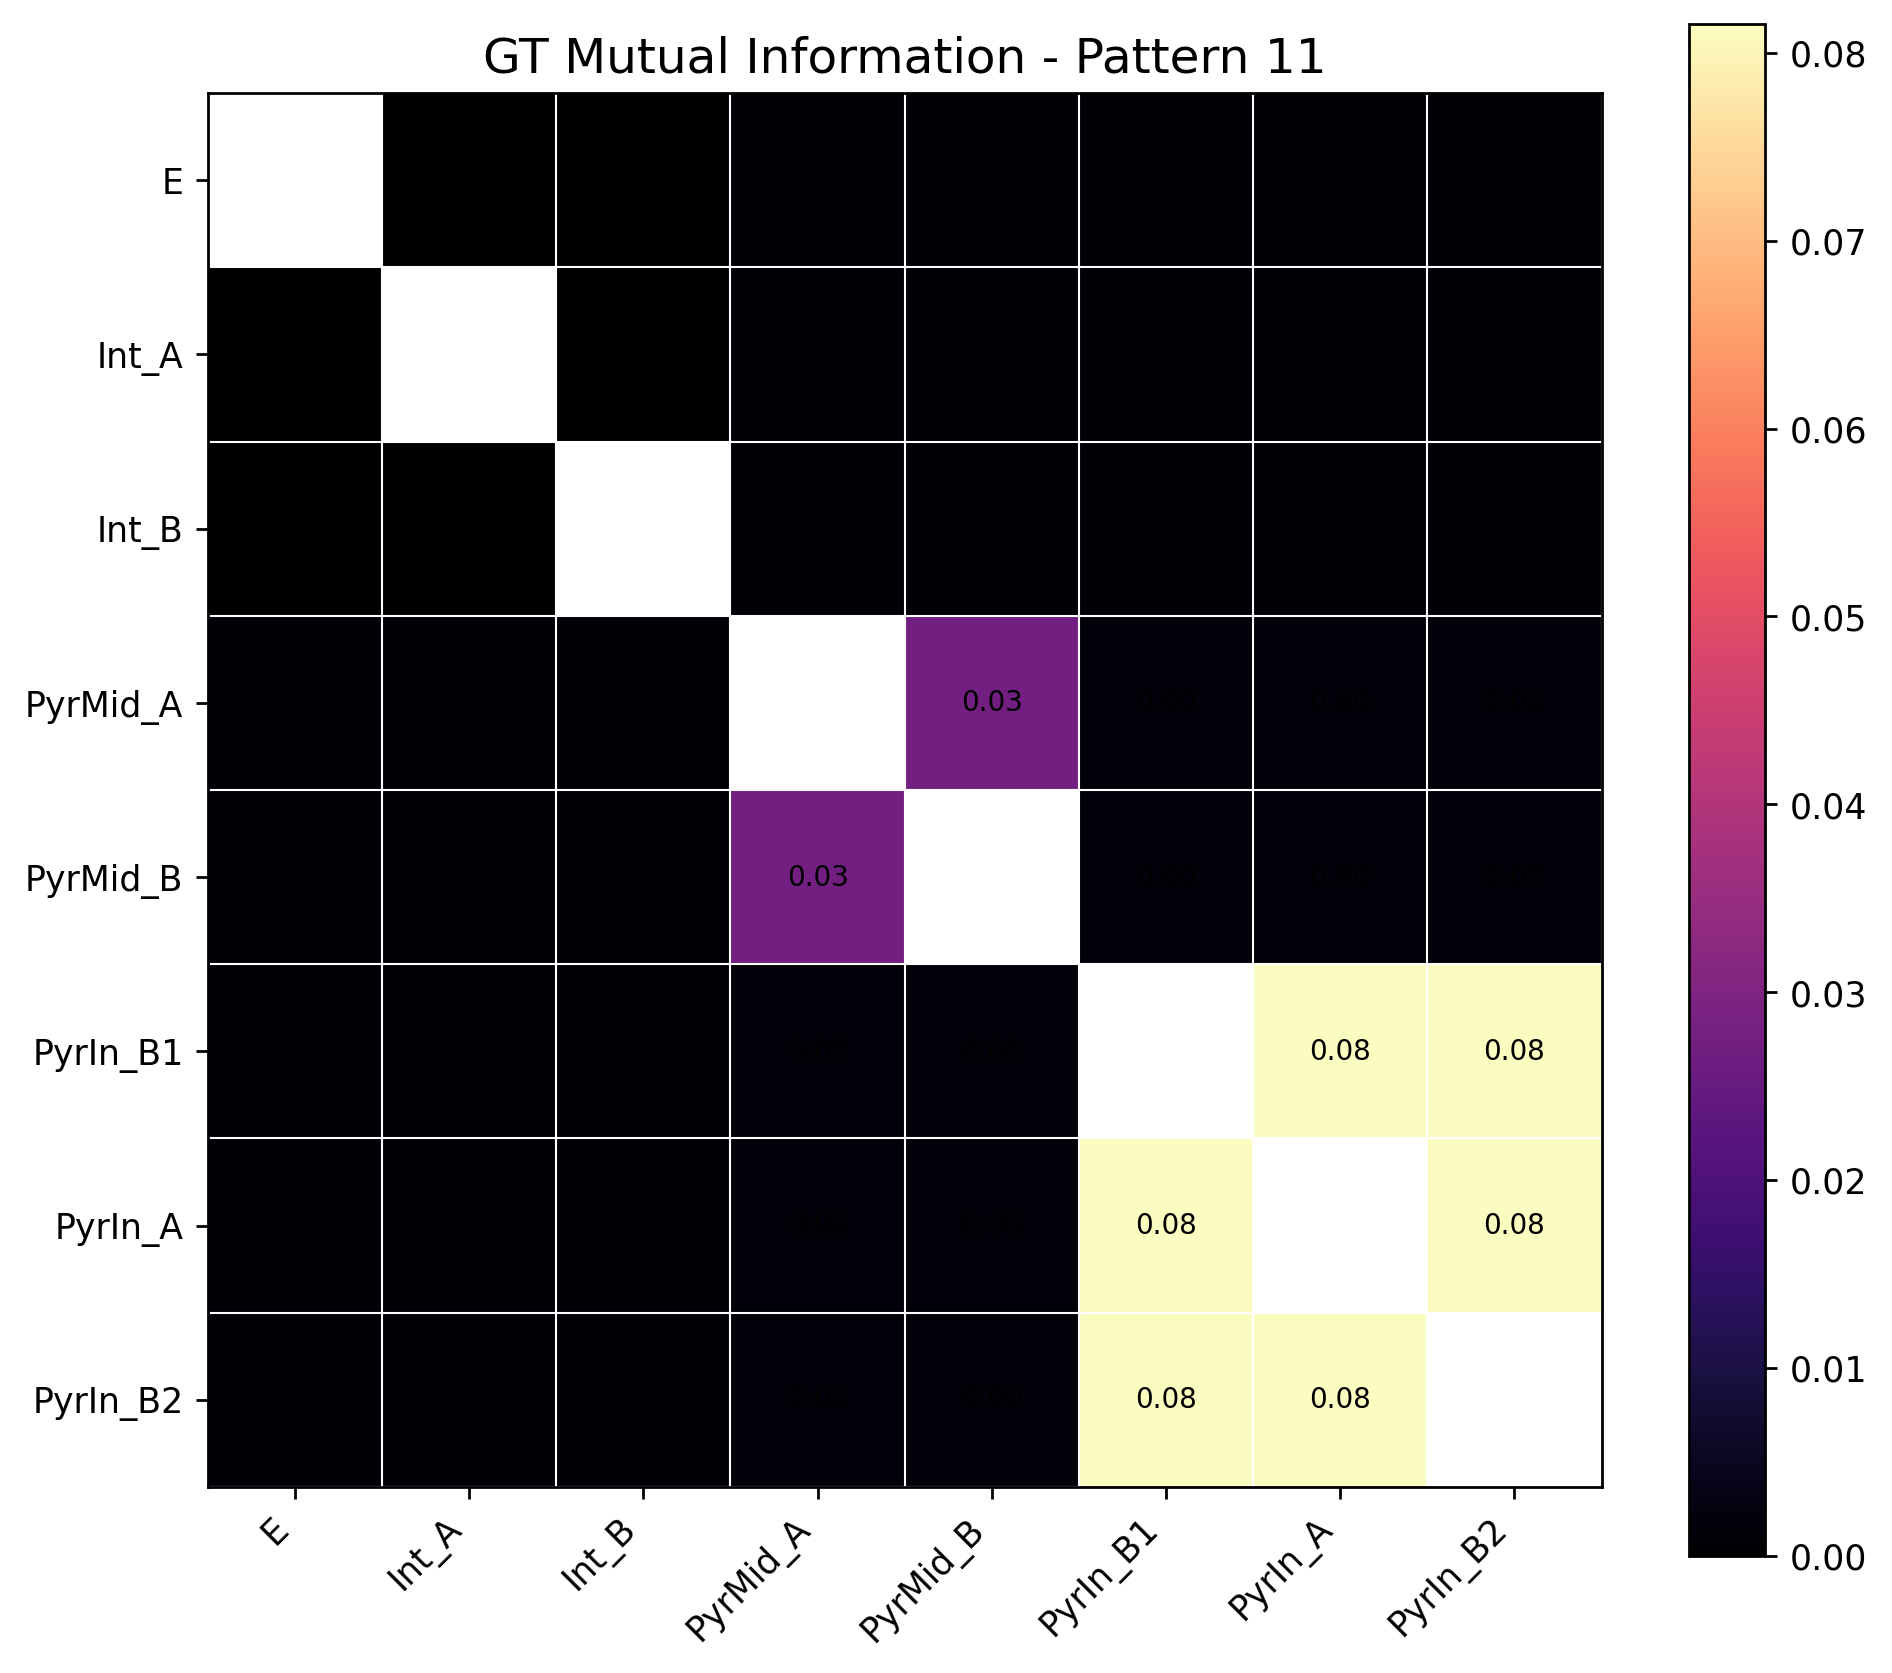

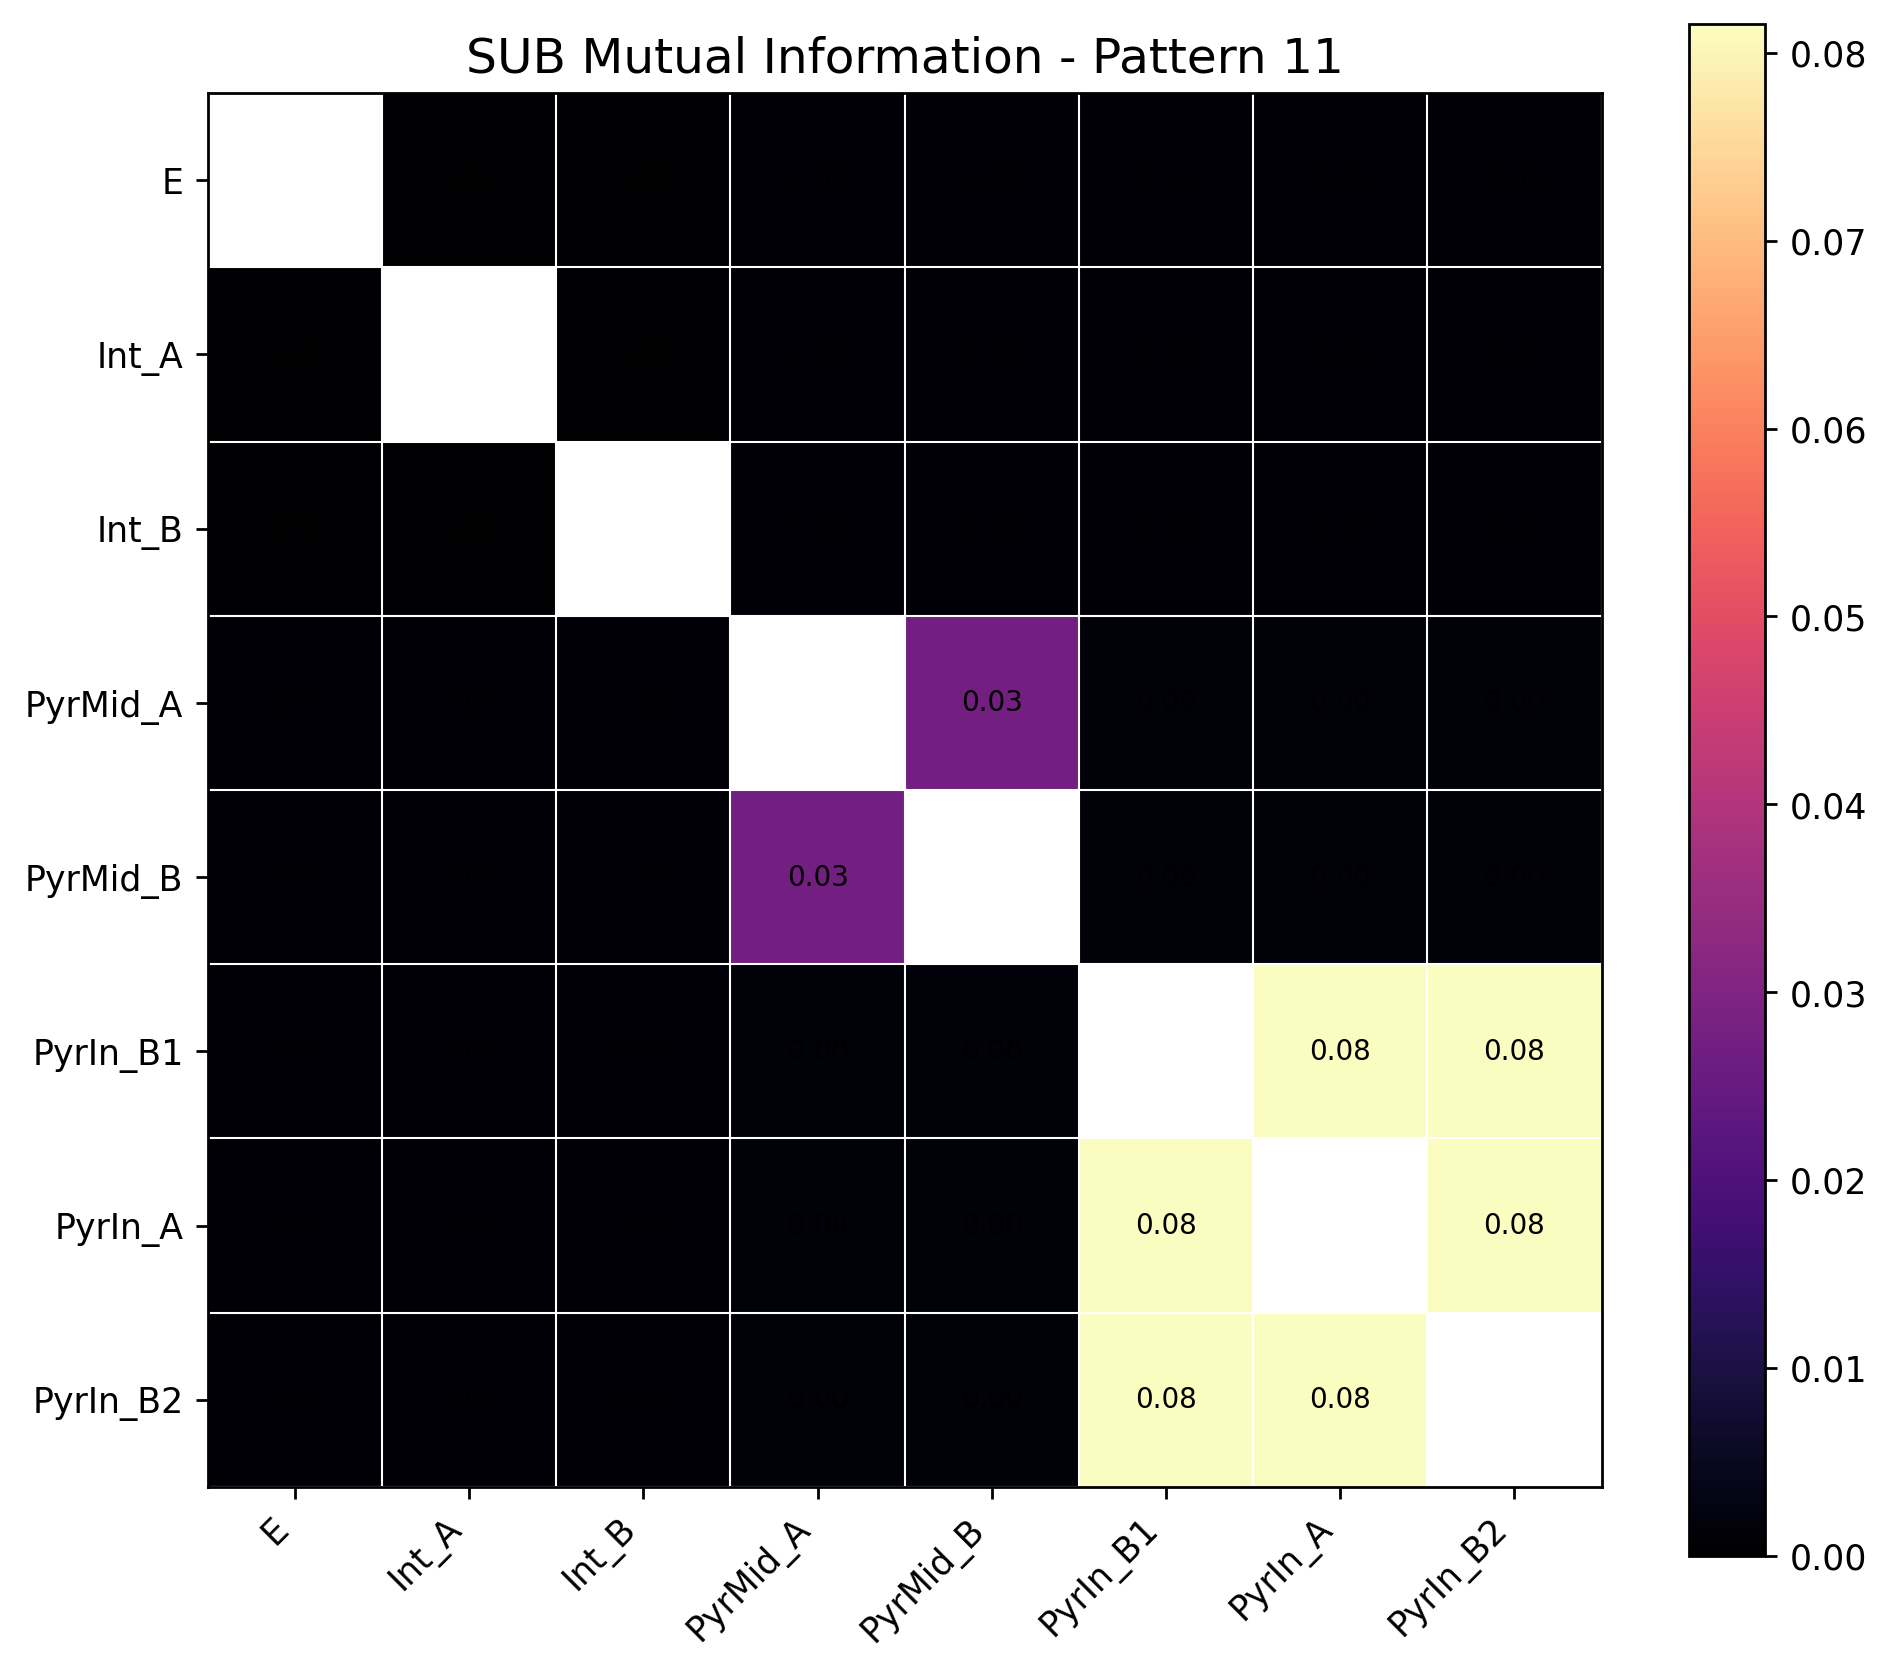

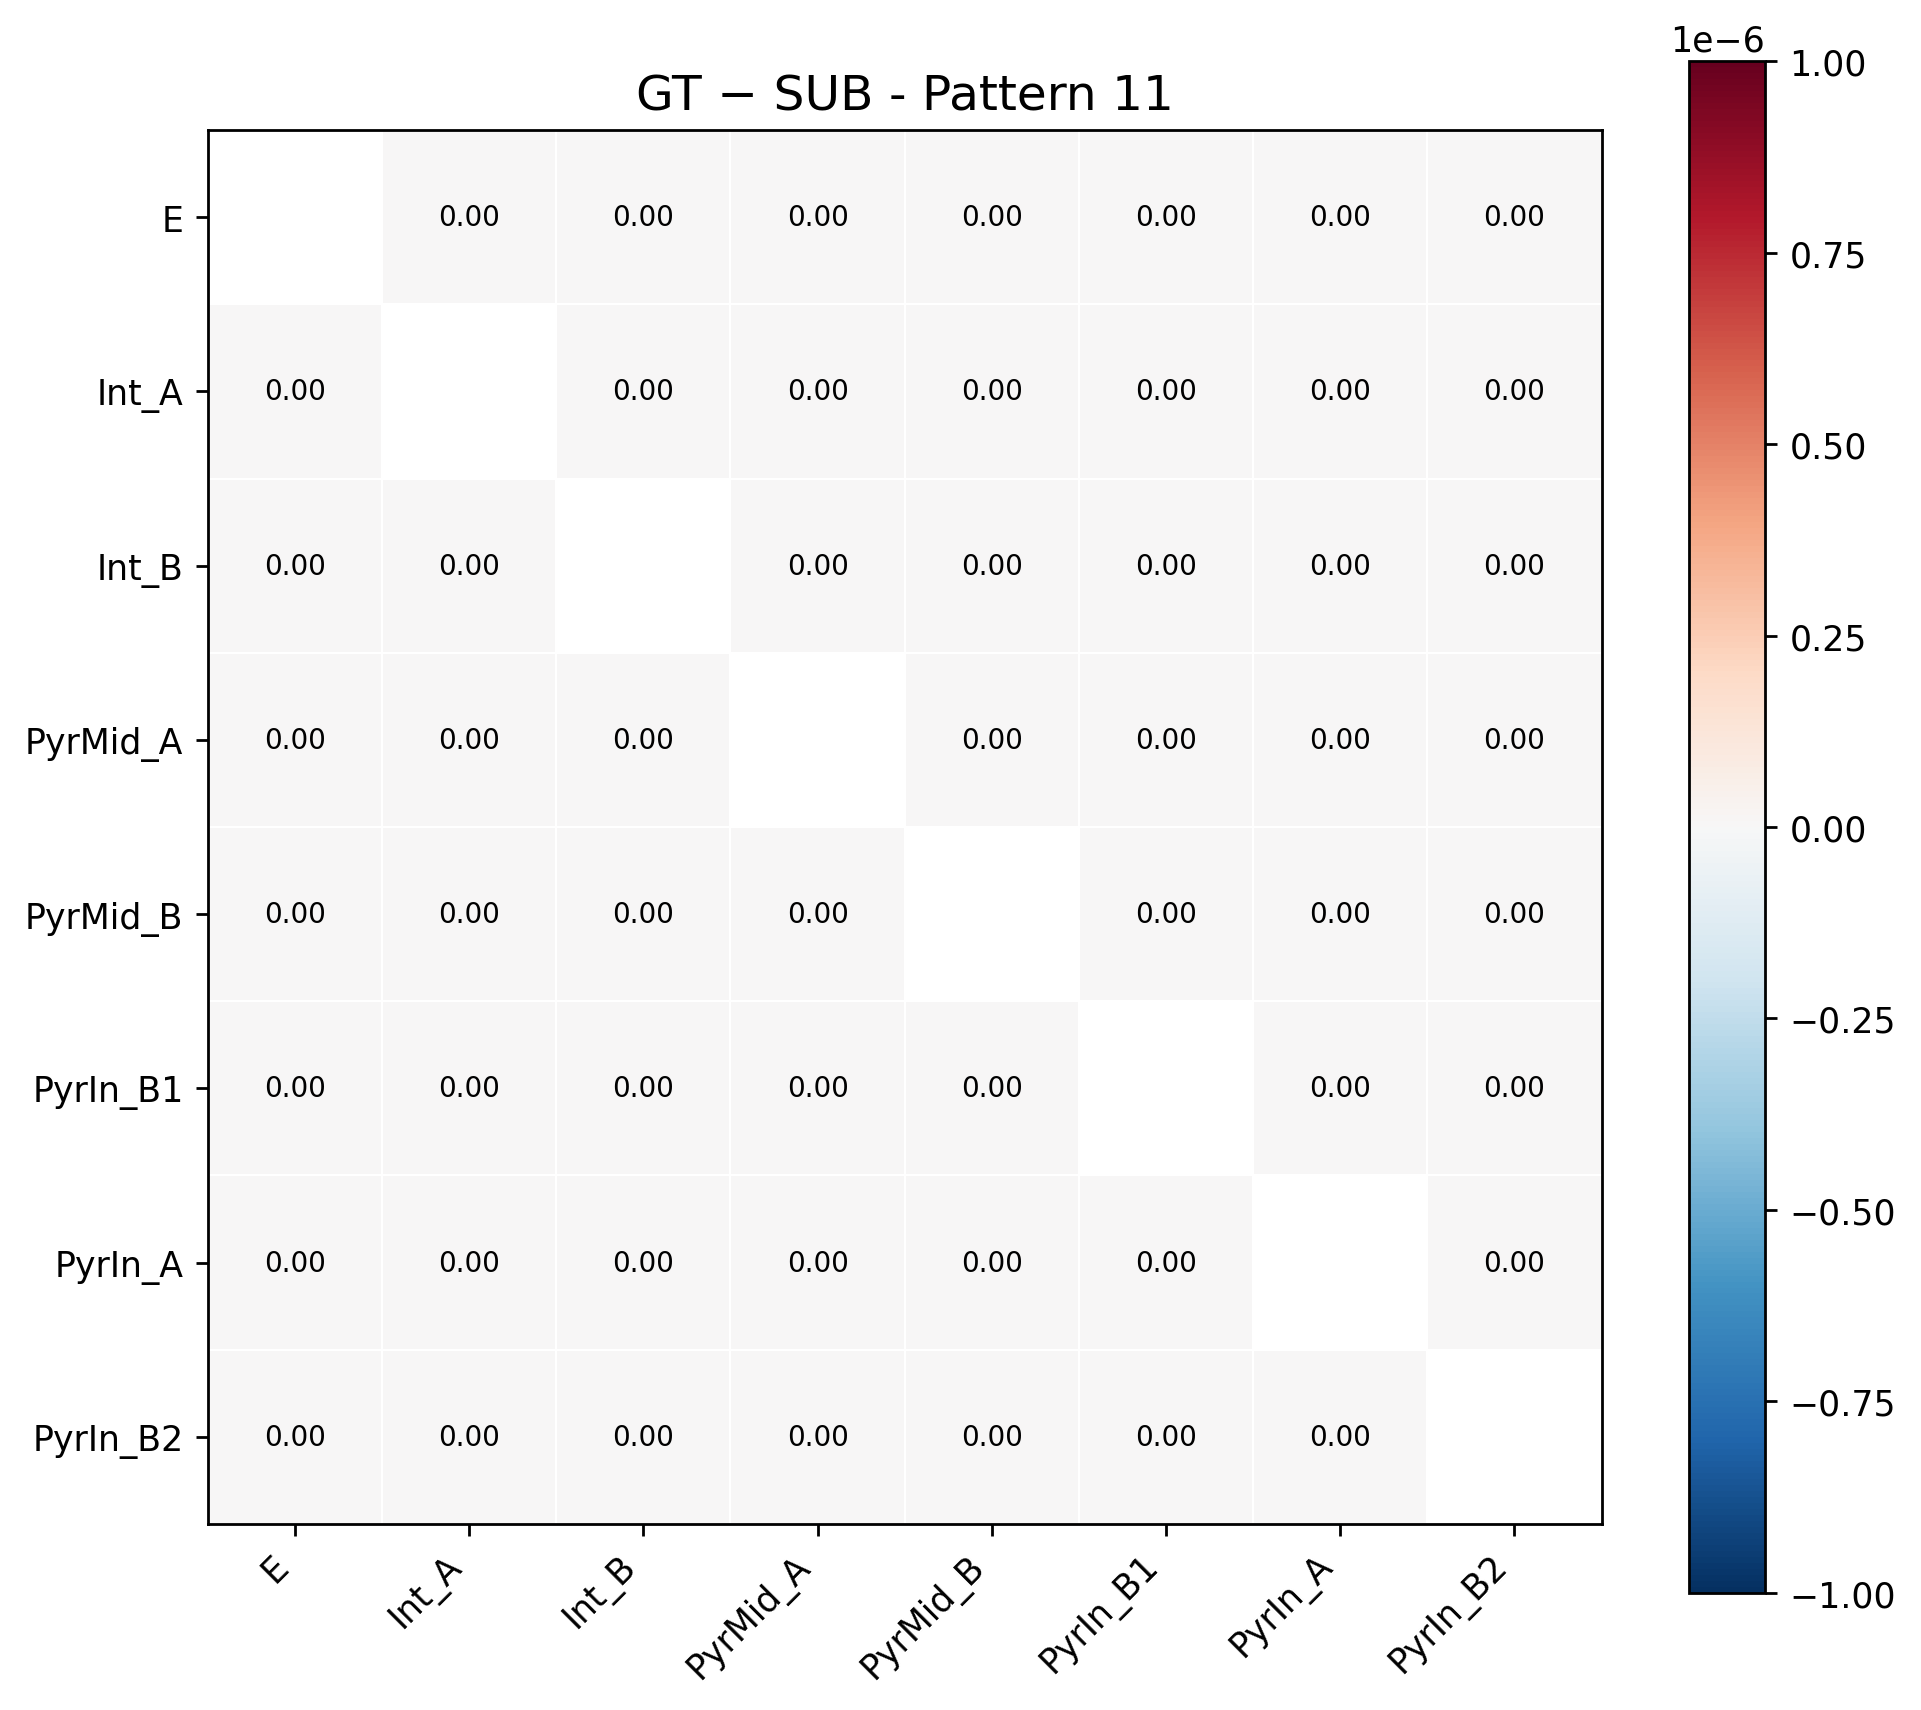

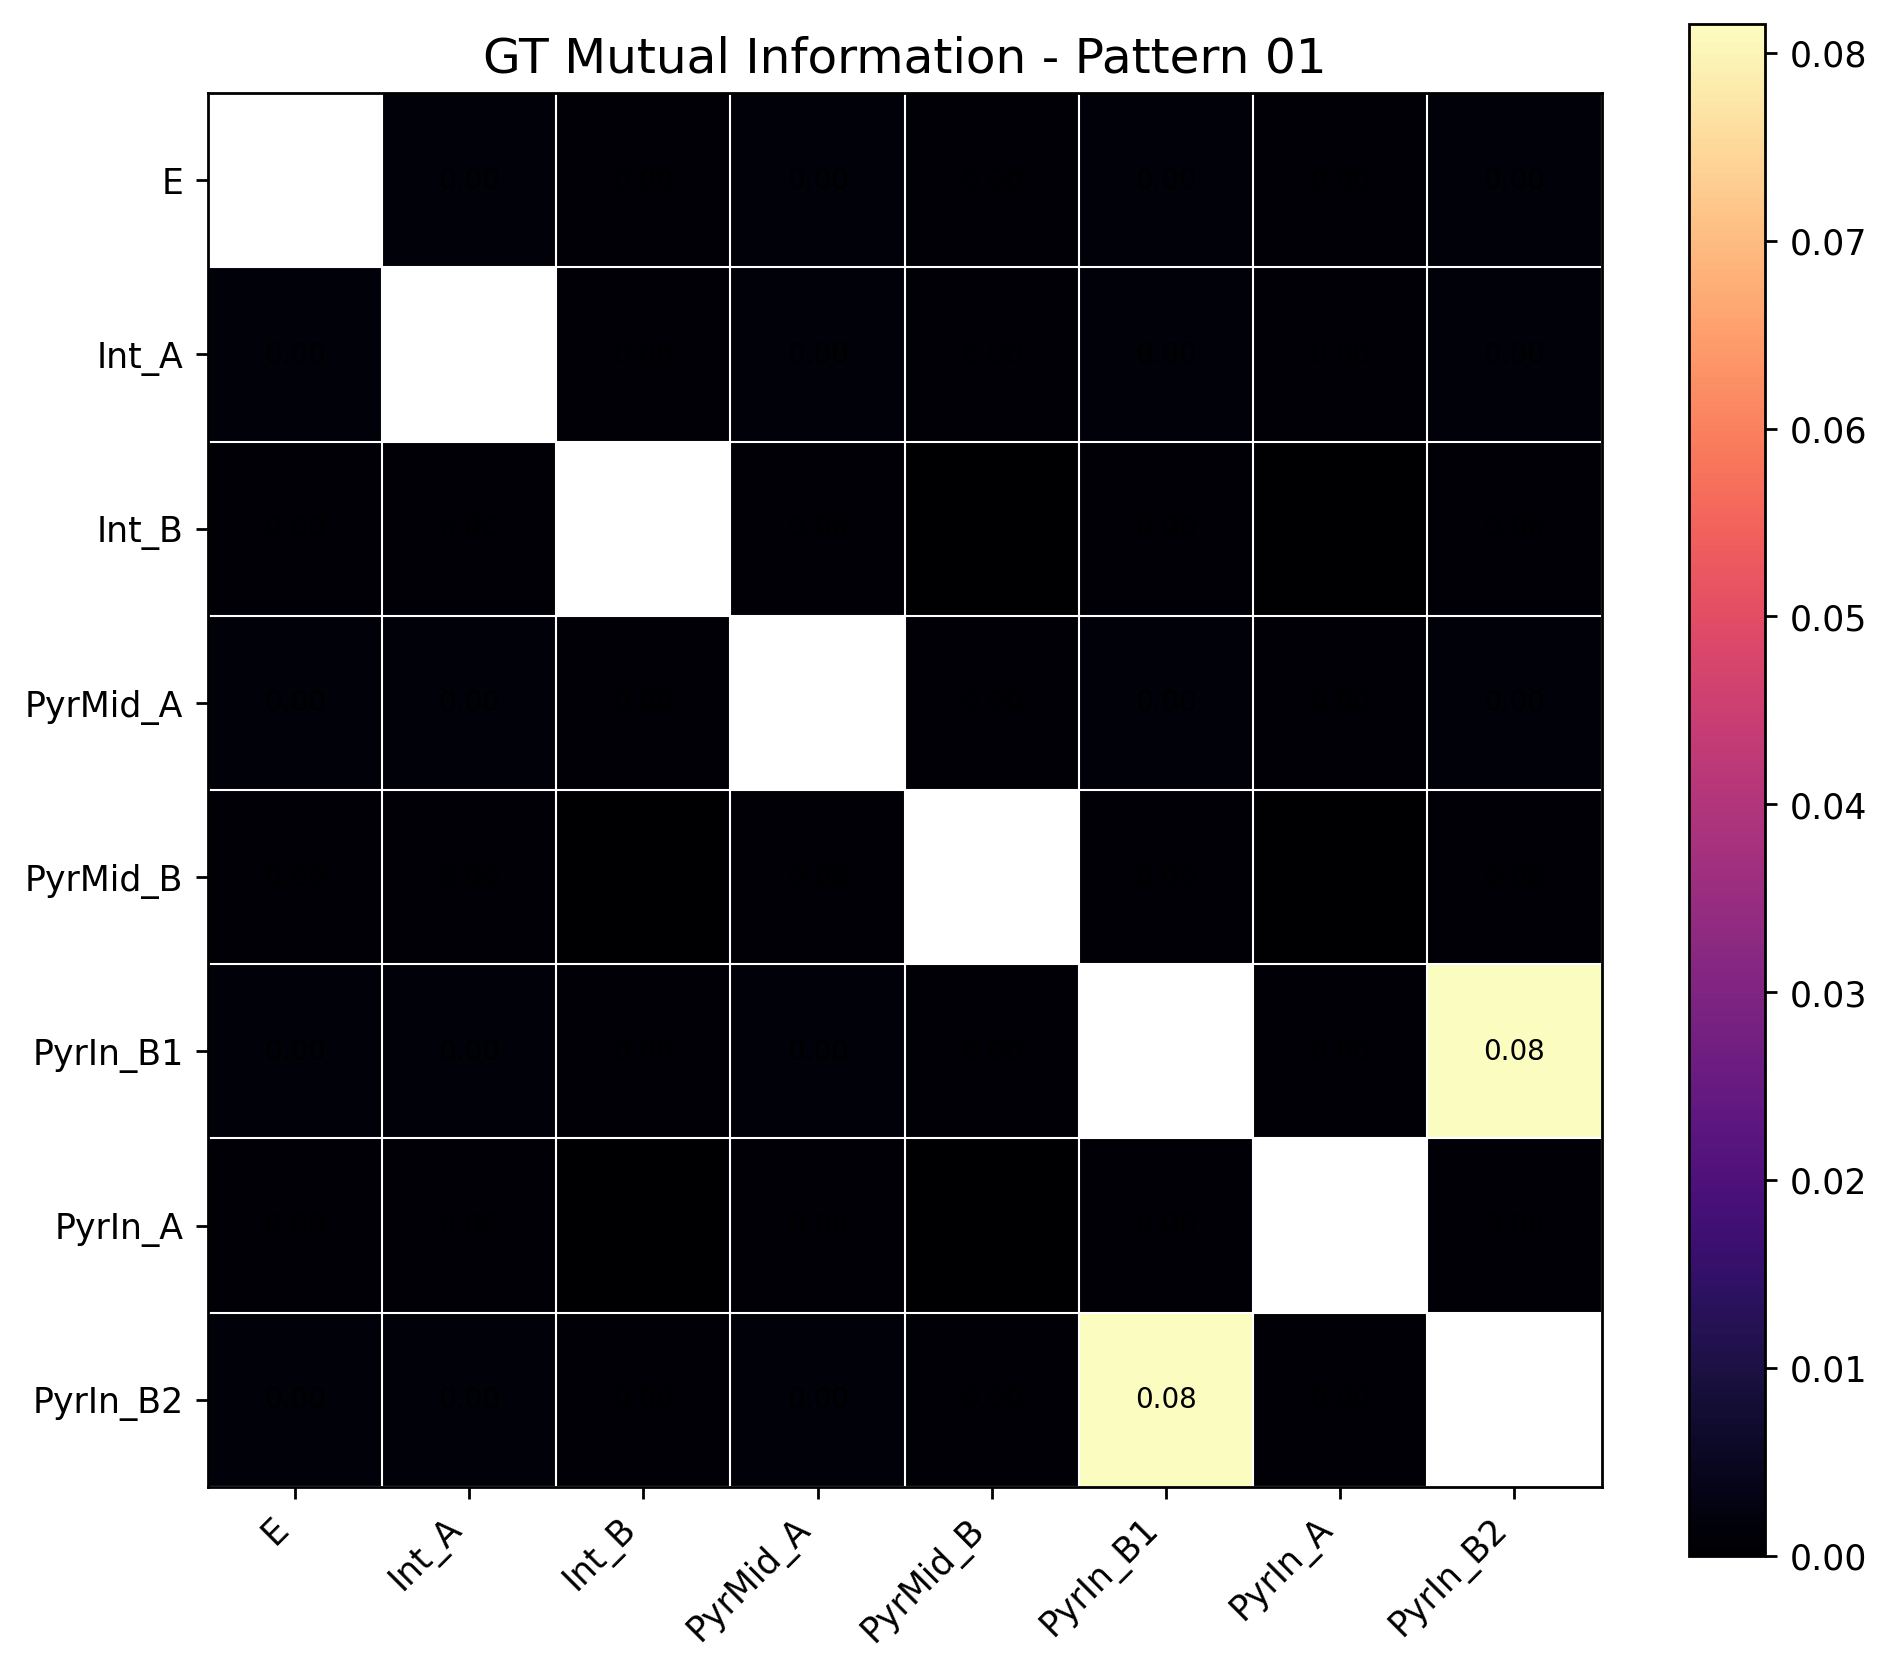

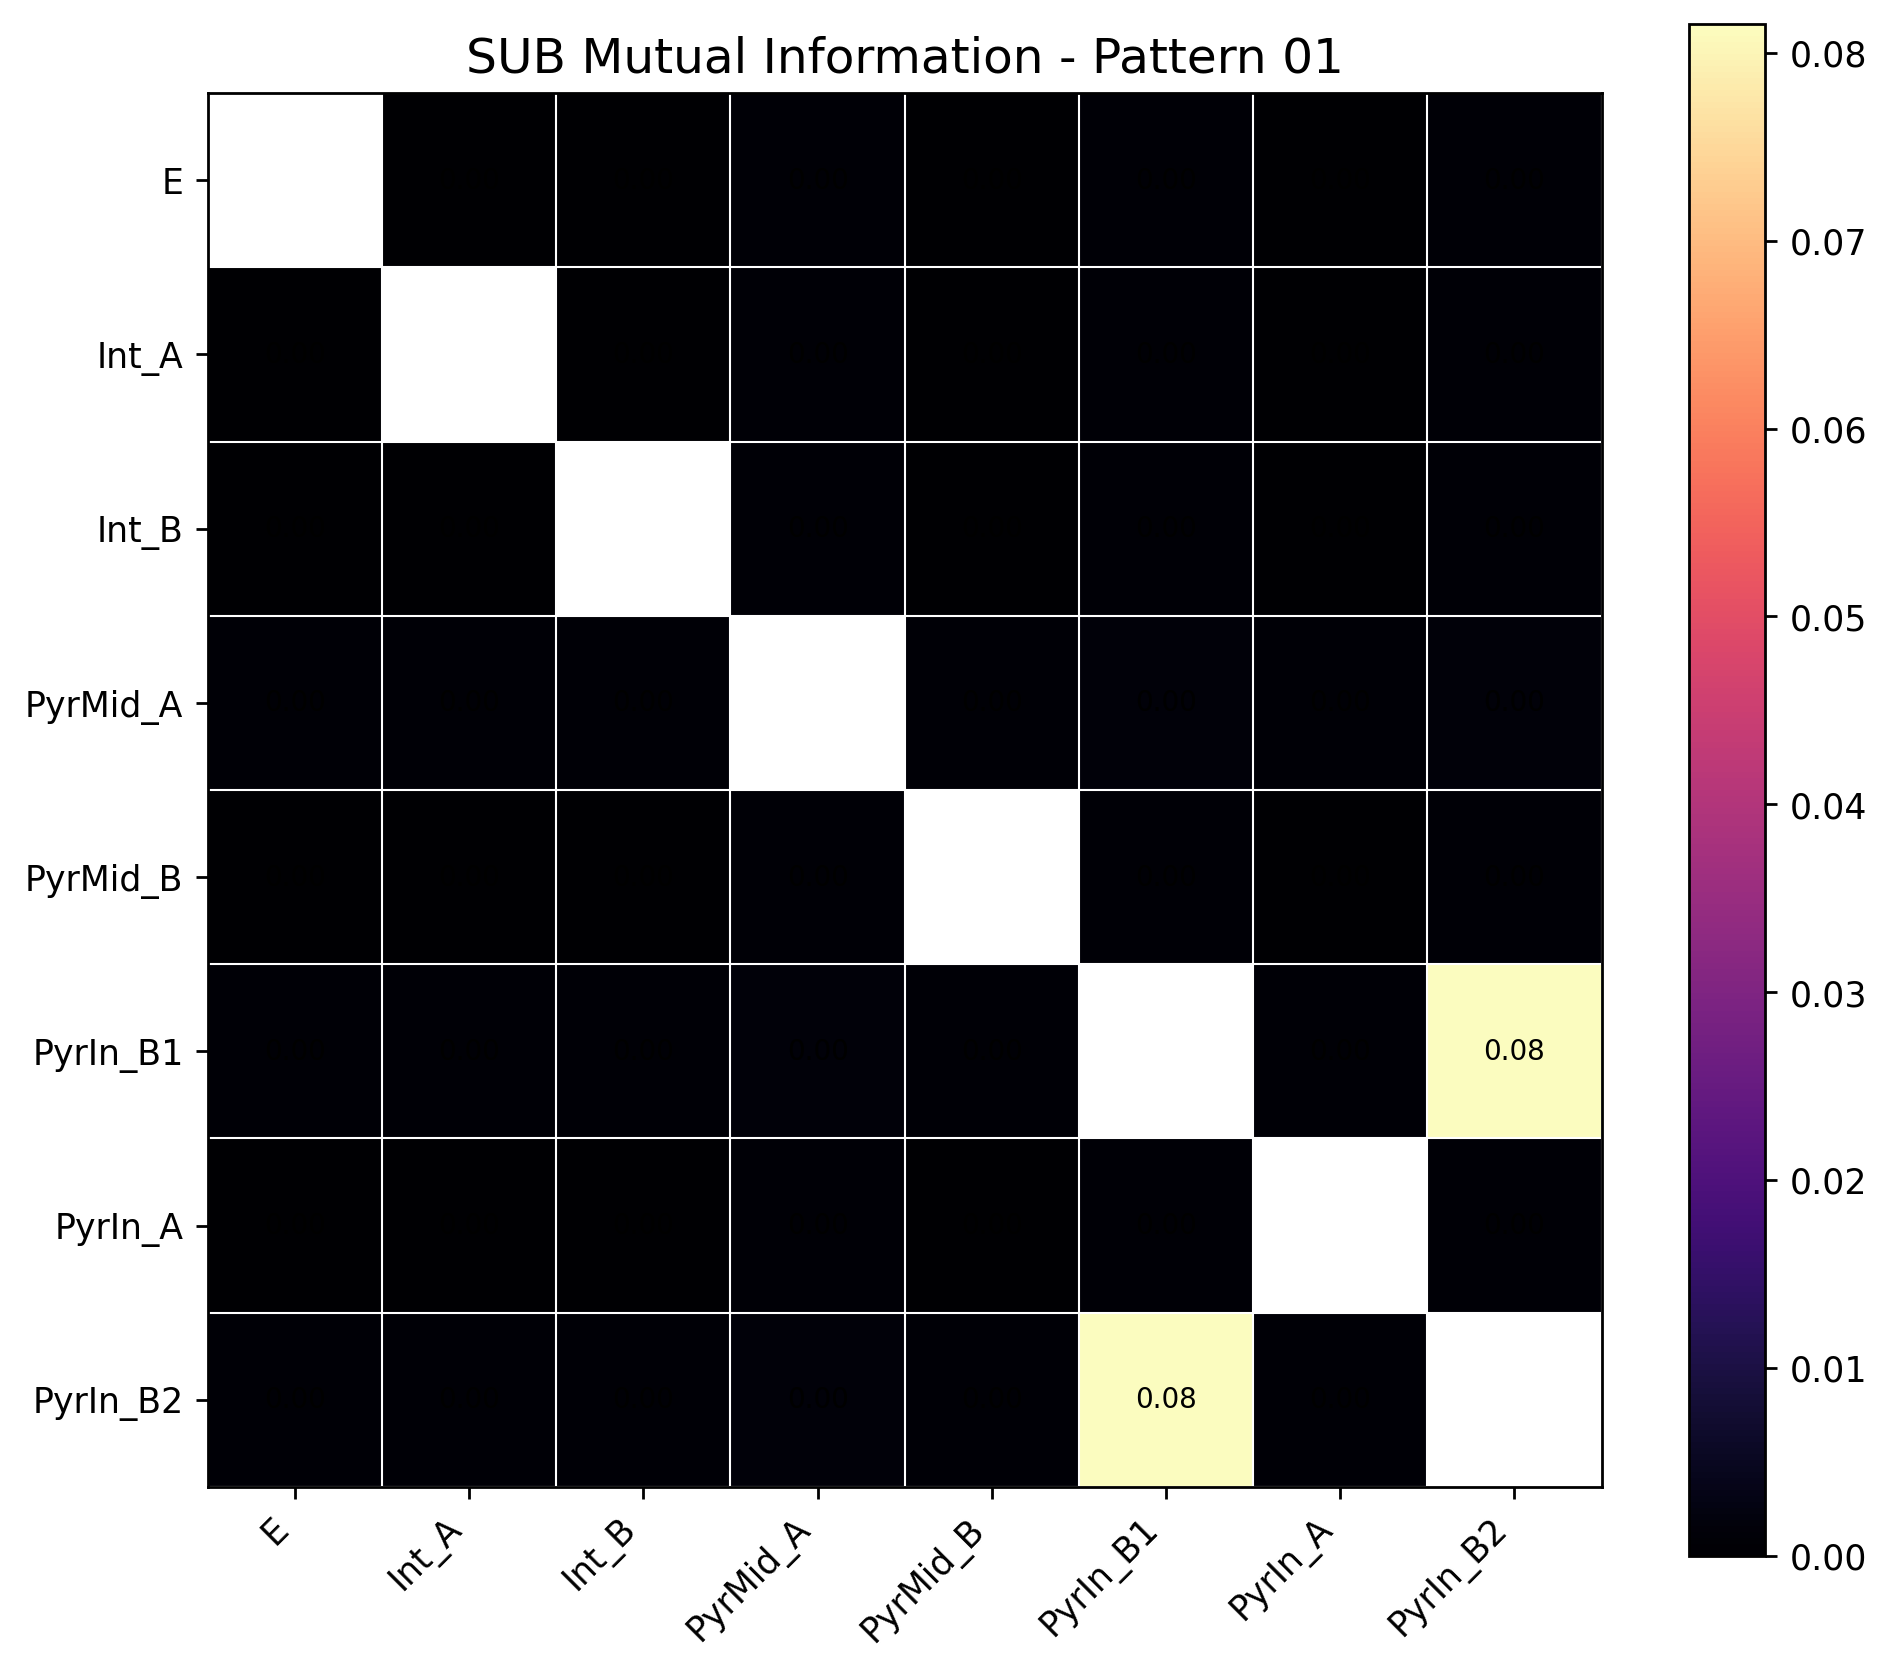

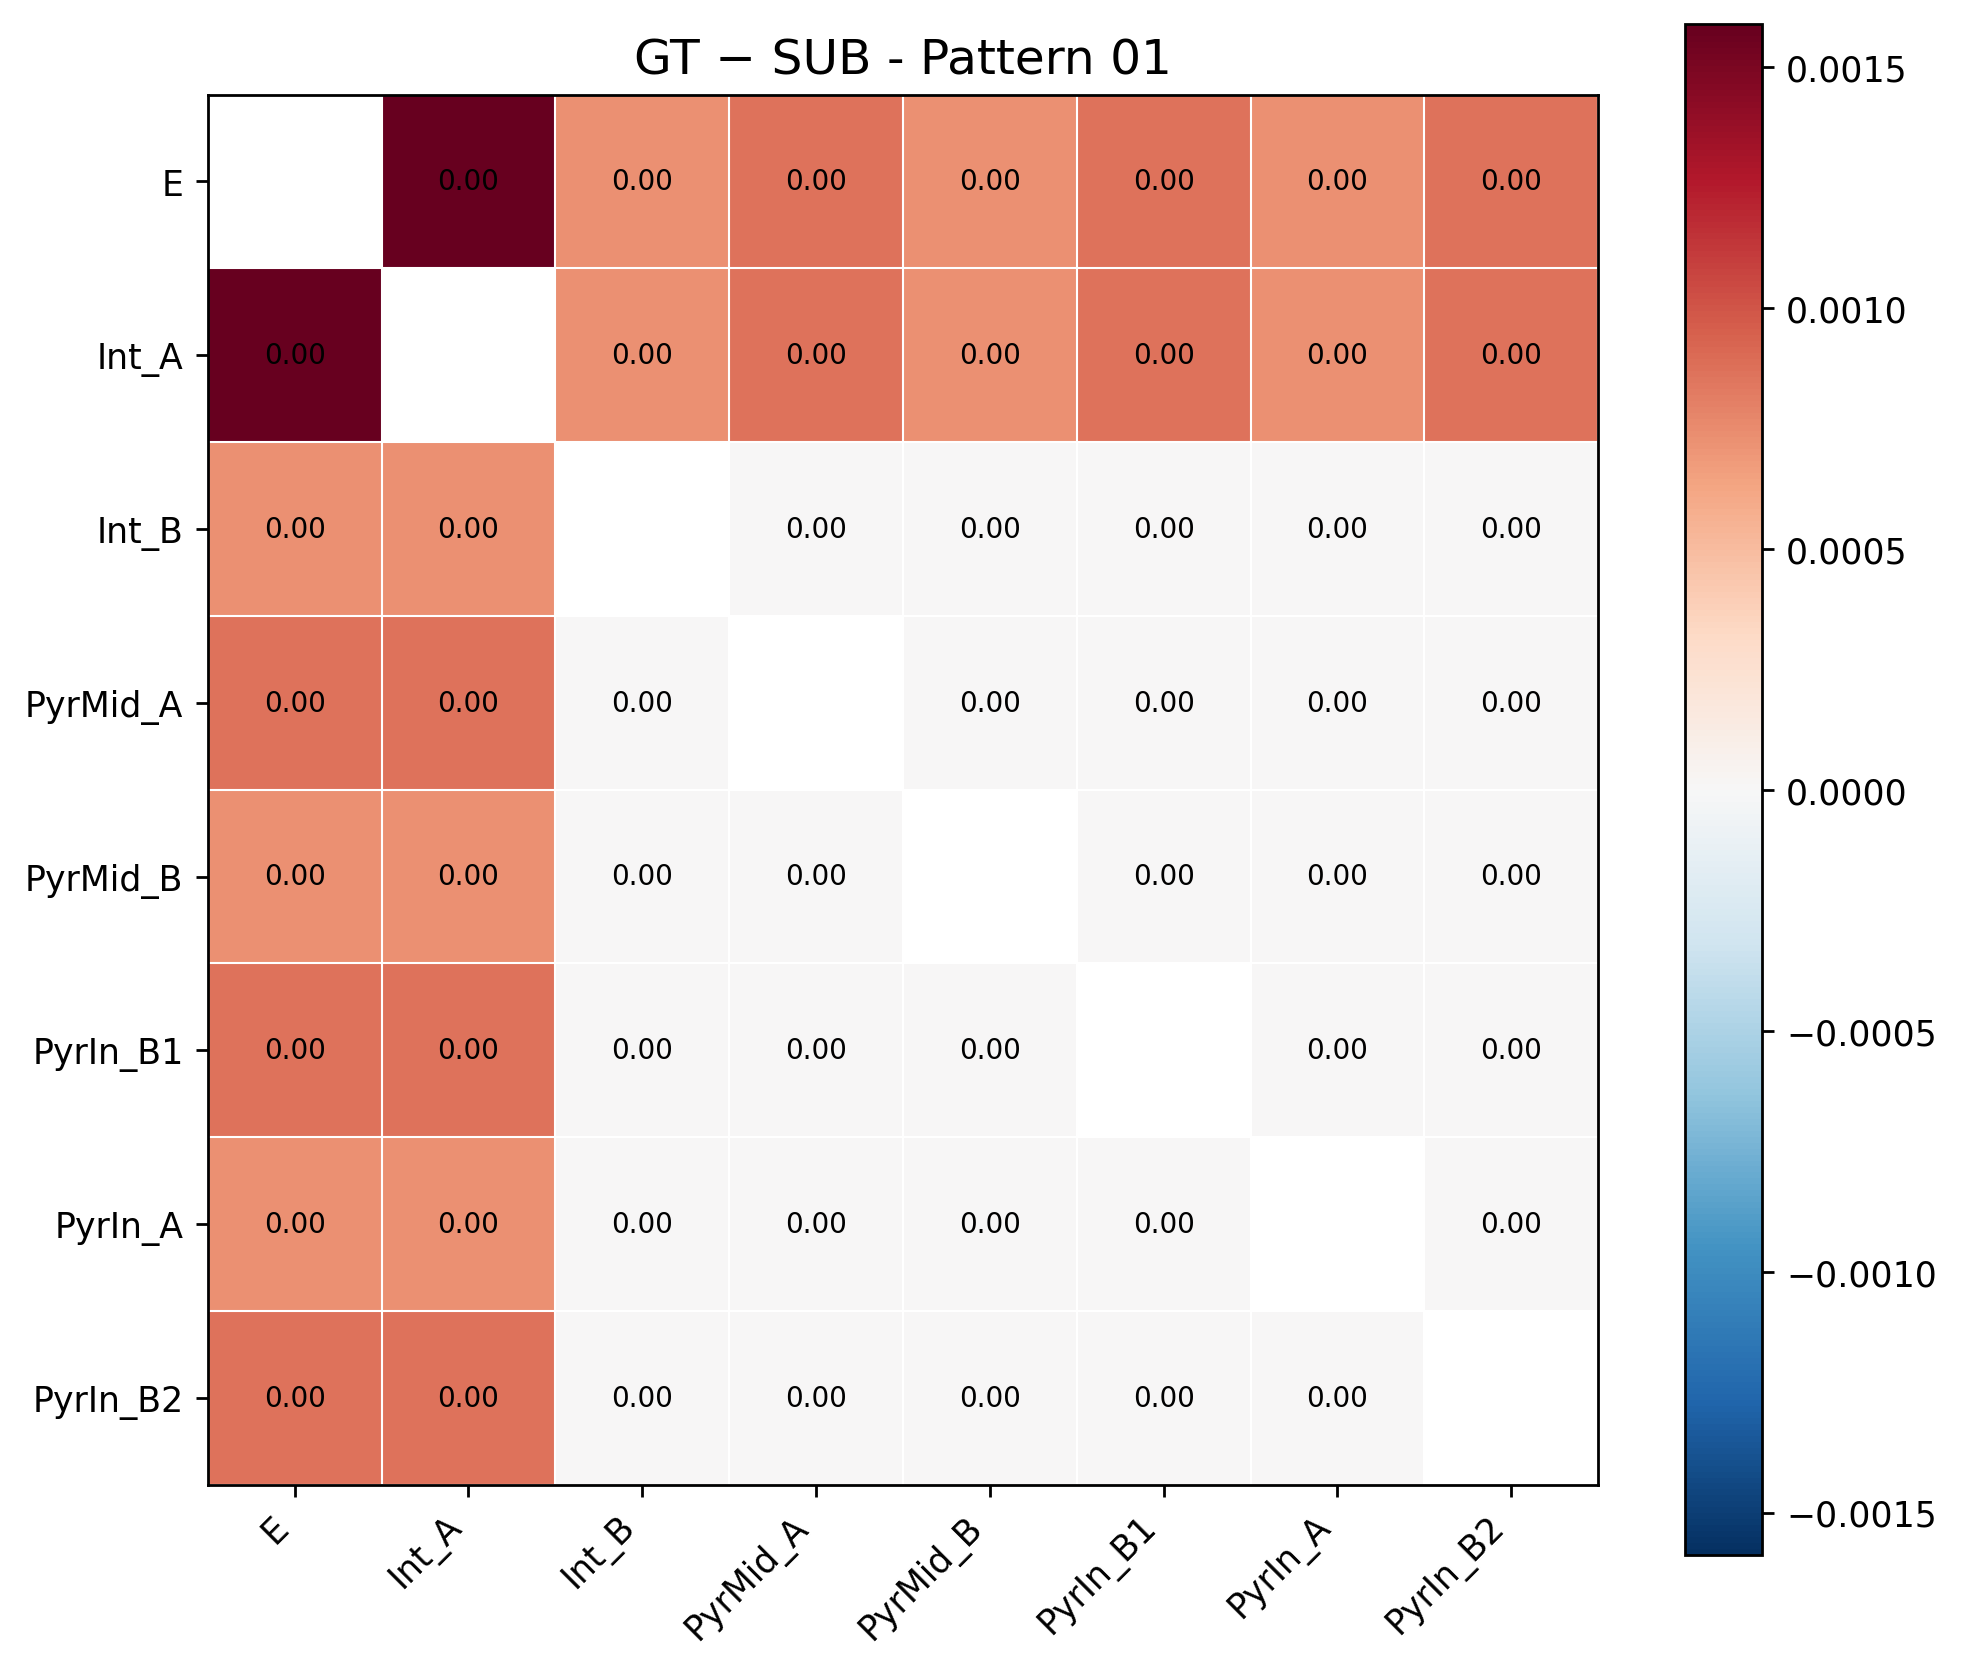

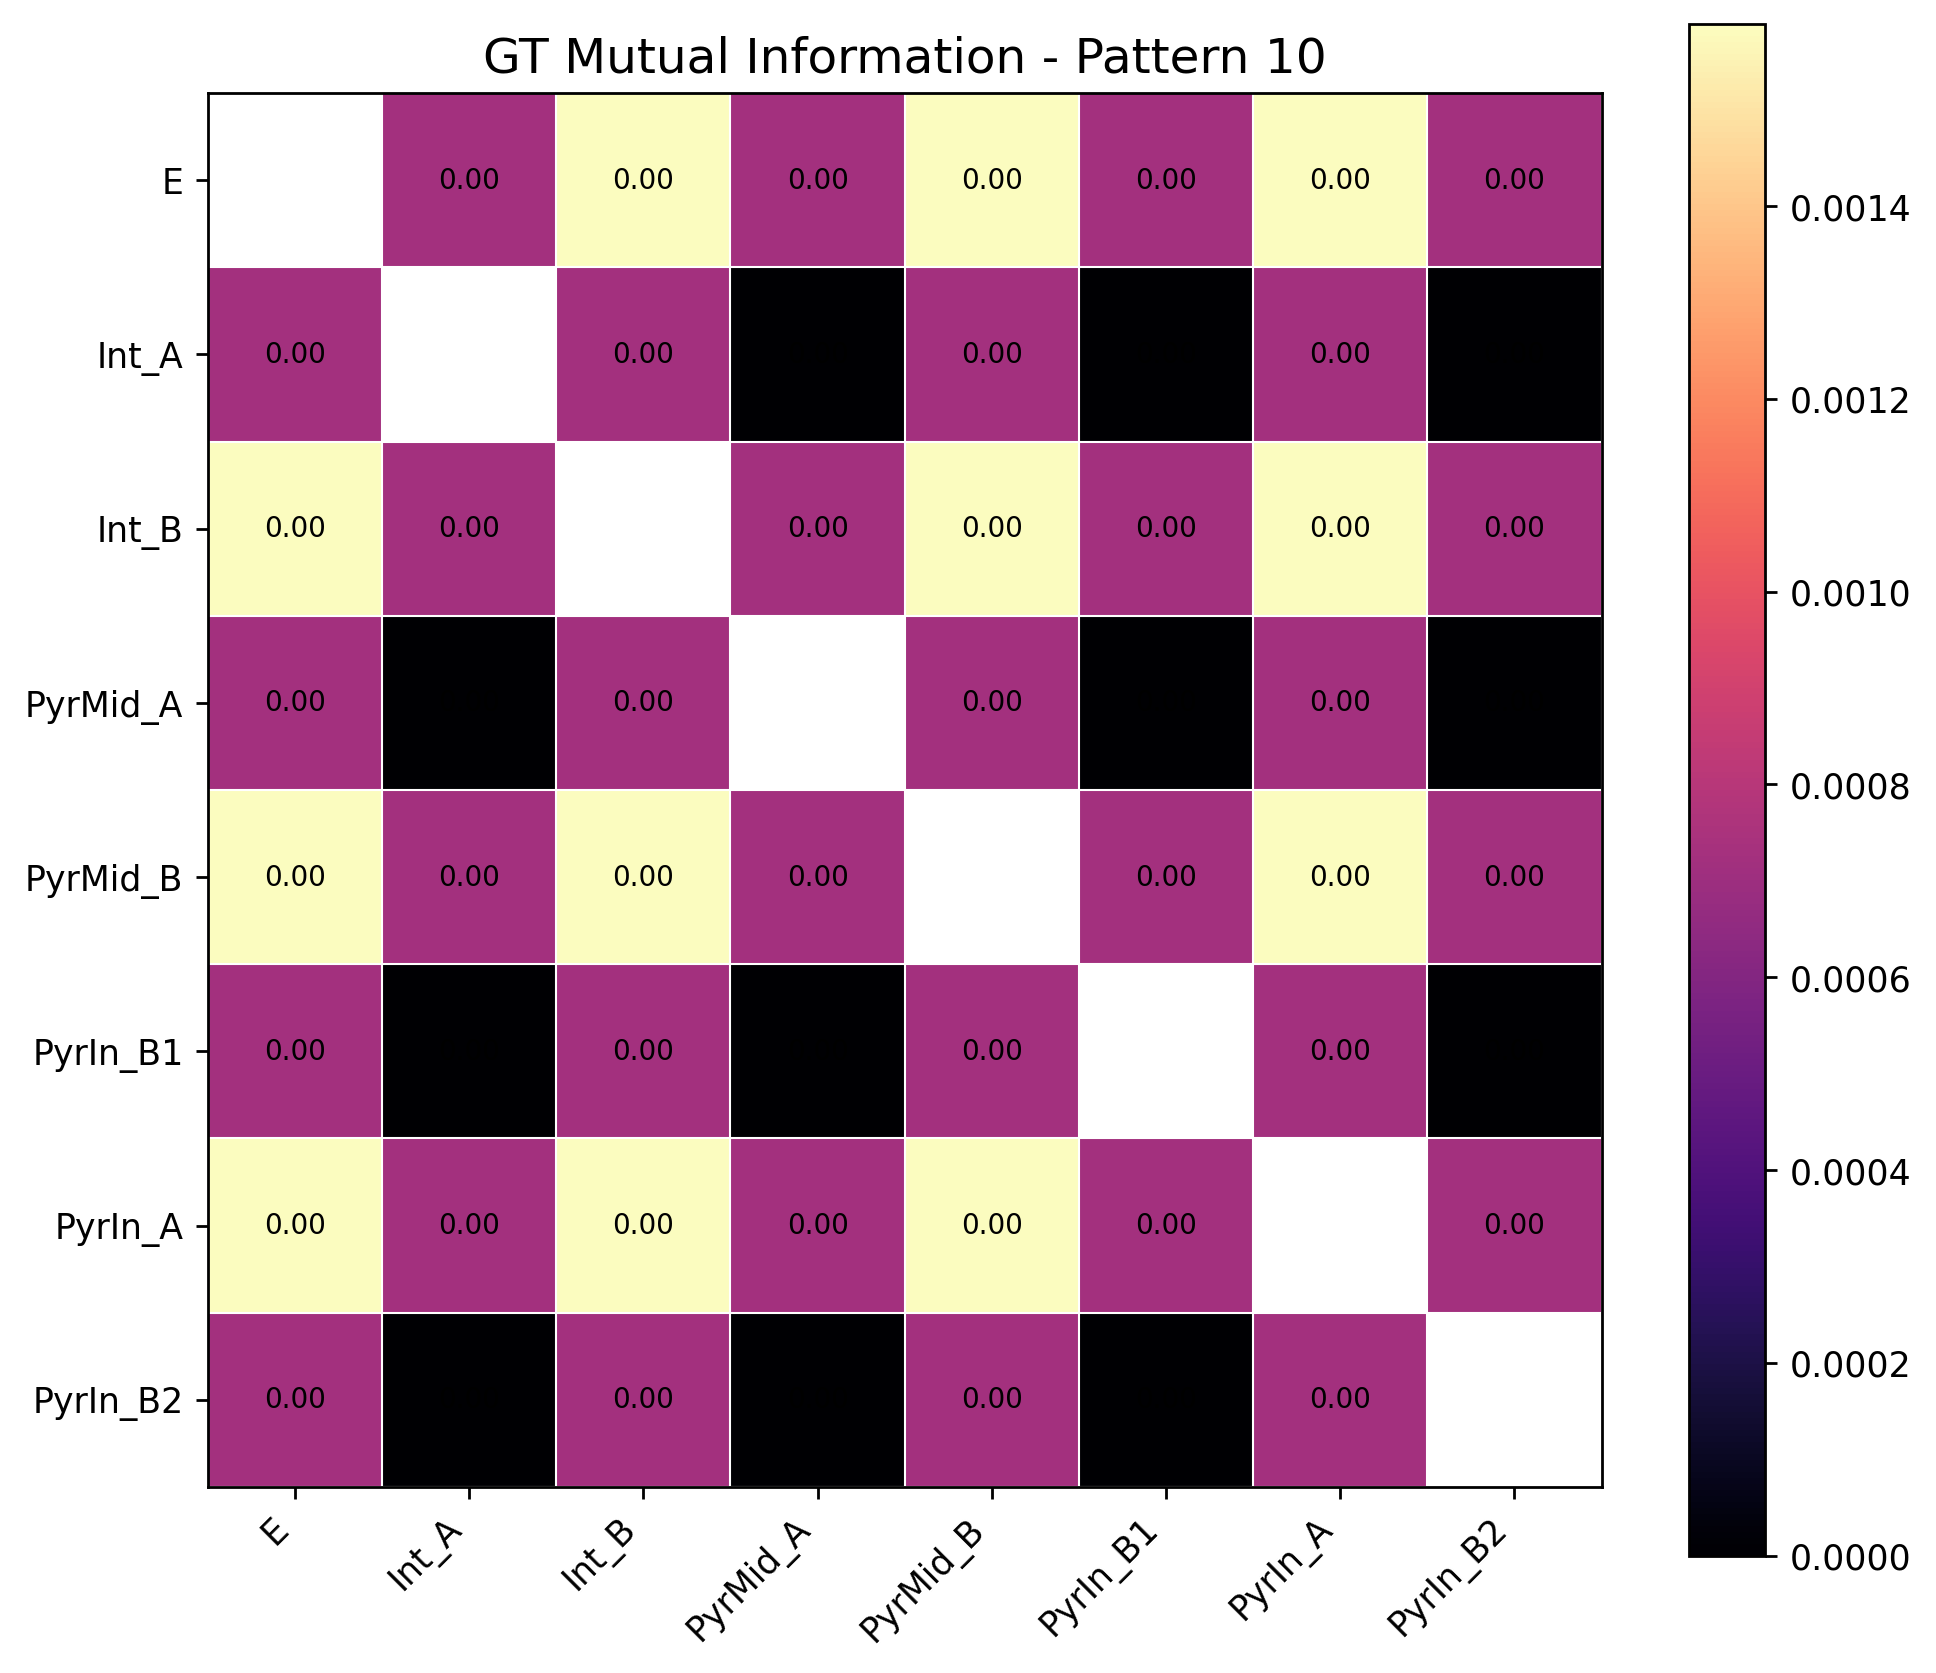

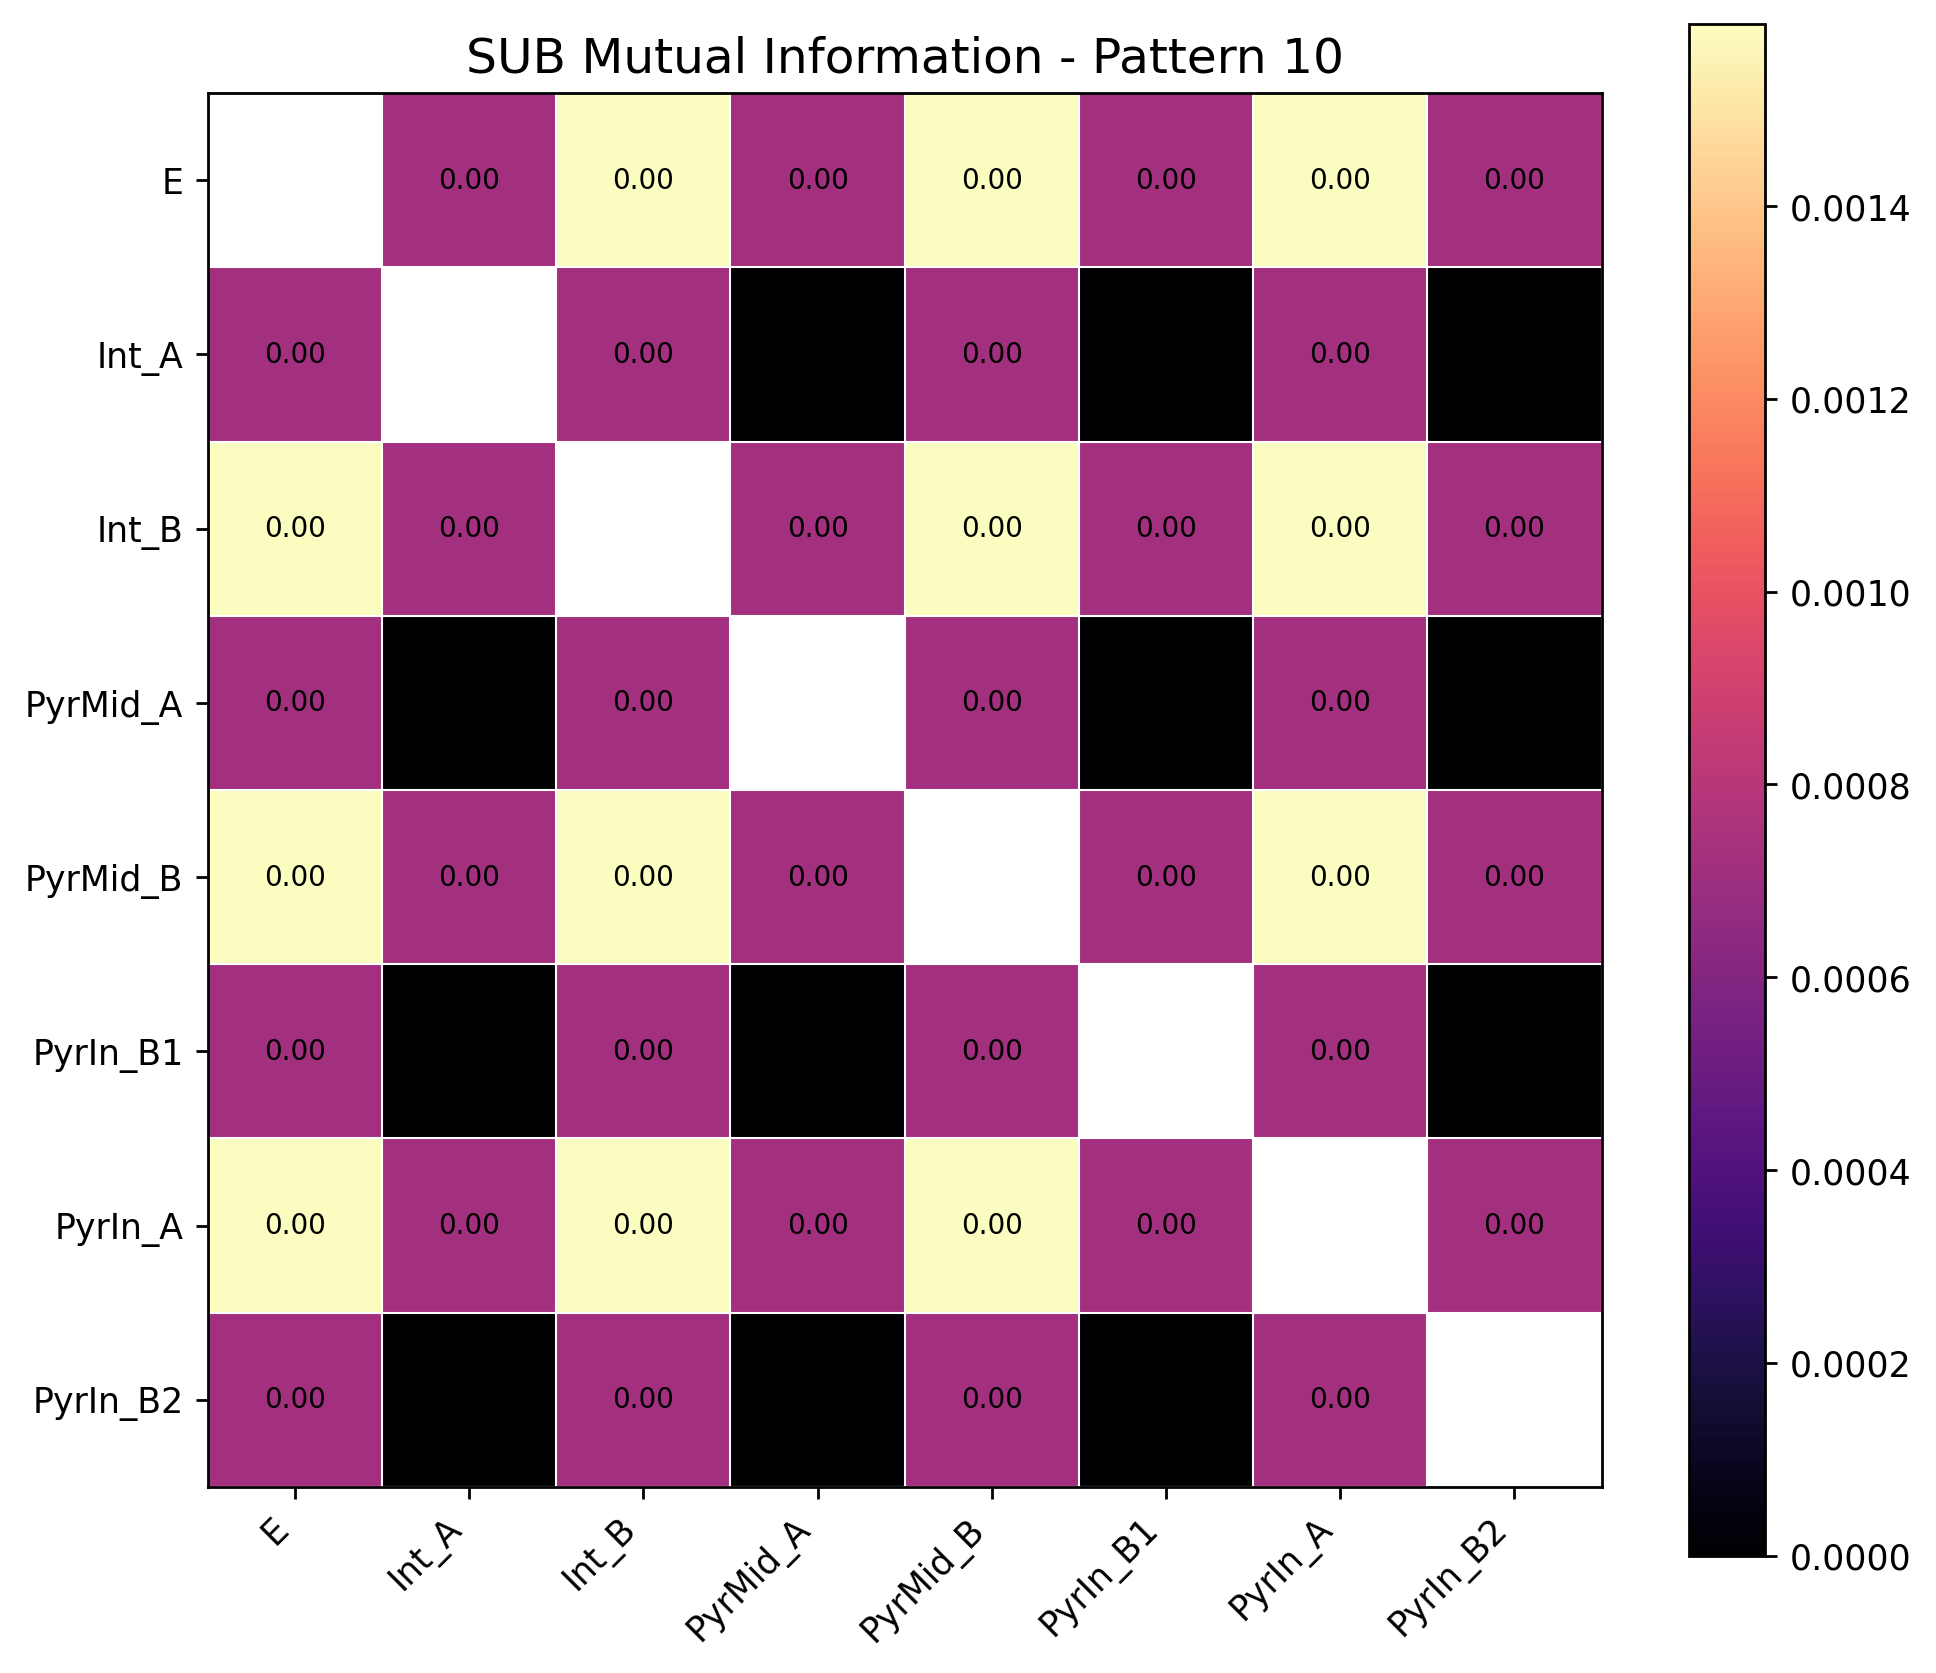

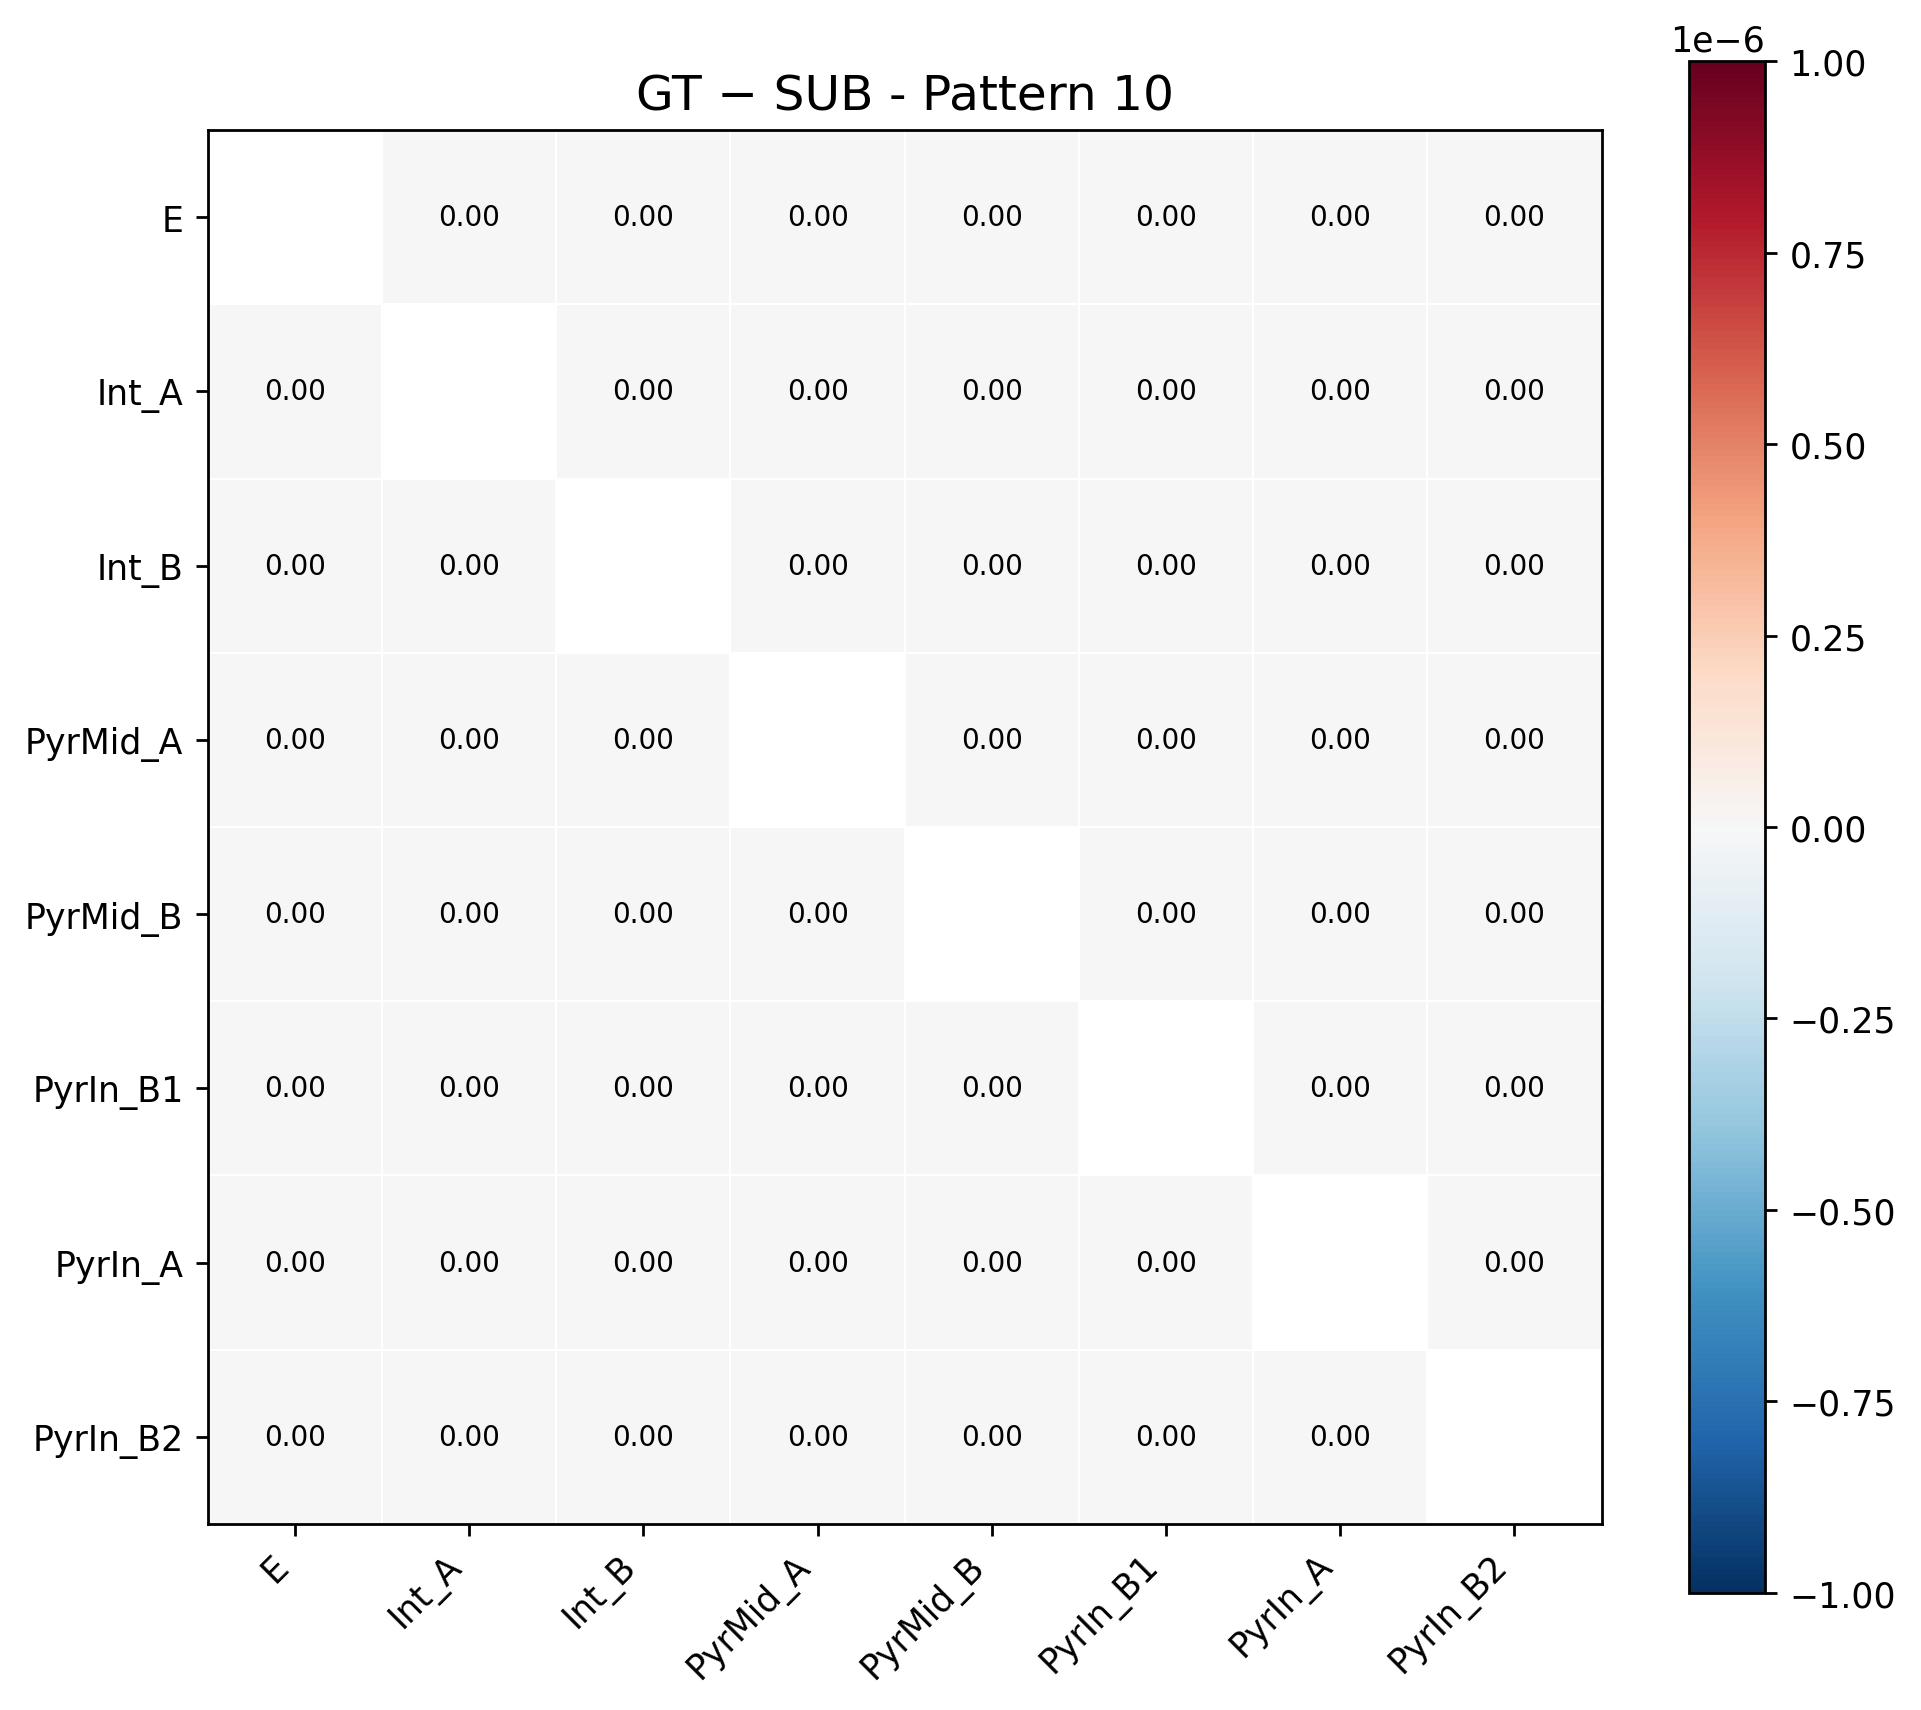

In [30]:
#Mutual Information

def compute_MI_matrix(trials: list, spike_cols: list[str]) -> np.ndarray:
    """N x N matrix — entry [j,i] = MI(Y_i ; Y_j). Diagonal = NaN. Symmetric."""
    N      = len(spike_cols)
    arrays = {}
    for col in spike_cols:
        pieces = [df[col].to_numpy(dtype=int) for df in trials if col in df.columns]
        arrays[col] = np.concatenate(pieces) if pieces else np.zeros(0, dtype=int)

    MI = np.full((N, N), np.nan)
    for j in range(N):
        for i in range(N):
            if i == j:
                continue
            if not np.isnan(MI[i, j]):
                MI[j, i] = MI[i, j]  
                continue
            MI[j, i] = mutual_information(arrays[spike_cols[i]],
                                          arrays[spike_cols[j]])
    return MI

def mi_compute():
    patterns   = gt_data["case"].unique().tolist()
    neurons    = hp.get_spiking_neurons(cfg, gt_data)
    spike_cols = [f"{n}_spike" for n in neurons]

    mi_meta  = {"patterns": patterns, "spike_cols": spike_cols}
    gt_mats  = []
    sub_mats = []

    for p in patterns:
        gt_trials  = [gt_data[gt_data["case"] == p]]
        sub_trials = [sub_data[sub_data["case"] == p]]

        gt_MI  = compute_MI_matrix(gt_trials,  spike_cols)
        sub_MI = compute_MI_matrix(sub_trials, spike_cols)

        mi_meta[p] = {
            "gt":   gt_MI,
            "sub":  sub_MI,
            "diff": gt_MI - sub_MI,
        }
        gt_mats.append(gt_MI)
        sub_mats.append(sub_MI)

    gt_arr  = np.stack(gt_mats)
    sub_arr = np.stack(sub_mats)
    diff    = np.nanmean(np.abs(gt_arr - sub_arr))
    score   = float(1.0 - np.clip(diff, 0.0, 1.0))

    return gt_arr, sub_arr, score, mi_meta

mi_result = mi_compute()
_, _, _, meta = mi_result

patterns = meta["patterns"]
labels = [c.replace("_spike", "") for c in meta["spike_cols"]]

for pattern in patterns:

    gt = meta[pattern]["gt"]
    sub = meta[pattern]["sub"]
    diff = meta[pattern]["diff"]

    vmax = max(np.nanmax(gt), np.nanmax(sub))
    vmin = min(np.nanmin(gt), np.nanmin(sub))

    diff_lim = np.nanmax(np.abs(diff))
    if diff_lim == 0:
        diff_lim = 1e-6

    plot_single_heatmap(
        gt,
        f"GT Mutual Information - Pattern {pattern}",
        labels,
        "magma",
        vmin,
        vmax,
    )

    plot_single_heatmap(
            sub,
            f"SUB Mutual Information - Pattern {pattern}",
            labels,
            "magma",
            vmin,
            vmax,
        )

    plot_single_heatmap(
            diff,
            f"GT − SUB - Pattern {pattern}",
            labels,
            "RdBu_r",
            -diff_lim,
            diff_lim,
            )

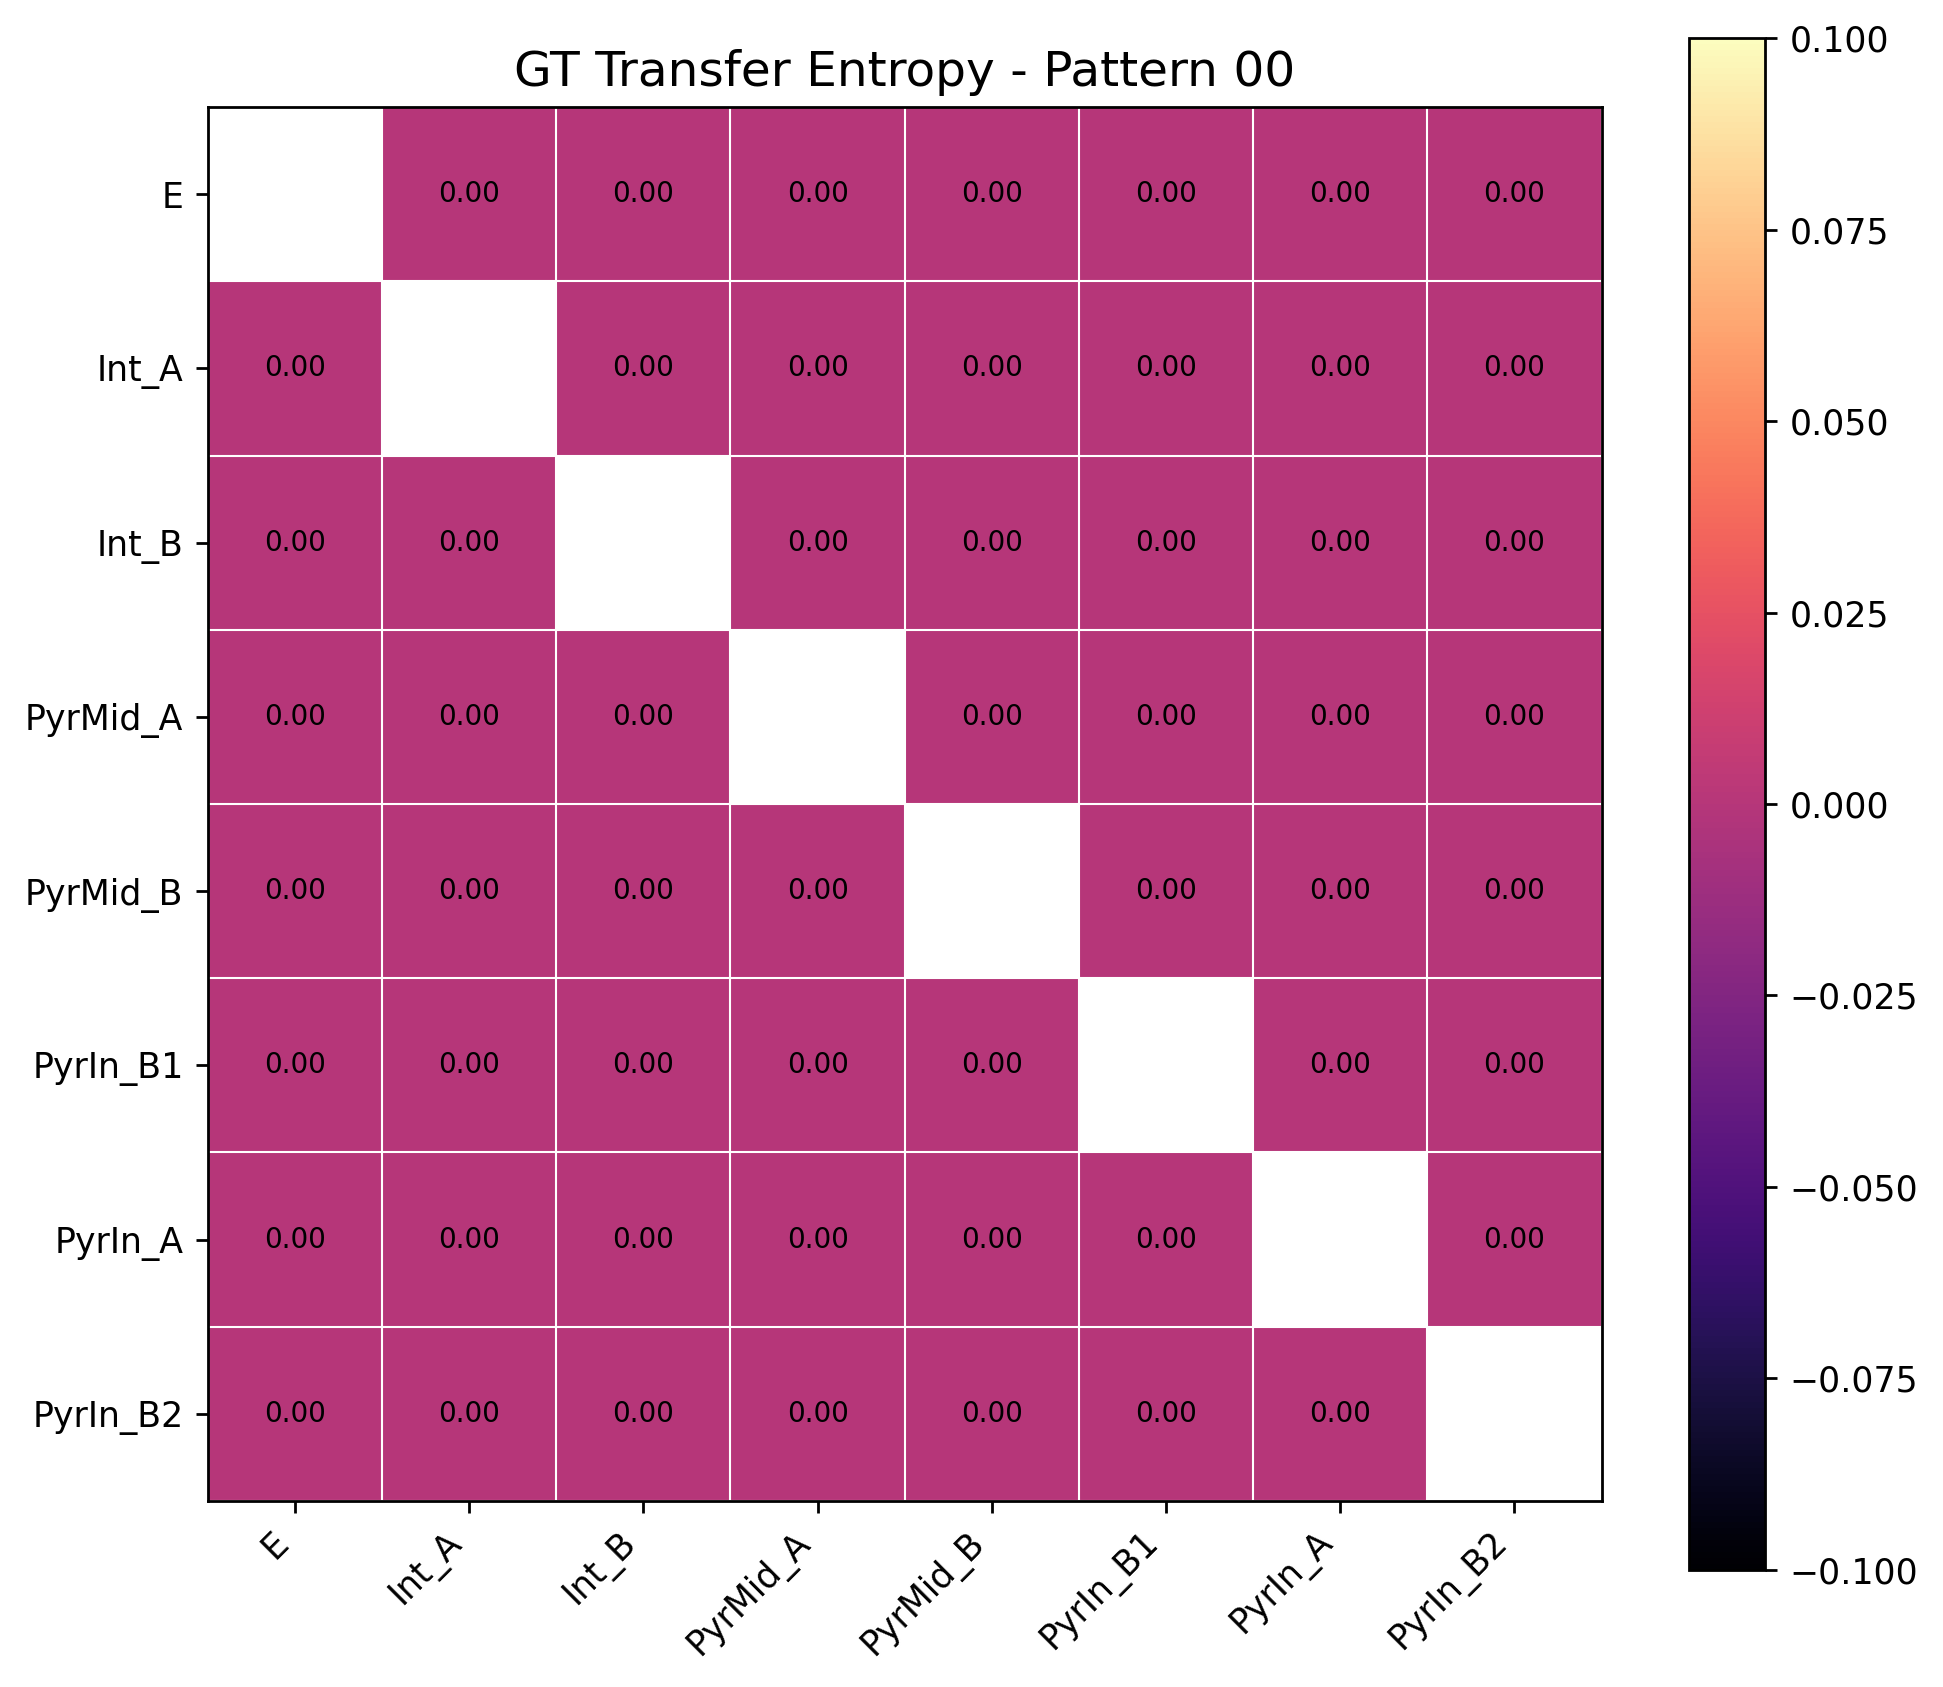

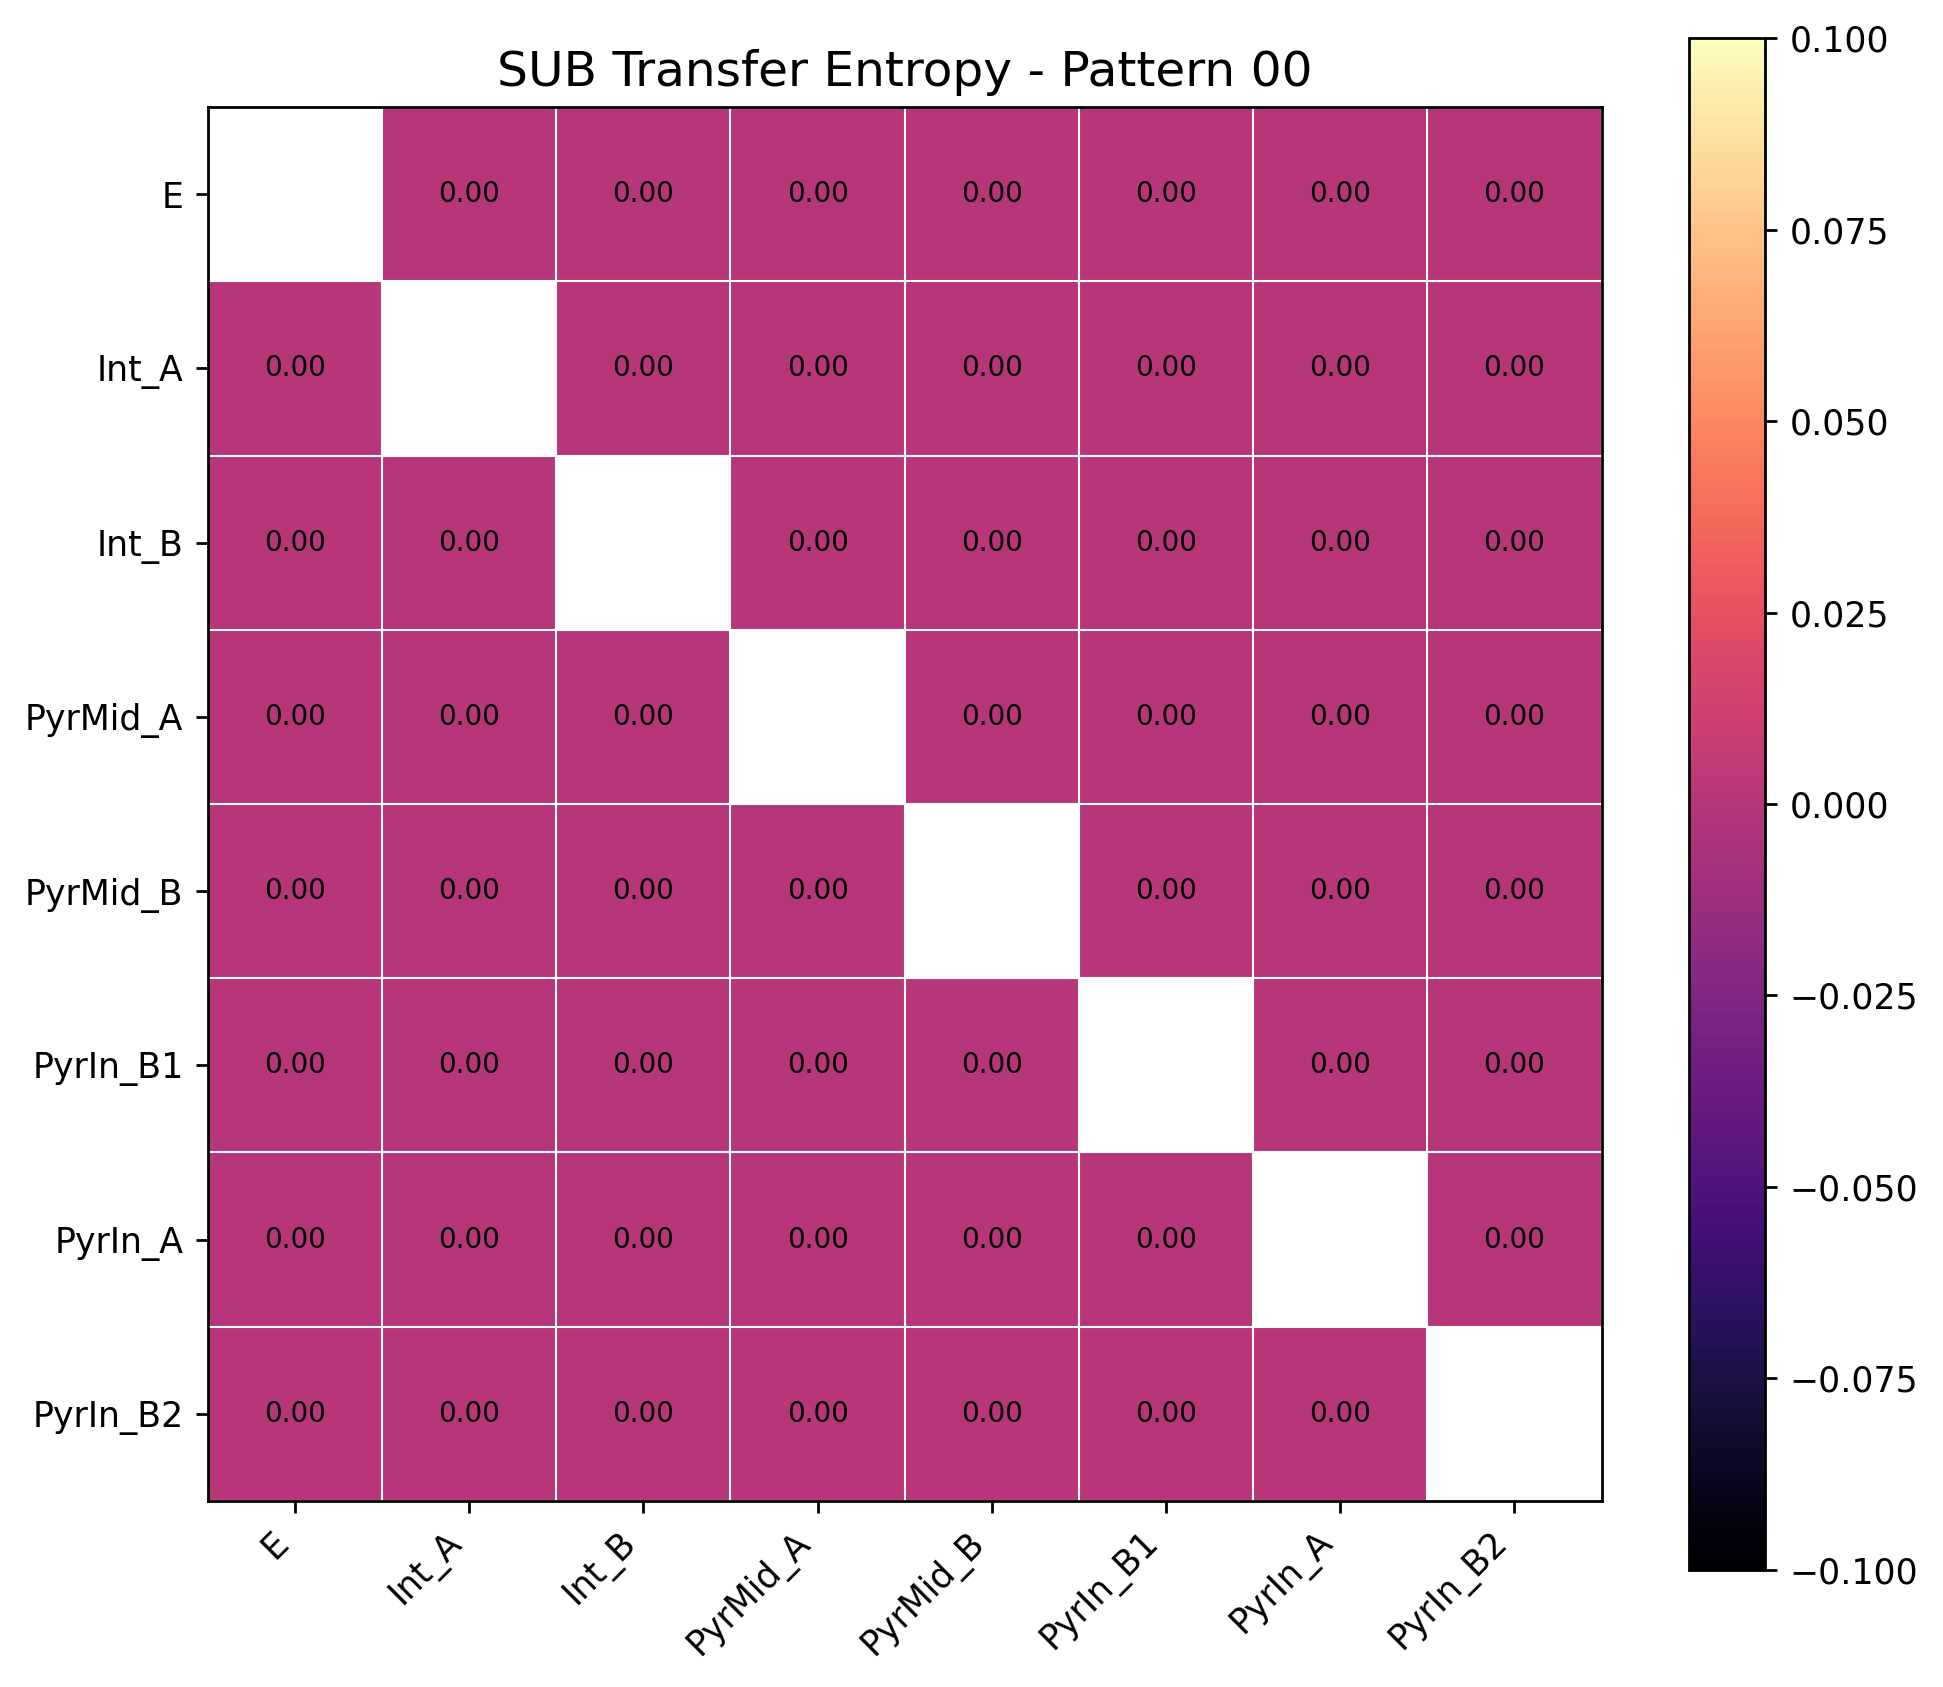

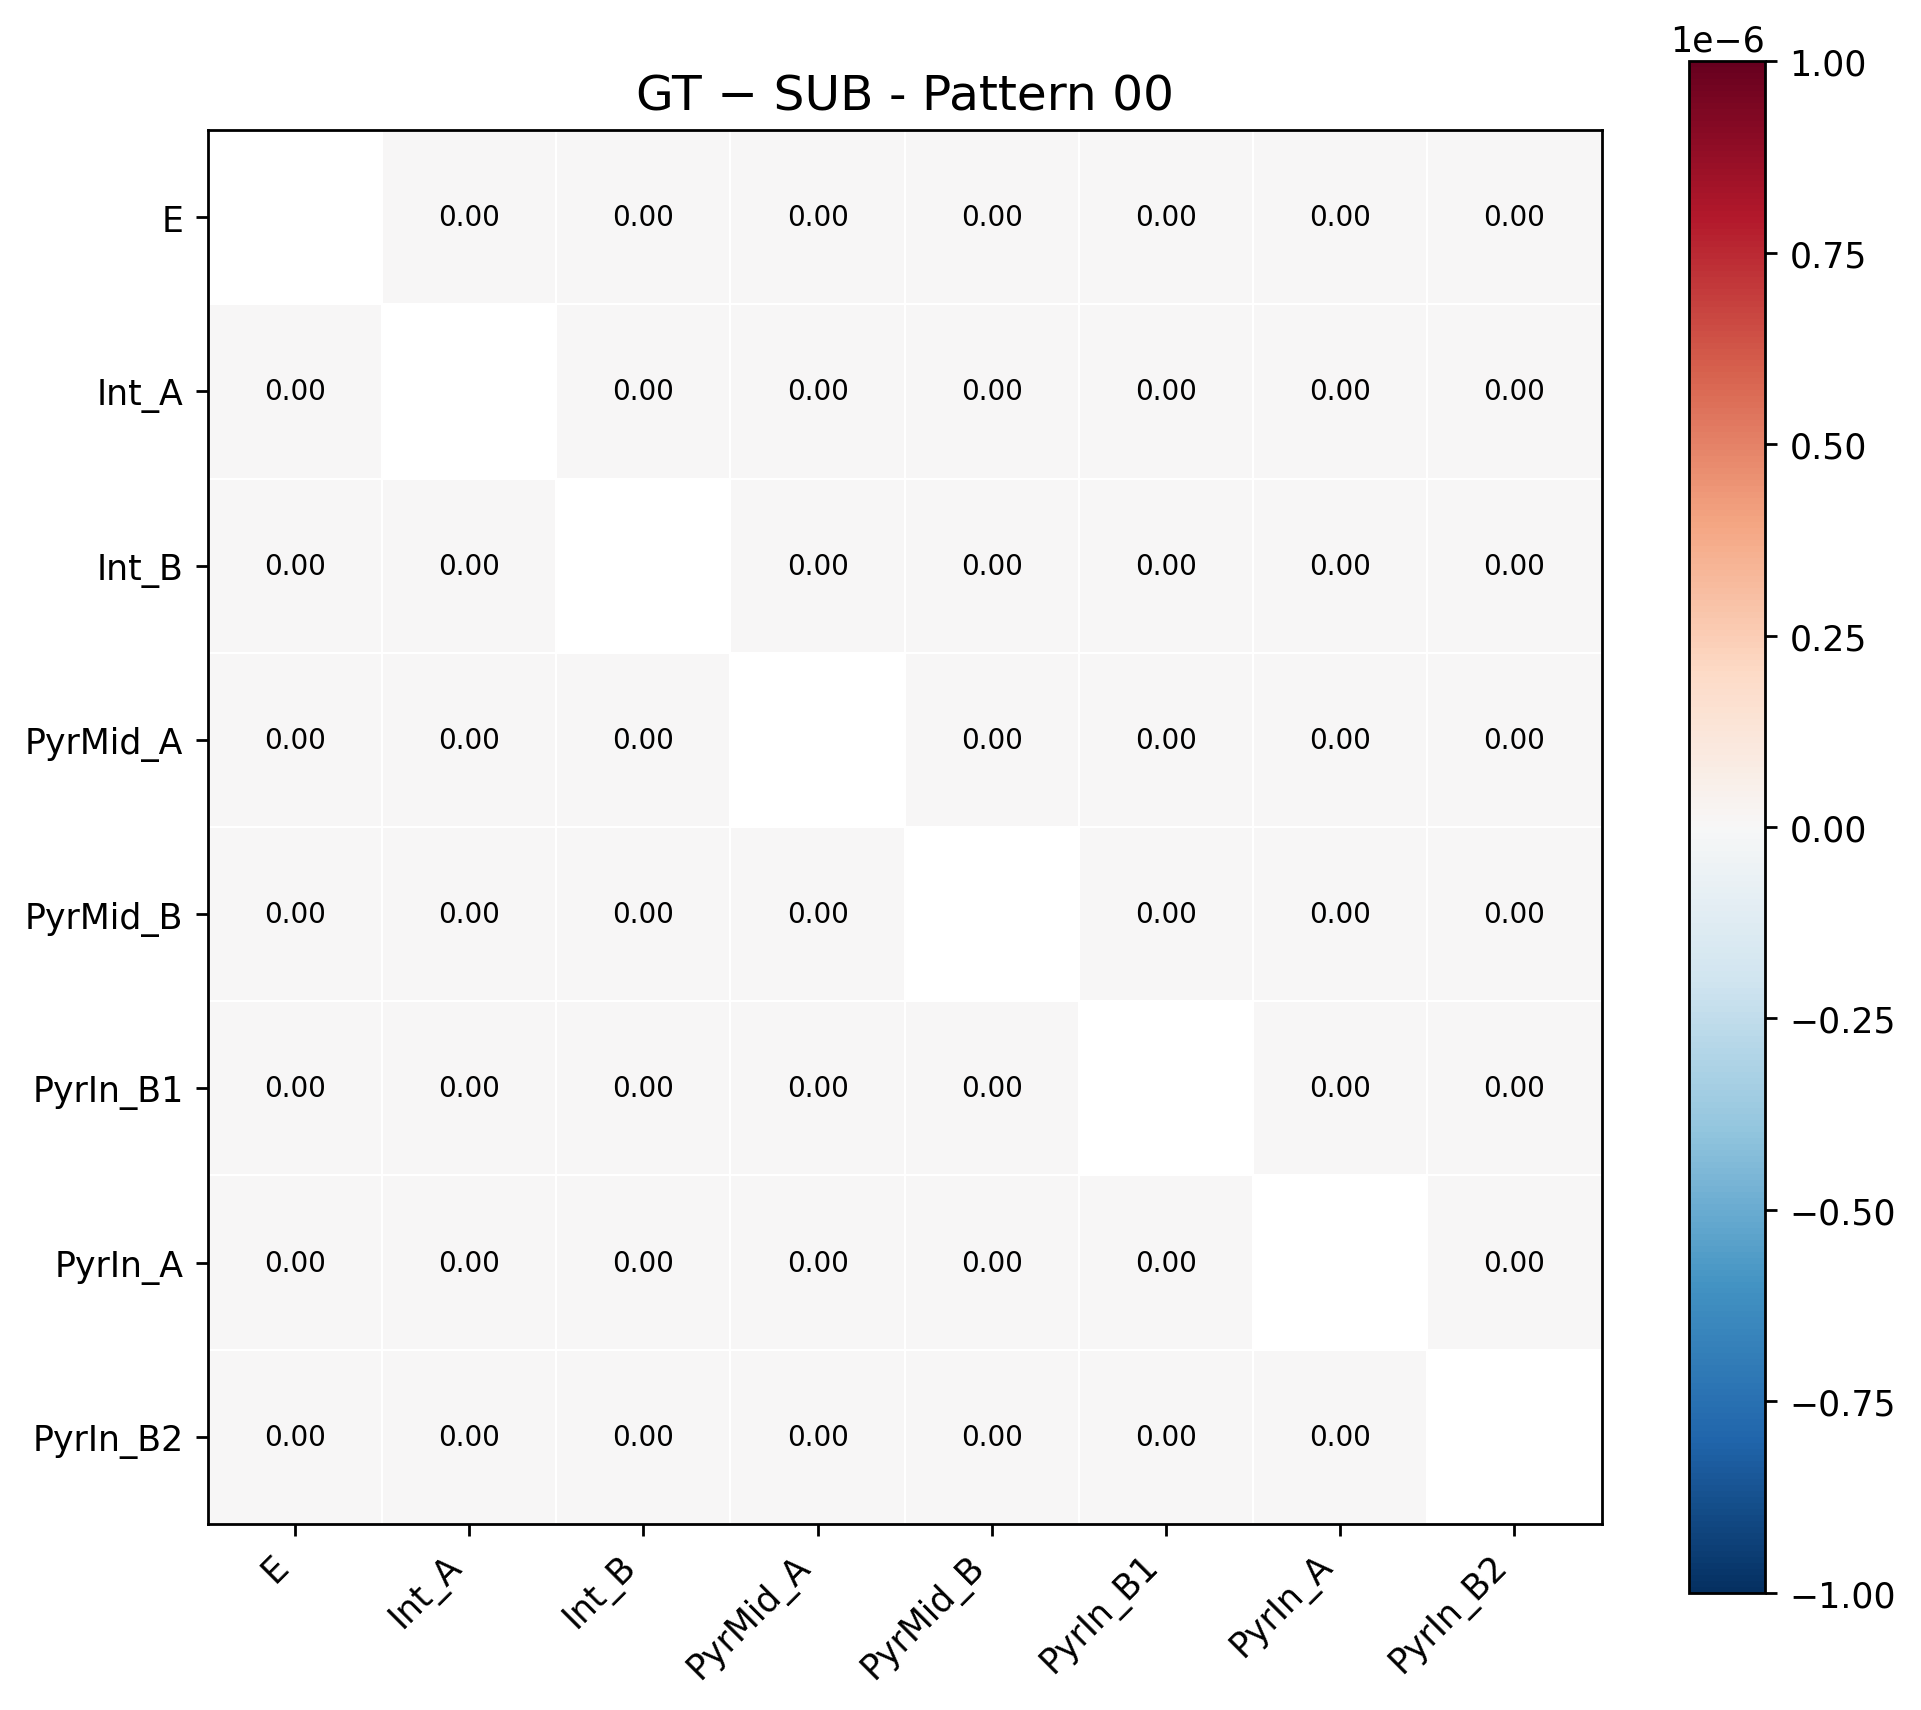

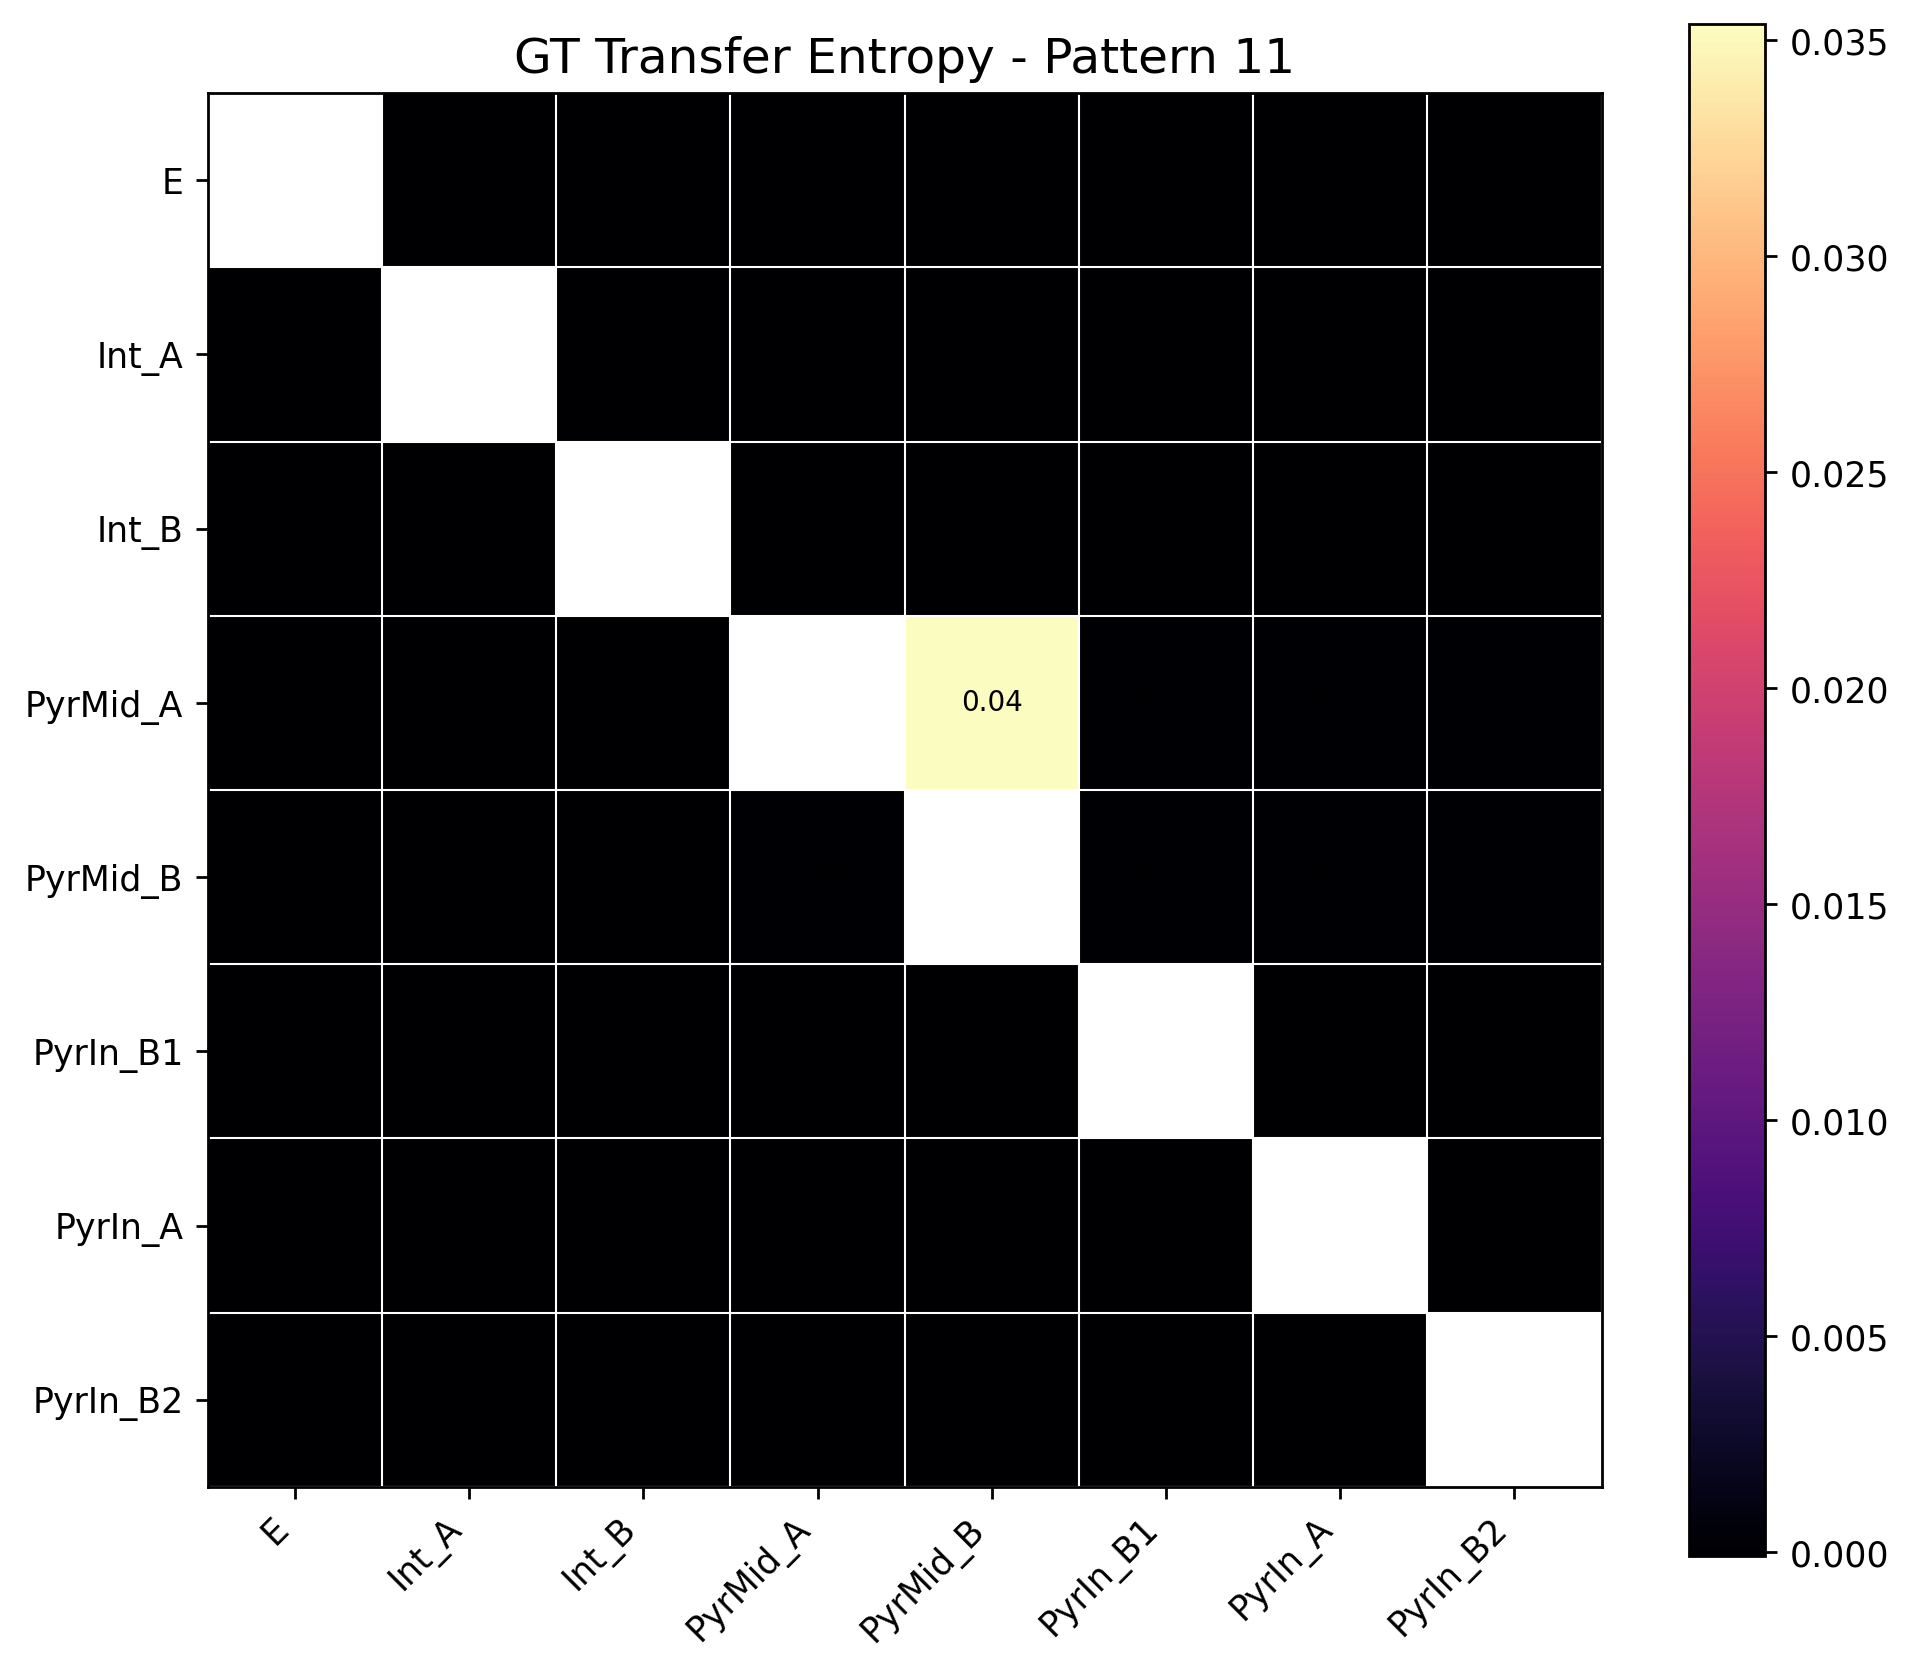

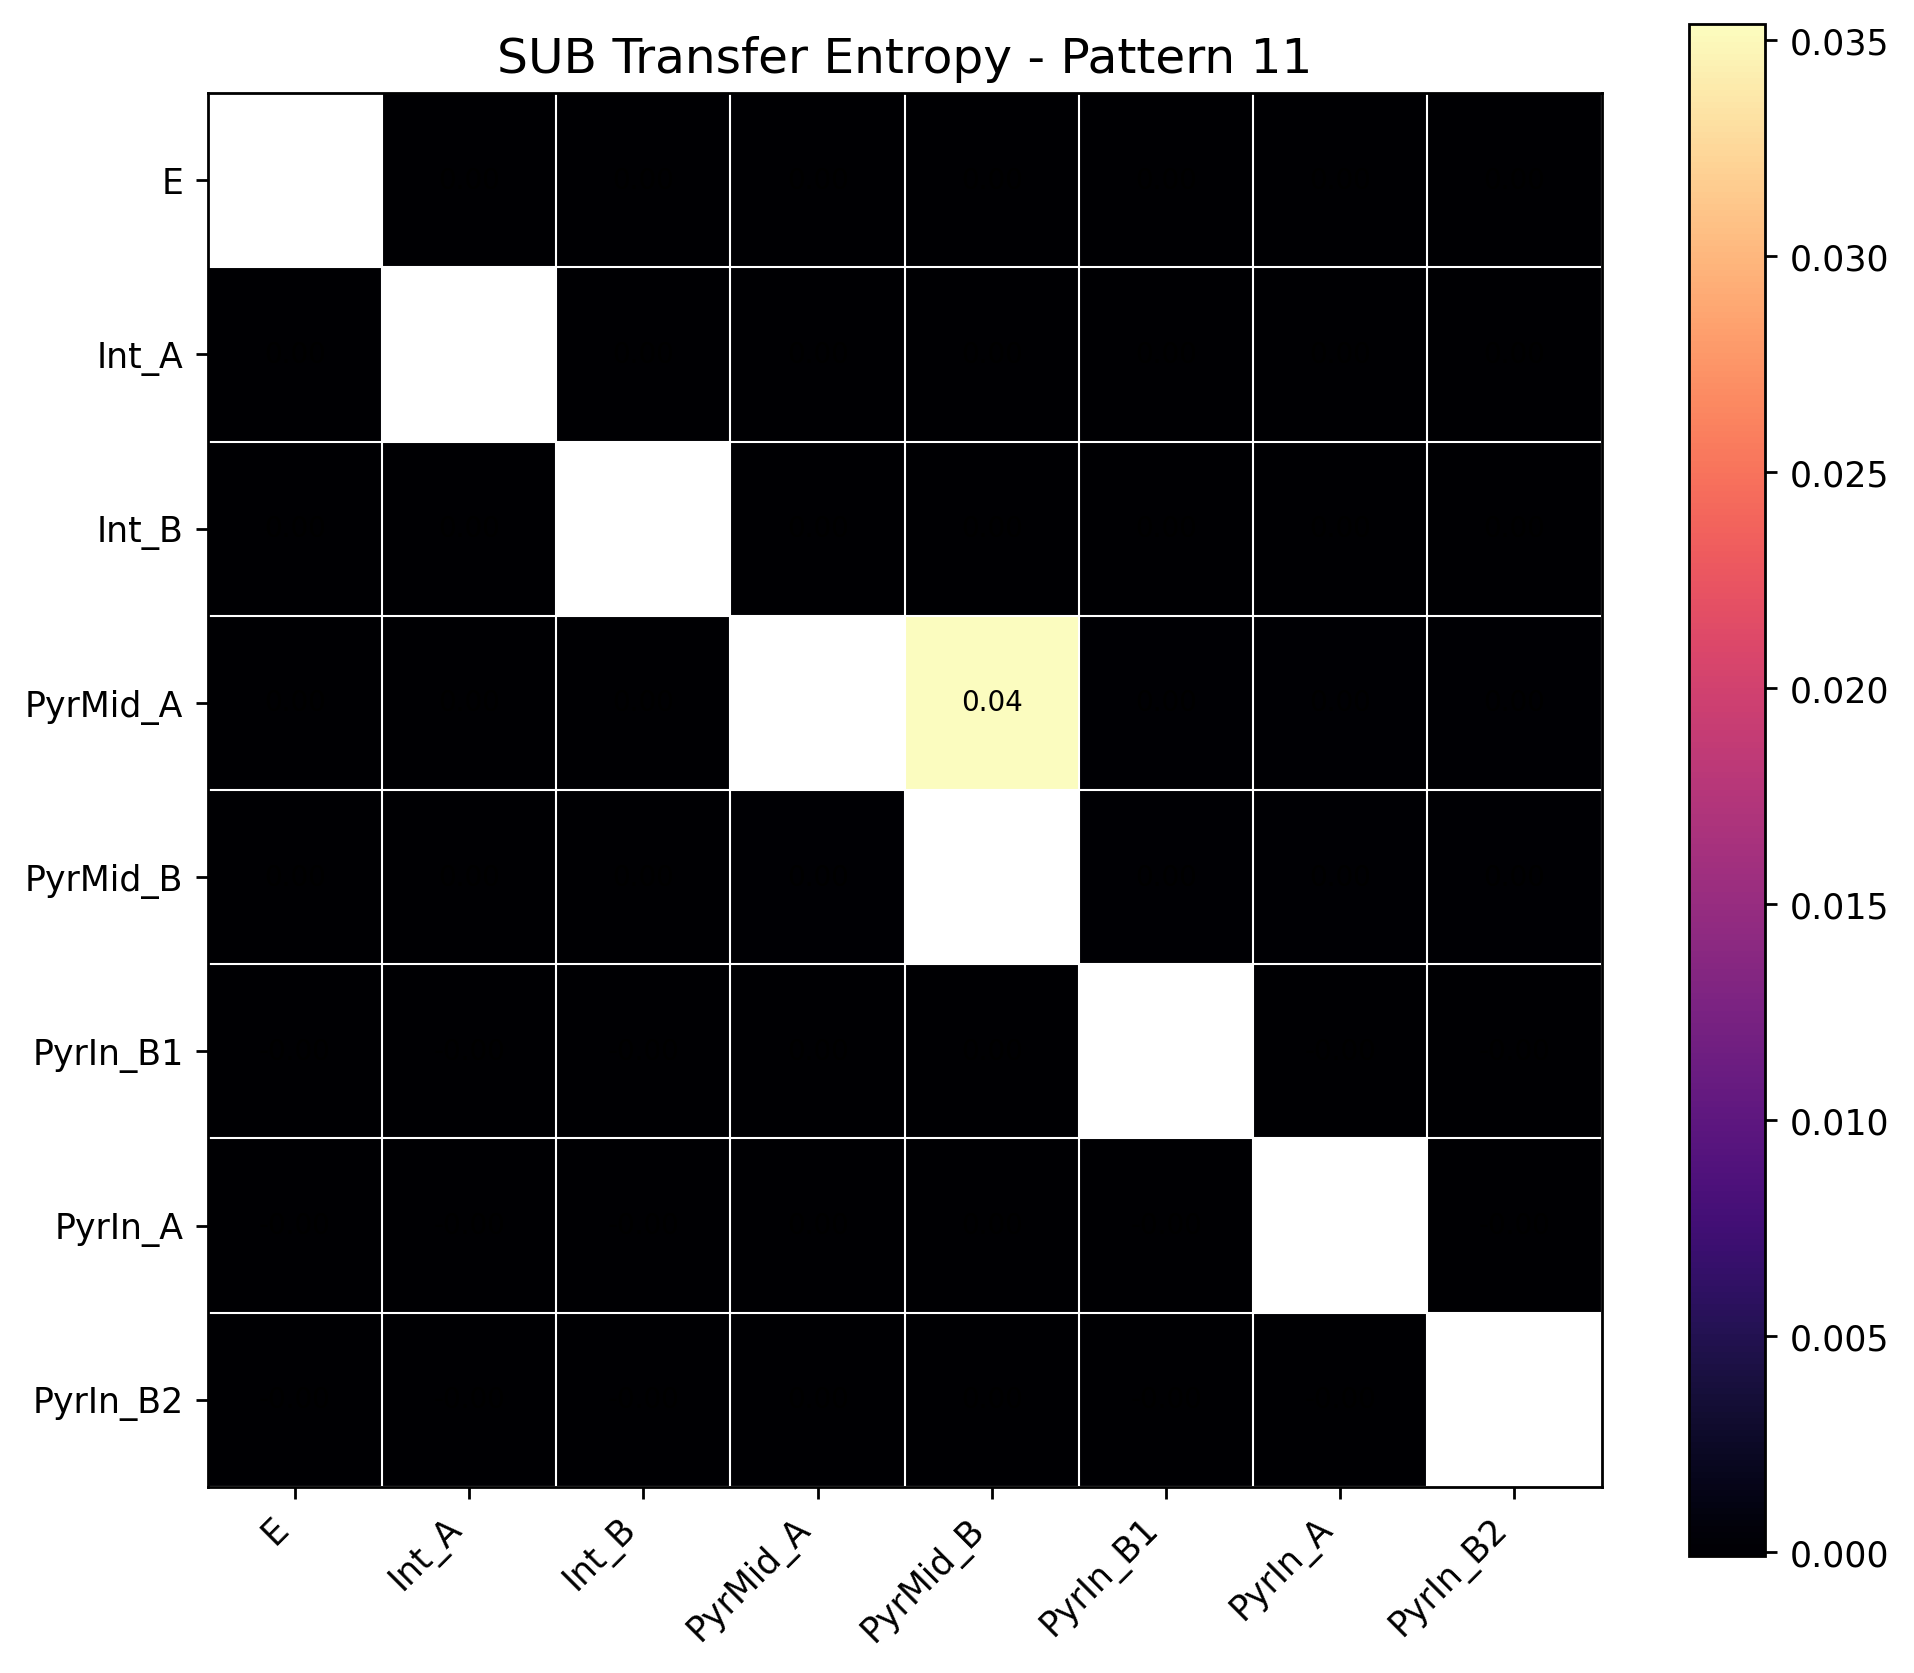

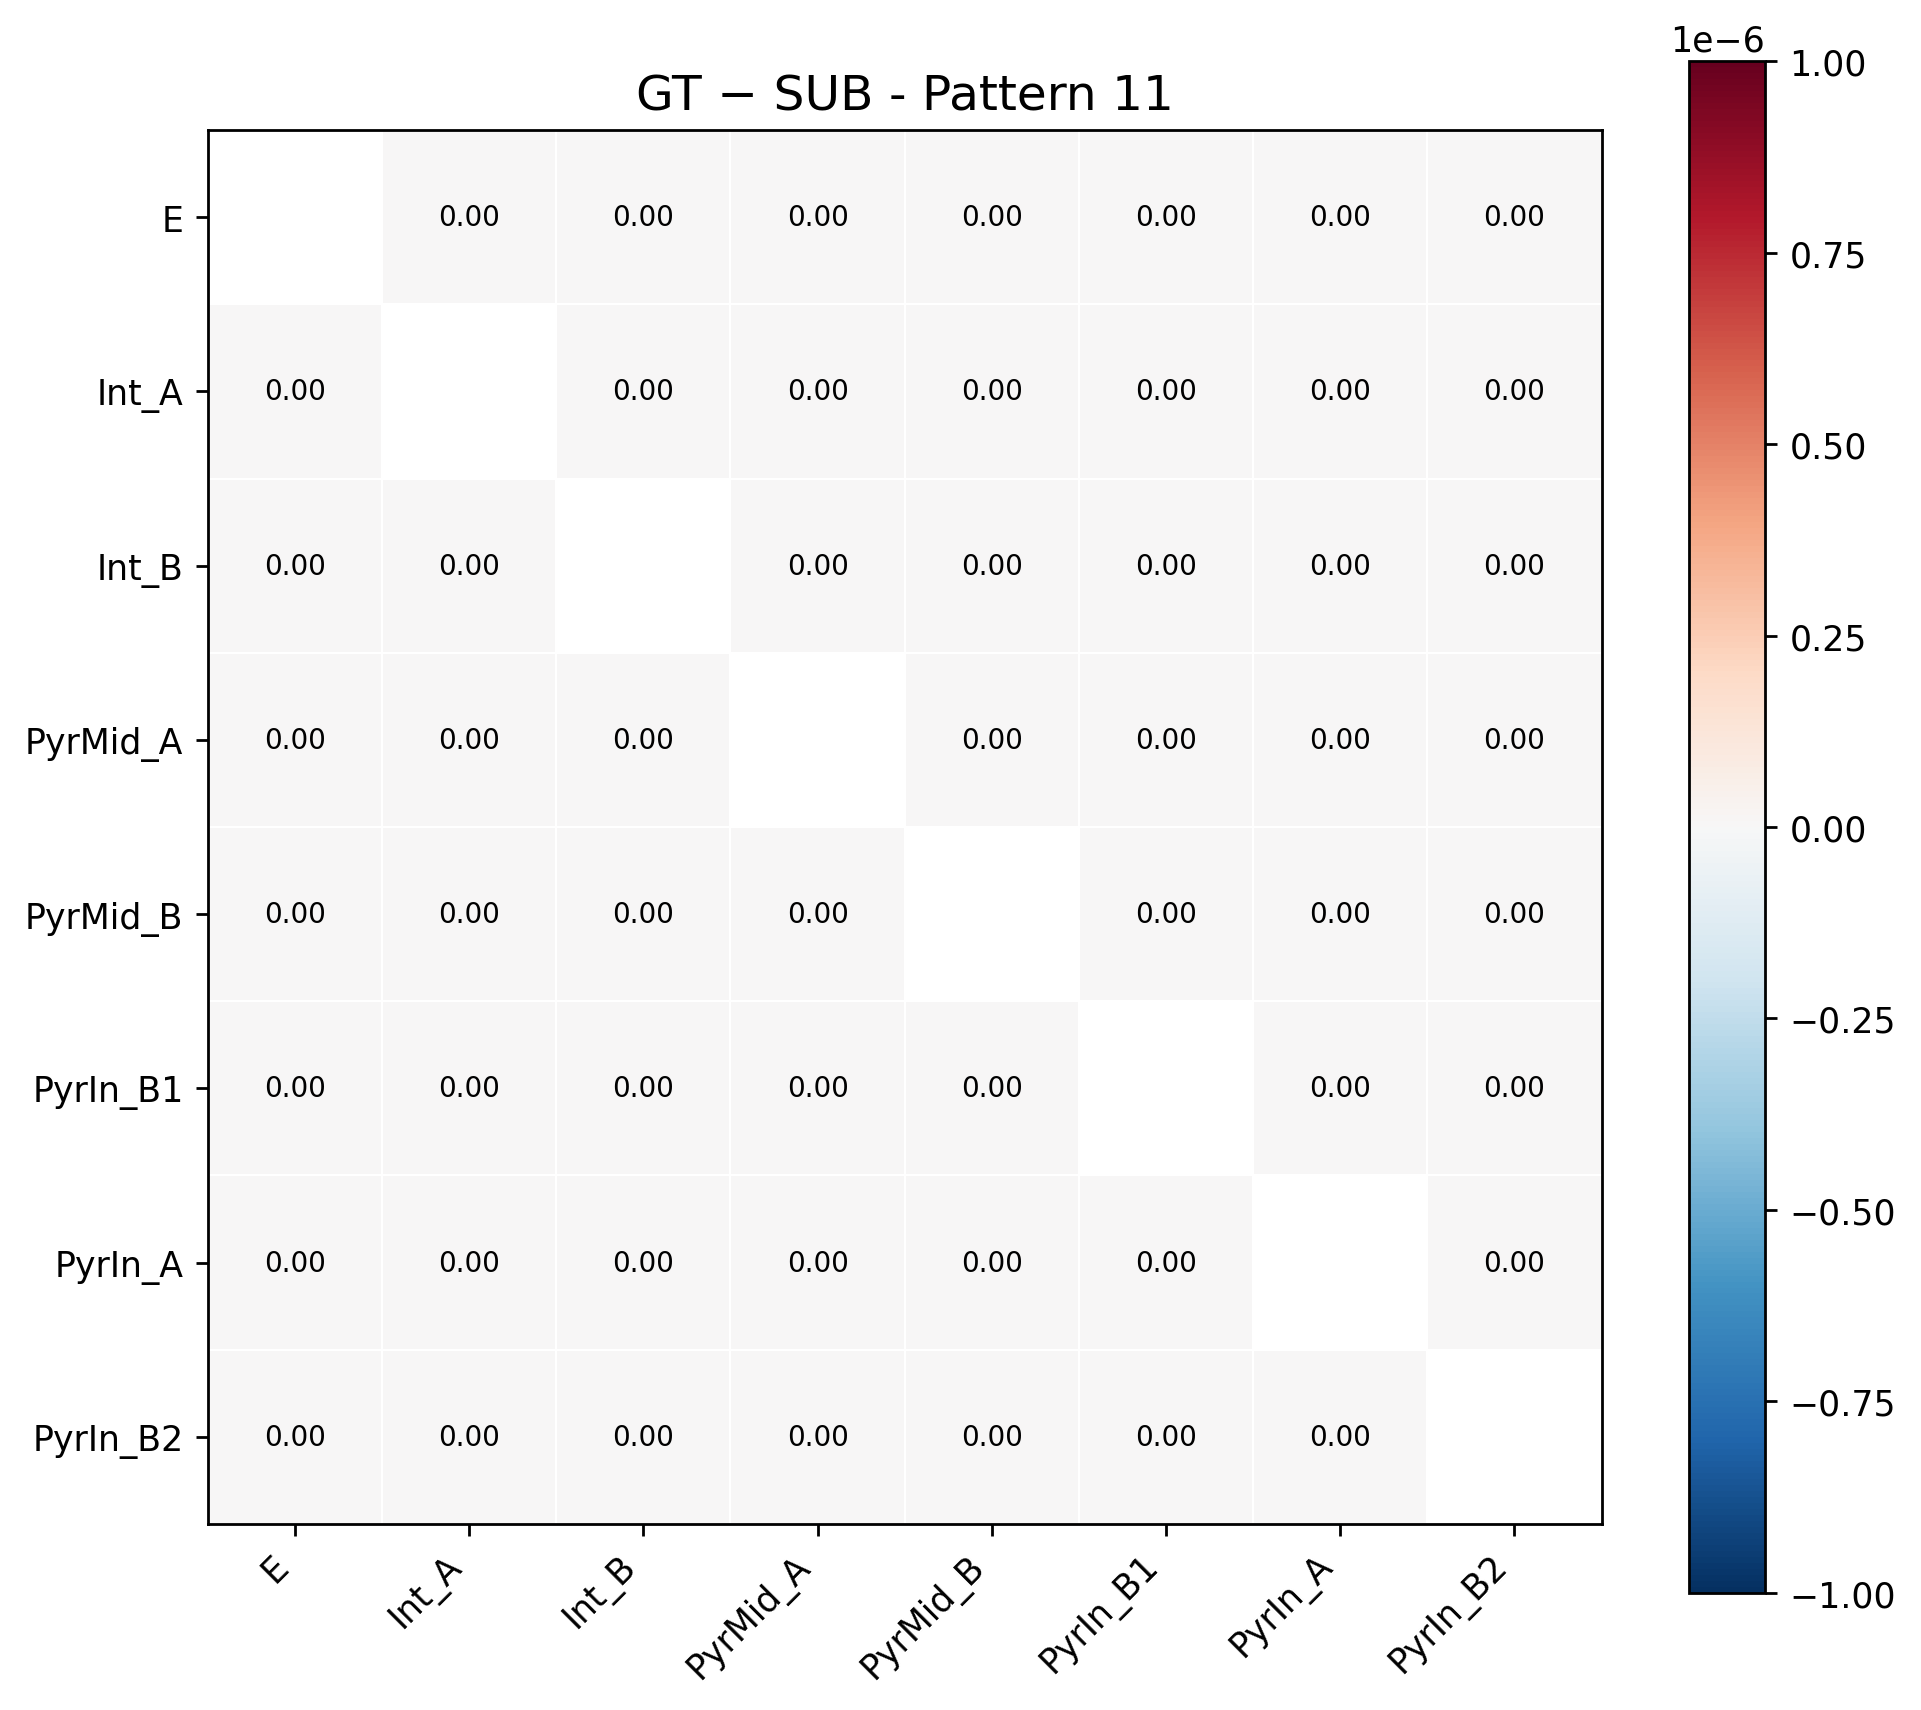

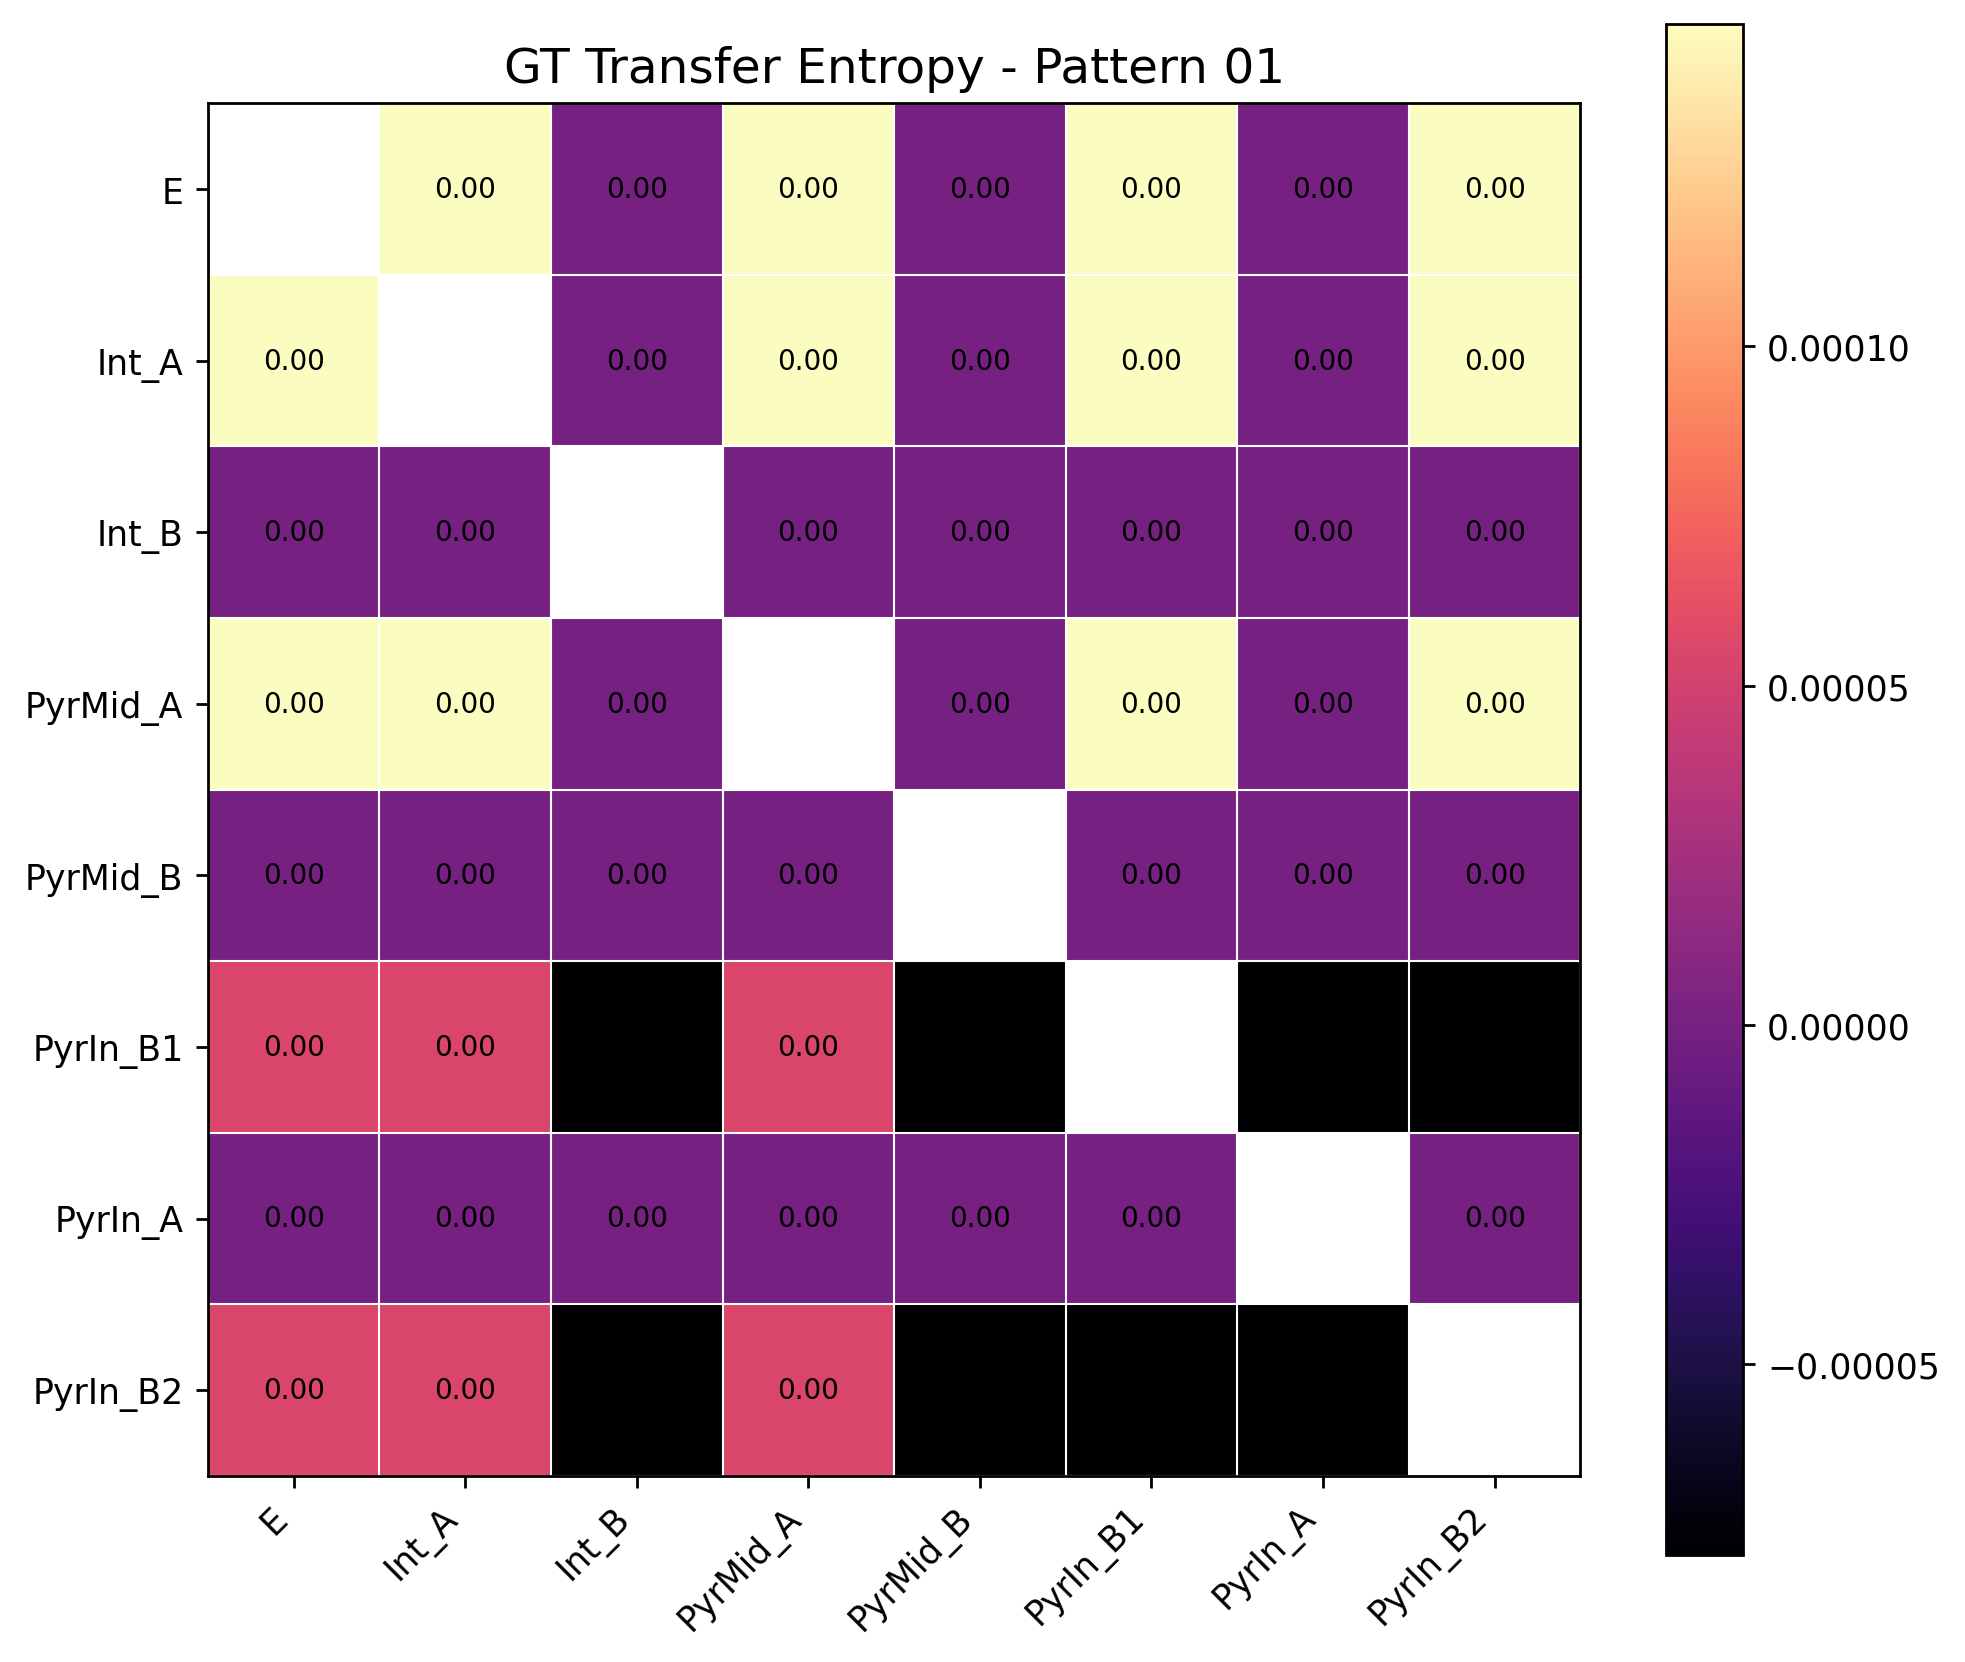

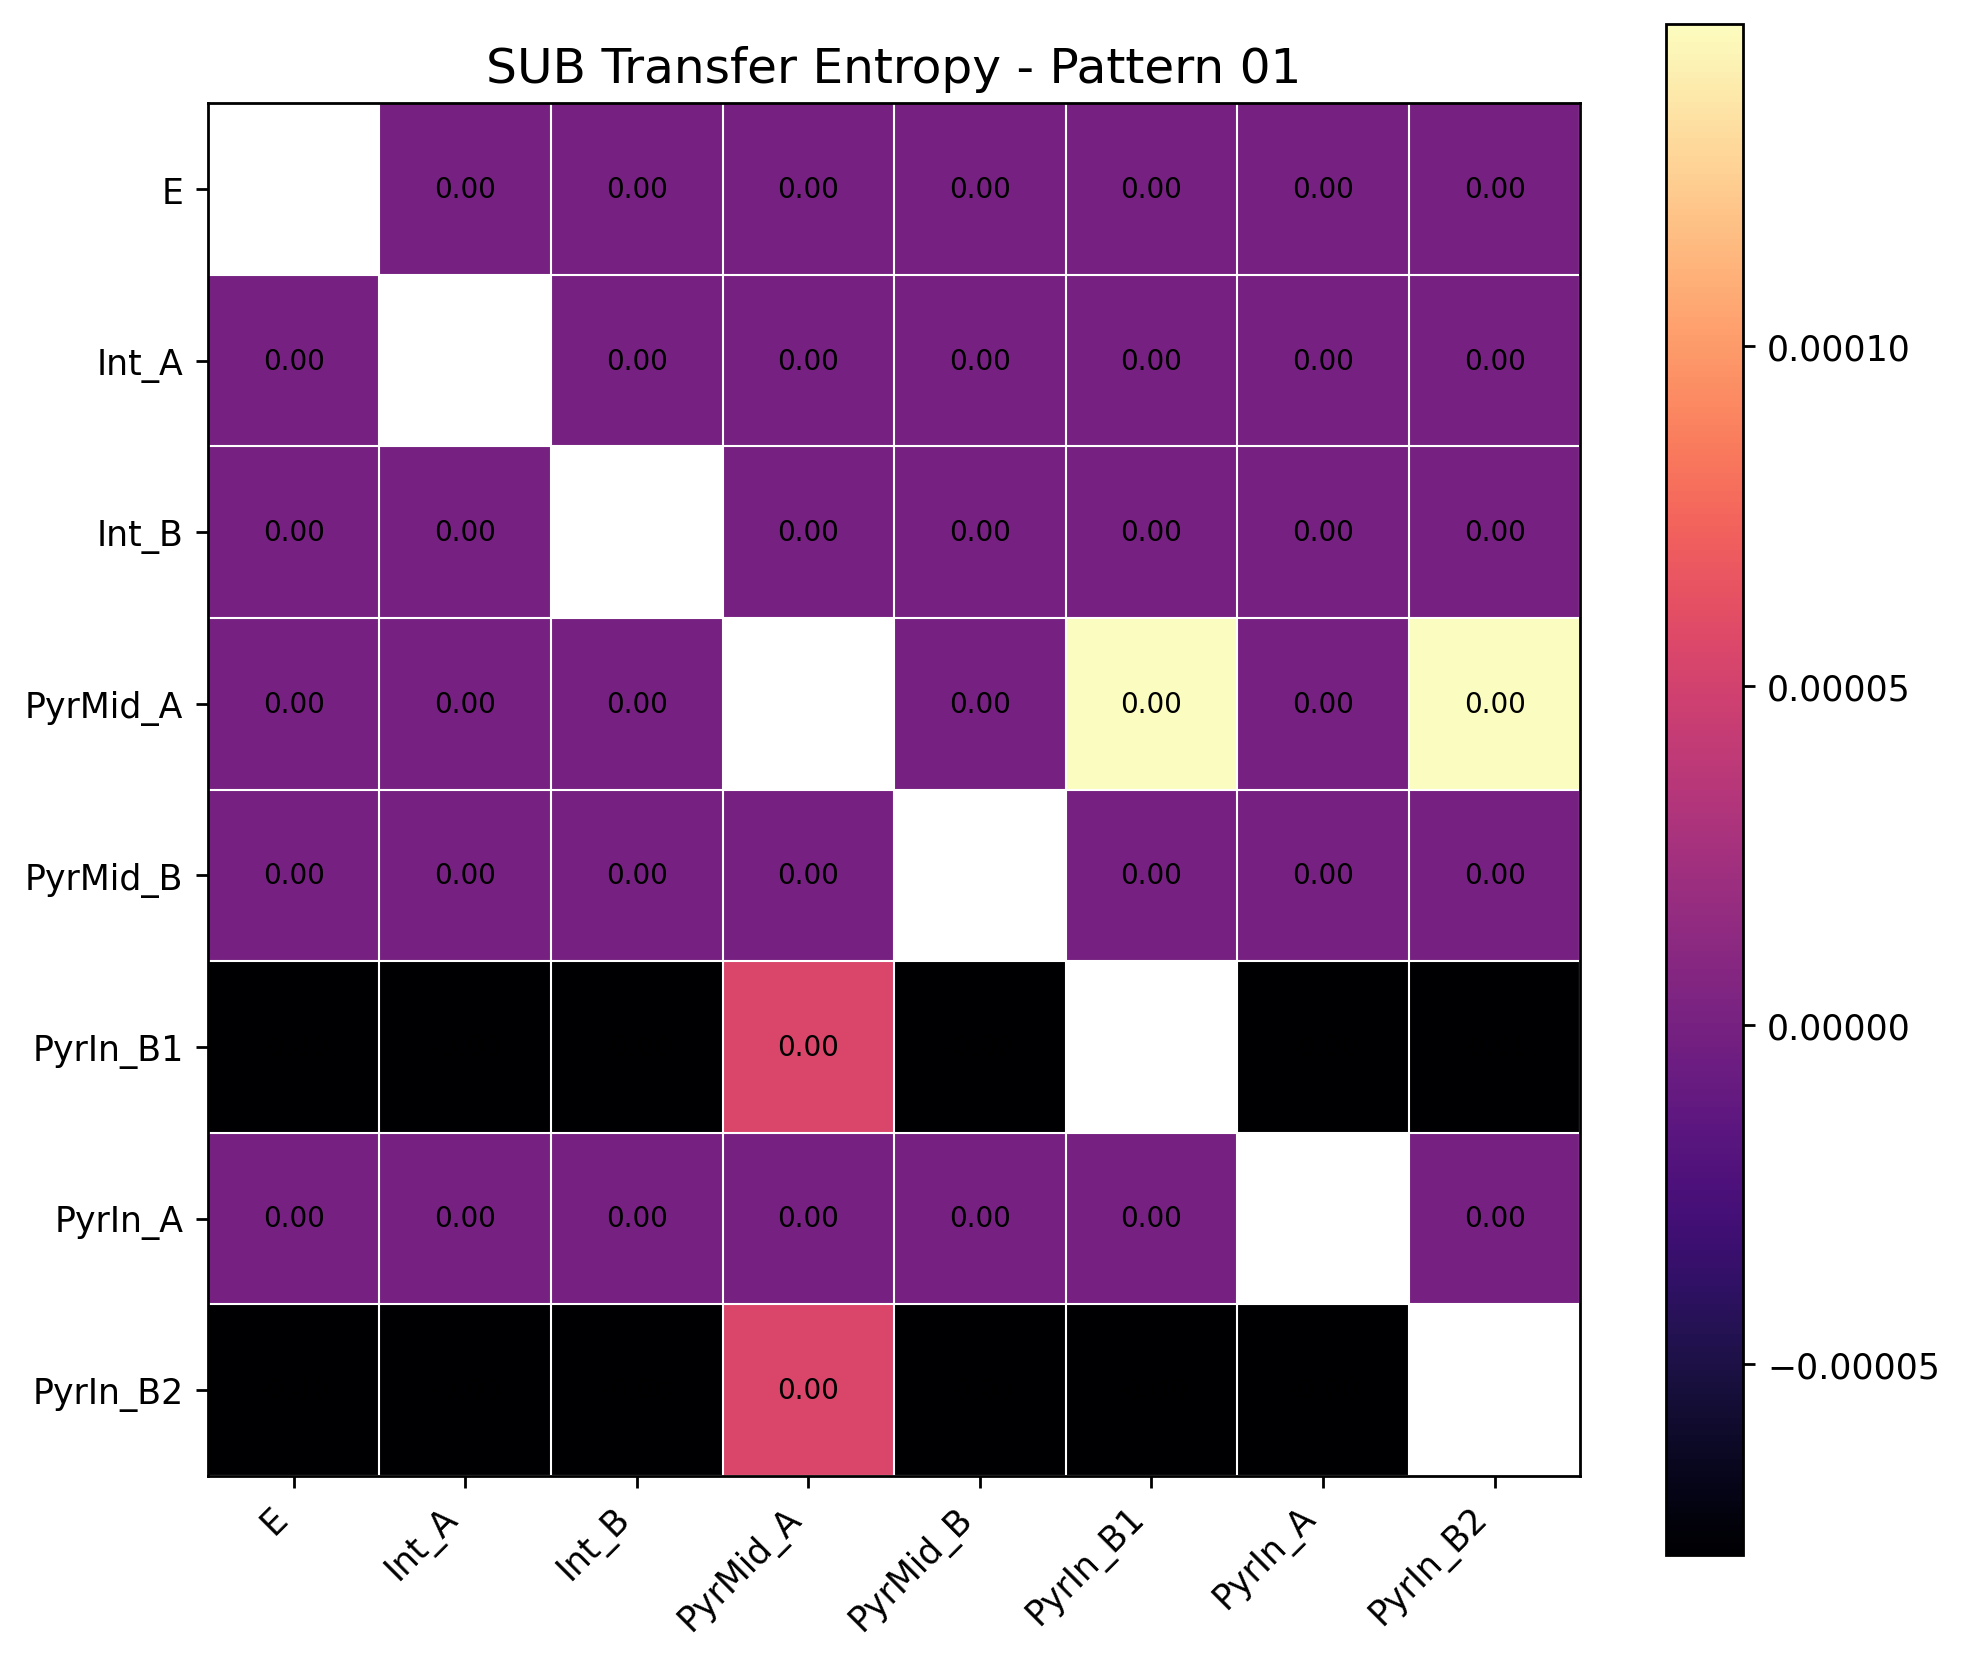

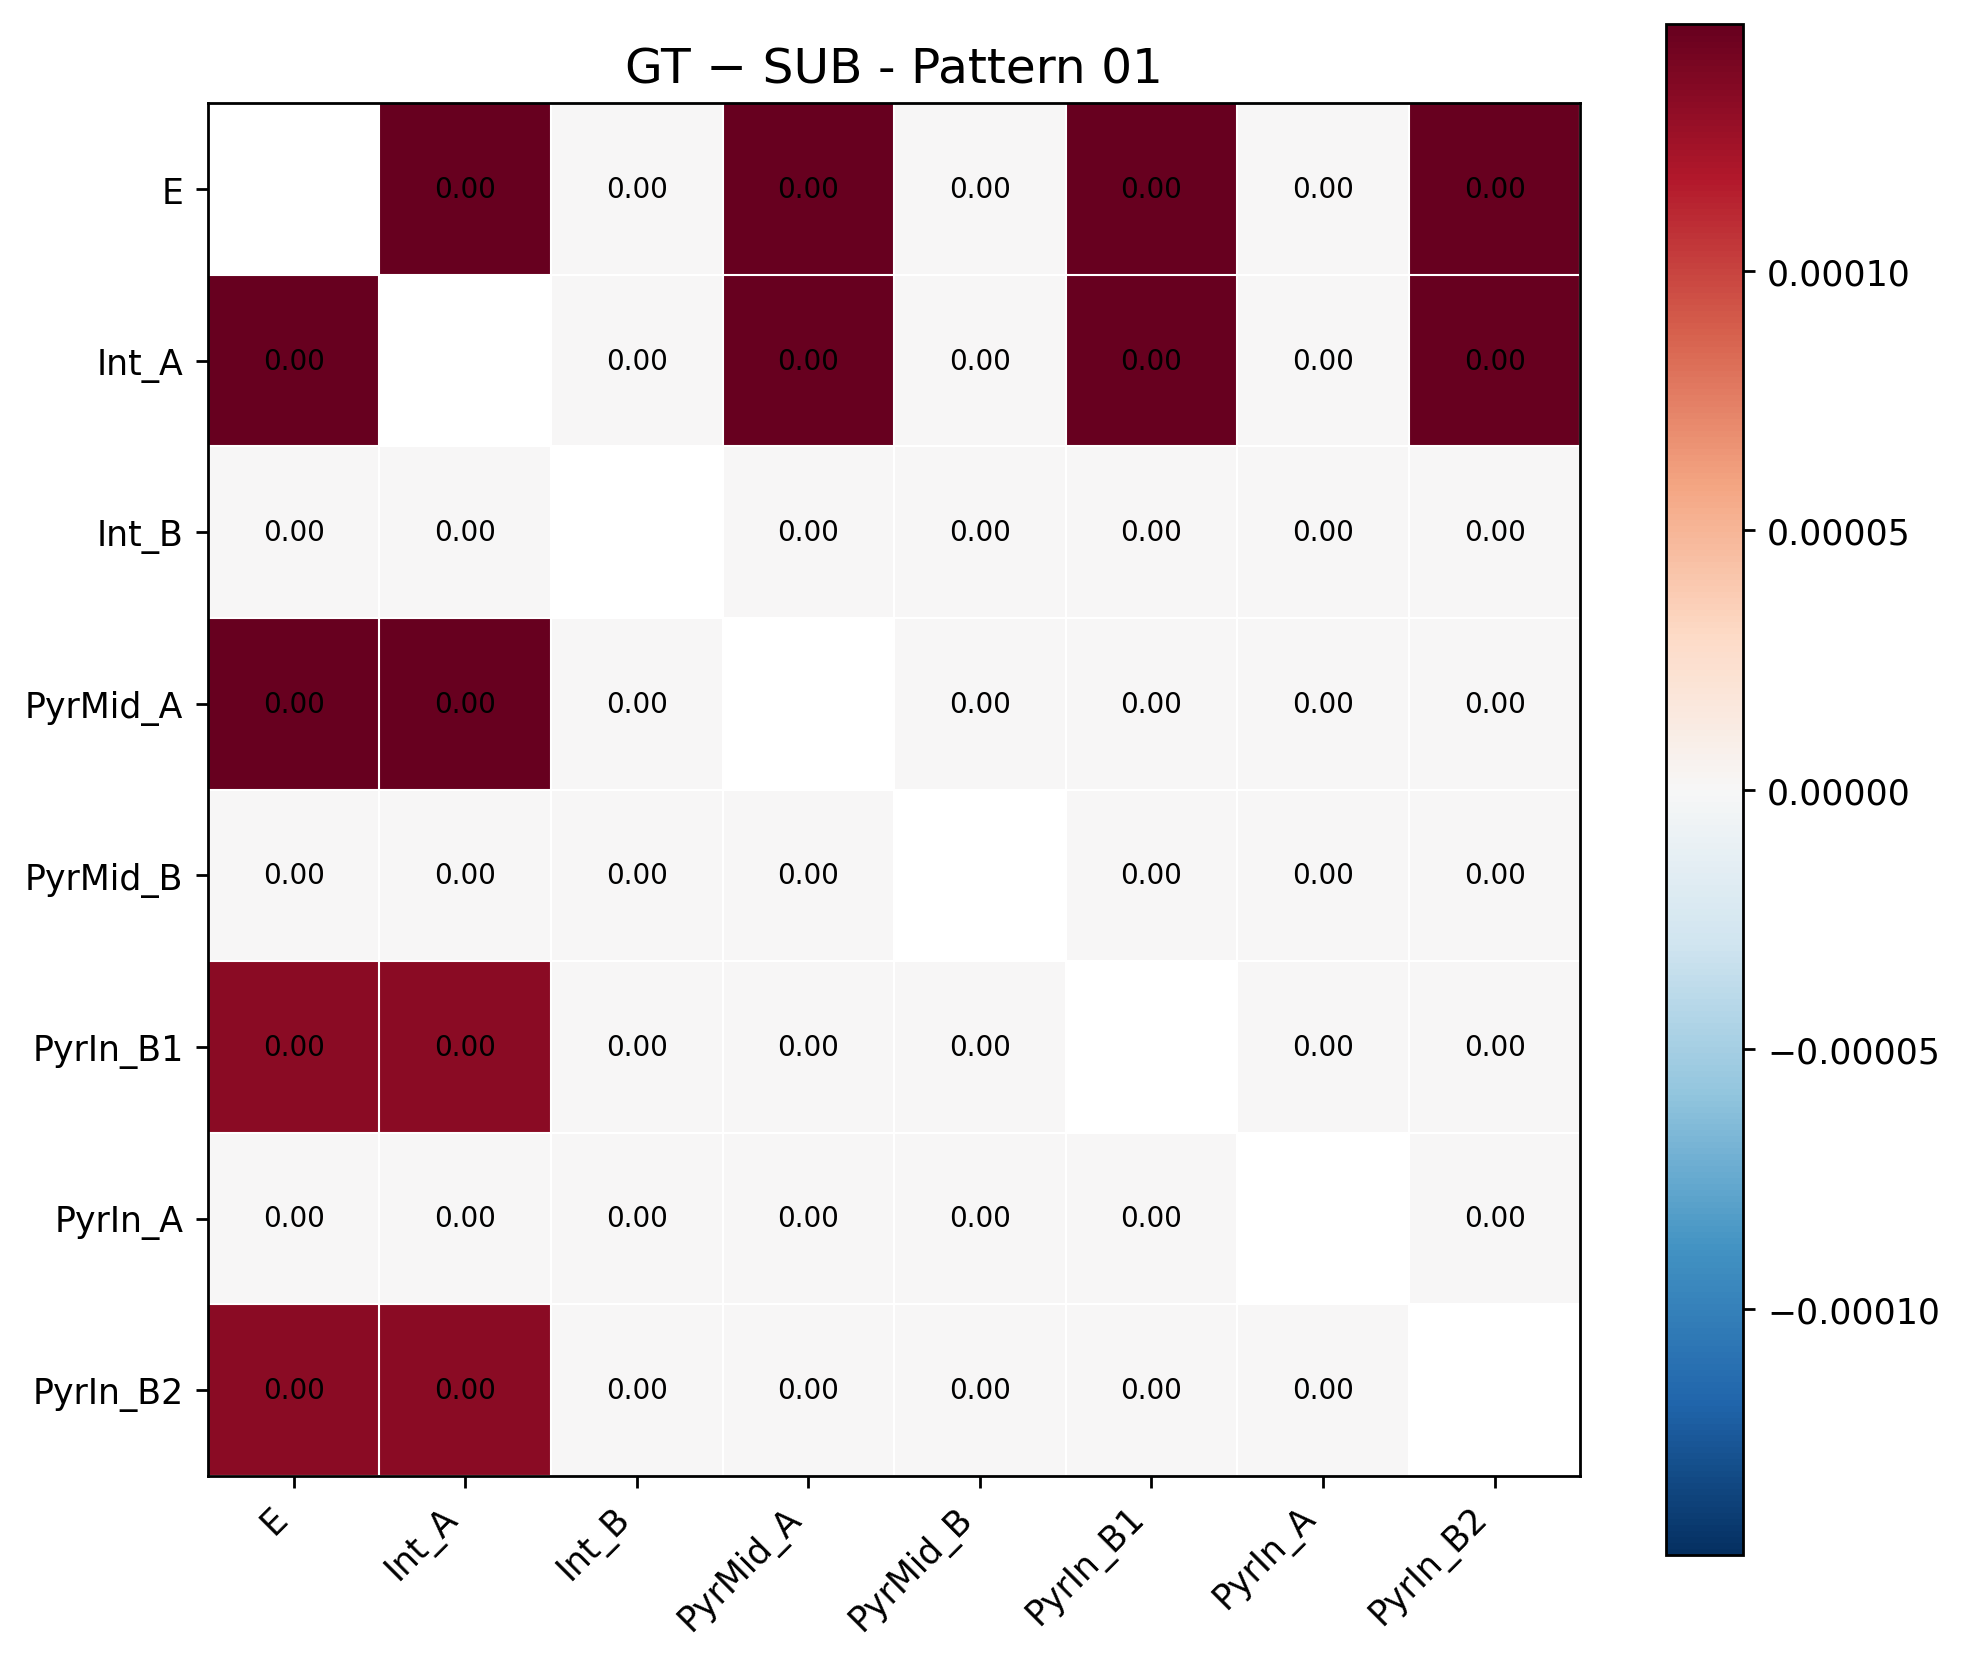

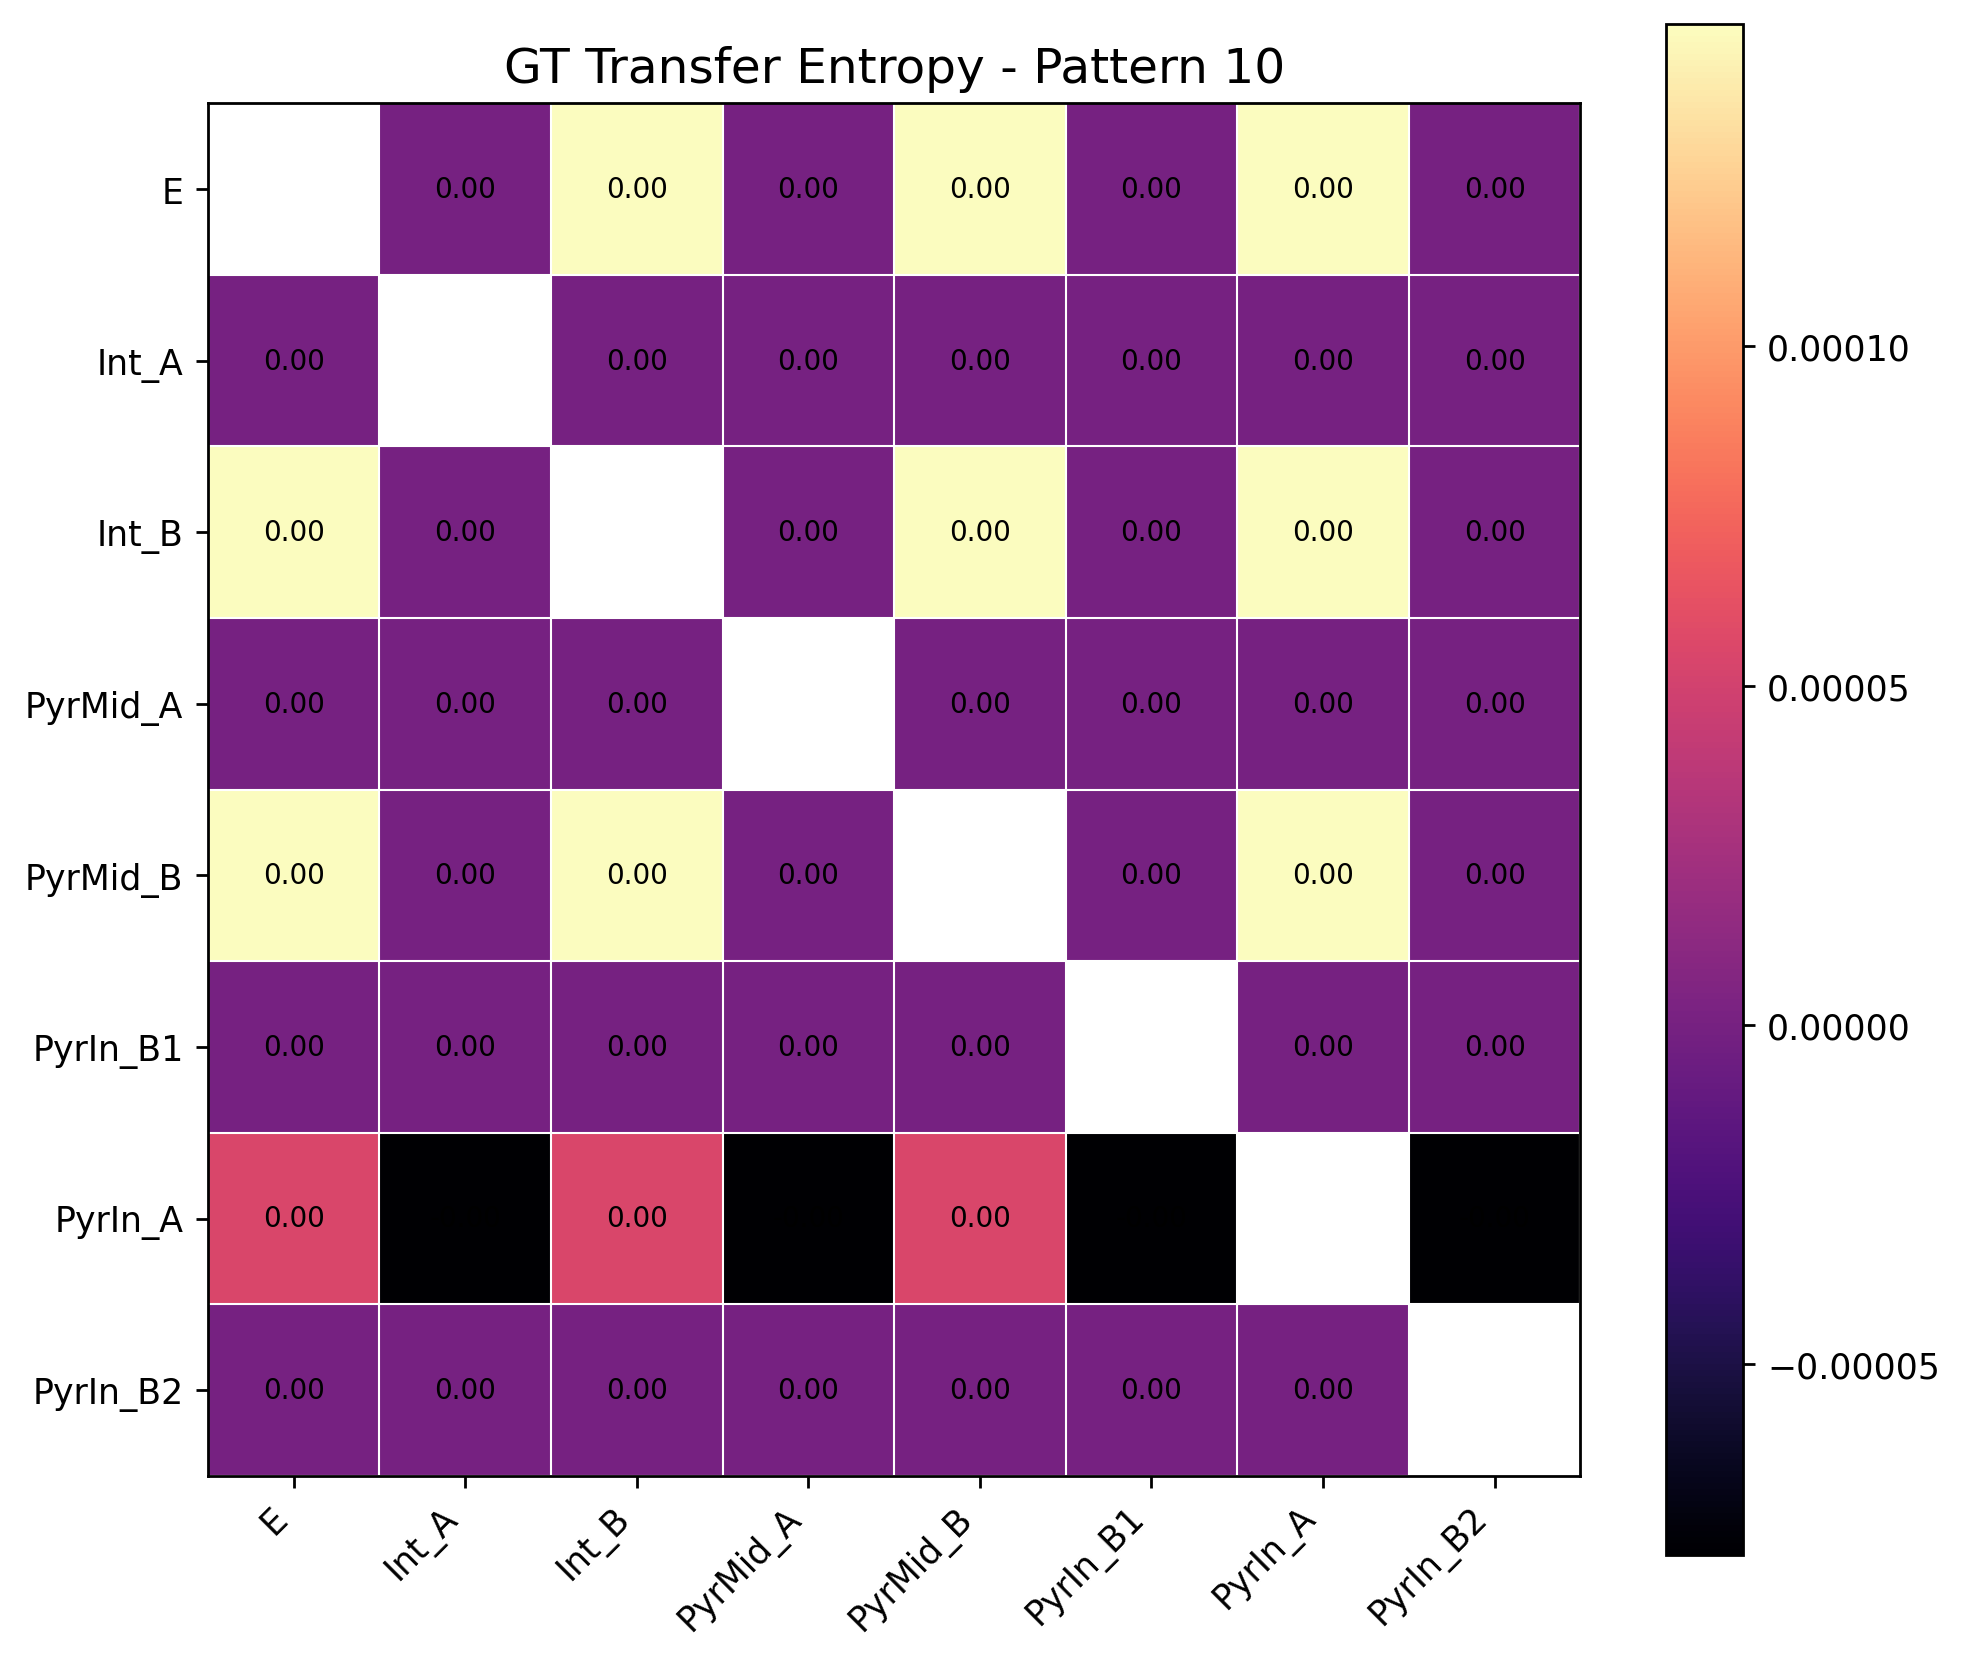

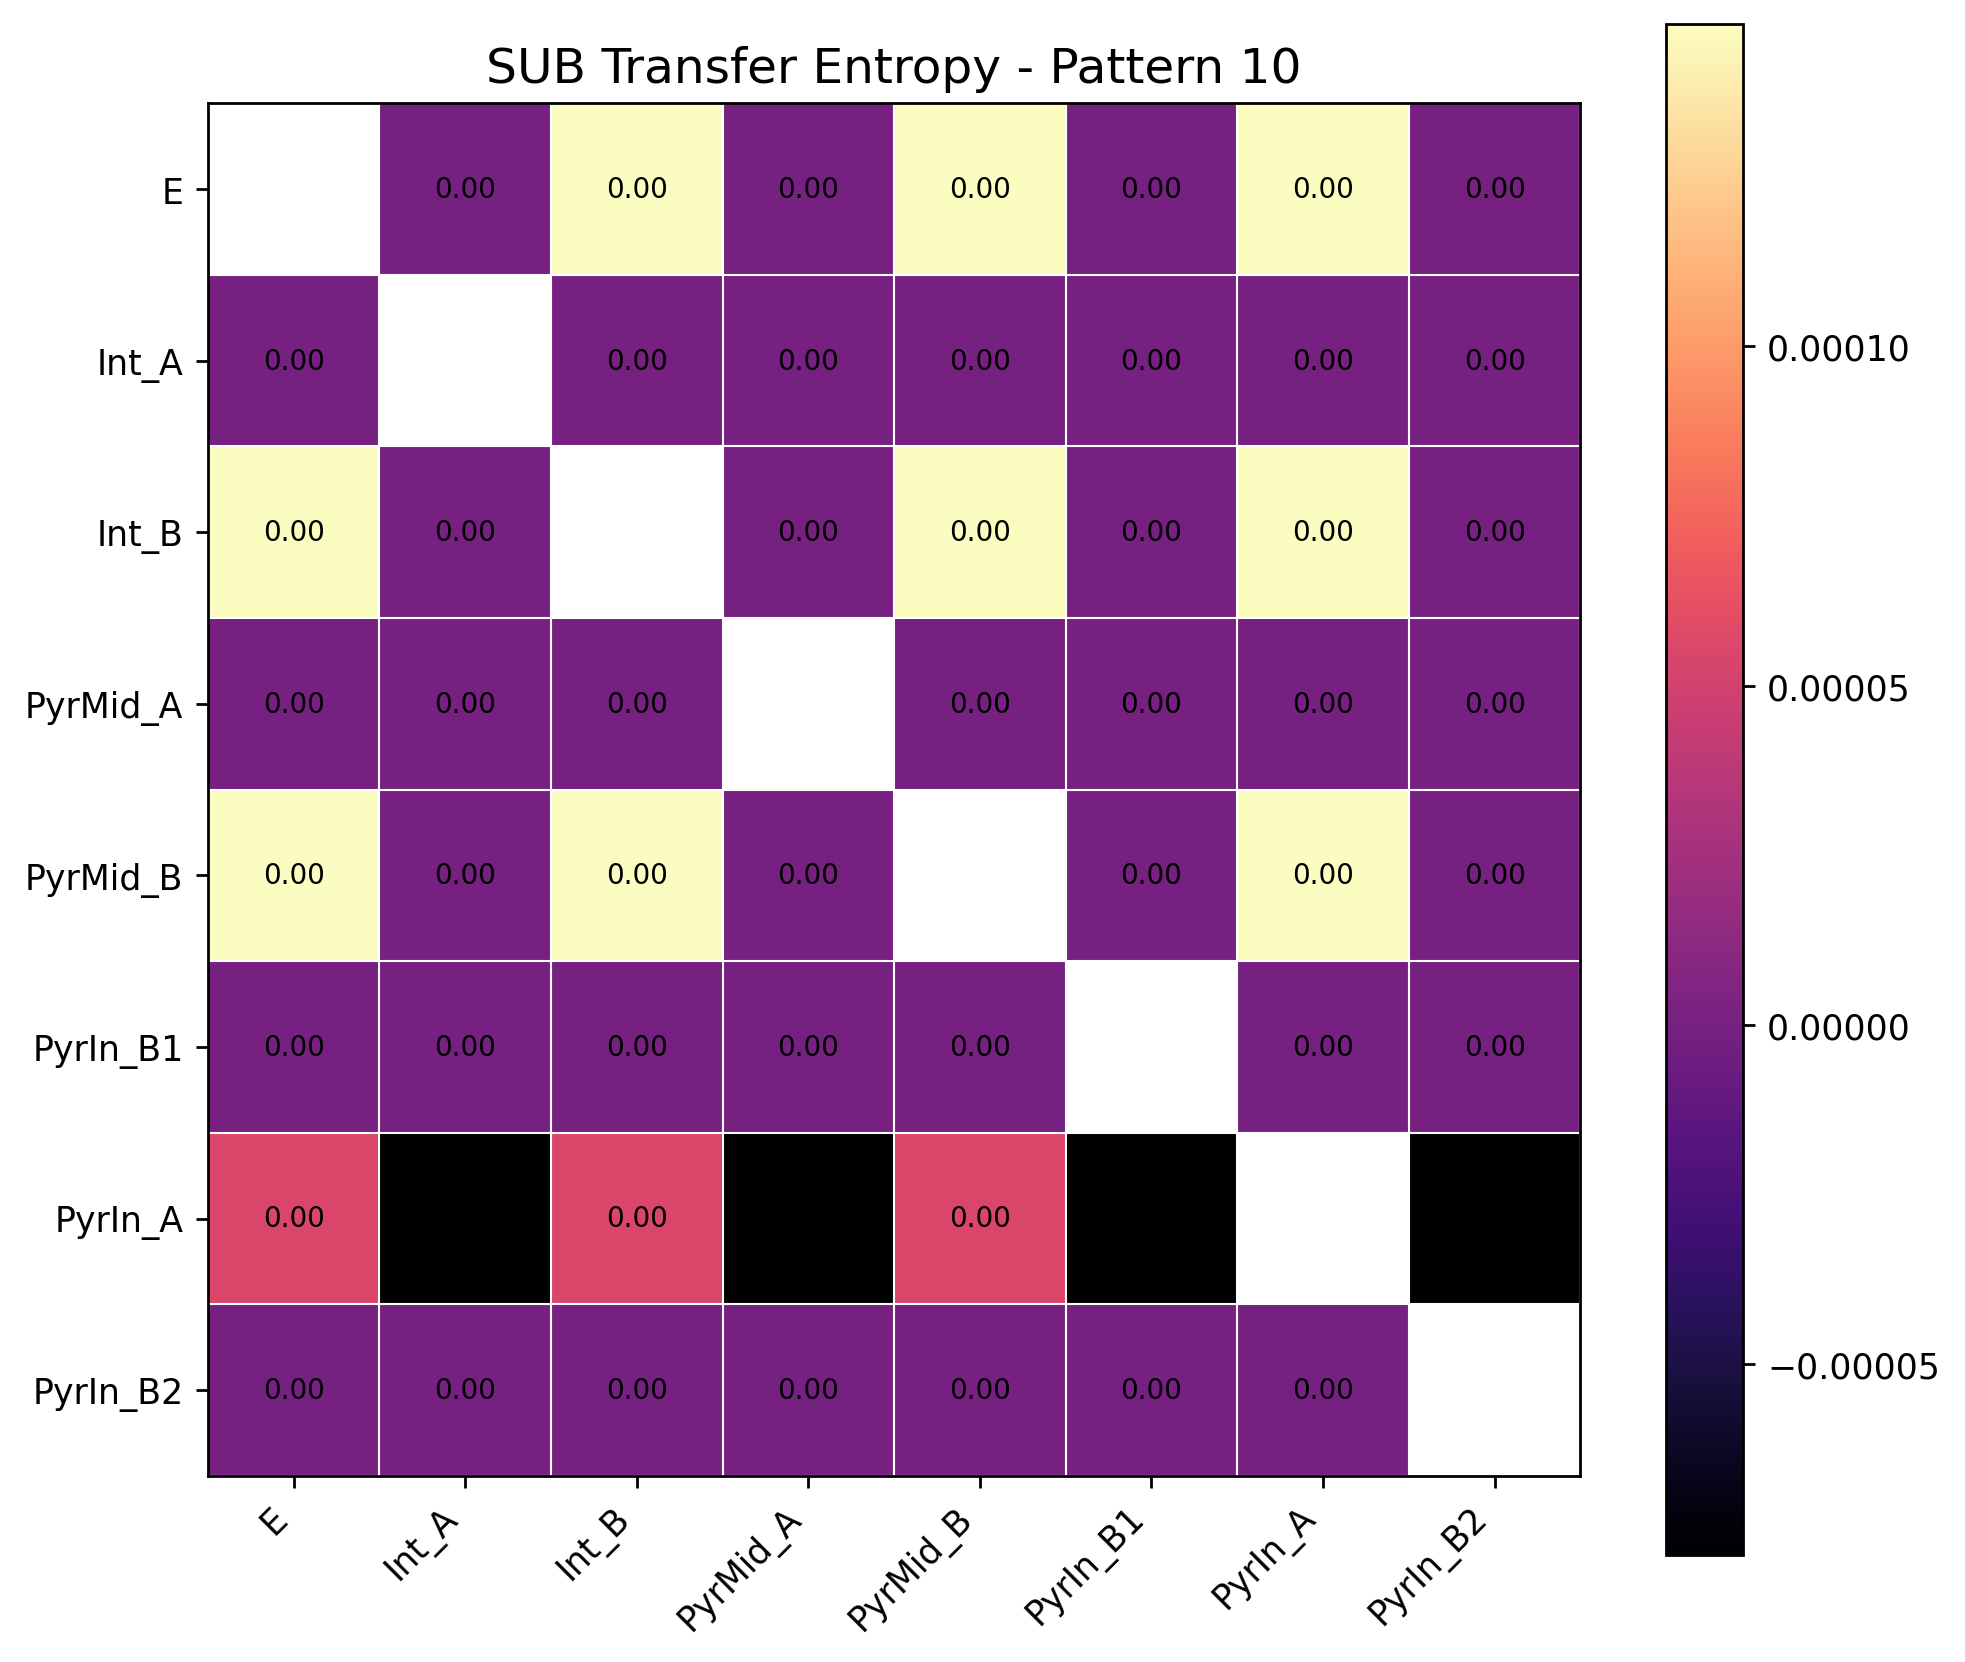

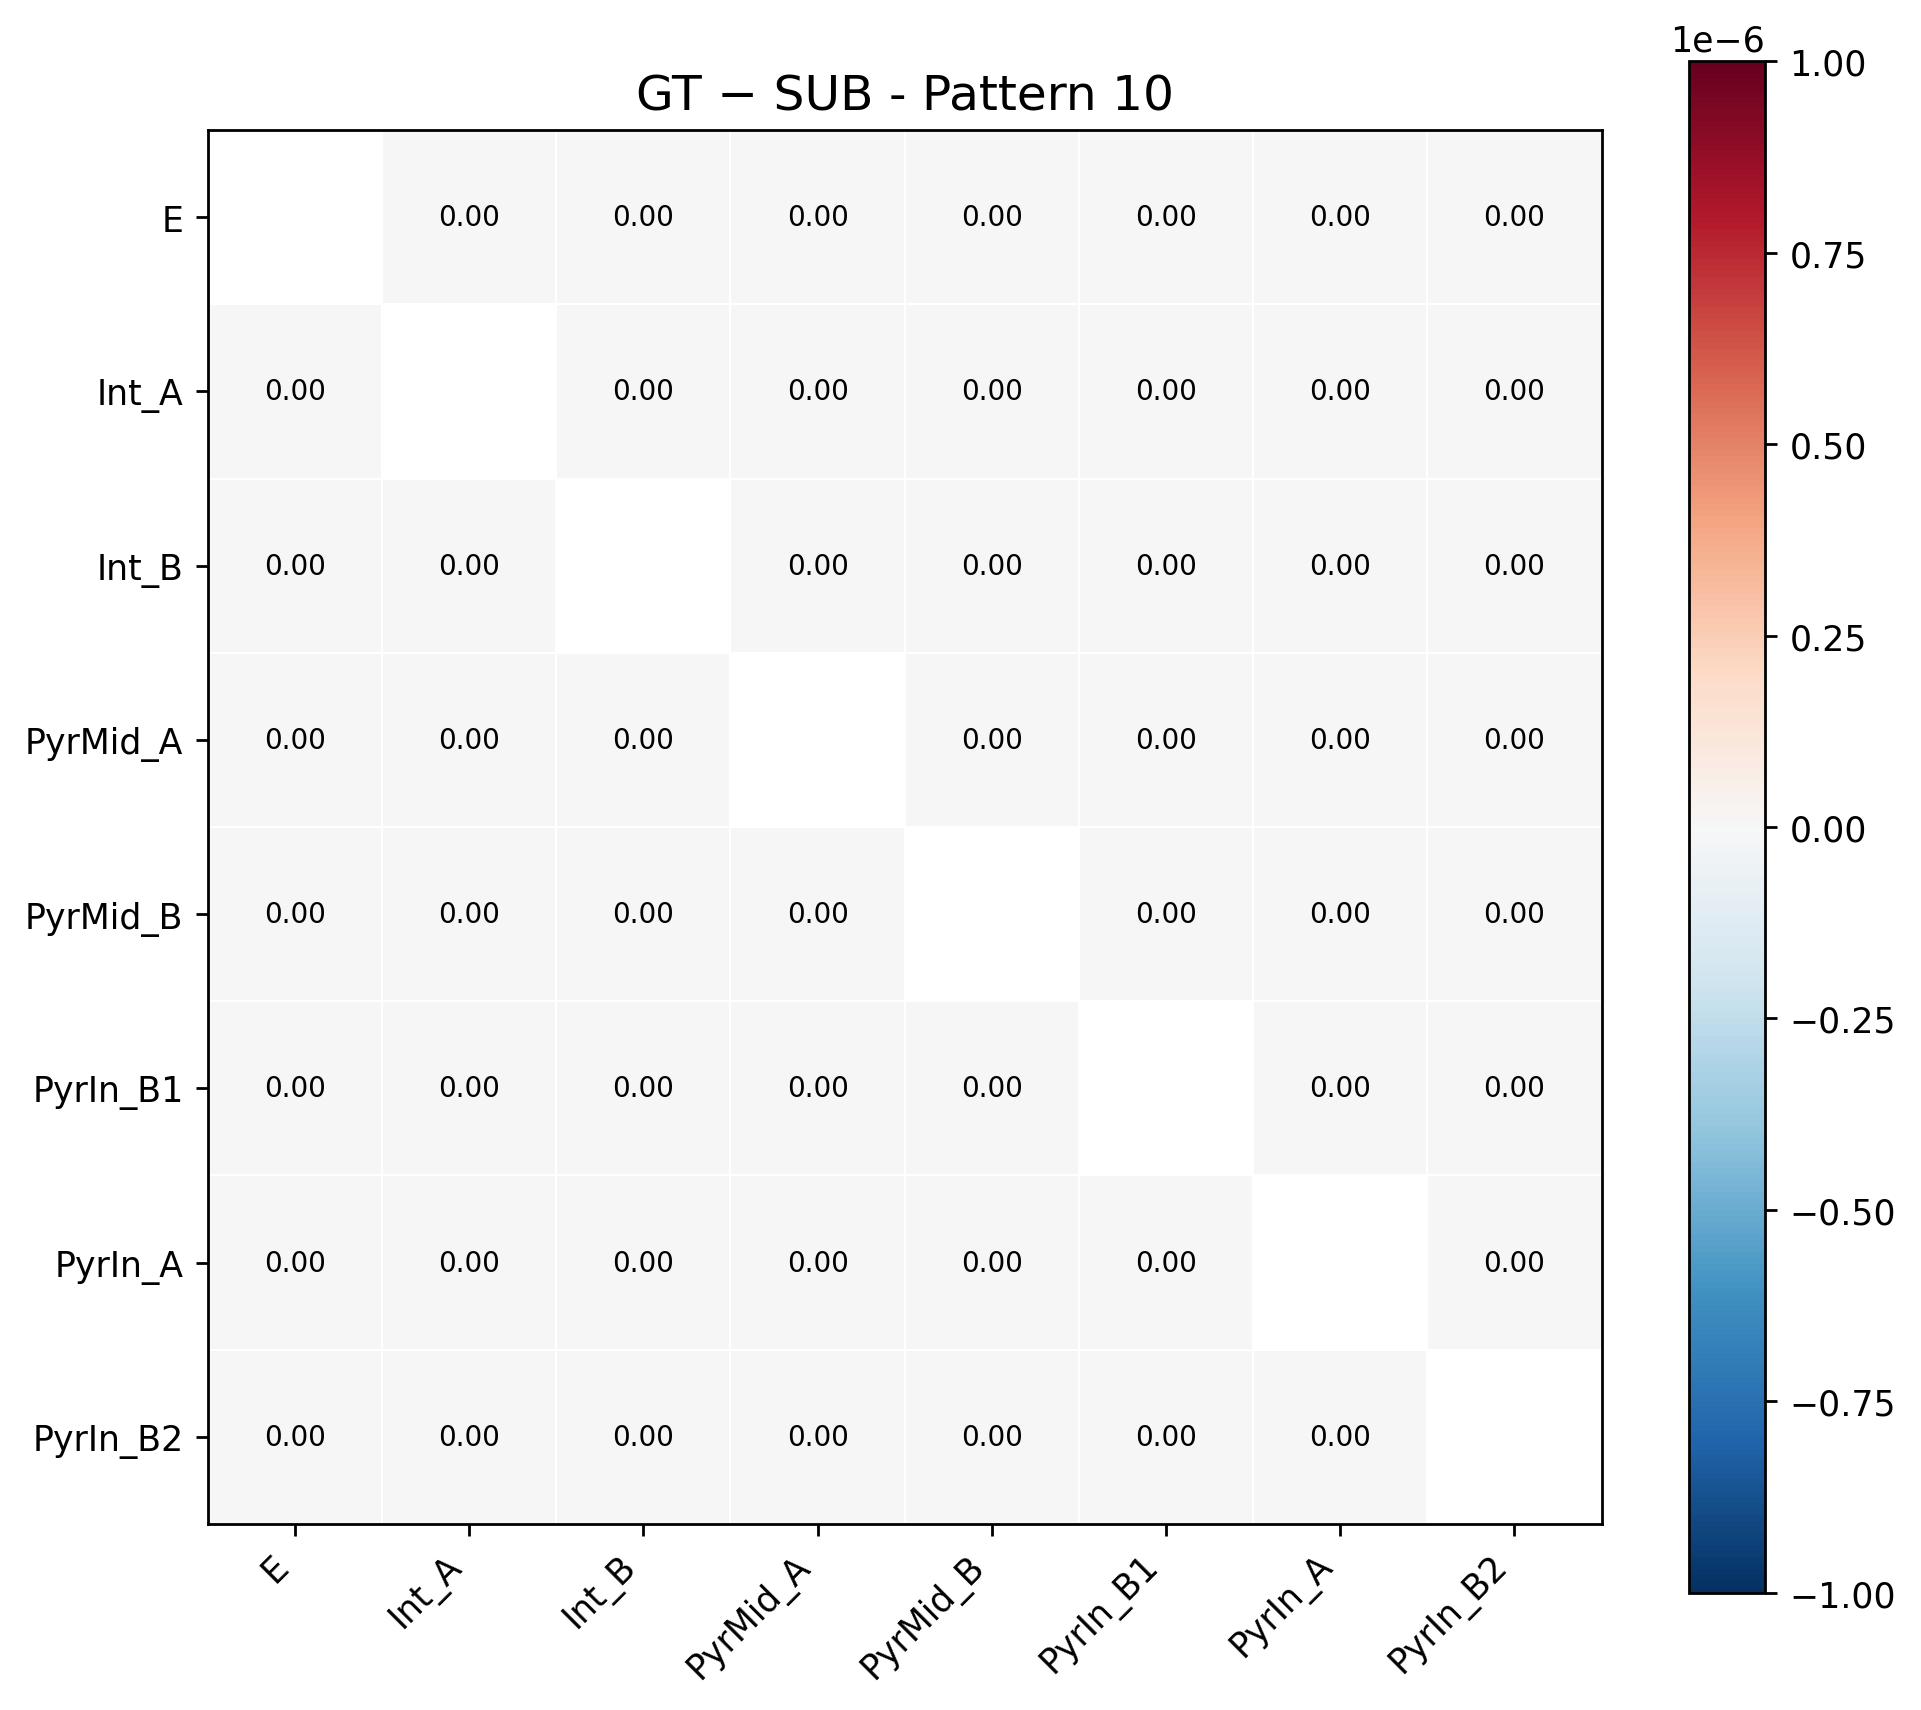

In [31]:
#Transfer Entropy

def _te_pair(arr_i: np.ndarray, arr_j: np.ndarray, lag: int = 1) -> float:
    if len(arr_i) < lag + 1:
        return np.nan

    yj_future = arr_j[lag:]
    yj_past   = arr_j[lag - 1:-1]
    yi_past   = arr_i[lag - 1:-1]
    N         = len(yj_future)

    if N == 0:
        return np.nan

    # Step 1
    triple        = 4 * yj_future + 2 * yj_past + yi_past
    counts_triple = np.bincount(triple.astype(int), minlength=8).astype(float)

    # Step 2
    counts_jj = np.array([
        counts_triple[0] + counts_triple[1],
        counts_triple[2] + counts_triple[3],
        counts_triple[4] + counts_triple[5],
        counts_triple[6] + counts_triple[7],
    ])
    counts_ji = np.array([
        counts_triple[0] + counts_triple[4],
        counts_triple[1] + counts_triple[5],
        counts_triple[2] + counts_triple[6],
        counts_triple[3] + counts_triple[7],
    ])
    counts_j = np.array([
        counts_jj[0] + counts_jj[1],
        counts_jj[2] + counts_jj[3],
    ])

    # Step 3
    p_triple = counts_triple / N
    TE = 0.0
    for state in range(8):
        if counts_triple[state] == 0:
            continue
        j_fut  = (state >> 2) & 1
        j_past = (state >> 1) & 1
        i_past = (state >> 0) & 1
        jj_idx = 2 * j_fut  + j_past
        ji_idx = 2 * j_past + i_past
        j_idx  = j_past
        p_num      = counts_triple[state]
        p_den_full = counts_ji[ji_idx]
        p_den_marg = counts_jj[jj_idx]
        p_den_j    = counts_j[j_idx]
        if p_den_full == 0 or p_den_marg == 0 or p_den_j == 0:
            continue
        log_ratio = np.log2(
            (p_num * p_den_j) / (p_den_full * p_den_marg)
        )
        TE += p_triple[state] * log_ratio


    return (float(TE))


def compute_TE_matrix(trials: list, spike_cols: list[str], lag: int = 1) -> np.ndarray:
    # same pattern as compute_JE_matrix and compute_MI_matrix
    # N x N, diagonal = NaN, NO symmetry exploitation (TE is asymmetric)
    N      = len(spike_cols)
    arrays = {}
    for col in spike_cols:
        pieces = [df[col].to_numpy(dtype=int) for df in trials if col in df.columns]
        arrays[col] = np.concatenate(pieces) if pieces else np.zeros(0, dtype=int)

    TE = np.full((N, N), np.nan)
    for j in range(N):
        for i in range(N):
            if i == j:
                continue
            TE[j, i] = _te_pair(arrays[spike_cols[i]], arrays[spike_cols[j]], lag=lag)
    return TE


def transfer_entropy_compute():
    lag = 1
    
    patterns   = gt_data["case"].unique().tolist()
    neurons    = hp.get_spiking_neurons(cfg,gt_data)
    spike_cols = [f"{n}_spike" for n in neurons]

    te_meta  = {"patterns": patterns, "spike_cols": spike_cols}
    gt_mats  = []
    sub_mats = []

    for p in patterns:
        gt_trials  = [gt_data[gt_data["case"] == p]]
        sub_trials = [sub_data[sub_data["case"] == p]]

        gt_TE  = compute_TE_matrix(gt_trials,  spike_cols, lag=lag)
        sub_TE = compute_TE_matrix(sub_trials, spike_cols, lag=lag)

        te_meta[p] = {
            "gt":   gt_TE,
            "sub":  sub_TE,
            "diff": gt_TE - sub_TE,
        }
        gt_mats.append(gt_TE)
        sub_mats.append(sub_TE)

    gt_arr  = np.stack(gt_mats)
    sub_arr = np.stack(sub_mats)
    diff    = np.nanmean(np.abs(gt_arr - sub_arr))
    score   = float(1.0 - np.clip(diff, 0.0, 1.0))

    return gt_arr, sub_arr, score, te_meta

te_result = transfer_entropy_compute()
_, _, _, meta = te_result

patterns = meta["patterns"]
labels = [c.replace("_spike", "") for c in meta["spike_cols"]]

for pattern in patterns:

    gt = meta[pattern]["gt"]
    sub = meta[pattern]["sub"]
    diff = meta[pattern]["diff"]

    vmax = max(np.nanmax(gt), np.nanmax(sub))
    vmin = min(np.nanmin(gt), np.nanmin(sub))

    diff_lim = np.nanmax(np.abs(diff))
    if diff_lim == 0:
        diff_lim = 1e-6

    plot_single_heatmap(
        gt,
        f"GT Transfer Entropy - Pattern {pattern}",
        labels,
        "magma",
        vmin,
        vmax,
    )

    plot_single_heatmap(
            sub,
            f"SUB Transfer Entropy - Pattern {pattern}",
            labels,
            "magma",
            vmin,
            vmax,
        )

    plot_single_heatmap(
            diff,
            f"GT − SUB - Pattern {pattern}",
            labels,
            "RdBu_r",
            -diff_lim,
            diff_lim,
            )